In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dorito
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
zodiax version: 0.4.1
amigo version: 0.0.10
dorito version: 0.2.0
equinox version: 0.13.7
lineax version 0.1.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/outputs/retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
all_data_flag = True
one_filt_flag = False
plot_flag = False
save_flag = True
# save_flag = check_script()

job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
if job_id is None:
    from datetime import datetime
    form = "%y-%m-%d_%H-%M-%S_%f"
    now = datetime.now()
    job_id = now.strftime(form)
print(f"Job ID: {job_id}")
save_path = os.path.join(output_path, job_id)
if not os.path.exists(save_path):
    os.makedirs(save_path)

# logging outputs in a text file
if check_script():

    import shutil
    shutil.copy(__file__, save_path + "/script.py")
    
    log_path = os.path.join(save_path, "output.txt")

    class Tee:
        def __init__(self, filename):
            self.file = open(filename, "w")
            self.stdout = sys.stdout

        def write(self, message):
            self.stdout.write(message)
            self.file.write(message)

        def flush(self):
            self.stdout.flush()
            self.file.flush()

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

    print("Logging to file AND terminal now.")
        
print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-7
Job ID: 26-05-13_08-08-34_901703
Running in a notebook or interactive shell
Save path: /home/dgxuser/max/outputs/retrain/26-05-13_08-08-34_901703
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    return file

# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Validation files
Calibrators from other science programs

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []


# 1093, Deepashri Thatte
program_path = os.path.join(data_dir, "1093/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] == "HD-36805"]
val_files += files

# 1843, Jens Kammerer
program_path = os.path.join(data_dir, "1843/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
val_files += files

# 1242, Doug Johnstone
program_path = os.path.join(data_dir, "1242/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] != "TD-CAL-HD-101531"]
val_files += files

# Creating a subset of the data for testing
if not all_data_flag:
    _ = []
    filts = []
    for file in val_files:
        filt = file[0].header["FILTER"]
        if one_filt_flag:
            if filt != "F480M":
                continue
        if filt not in filts:
            _.append(file)
            filts.append(filt)
    val_files = _

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]


In [5]:
from amigo.model_fits import PointFit

# Construct the exposures
val_exposures = [PointFit(file) for file in val_files]





jw01093020001_03102_00011_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  11/25  9/65  05-06-2022  Thatte, Deepashri  True


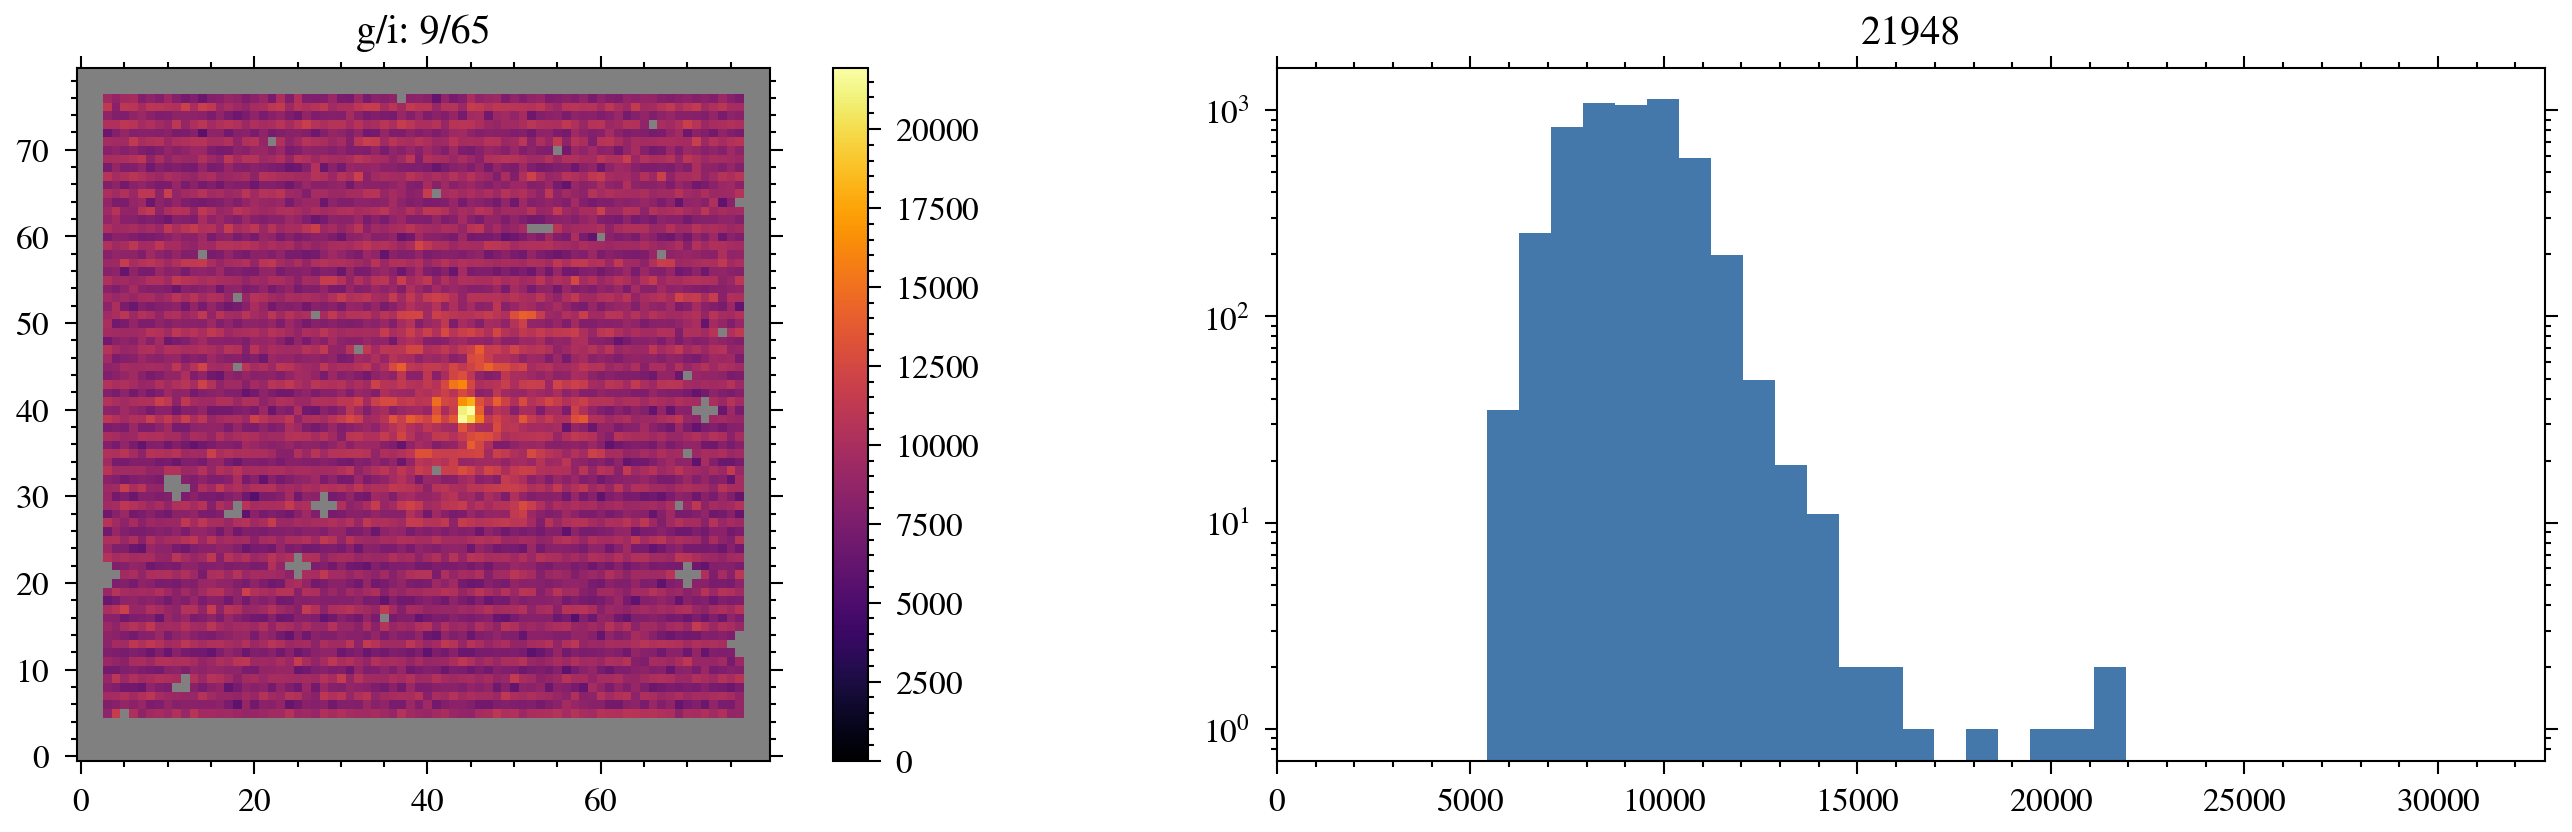




jw01093007001_03102_00016_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  16/25  9/65  23-05-2022  Thatte, Deepashri  True


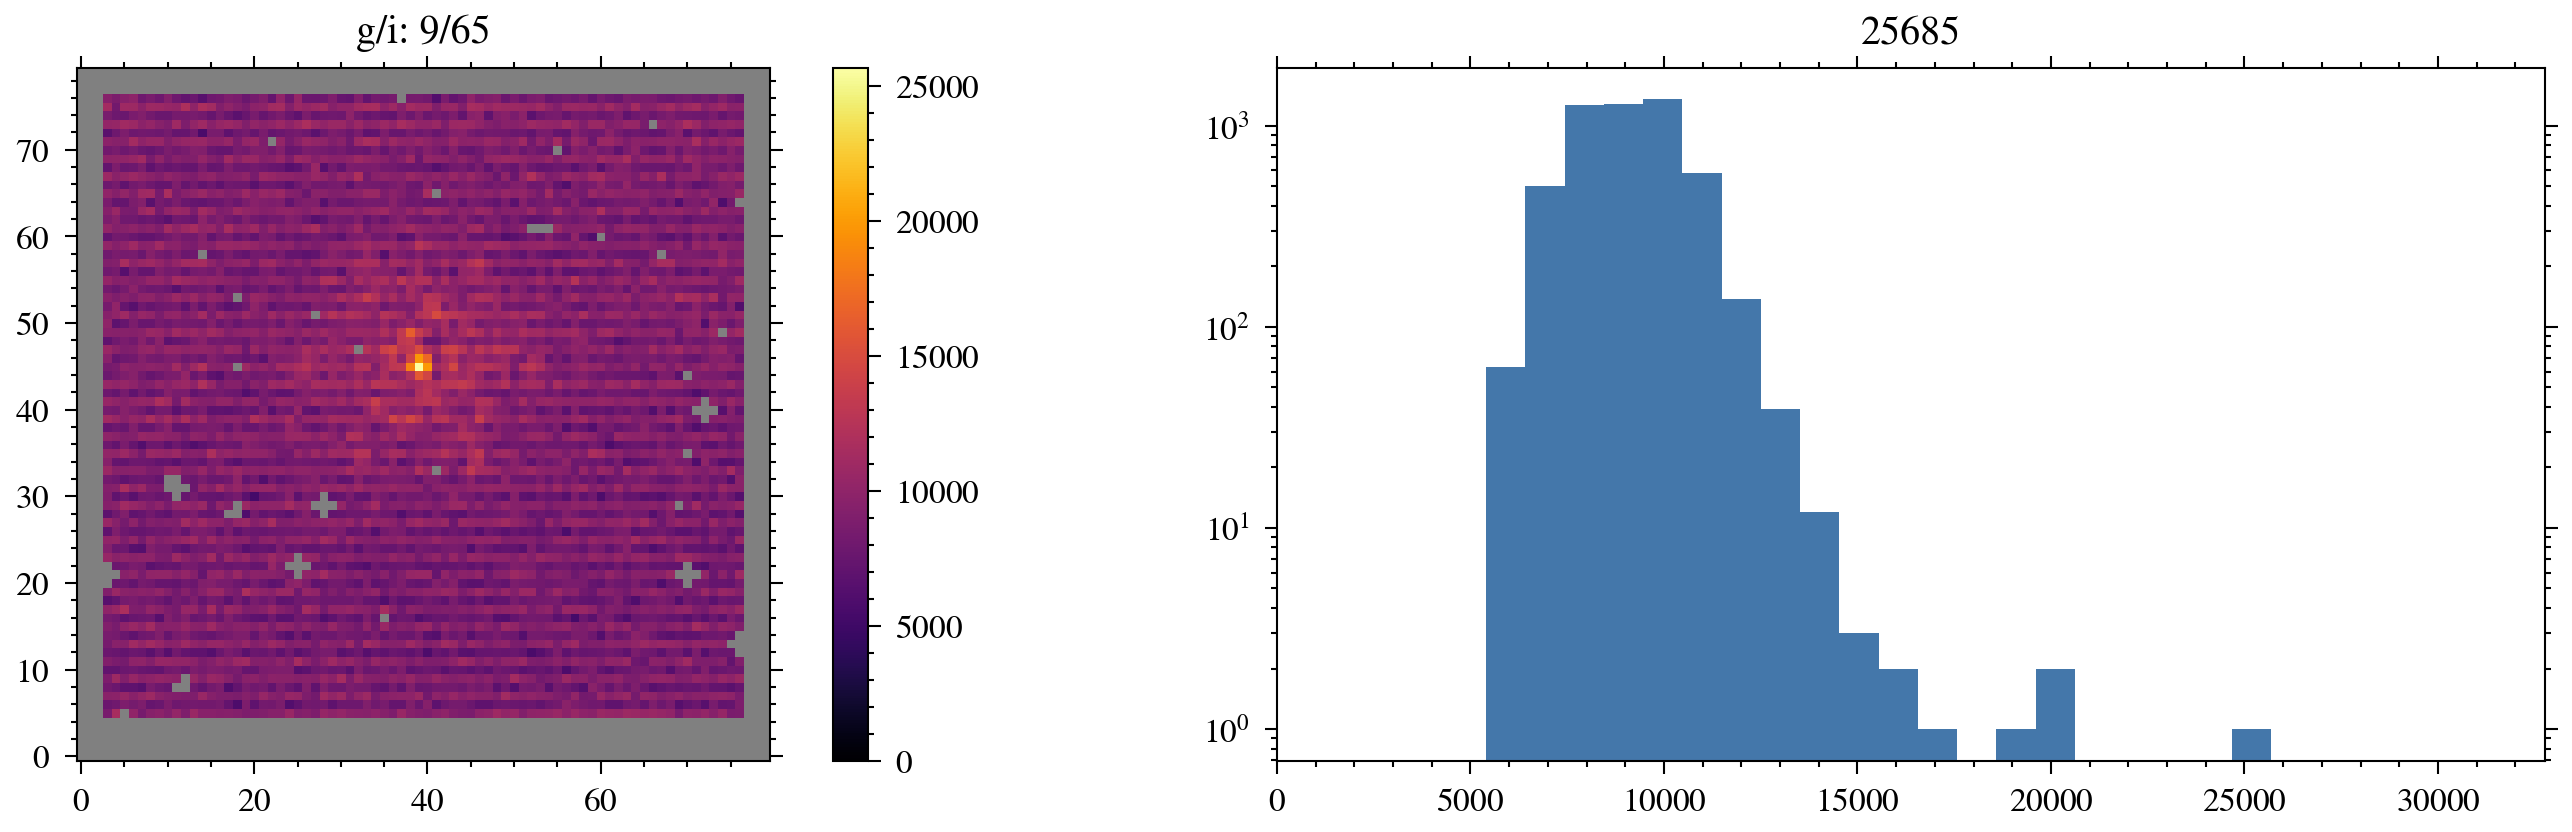




jw01093007001_03102_00011_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  11/25  9/65  23-05-2022  Thatte, Deepashri  True


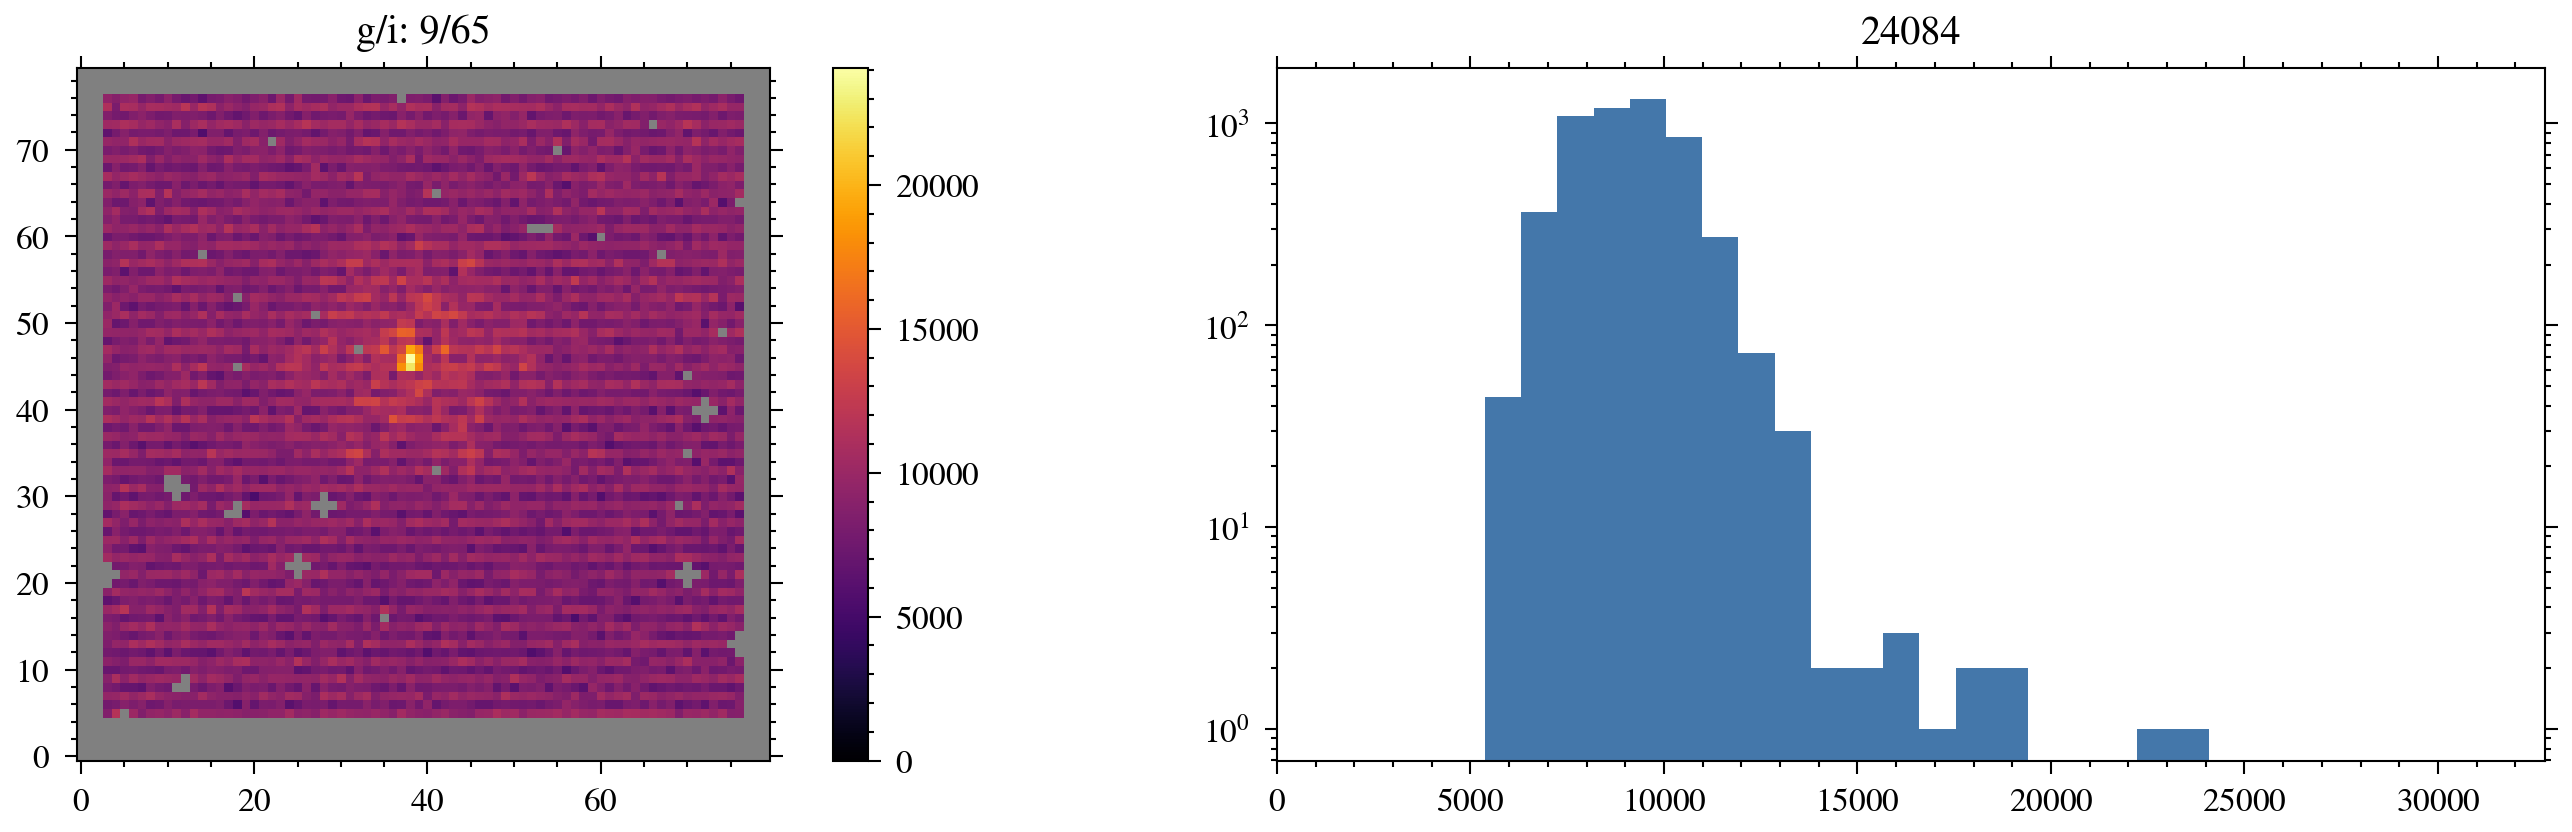




jw01093020001_03102_00003_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   3/25  9/65  05-06-2022  Thatte, Deepashri  True


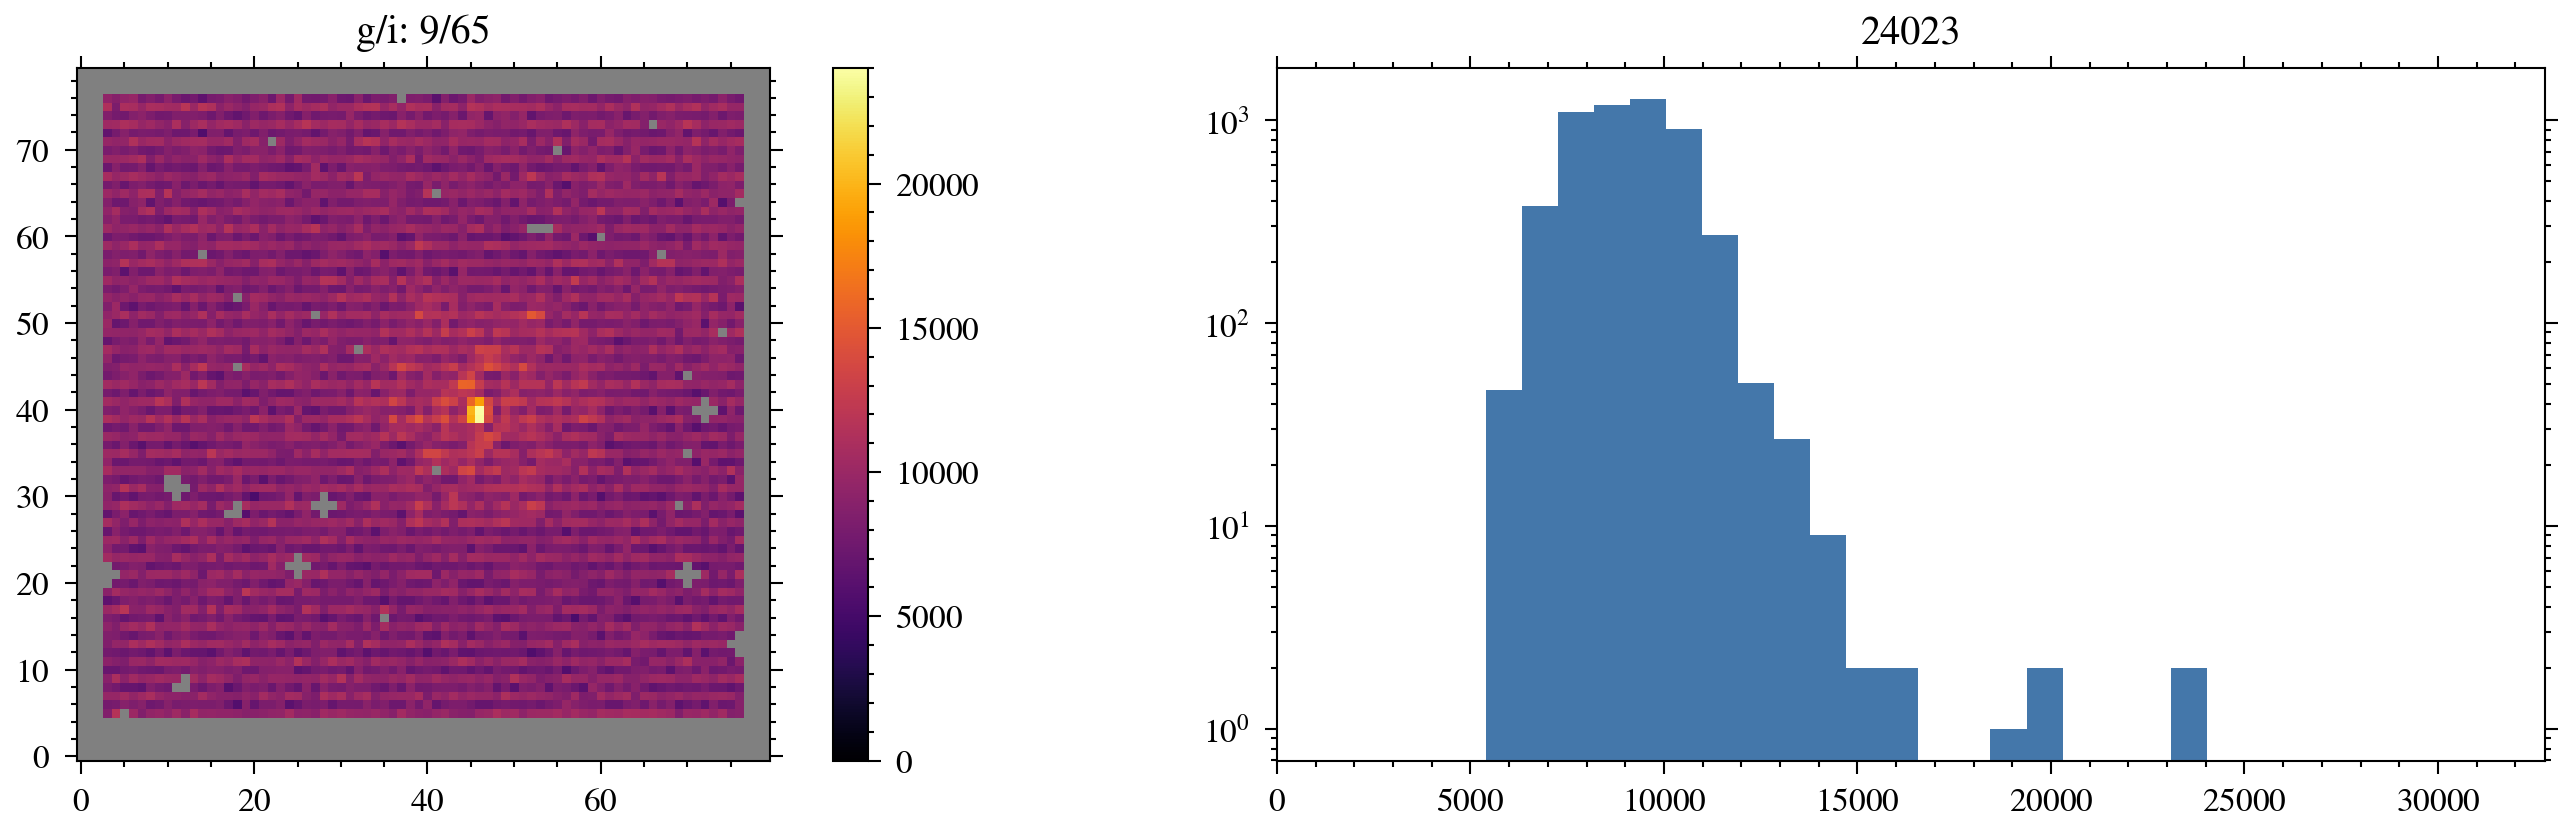




jw01093007001_03102_00014_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  14/25  9/65  23-05-2022  Thatte, Deepashri  True


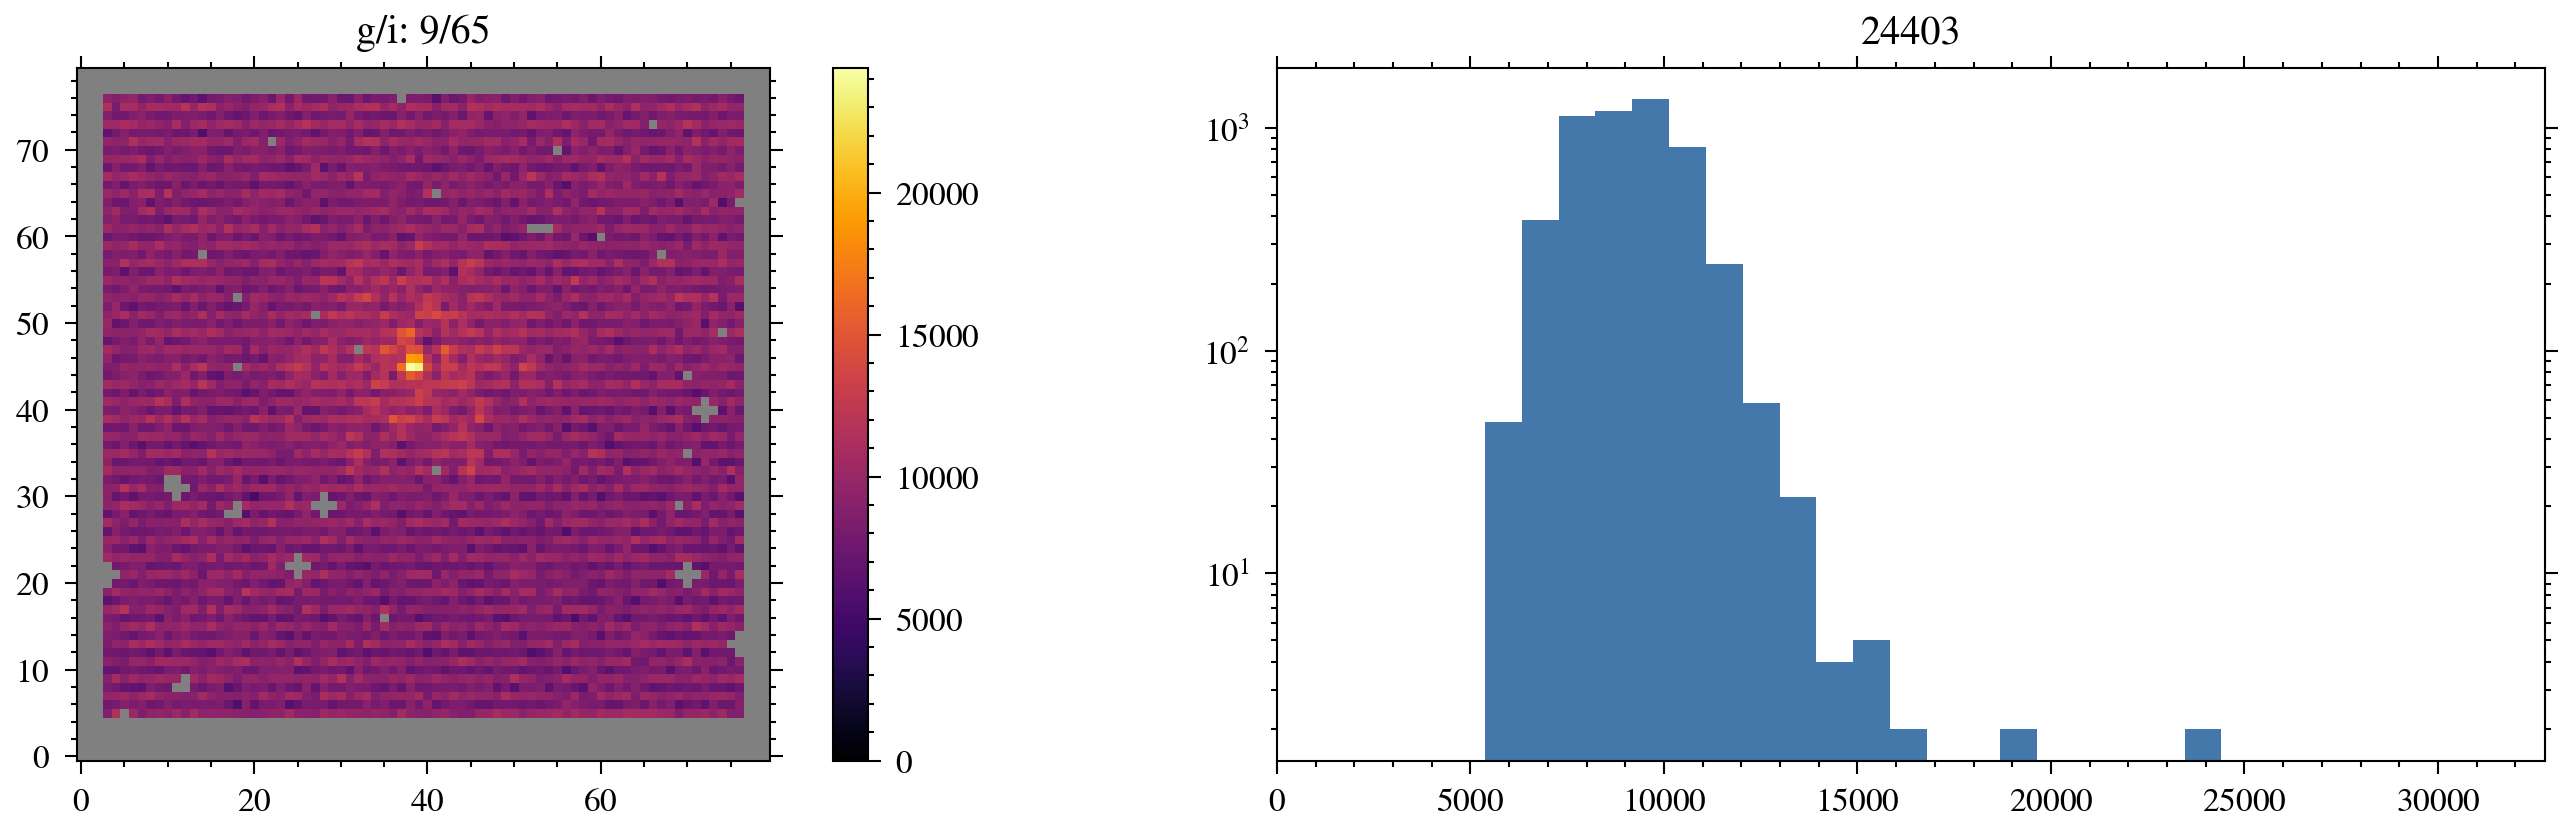




jw01093007001_03102_00020_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  20/25  9/65  23-05-2022  Thatte, Deepashri  True


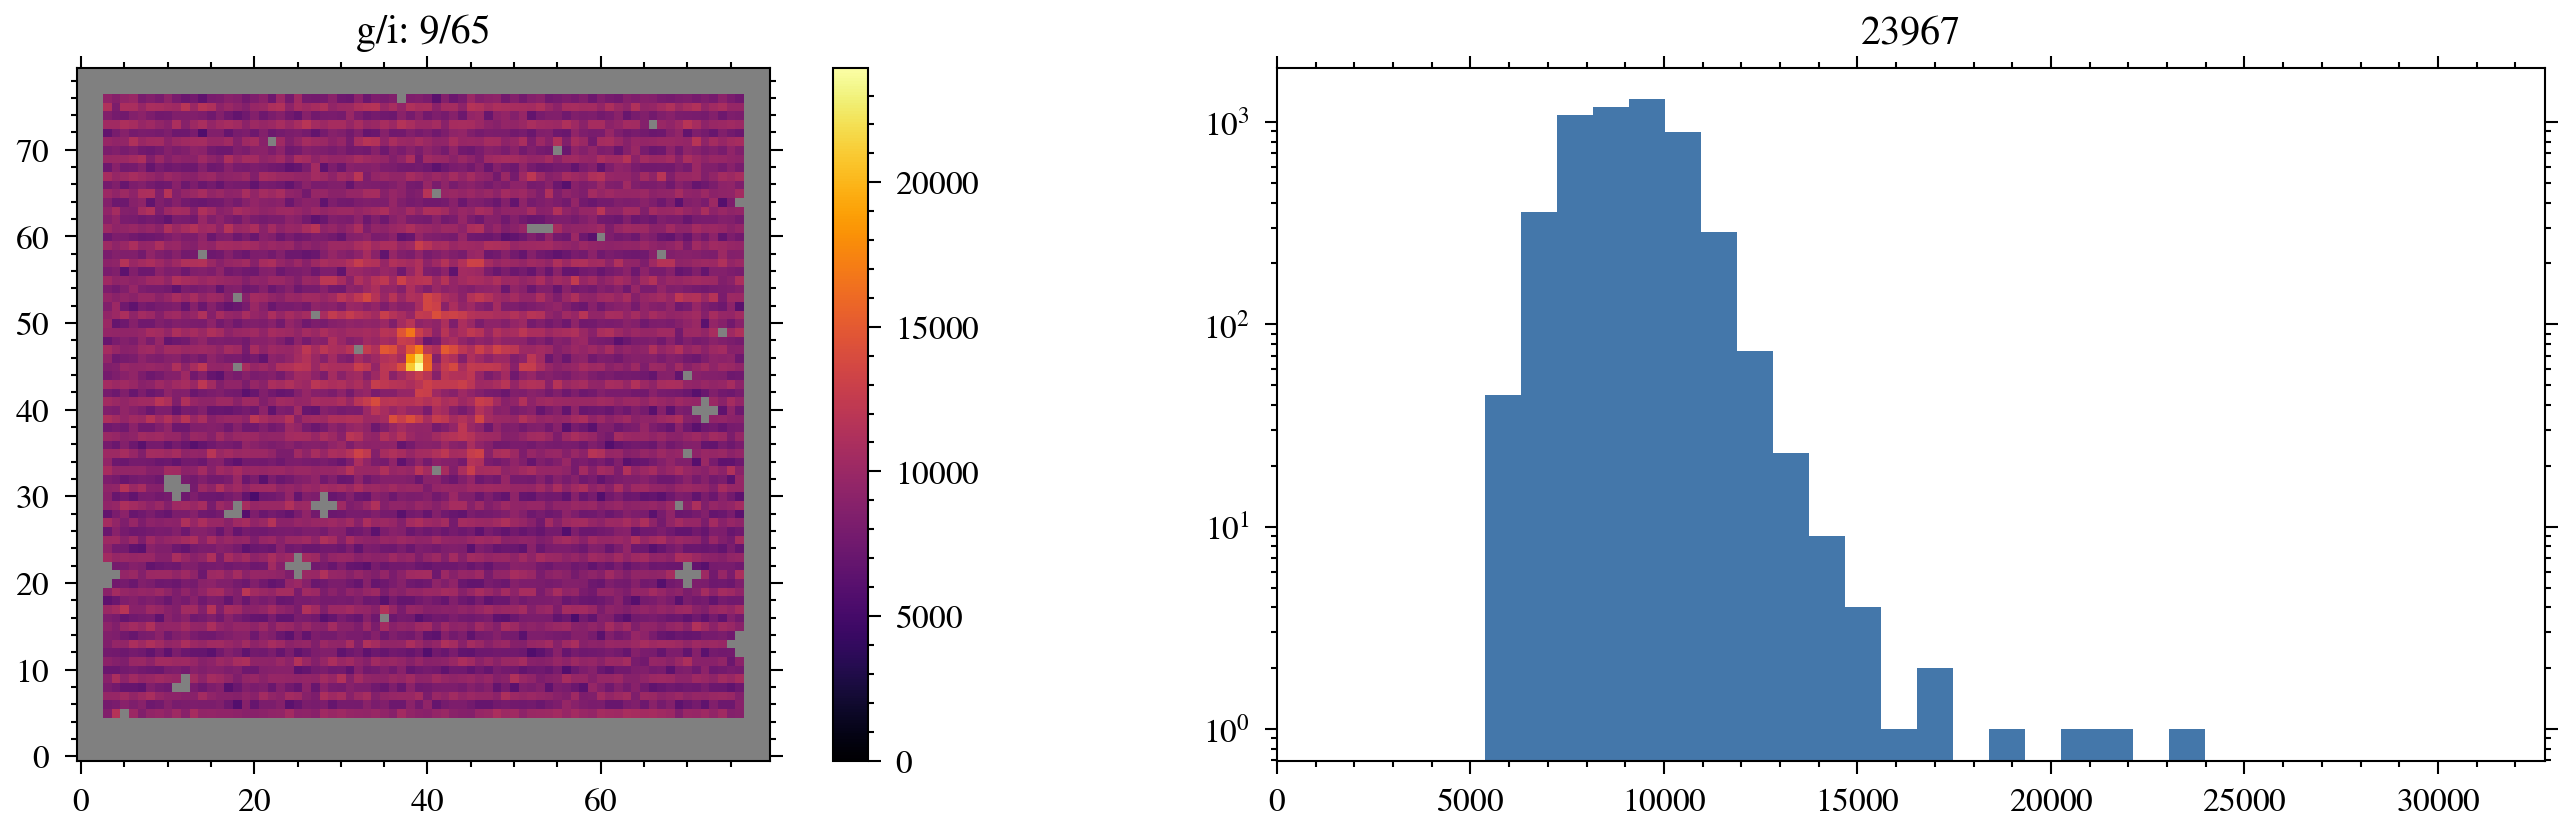




jw01093020001_03102_00006_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   6/25  9/65  05-06-2022  Thatte, Deepashri  True


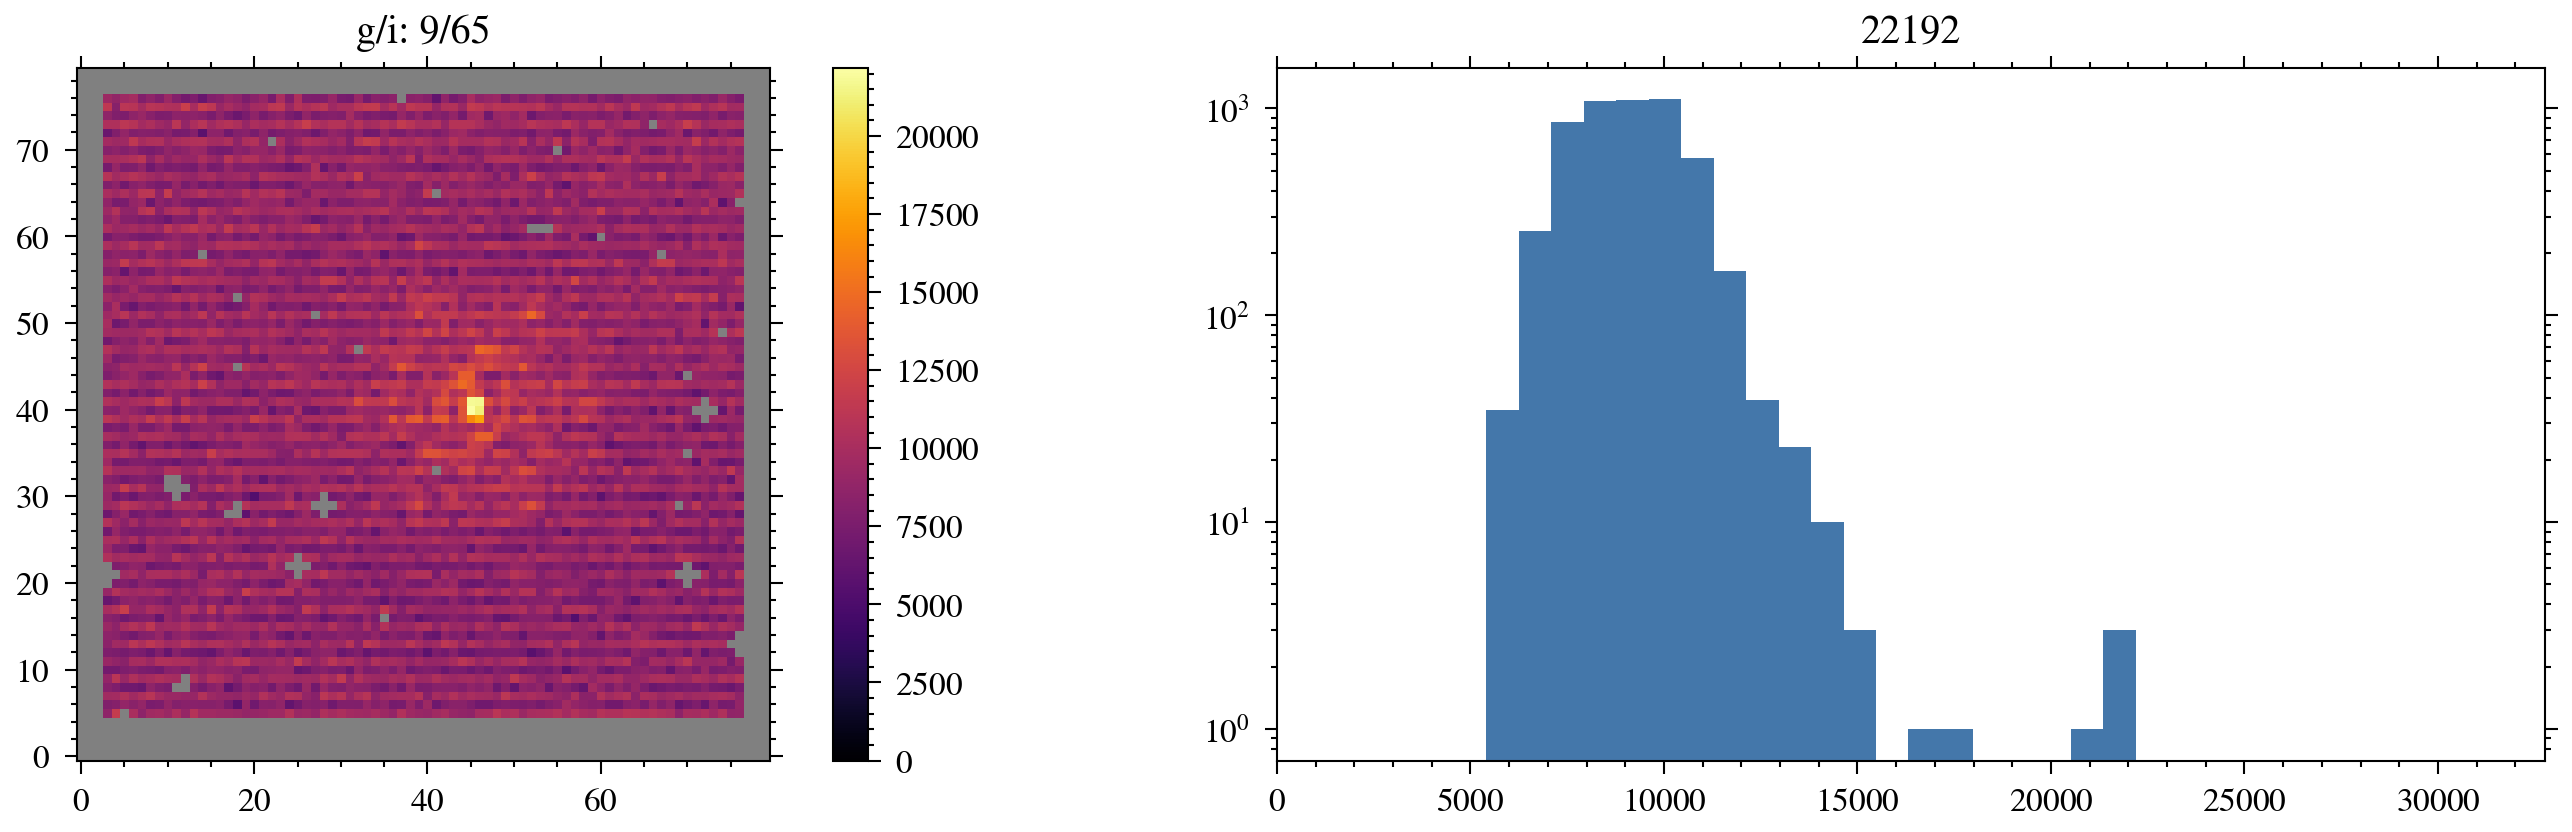




jw01093020001_03102_00007_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   7/25  9/65  05-06-2022  Thatte, Deepashri  True


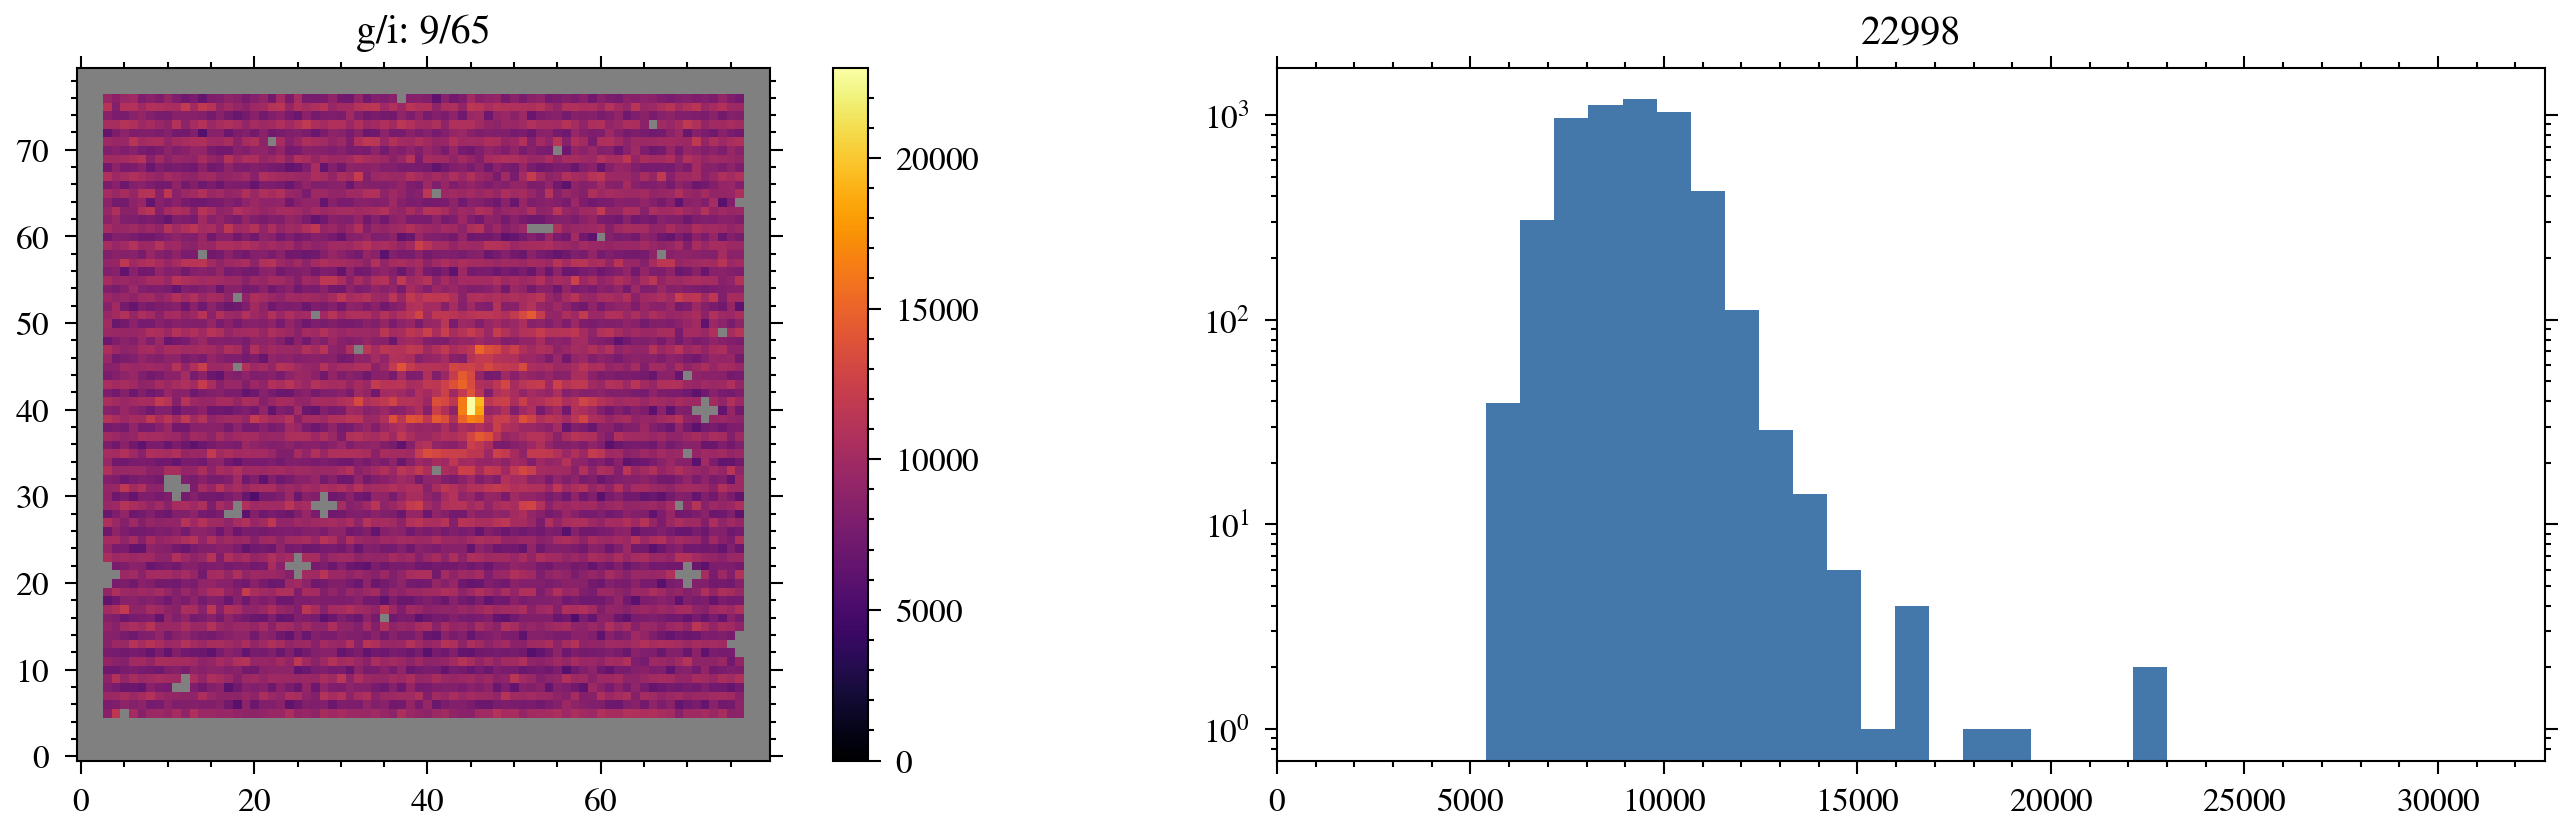




jw01093007001_03102_00019_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  19/25  9/65  23-05-2022  Thatte, Deepashri  True


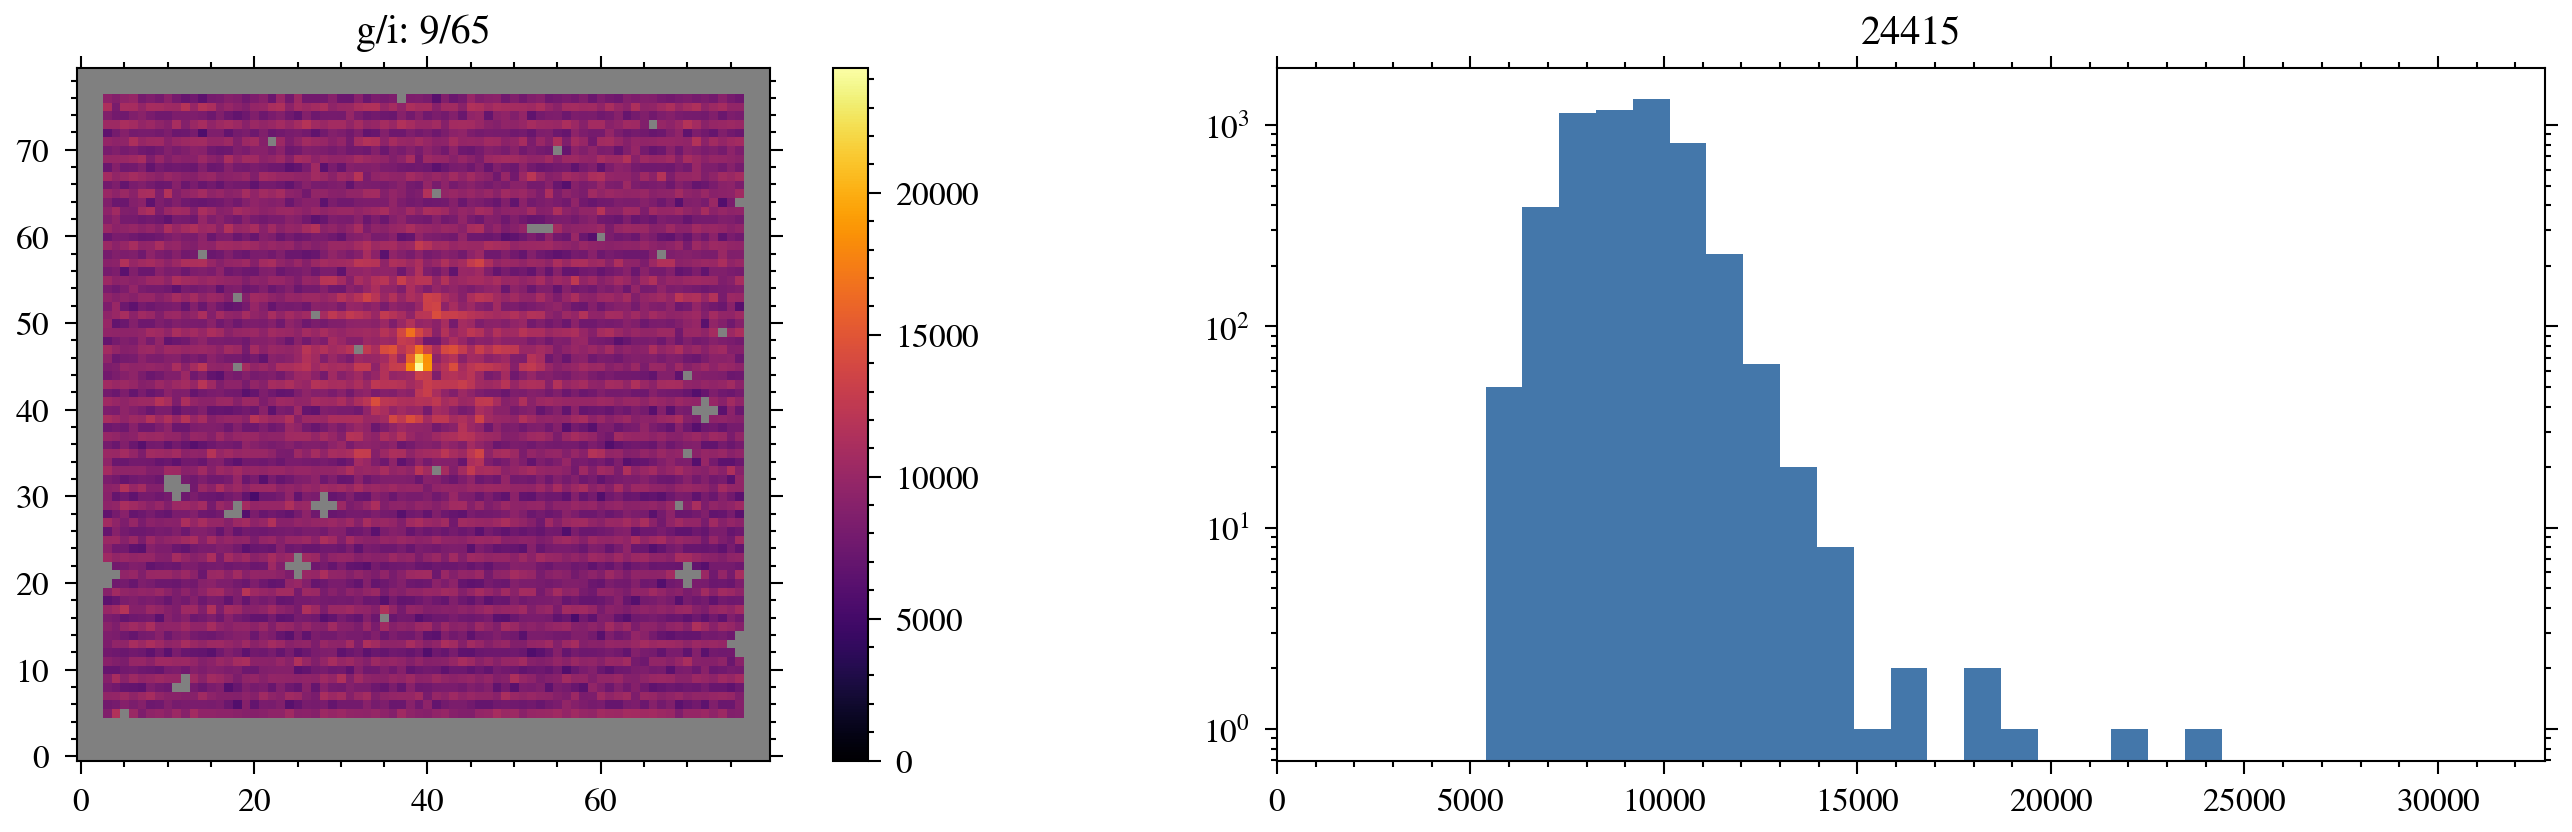




jw01093020001_03102_00005_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   5/25  9/65  05-06-2022  Thatte, Deepashri  True


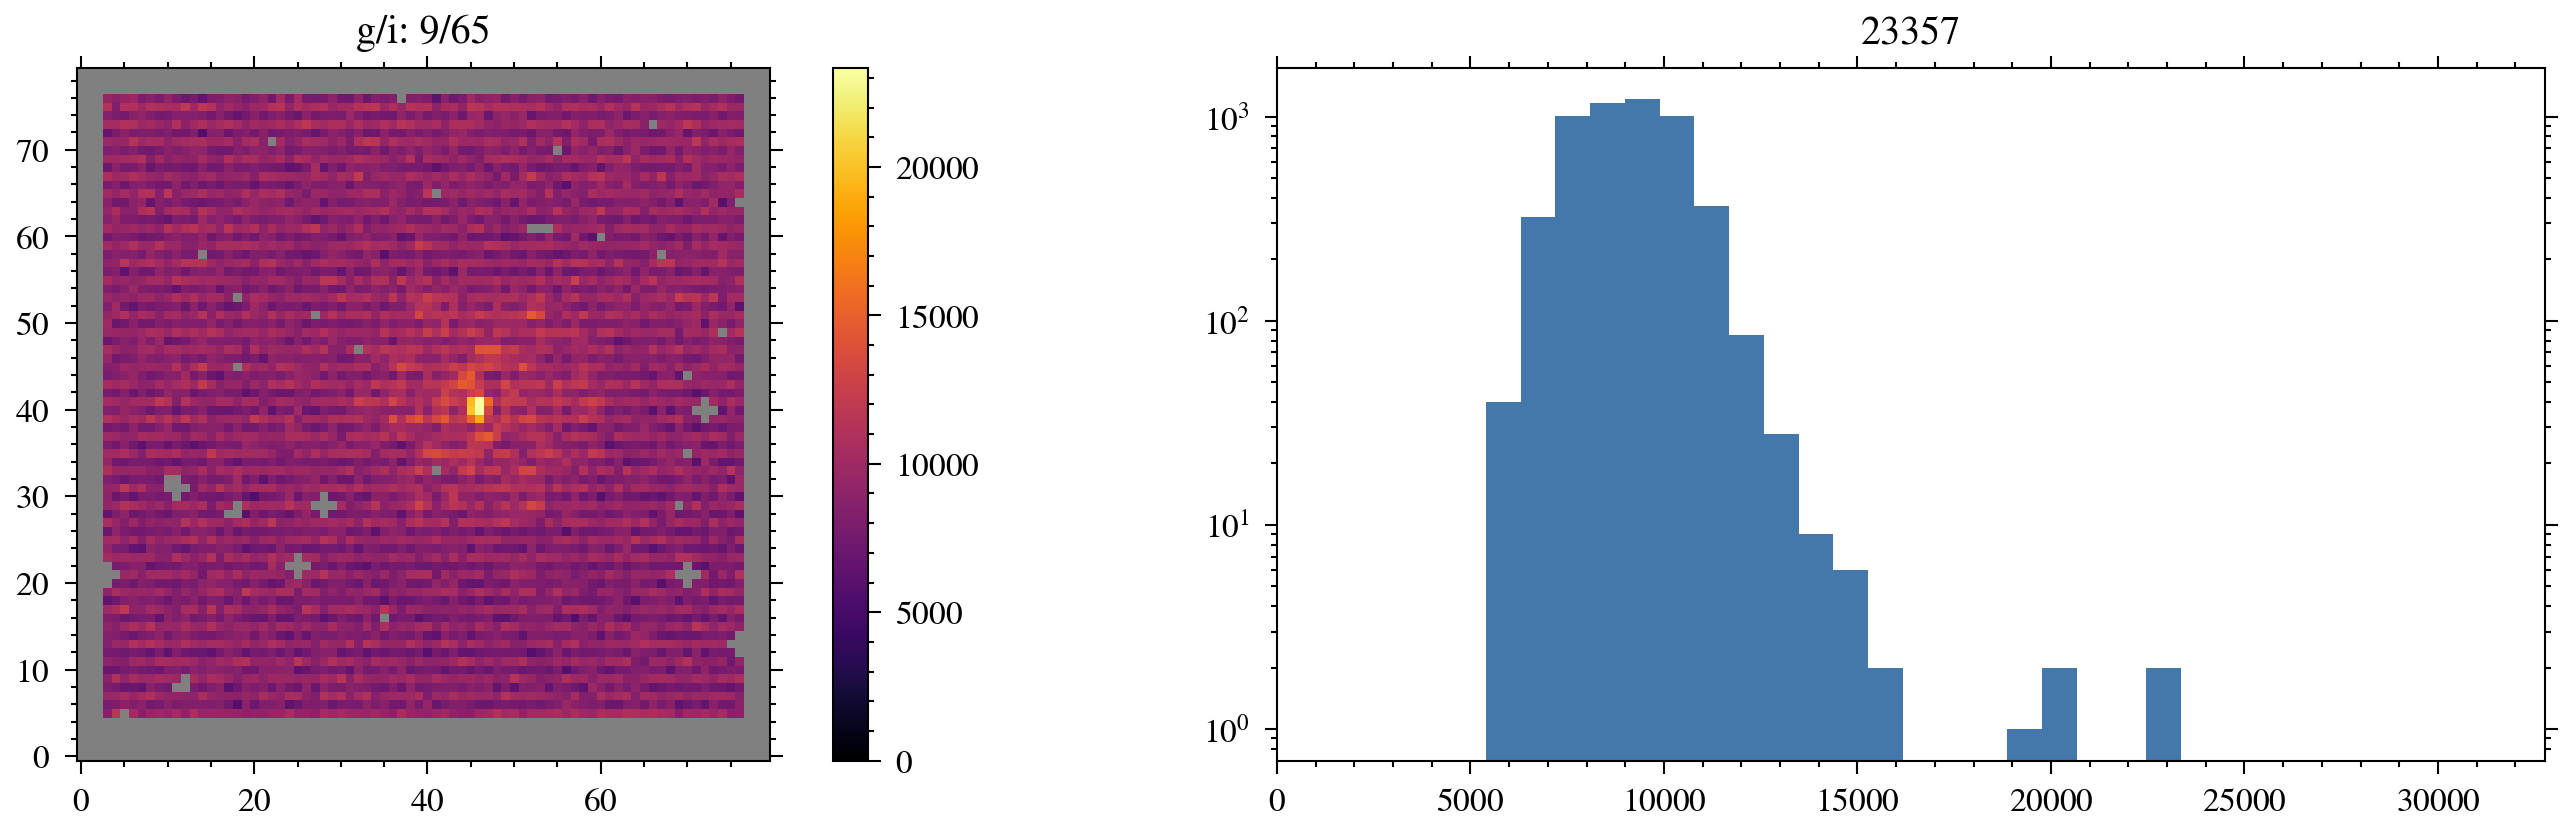




jw01093006001_03102_00002_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M    2/2  9/65  23-05-2022  Thatte, Deepashri  True


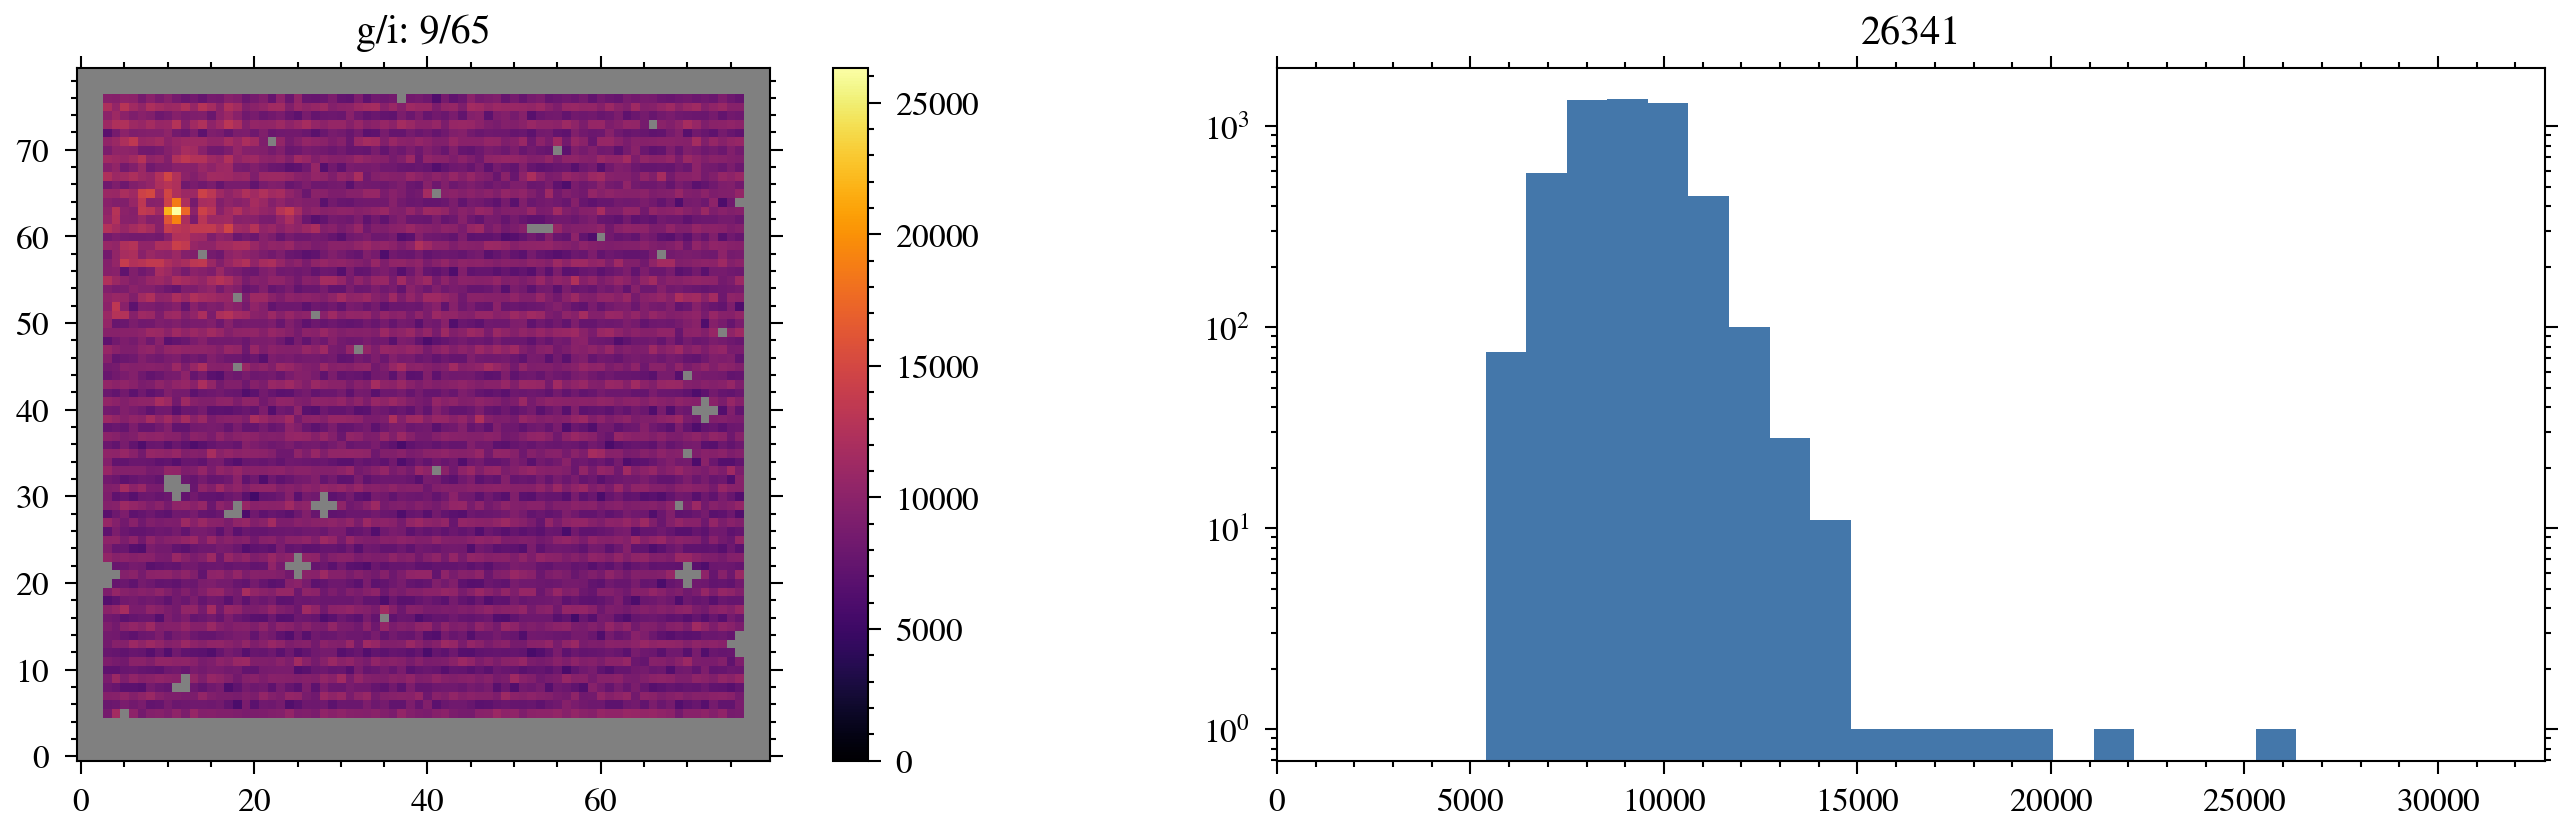




jw01093007001_03102_00022_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  22/25  9/65  23-05-2022  Thatte, Deepashri  True


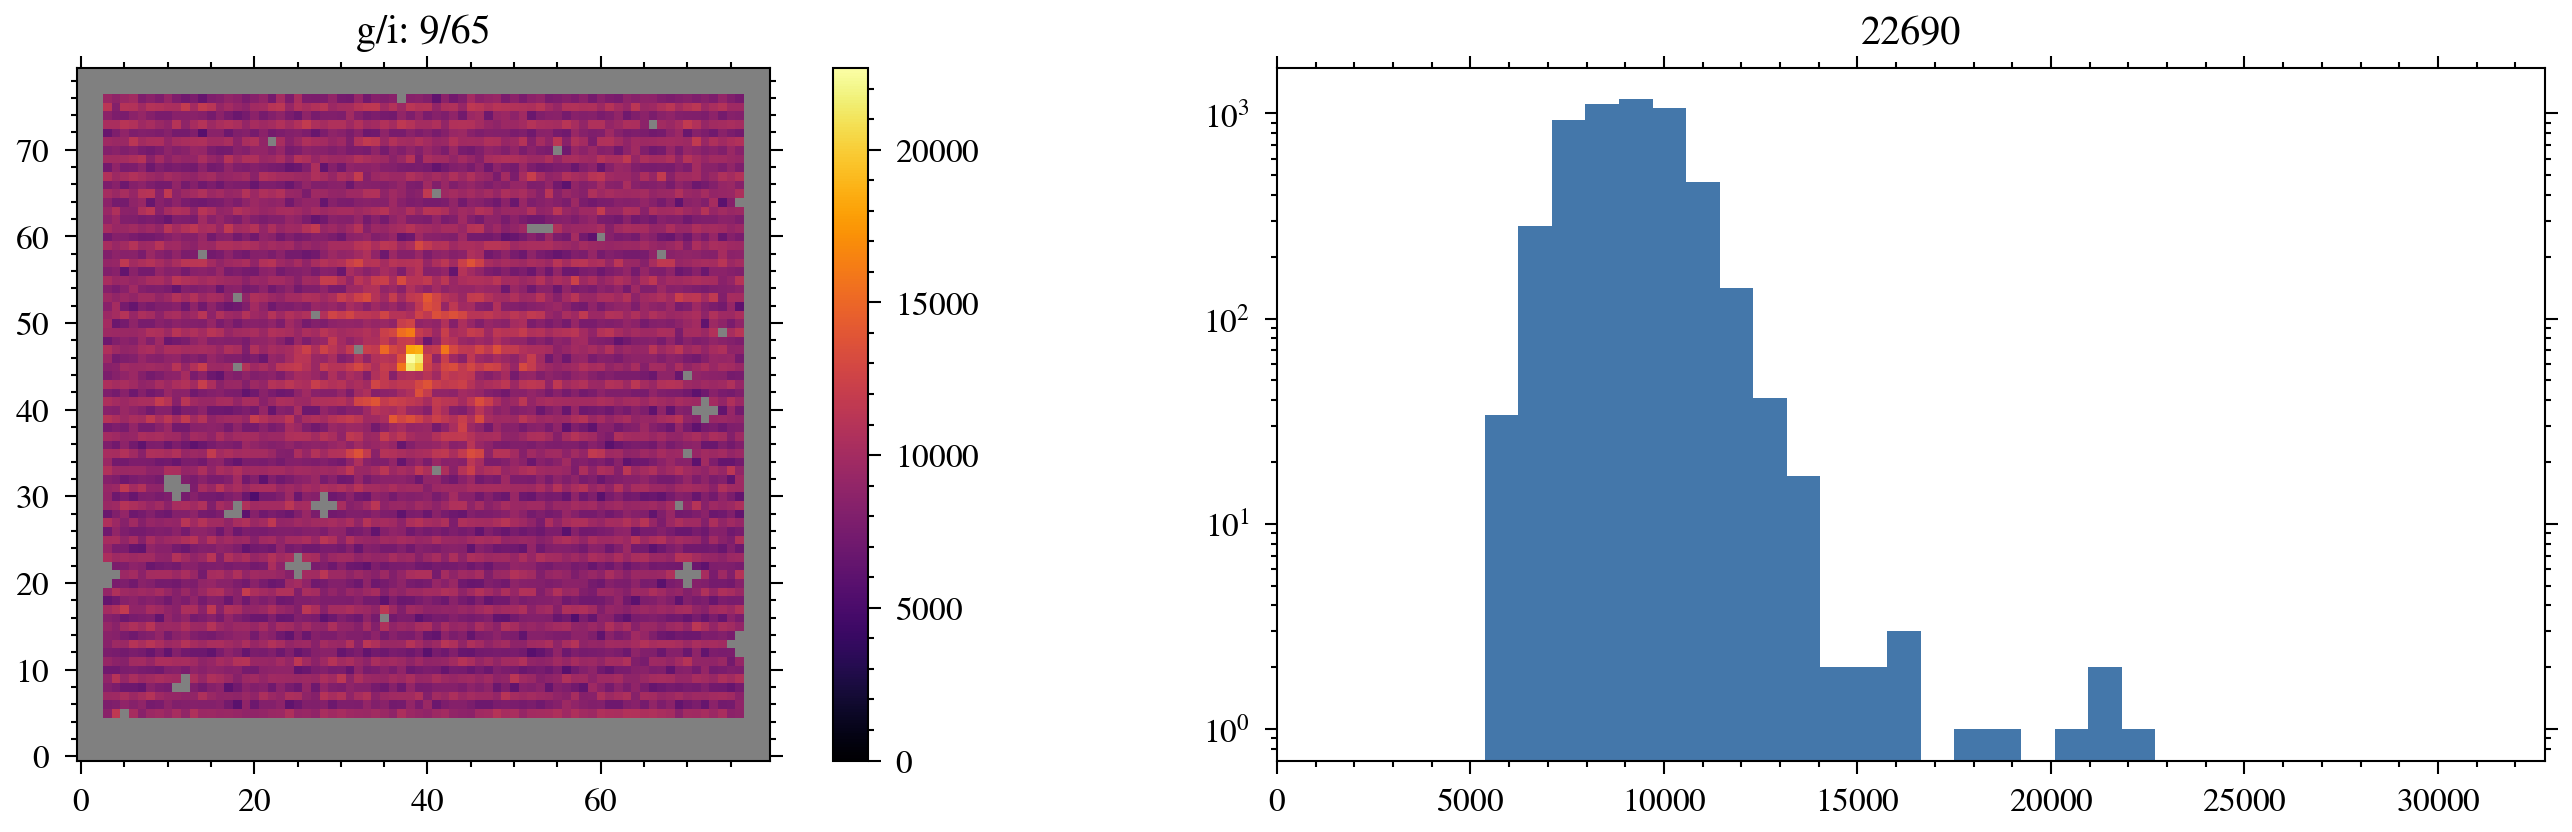




jw01093020001_03102_00023_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  23/25  9/65  05-06-2022  Thatte, Deepashri  True


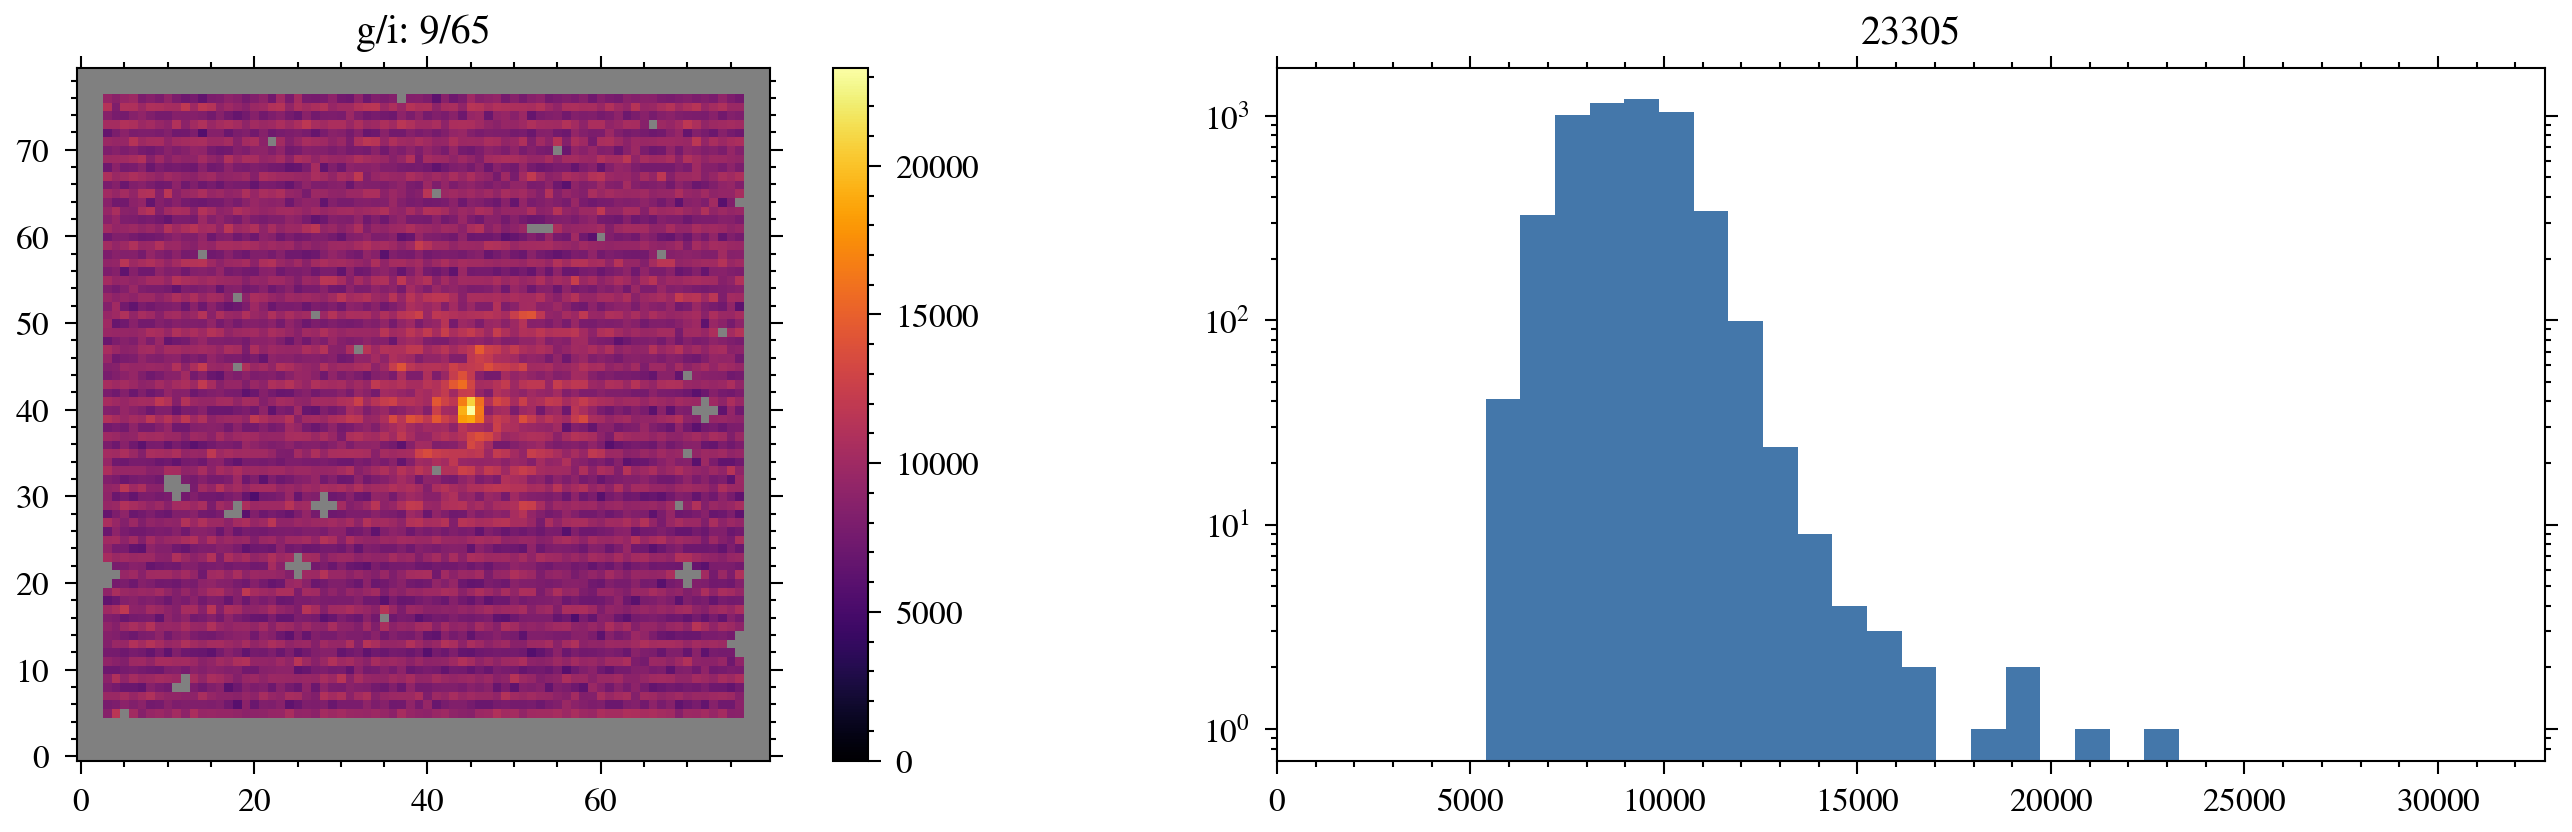




jw01093018001_03104_00001_nis
  program    target filter dither    g/i        date                 PI   CAL
0    1093  HD-36805  F380M    1/1  3/122  05-06-2022  Thatte, Deepashri  True


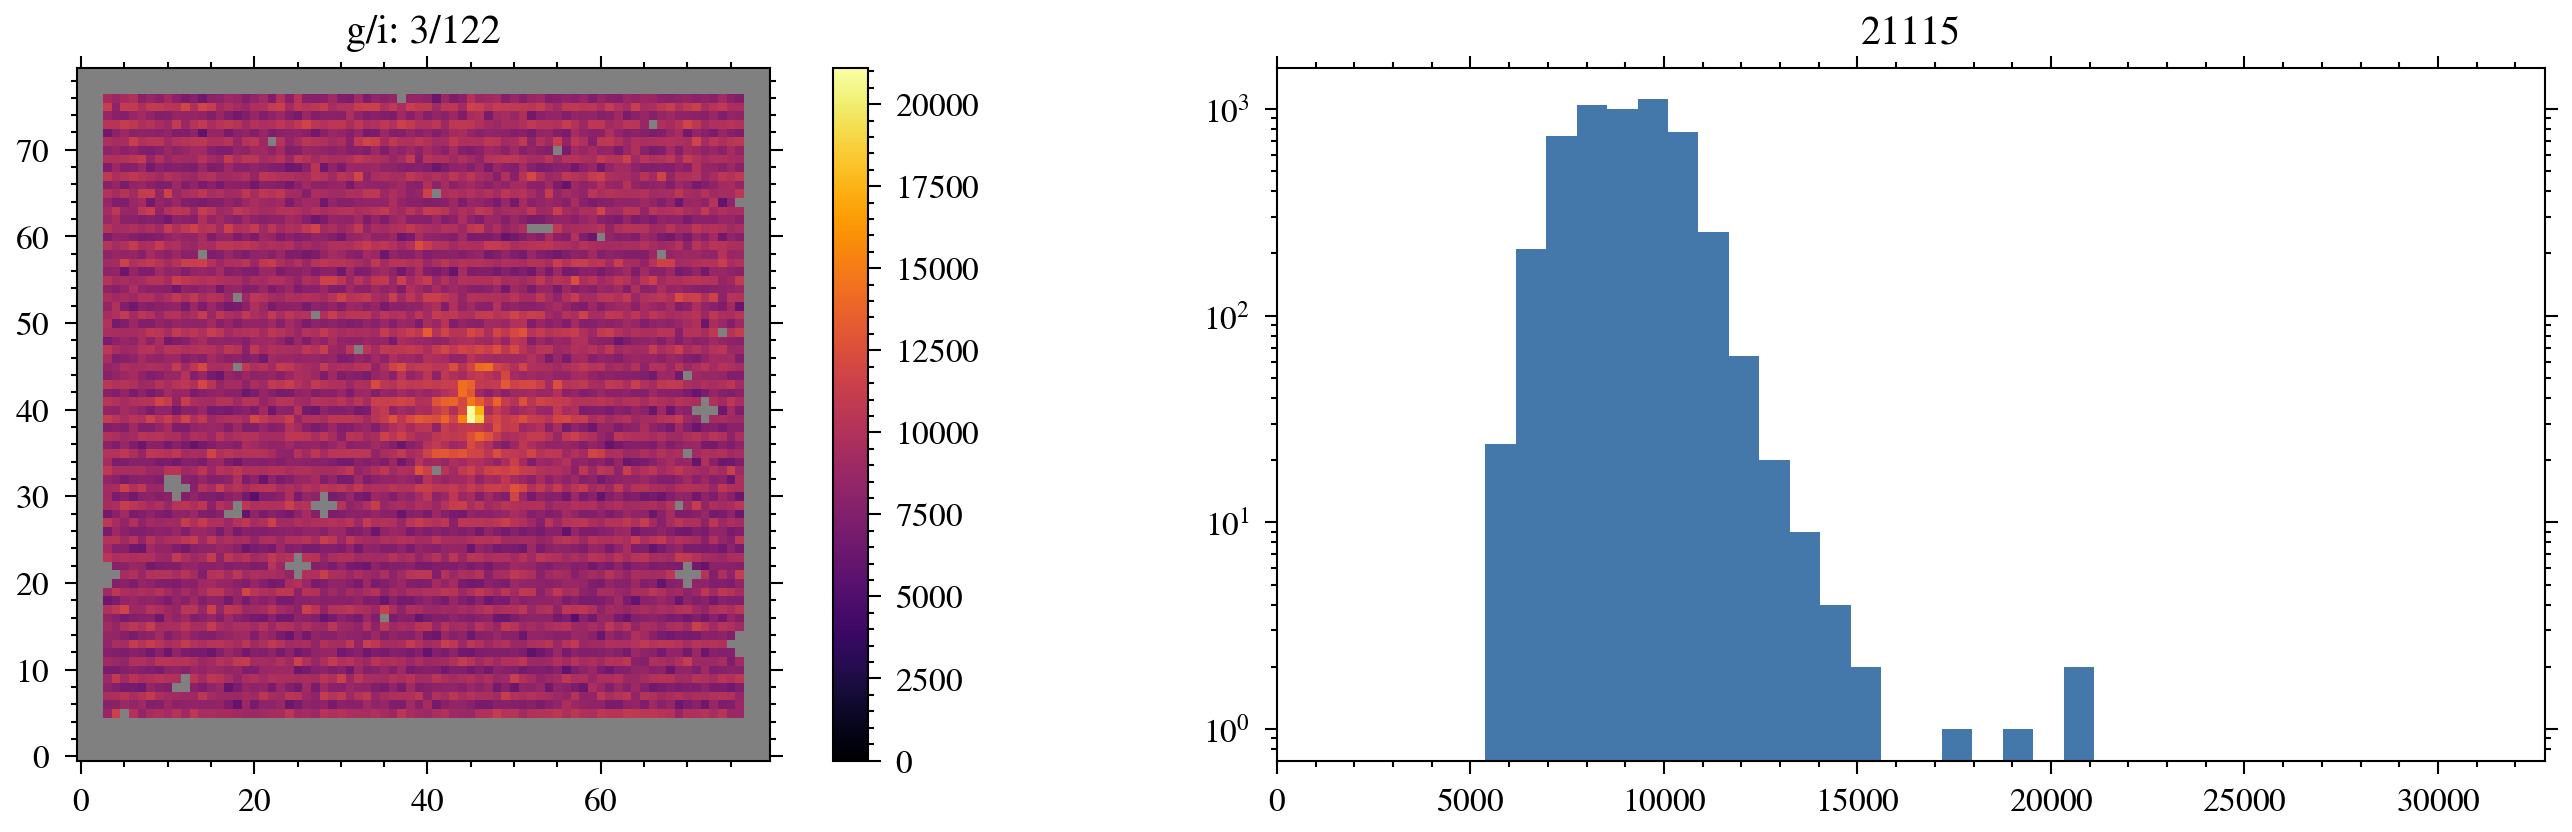




jw01093018001_03102_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M    1/1  9/65  05-06-2022  Thatte, Deepashri  True


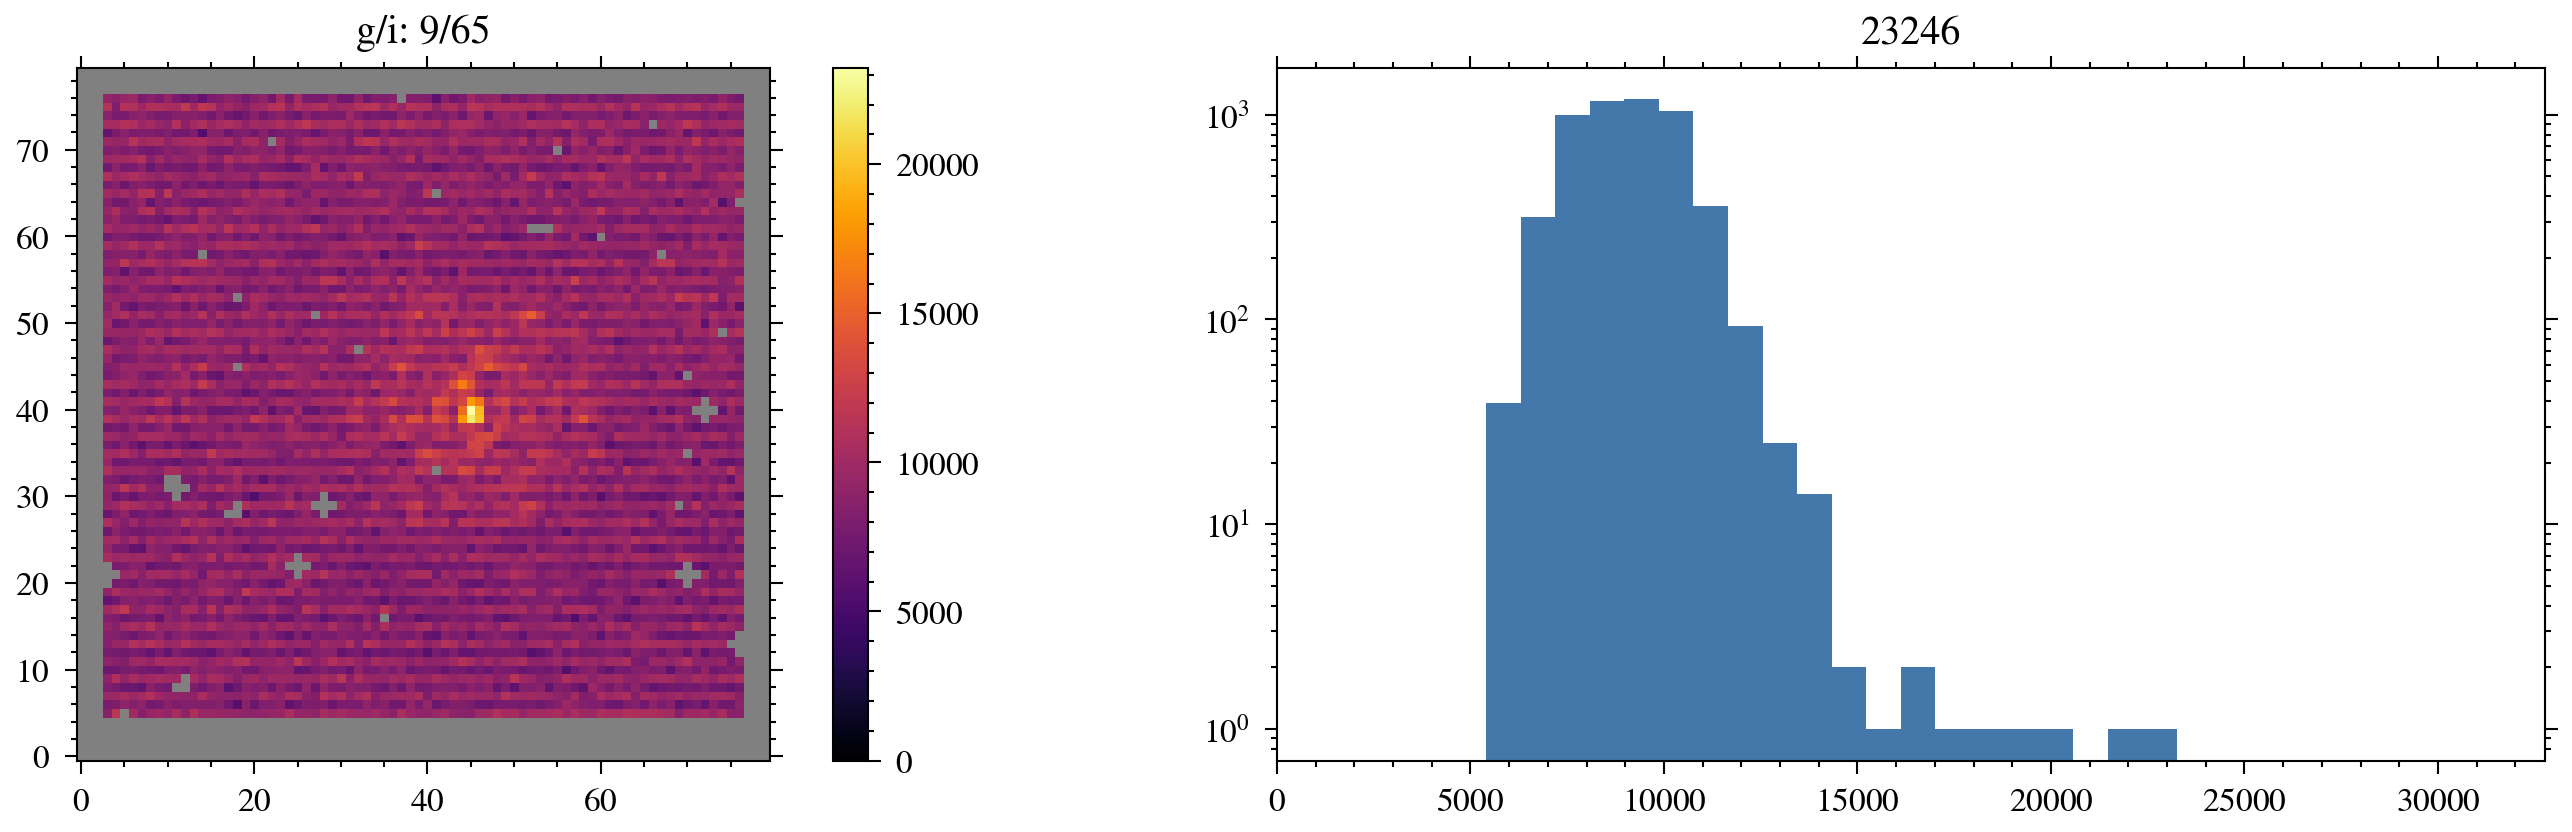




jw01093007001_03102_00015_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  15/25  9/65  23-05-2022  Thatte, Deepashri  True


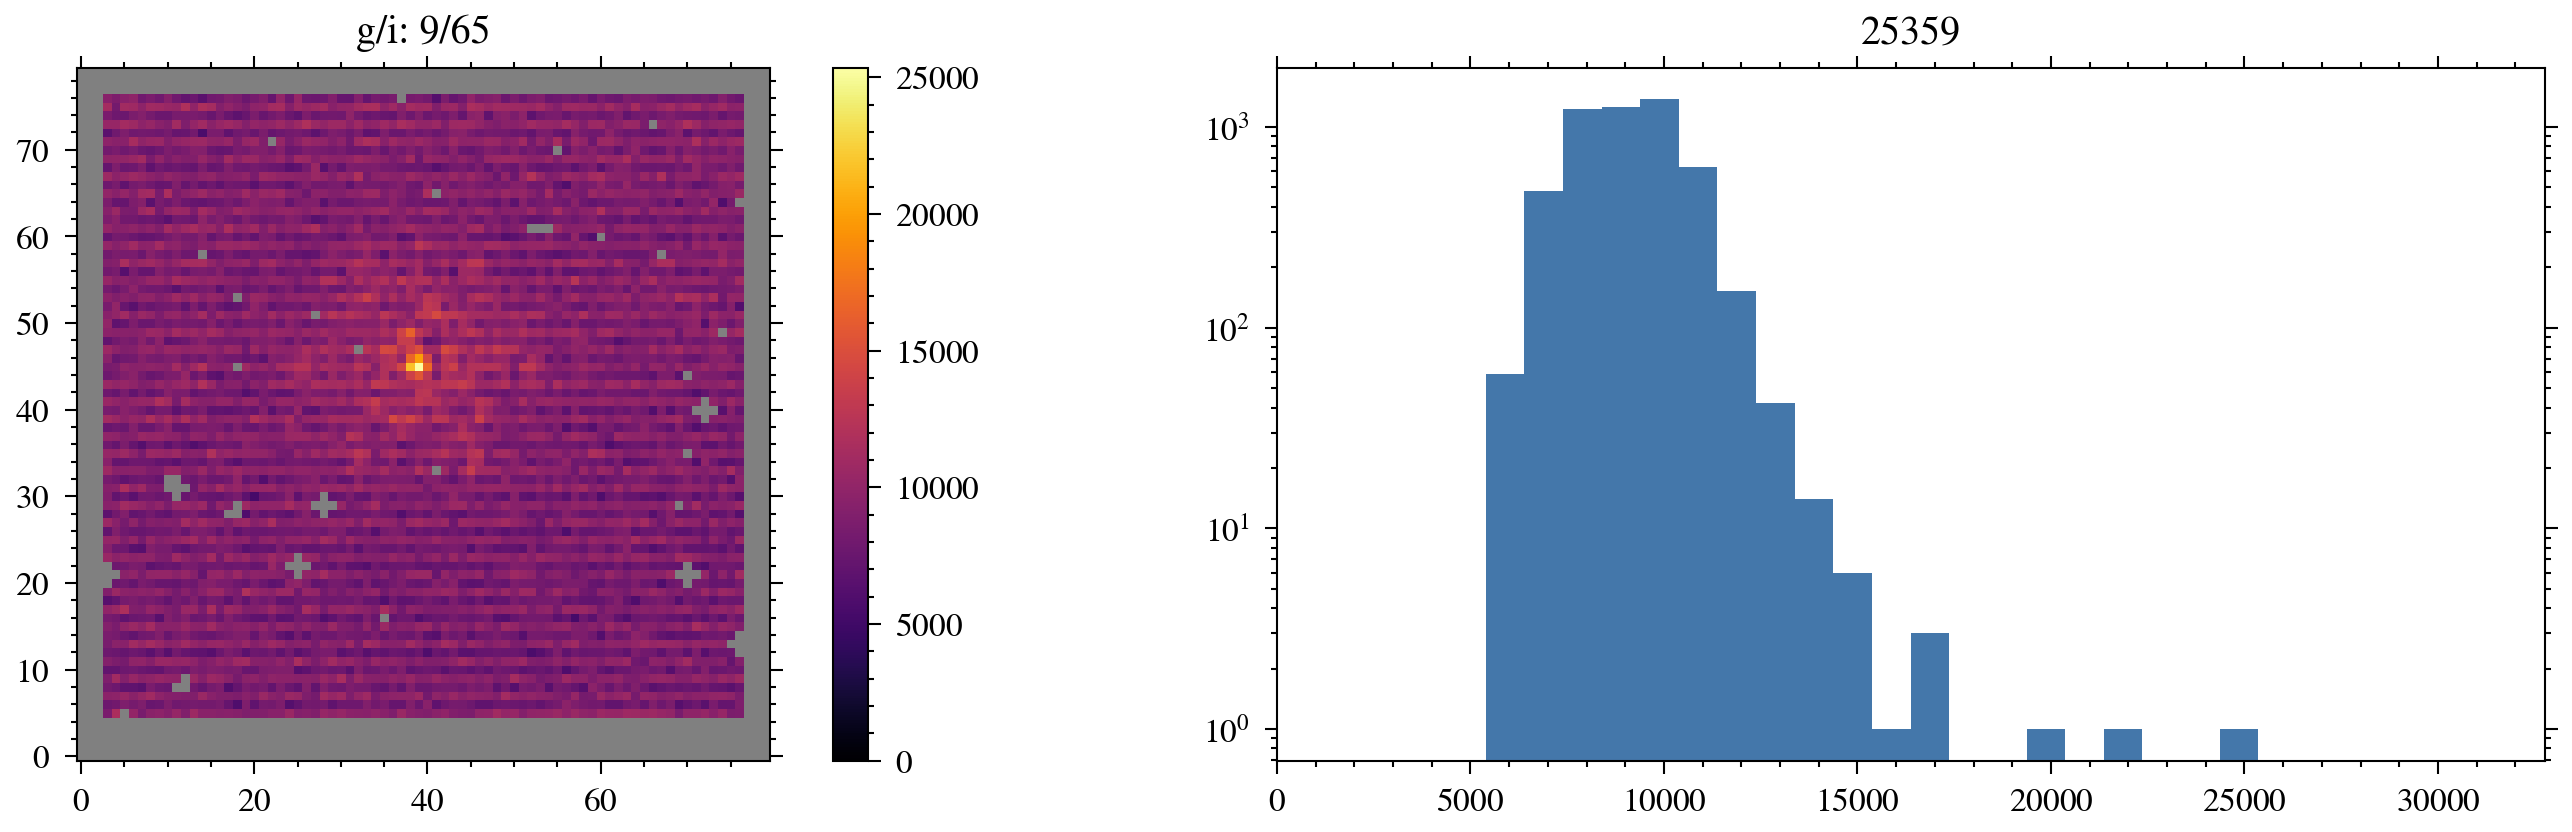




jw01093007001_03102_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   1/25  9/65  23-05-2022  Thatte, Deepashri  True


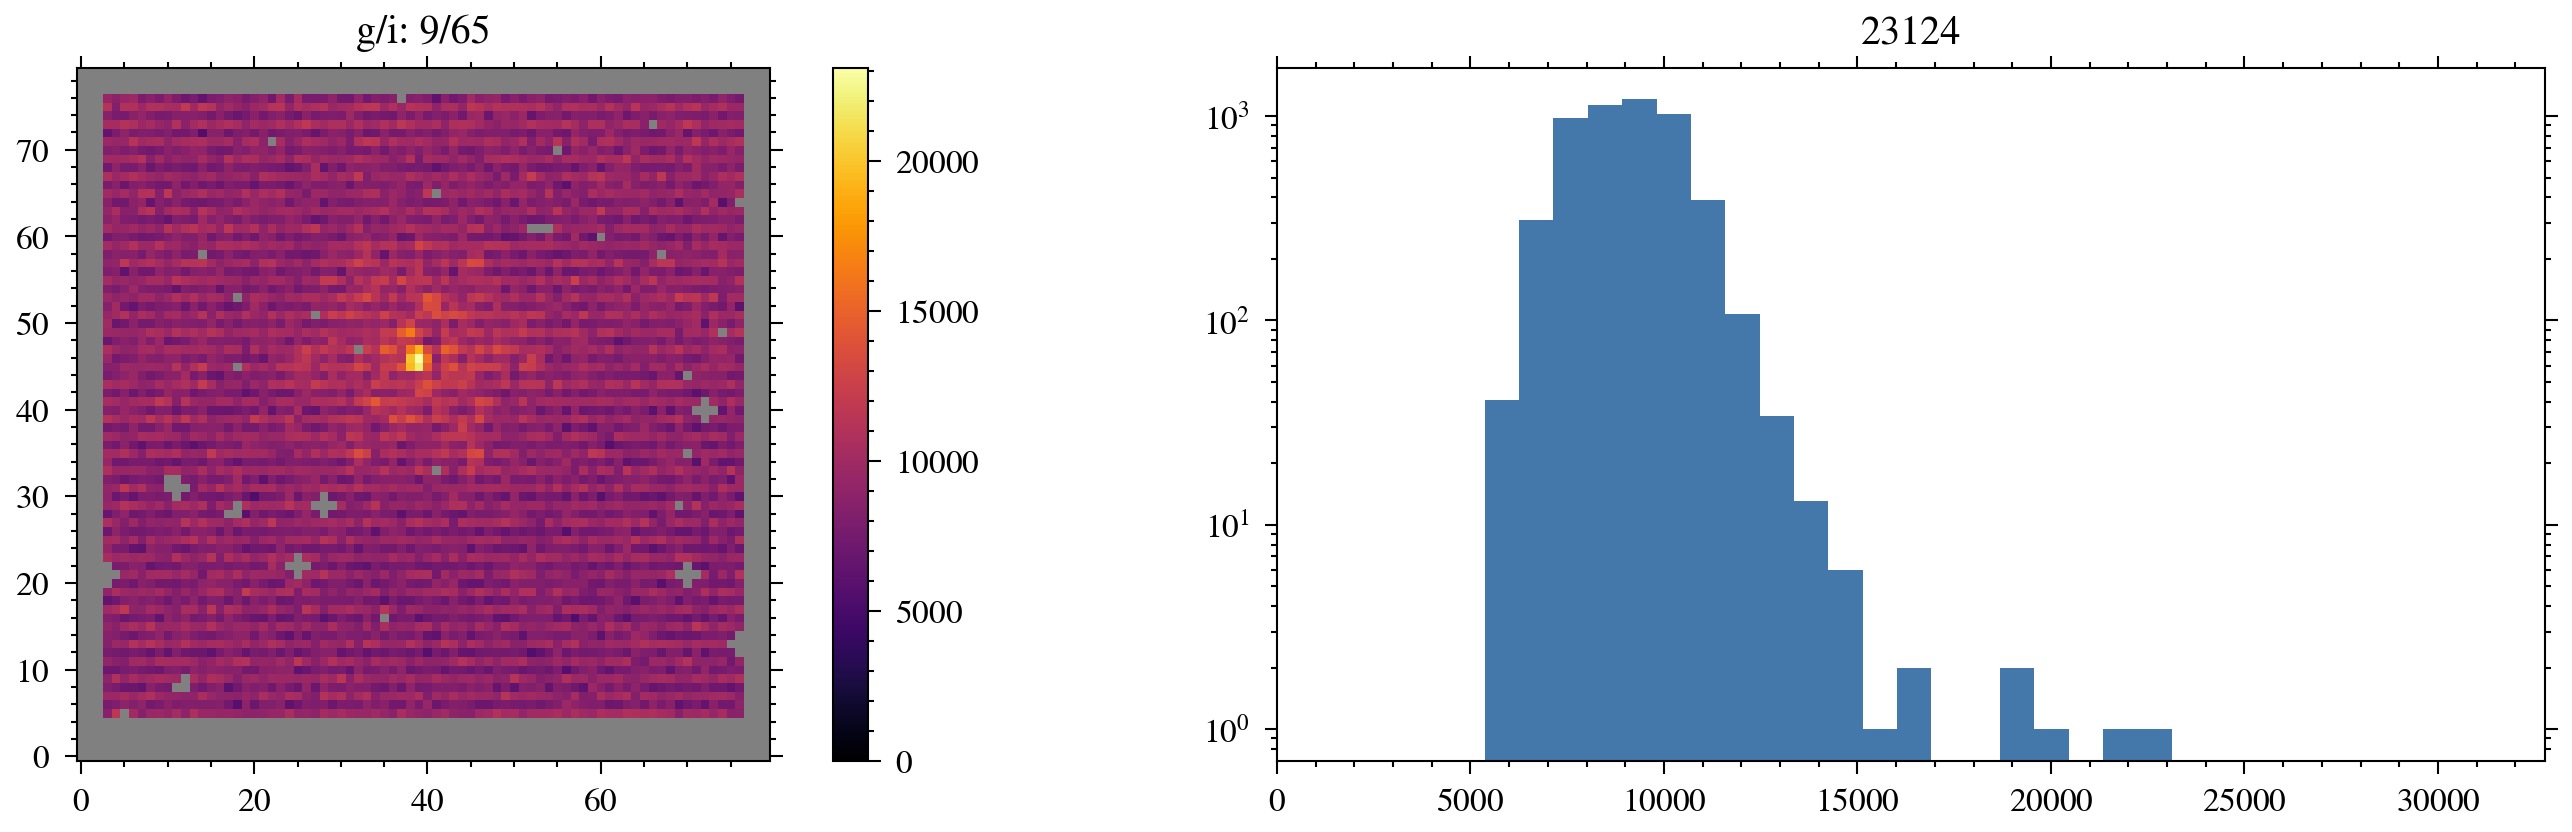




jw01093020001_03102_00013_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  13/25  9/65  05-06-2022  Thatte, Deepashri  True


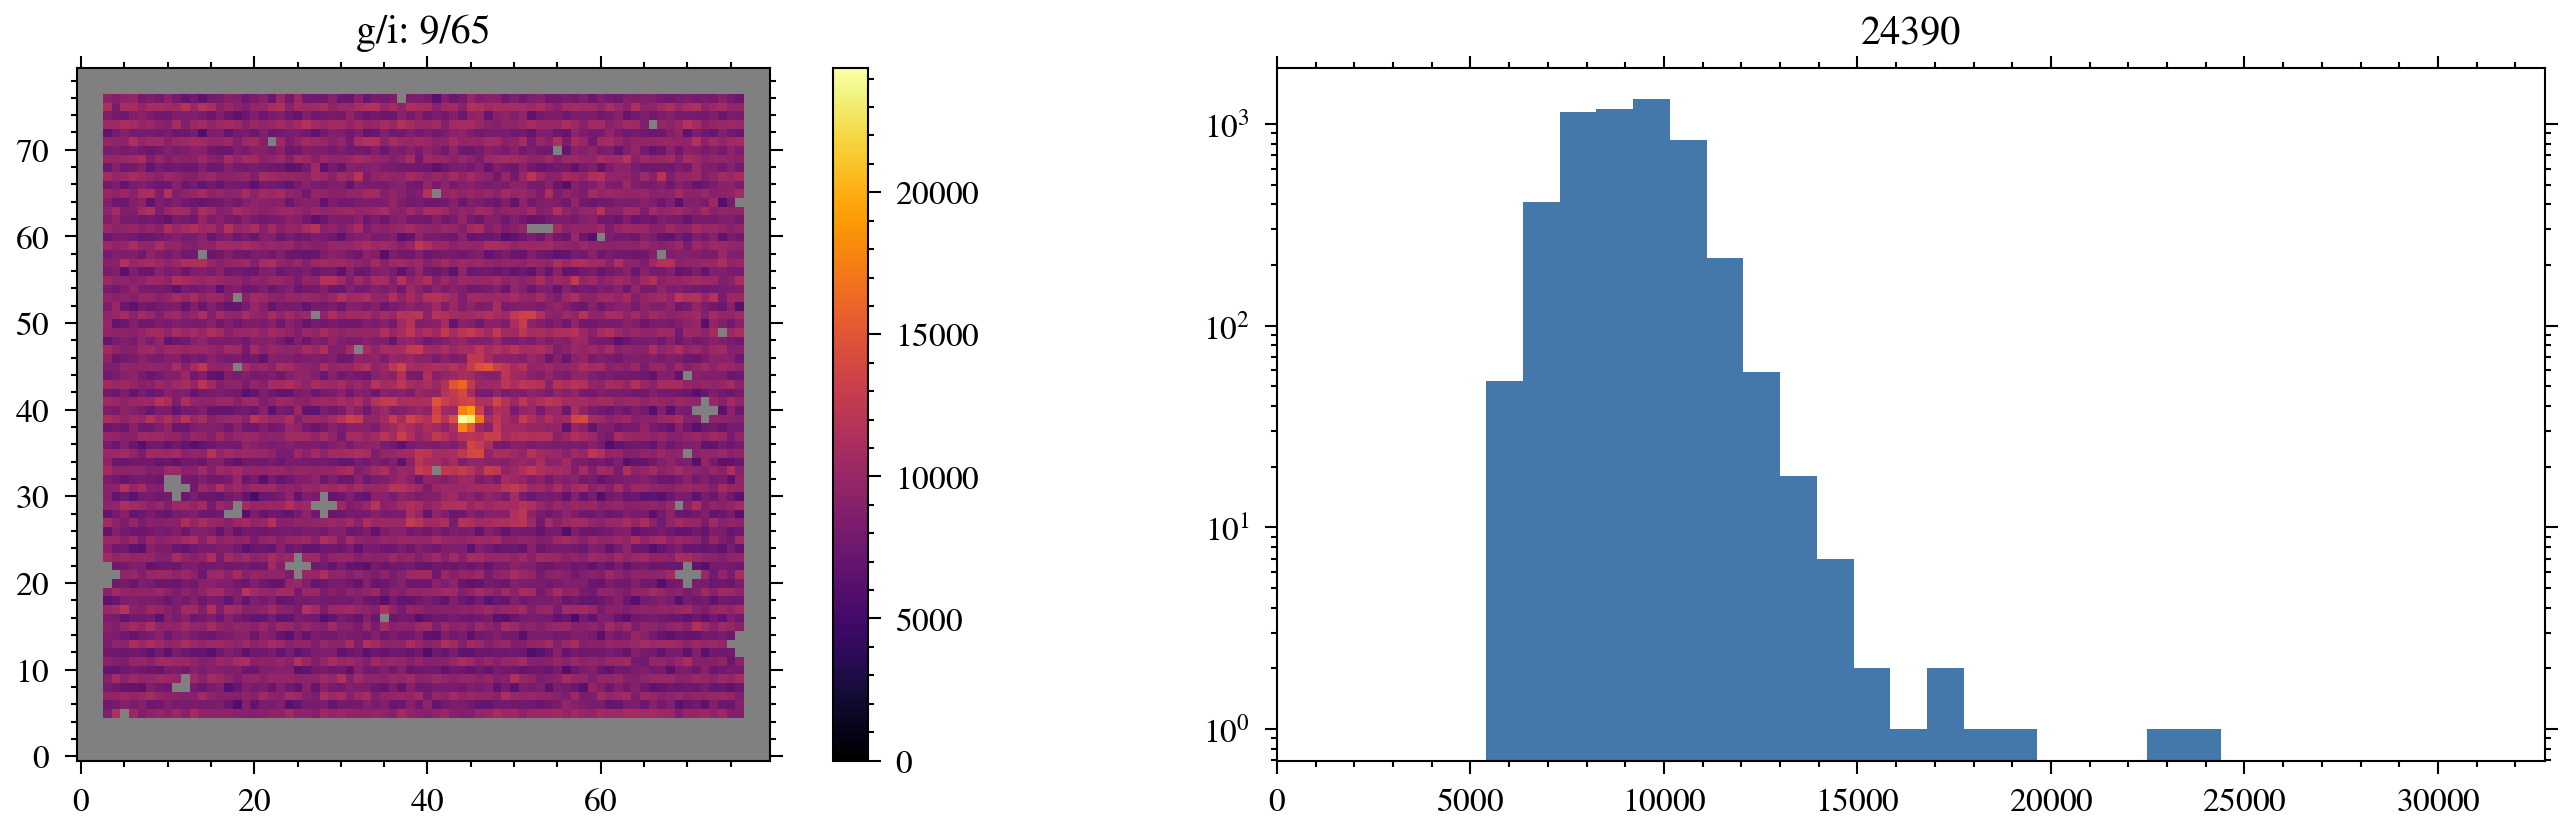




jw01093006001_03102_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M    1/2  9/65  23-05-2022  Thatte, Deepashri  True


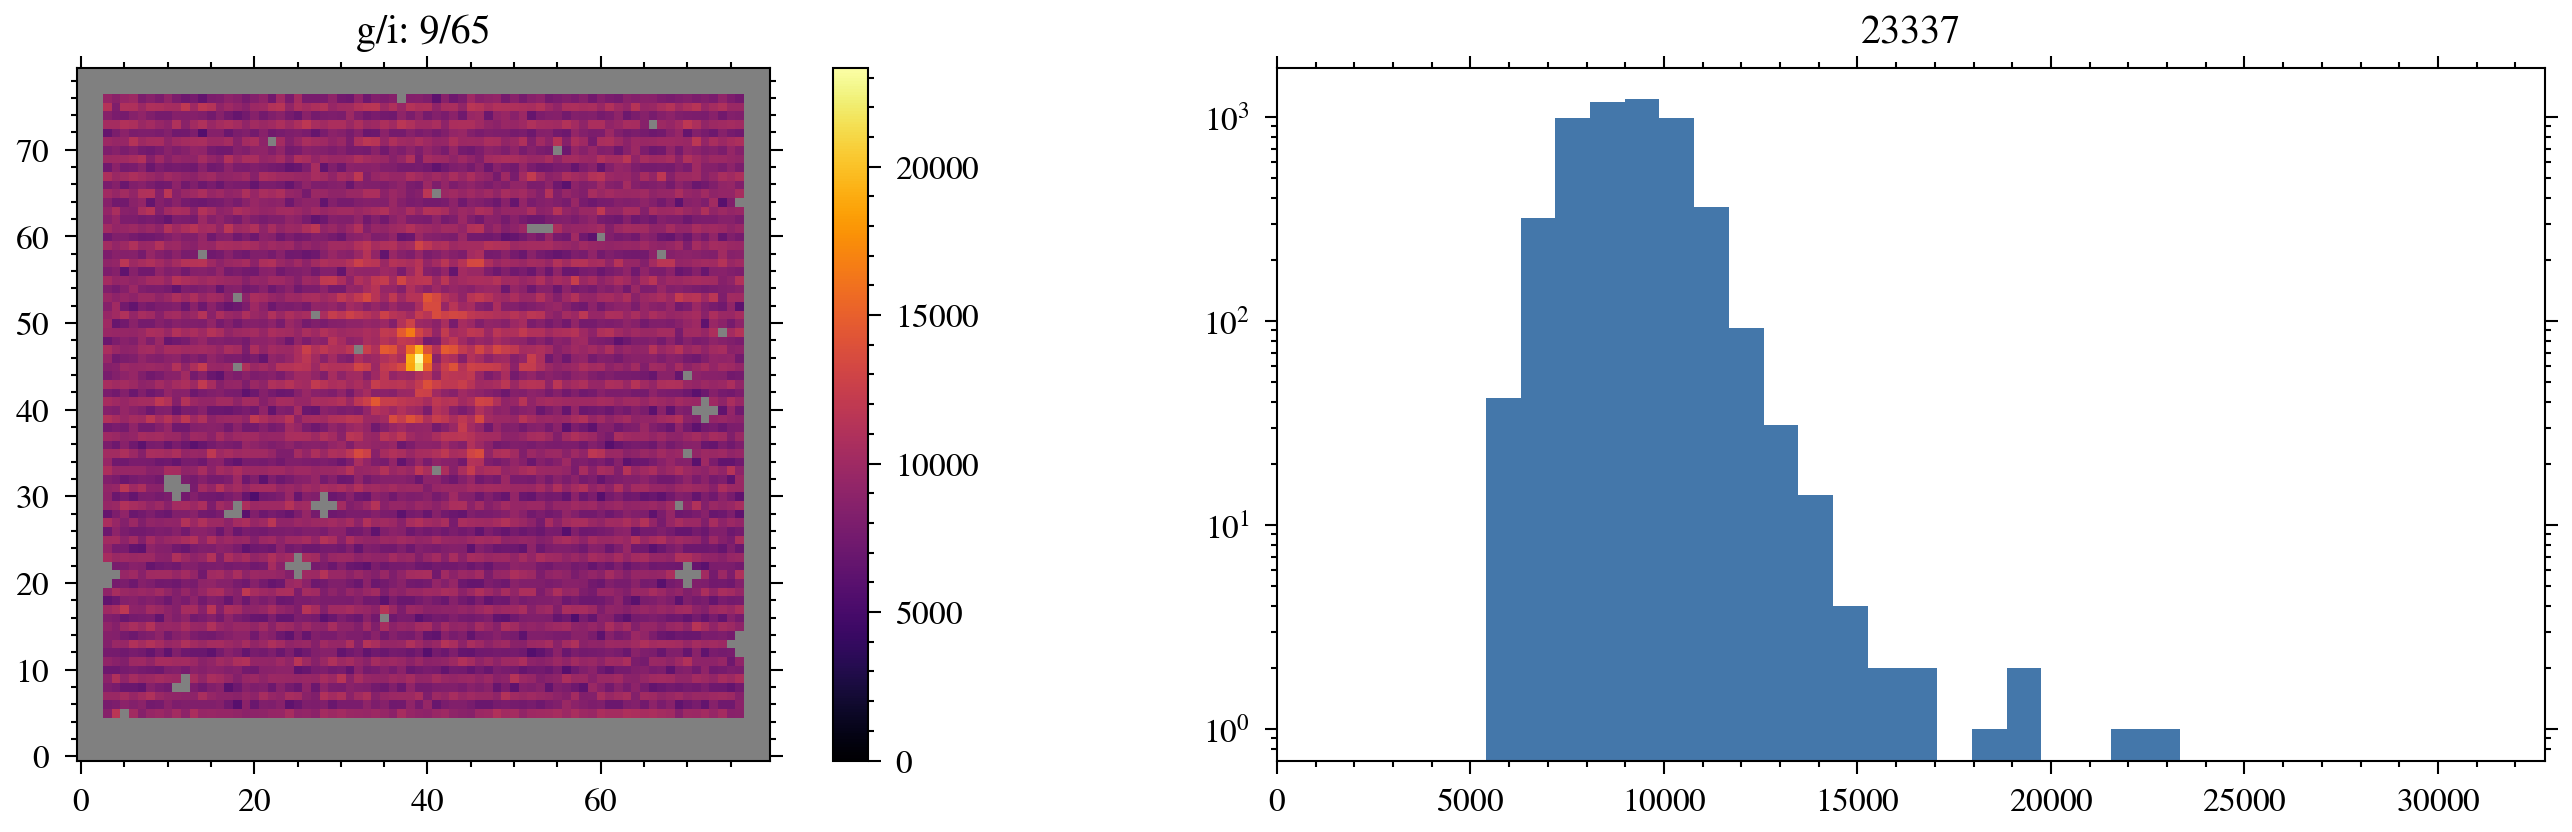




jw01093007001_03102_00004_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   4/25  9/65  23-05-2022  Thatte, Deepashri  True


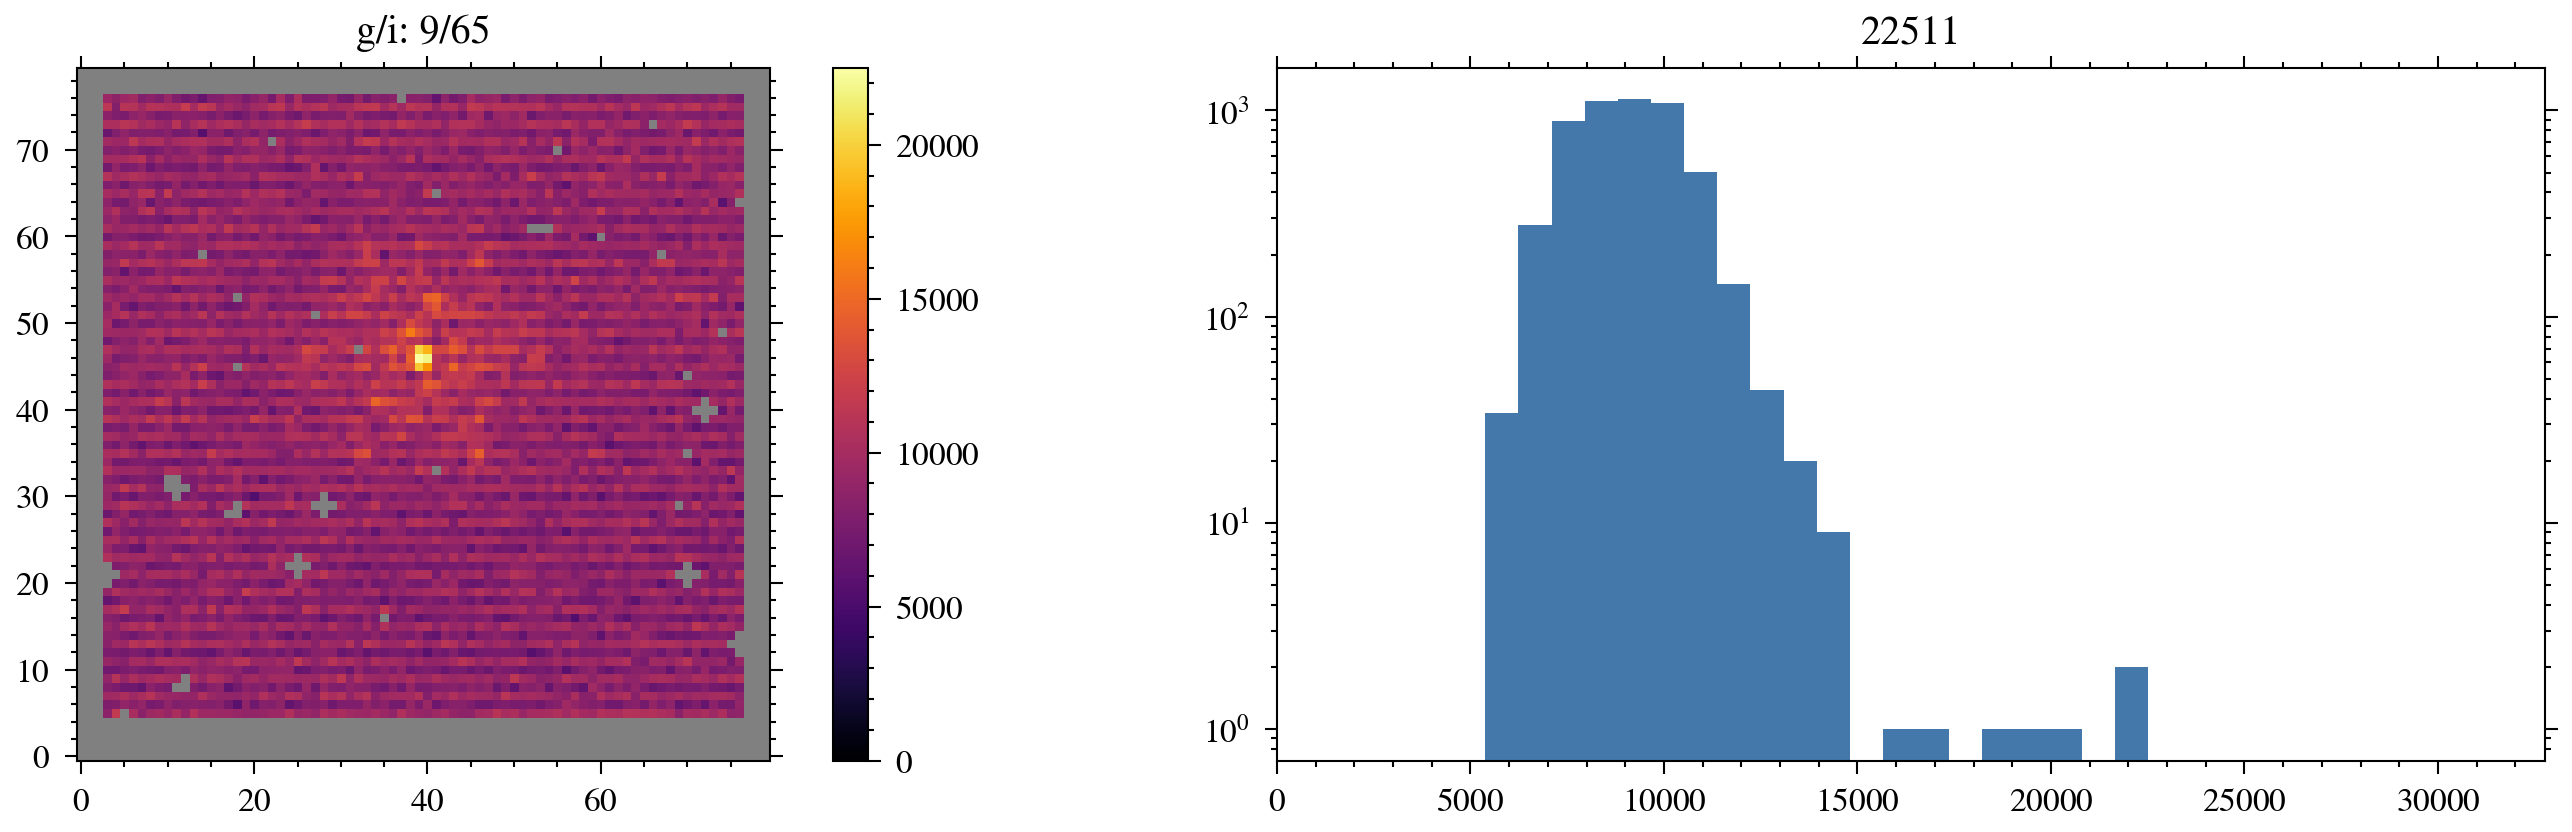




jw01093006001_03104_00002_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F430M    2/2  6/82  23-05-2022  Thatte, Deepashri  True


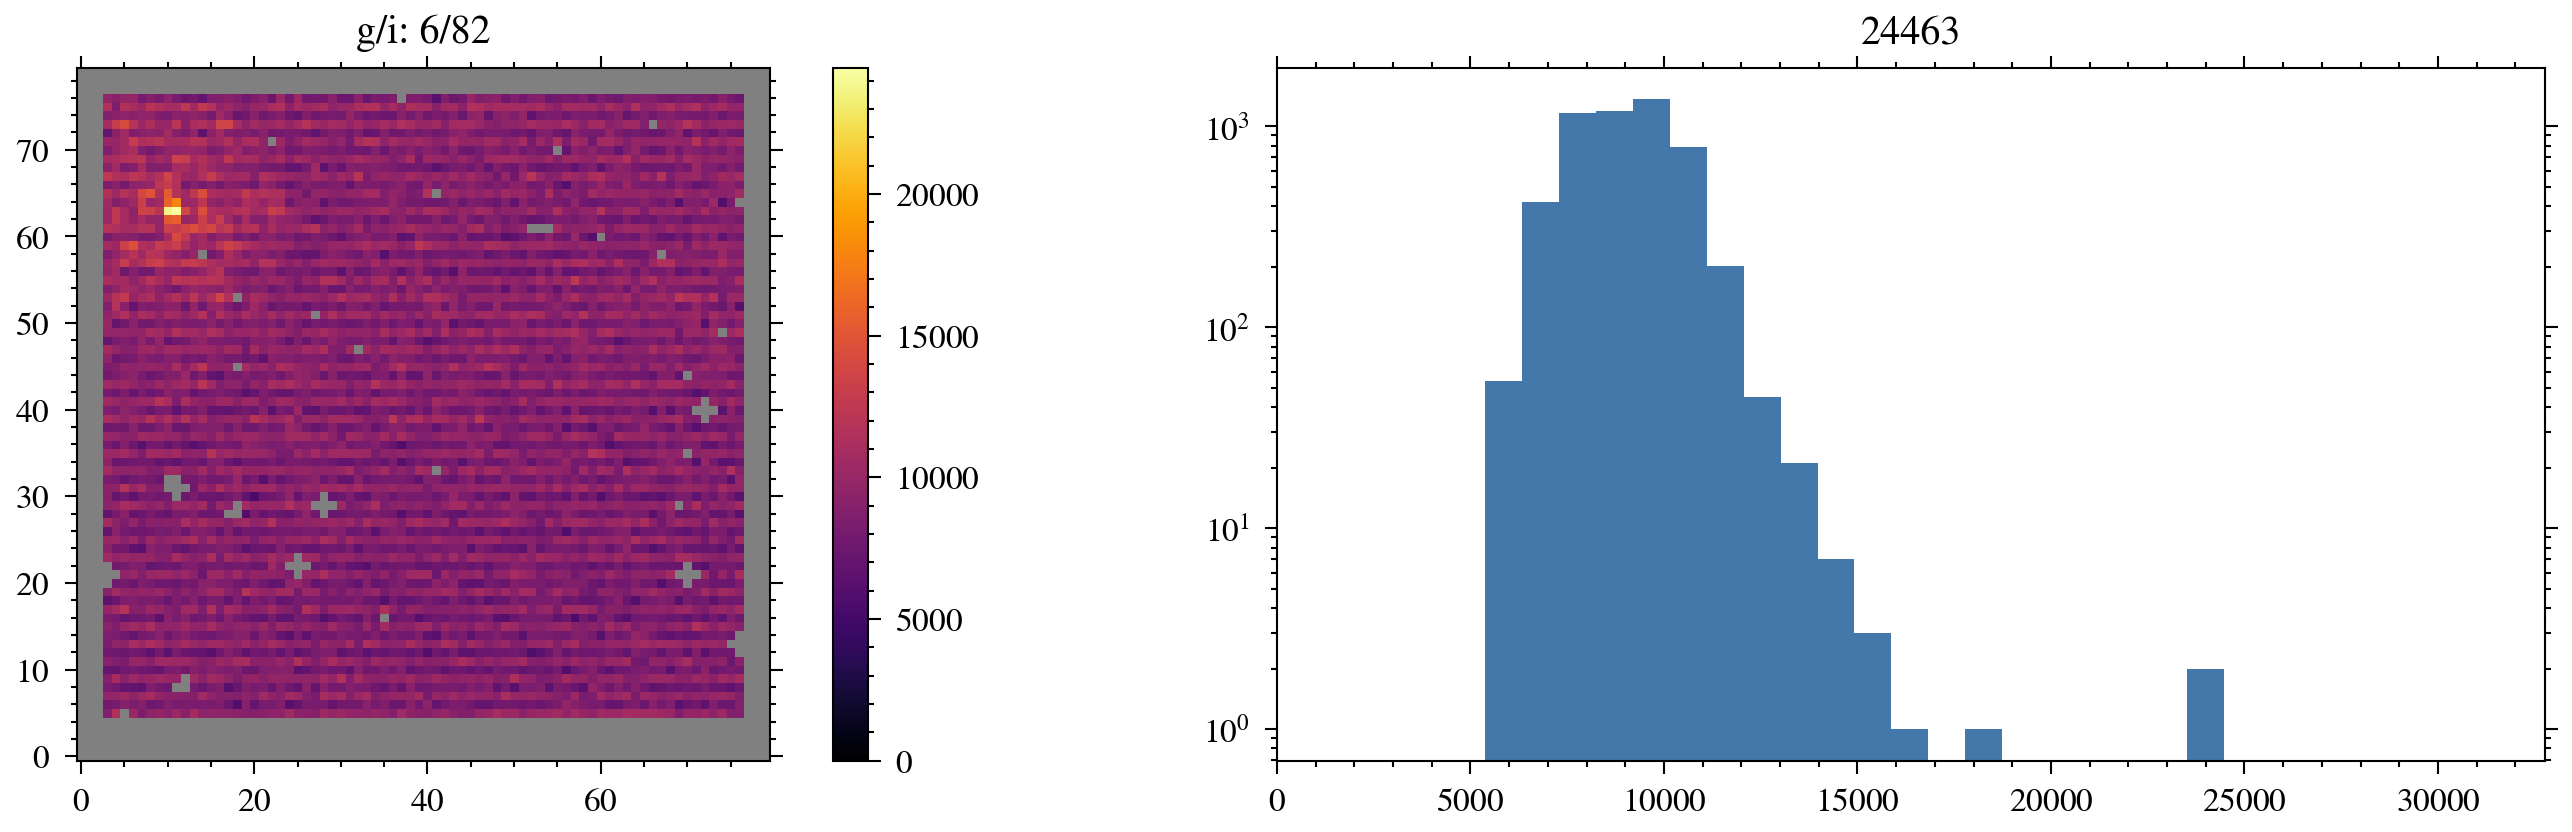




jw01093020001_03102_00021_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  21/25  9/65  05-06-2022  Thatte, Deepashri  True


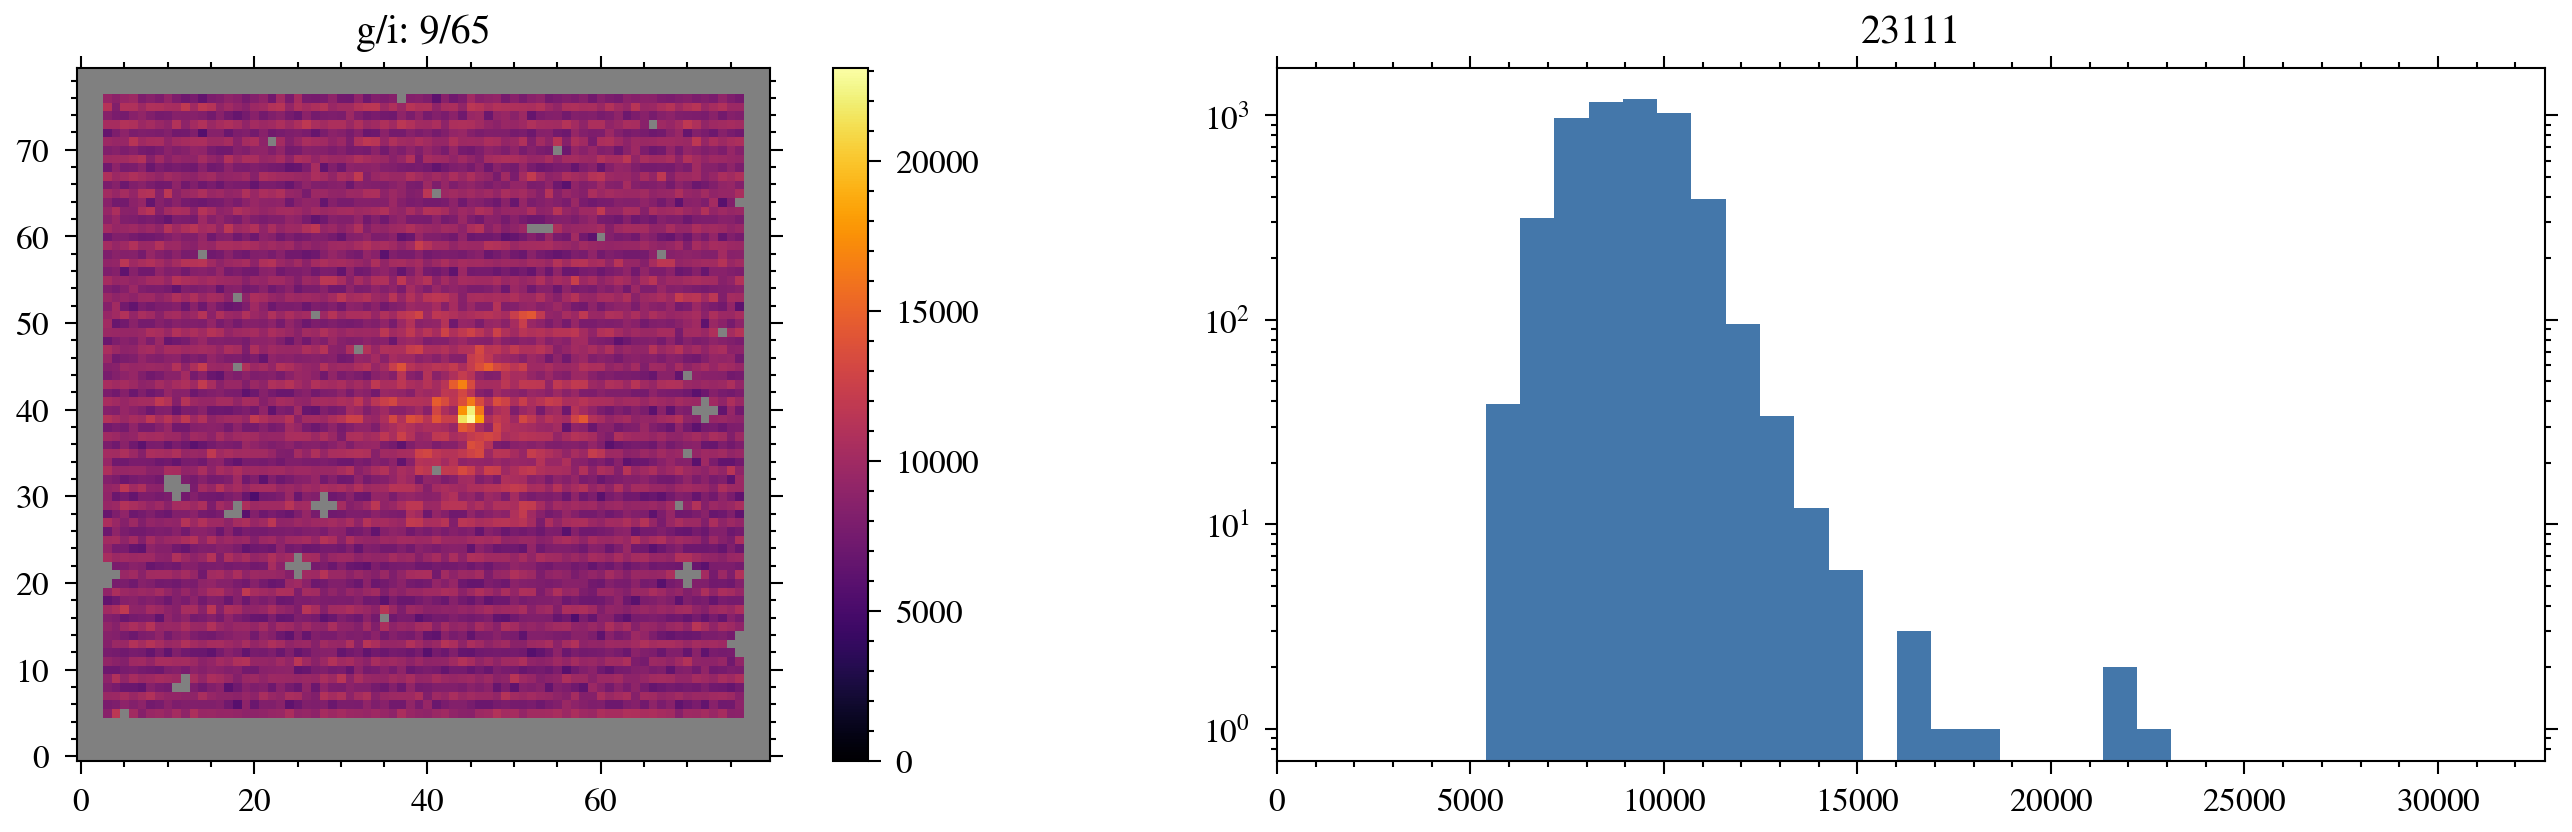




jw01093020001_03102_00020_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  20/25  9/65  05-06-2022  Thatte, Deepashri  True


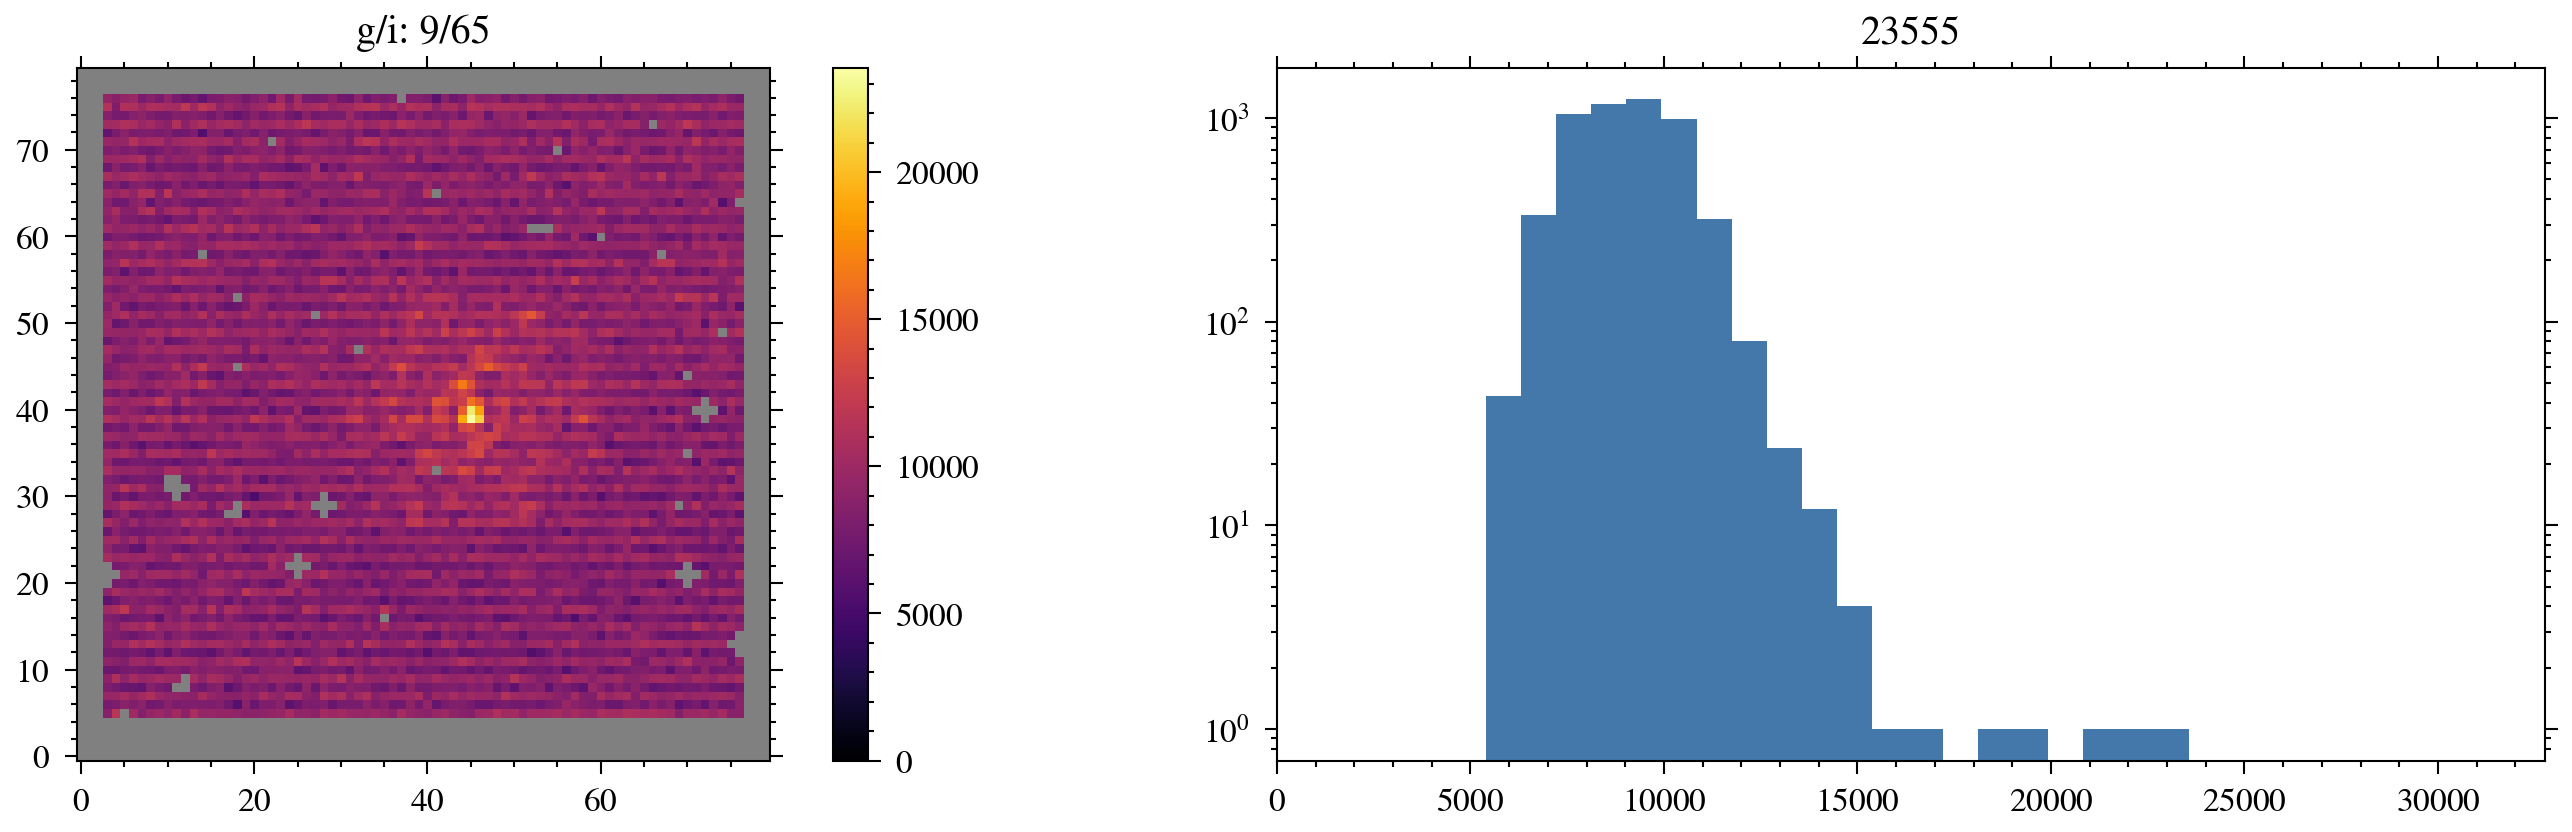




jw01093007001_03102_00018_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  18/25  9/65  23-05-2022  Thatte, Deepashri  True


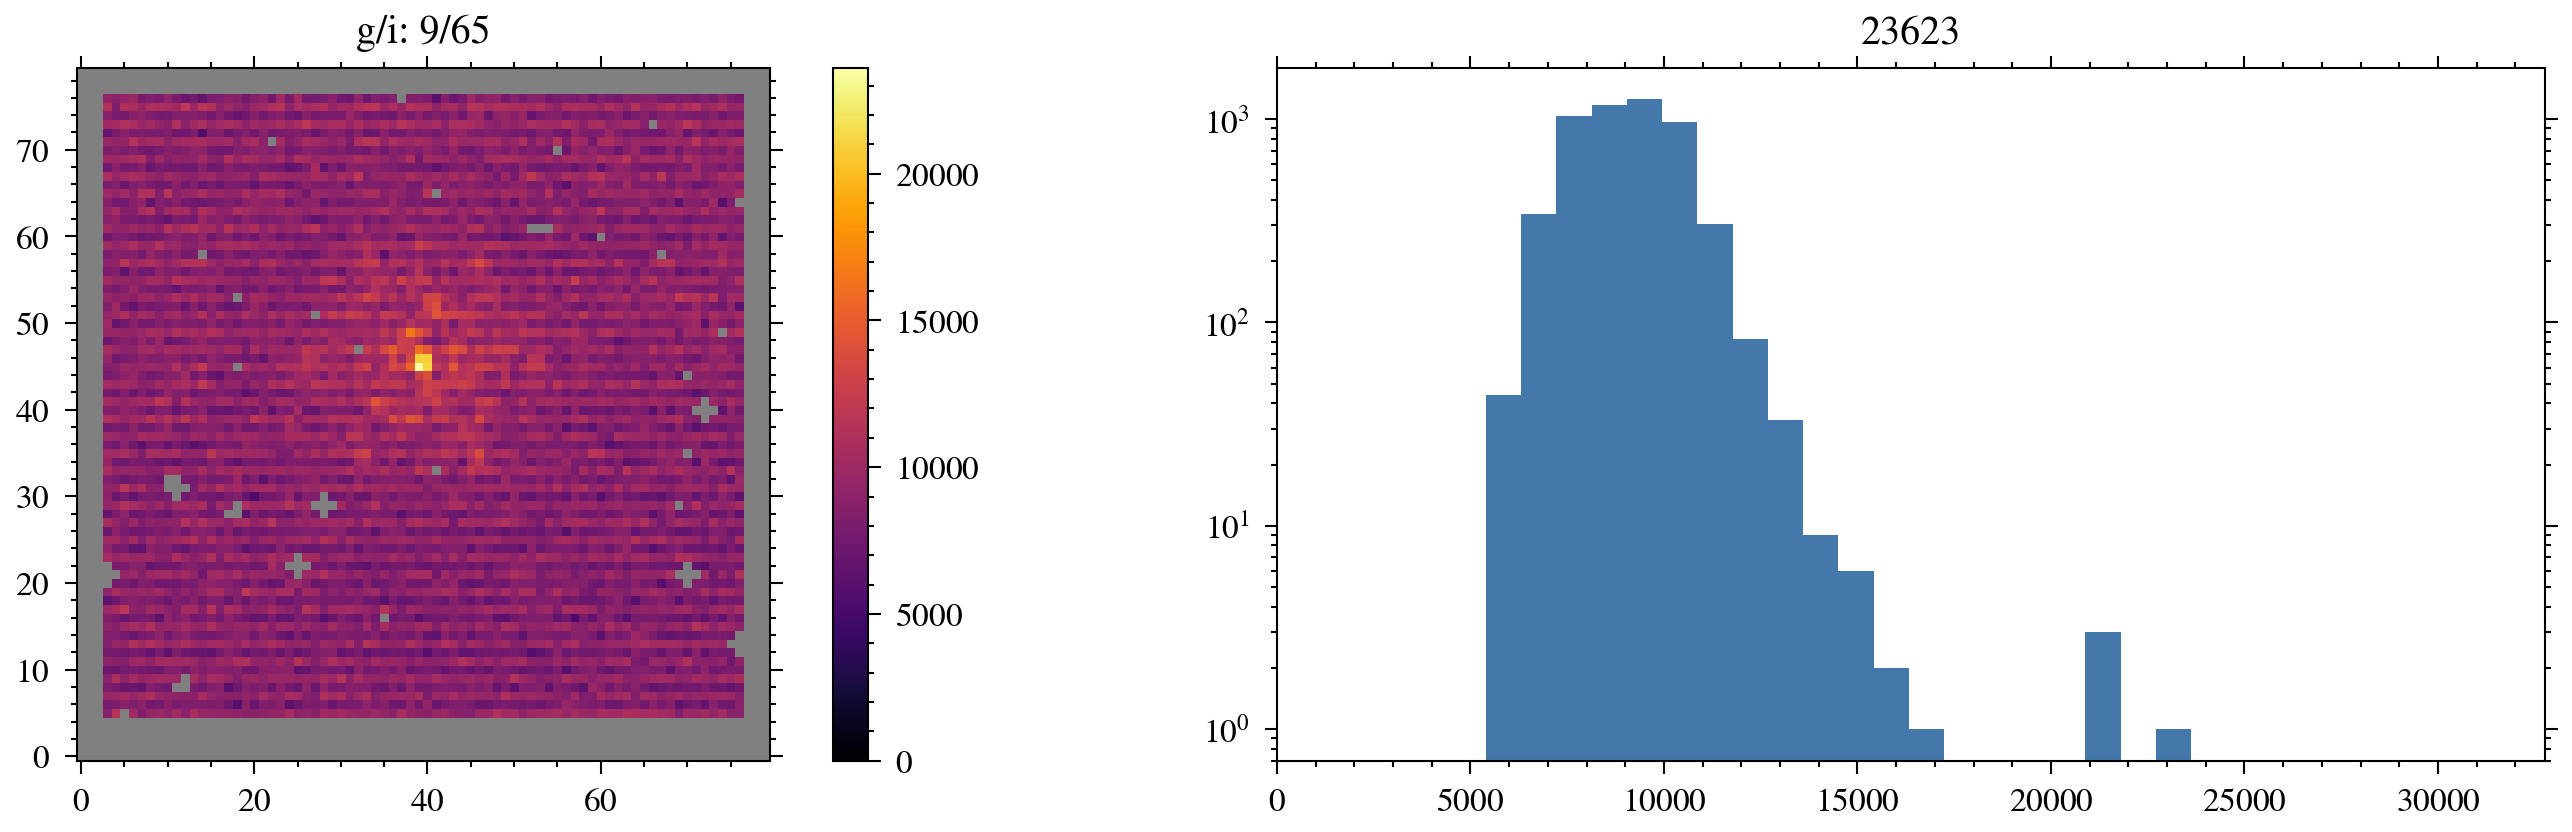




jw01093020001_03102_00009_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   9/25  9/65  05-06-2022  Thatte, Deepashri  True


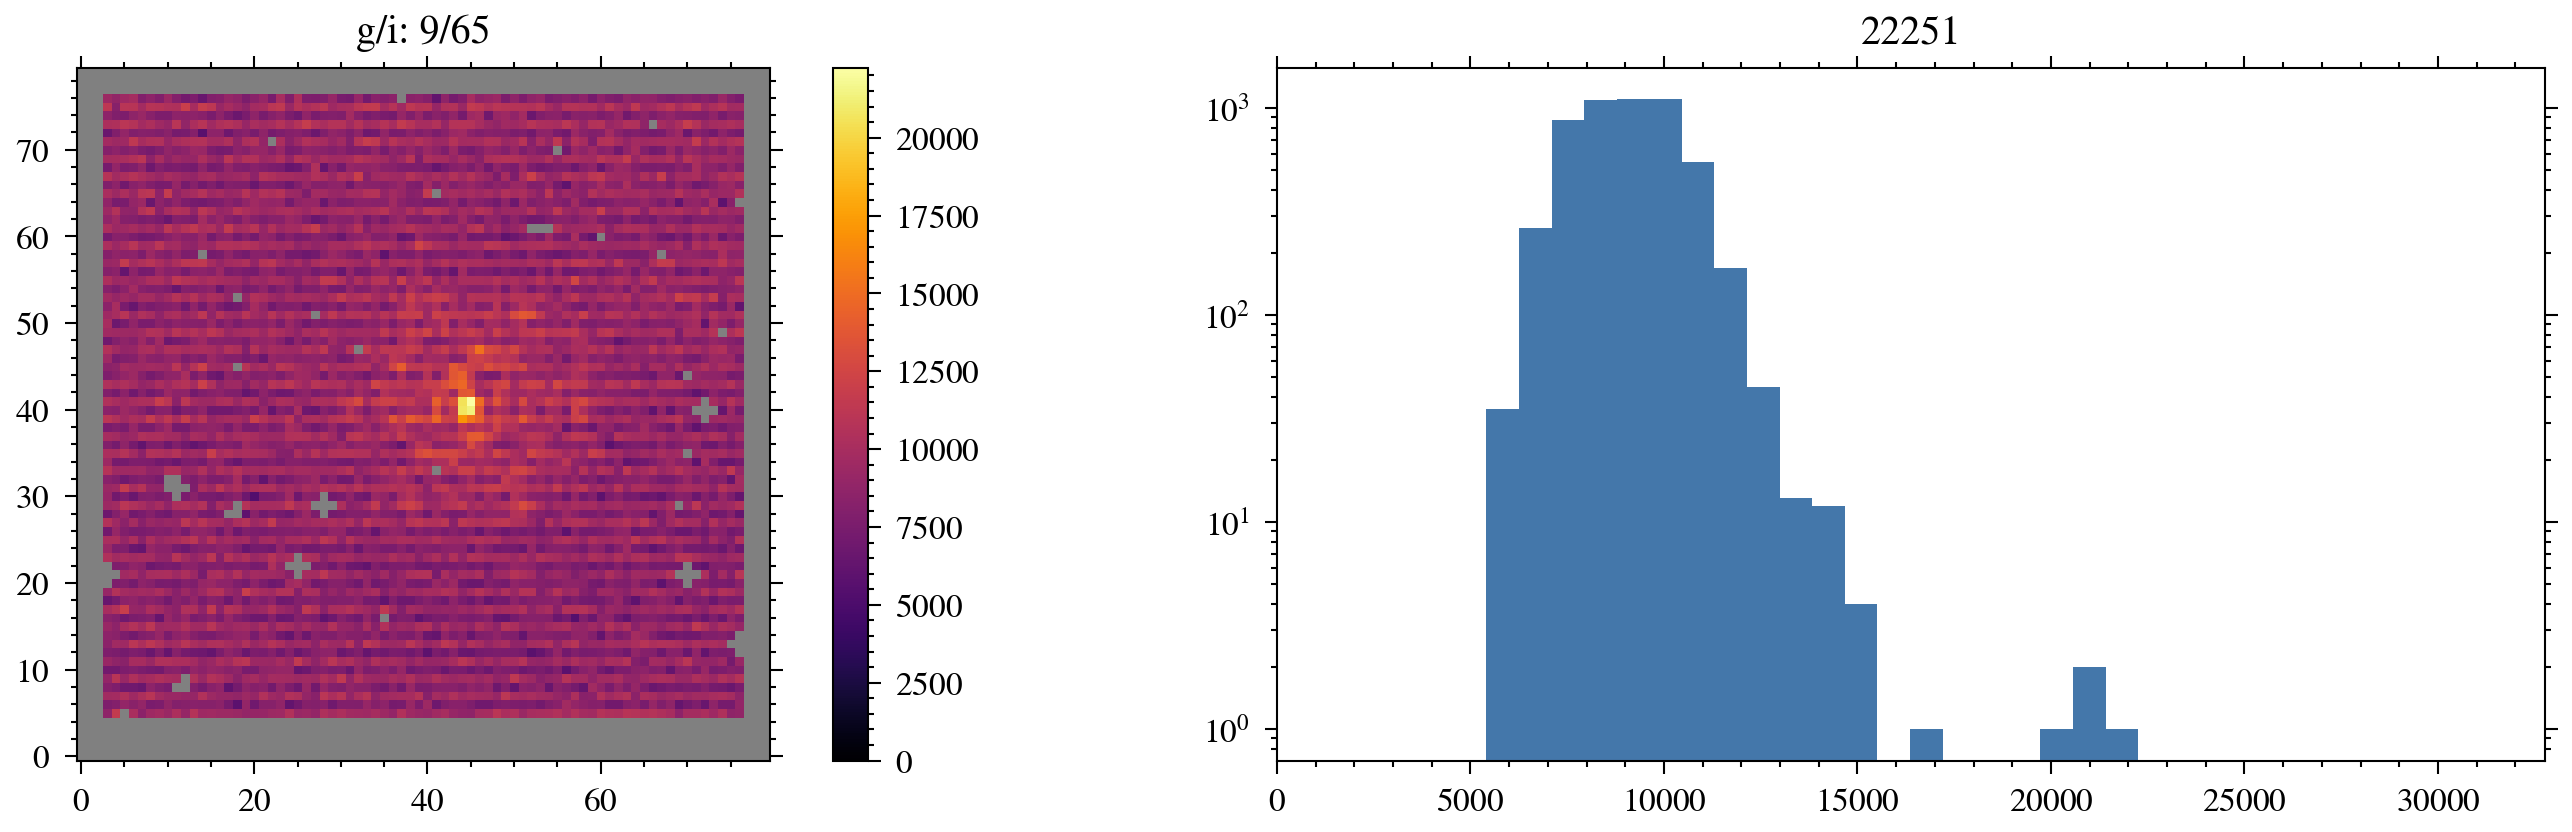




jw01093007001_03102_00021_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  21/25  9/65  23-05-2022  Thatte, Deepashri  True


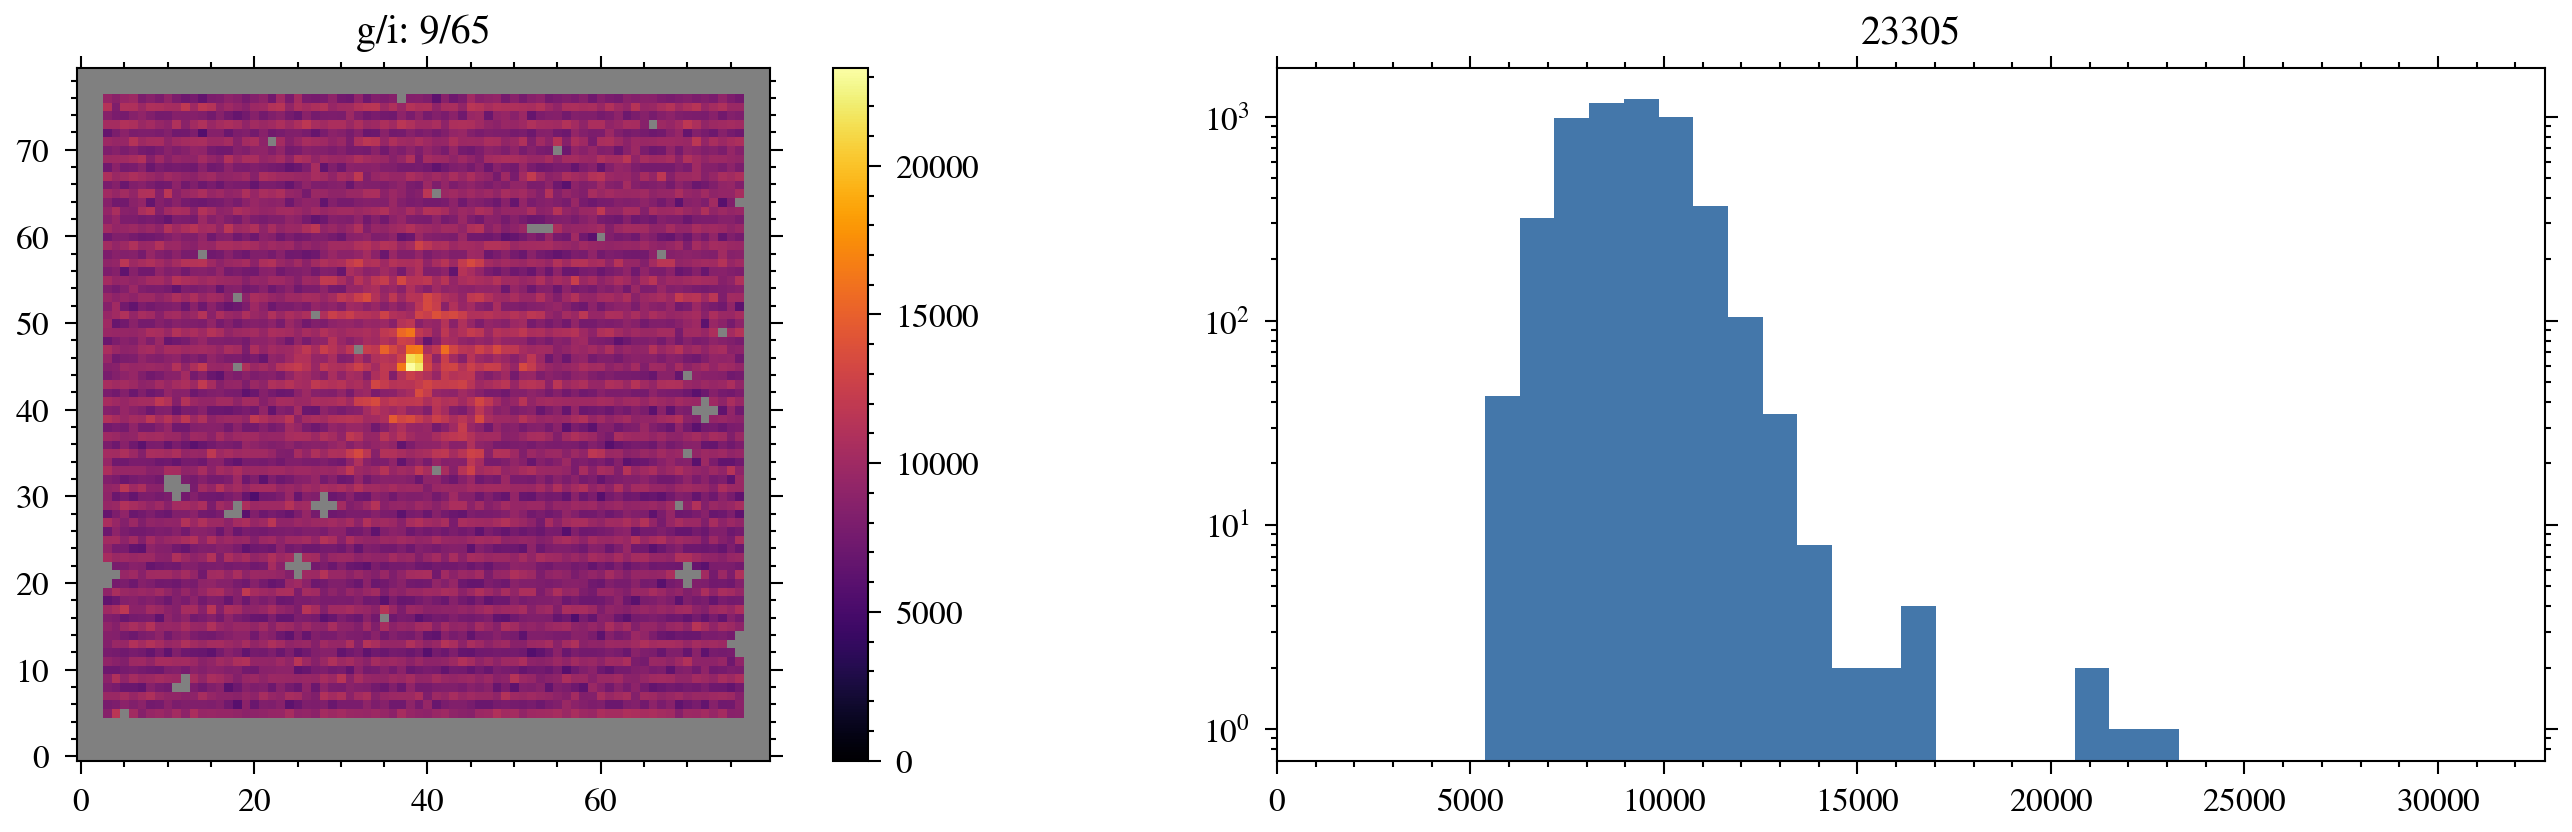




jw01093007001_03102_00010_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  10/25  9/65  23-05-2022  Thatte, Deepashri  True


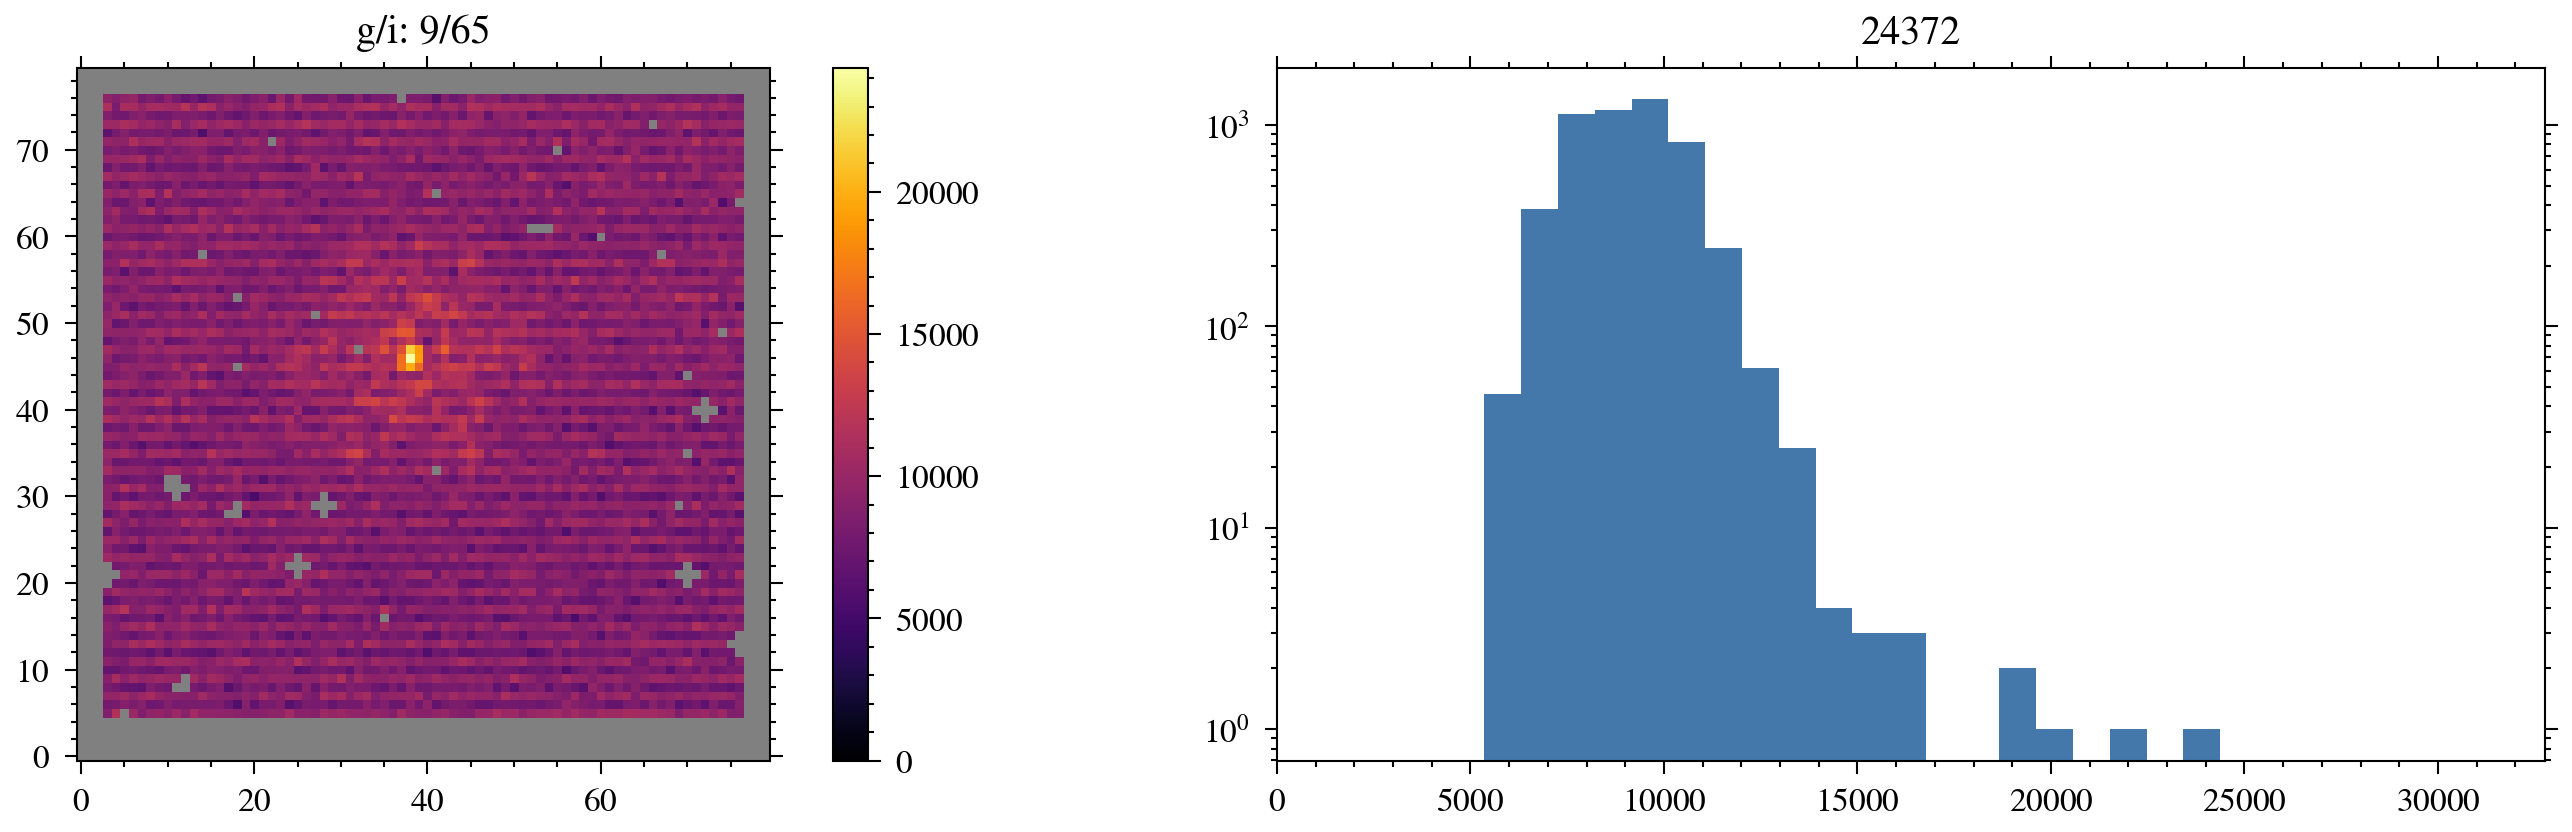




jw01093007001_03102_00008_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   8/25  9/65  23-05-2022  Thatte, Deepashri  True


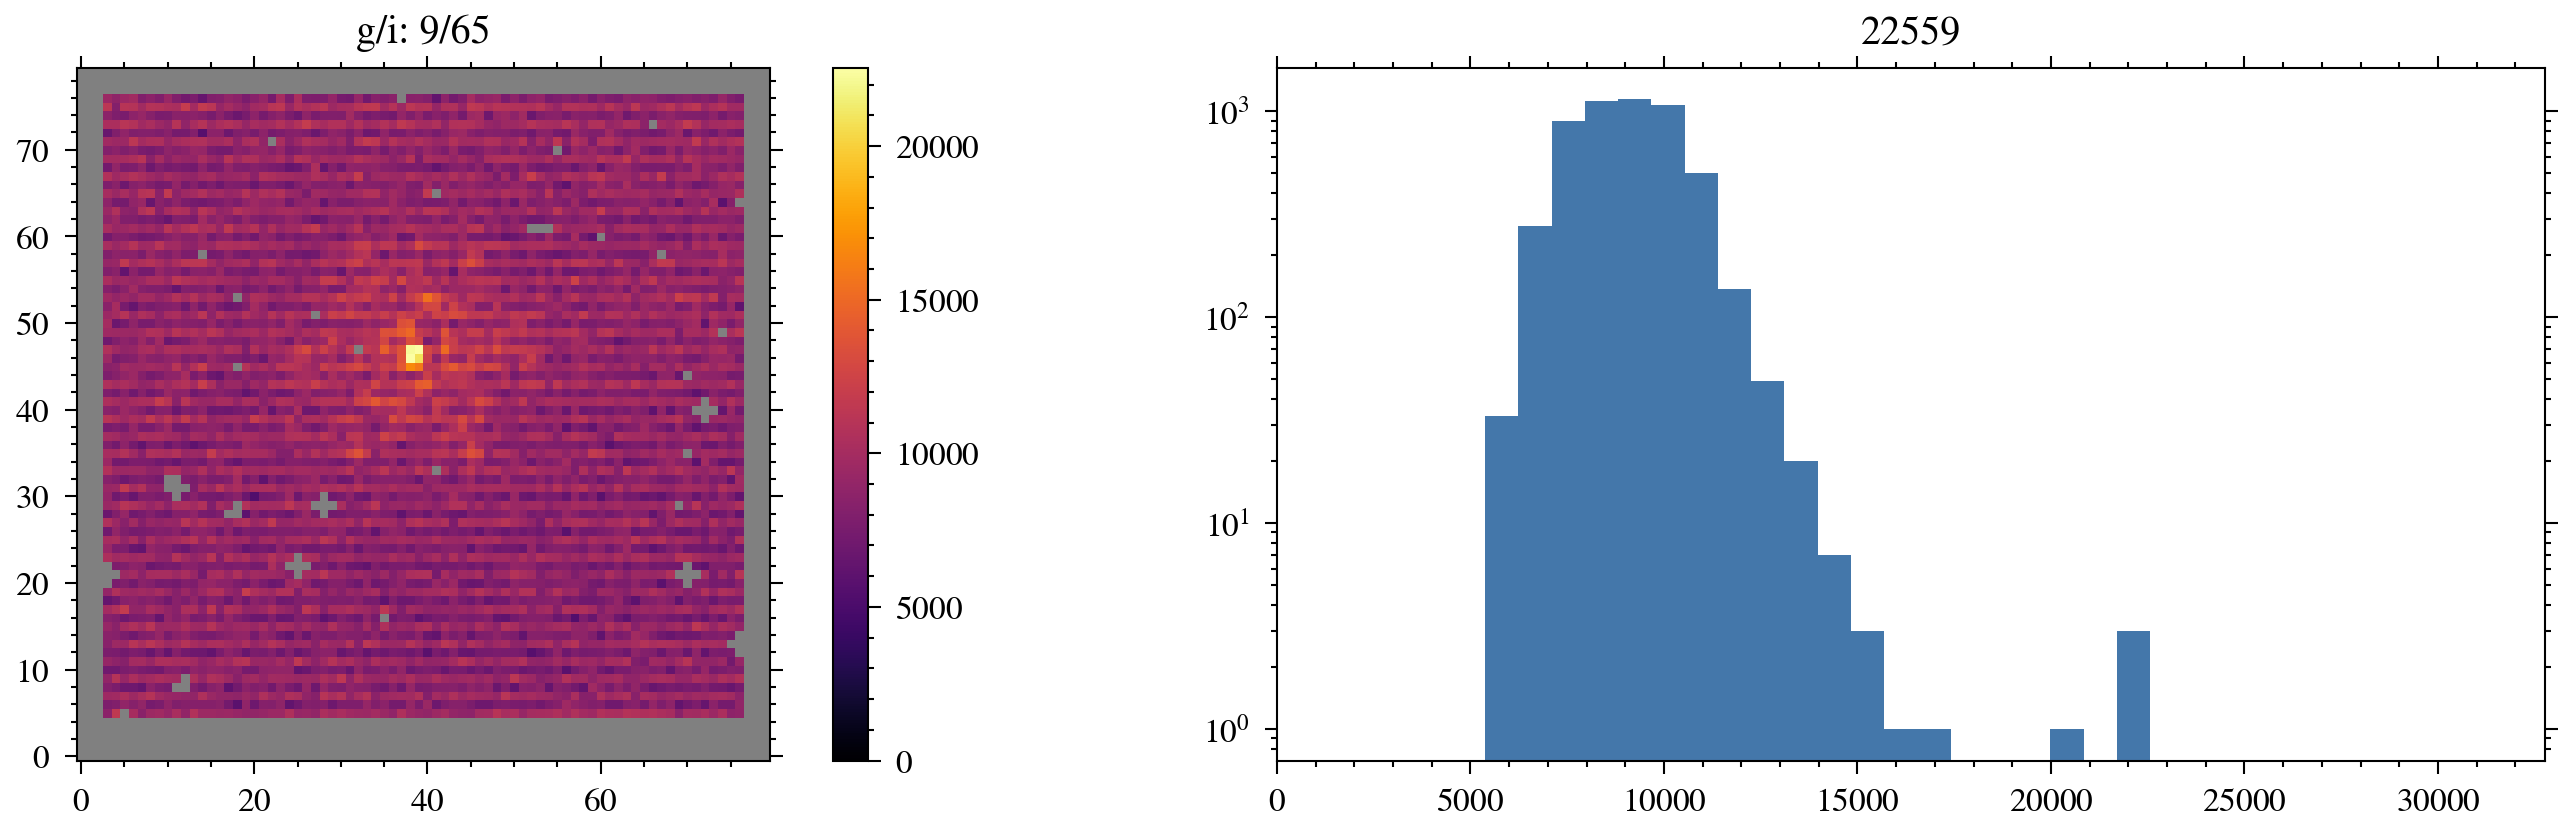




jw01093006001_03106_00002_nis
  program    target filter dither    g/i        date                 PI   CAL
0    1093  HD-36805  F380M    2/2  3/122  23-05-2022  Thatte, Deepashri  True


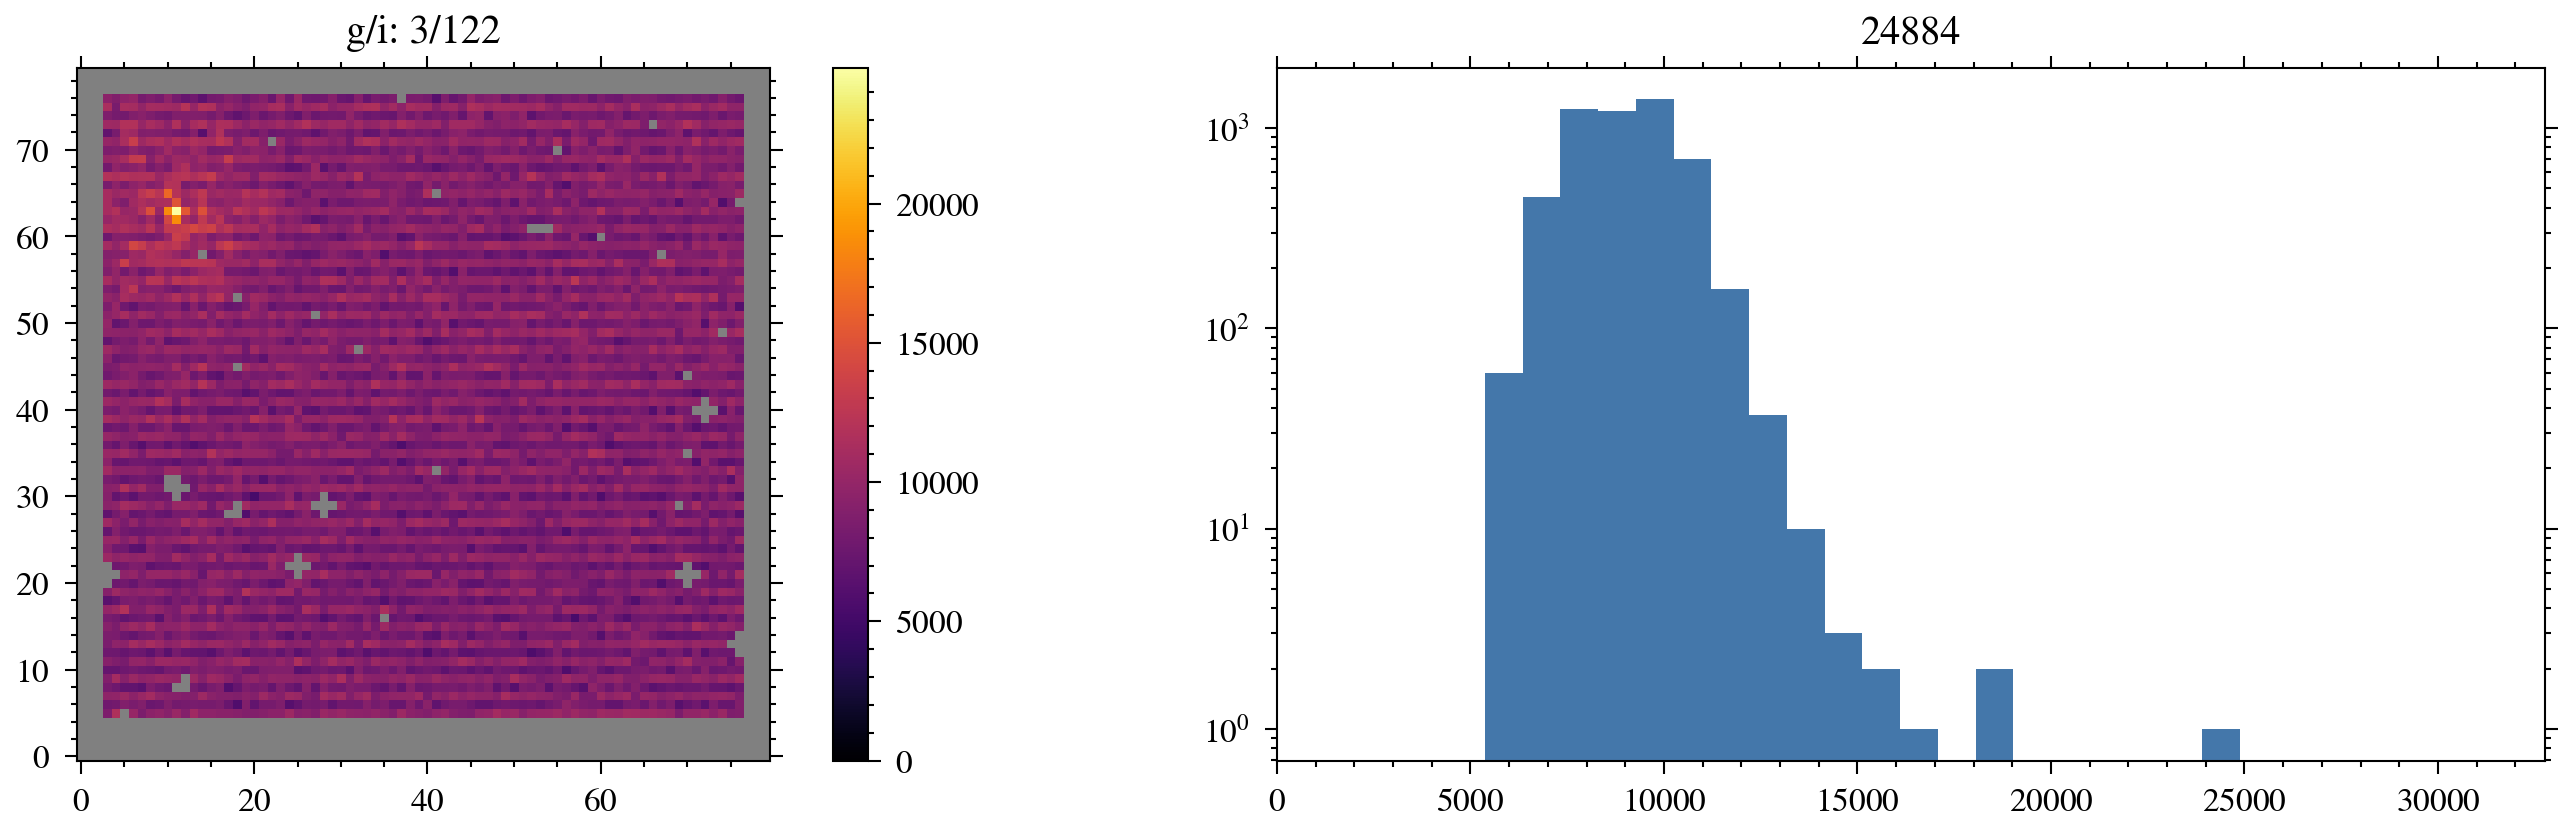




jw01093006001_03104_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F430M    1/2  6/82  23-05-2022  Thatte, Deepashri  True


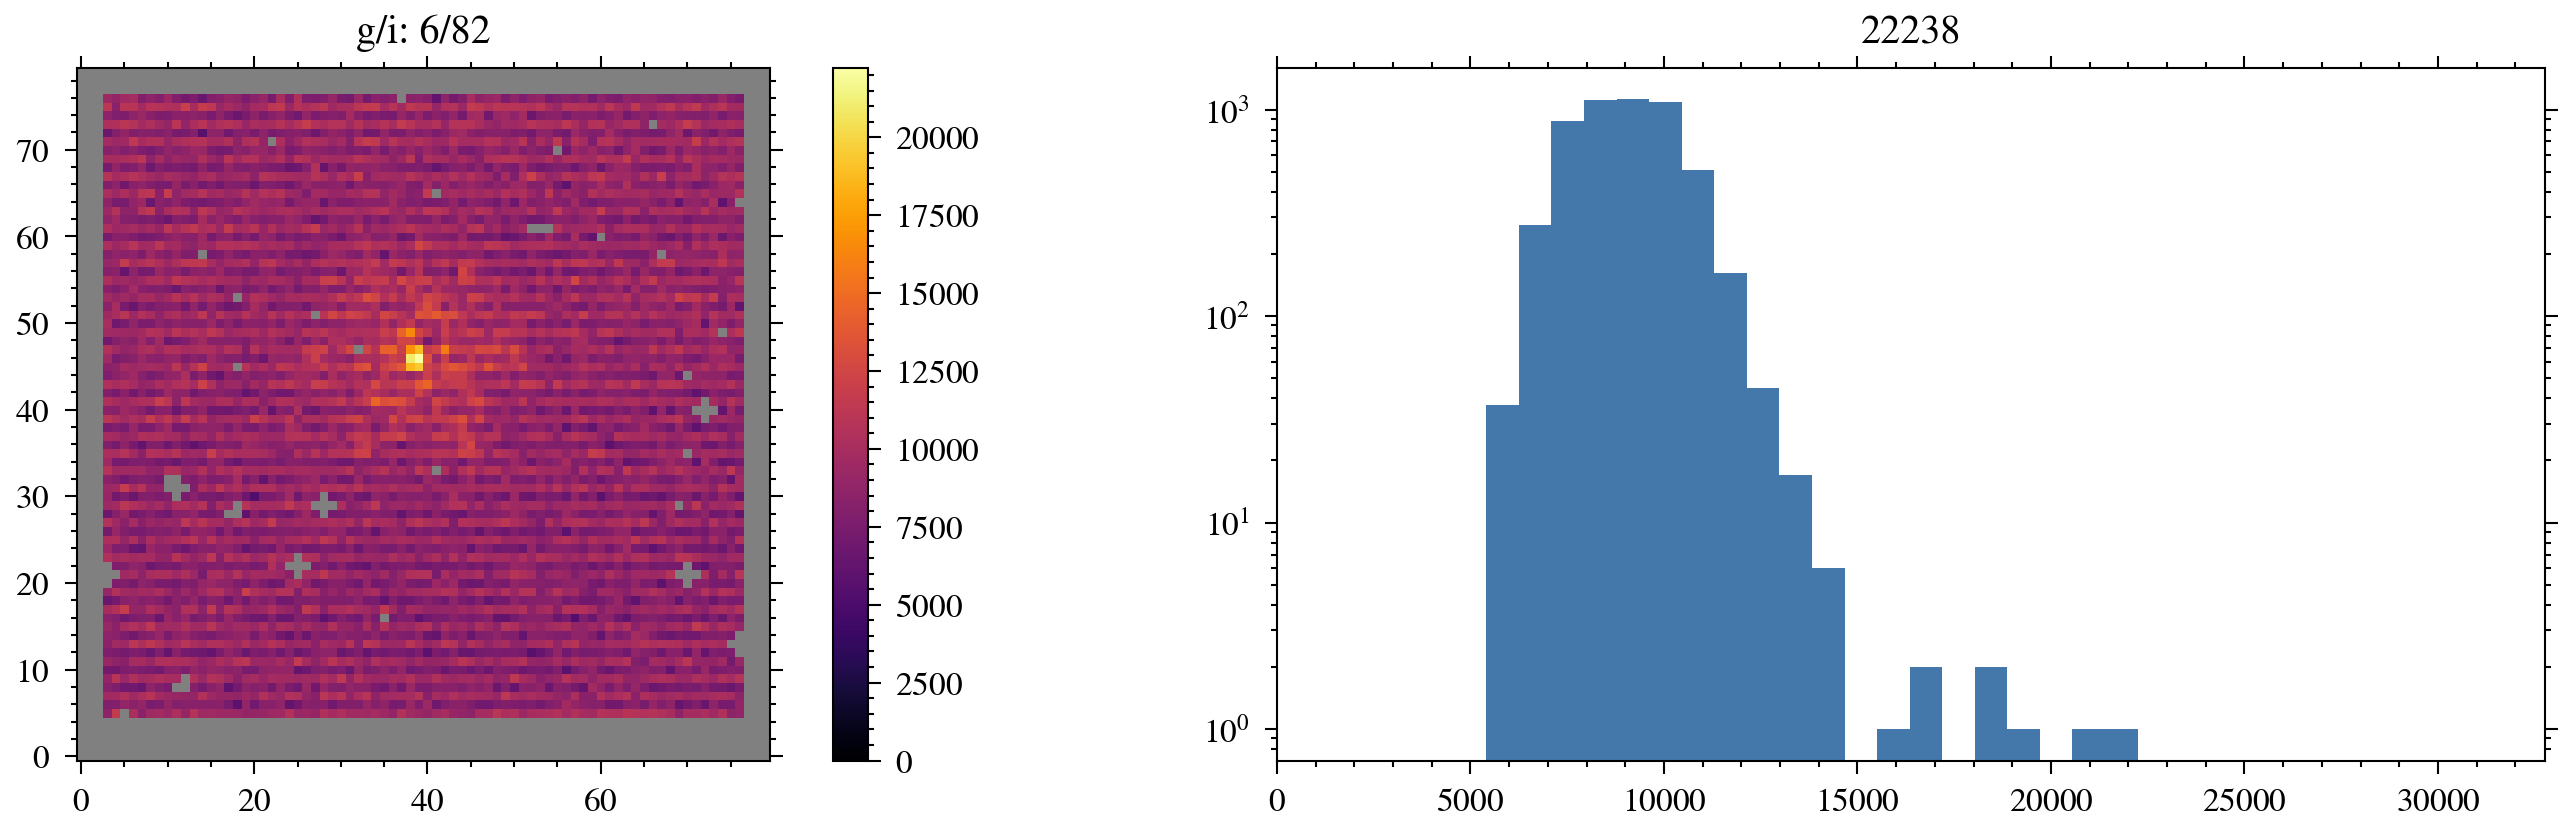




jw01093007001_03102_00006_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   6/25  9/65  23-05-2022  Thatte, Deepashri  True


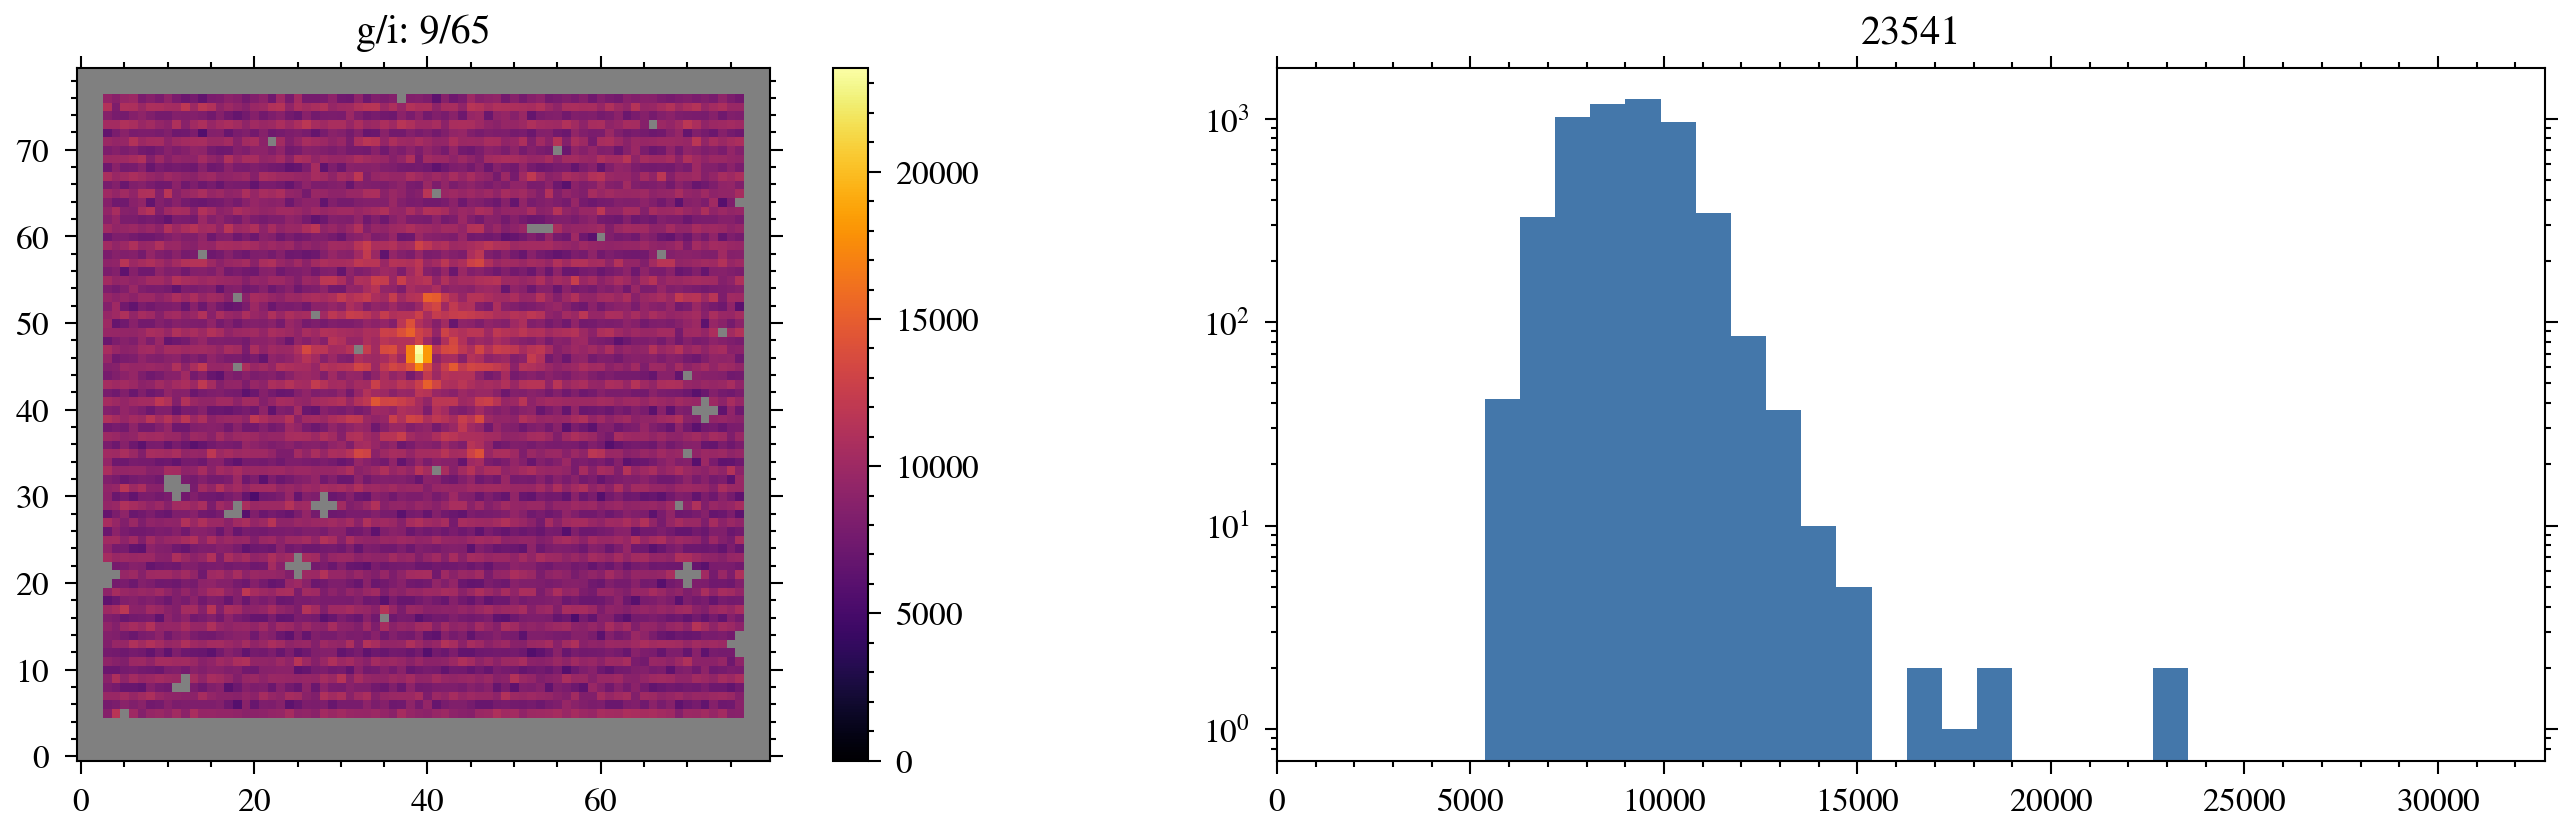




jw01093019001_03104_00001_nis
  program    target filter dither    g/i        date                 PI   CAL
0    1093  HD-36805  F380M    1/1  3/122  05-06-2022  Thatte, Deepashri  True


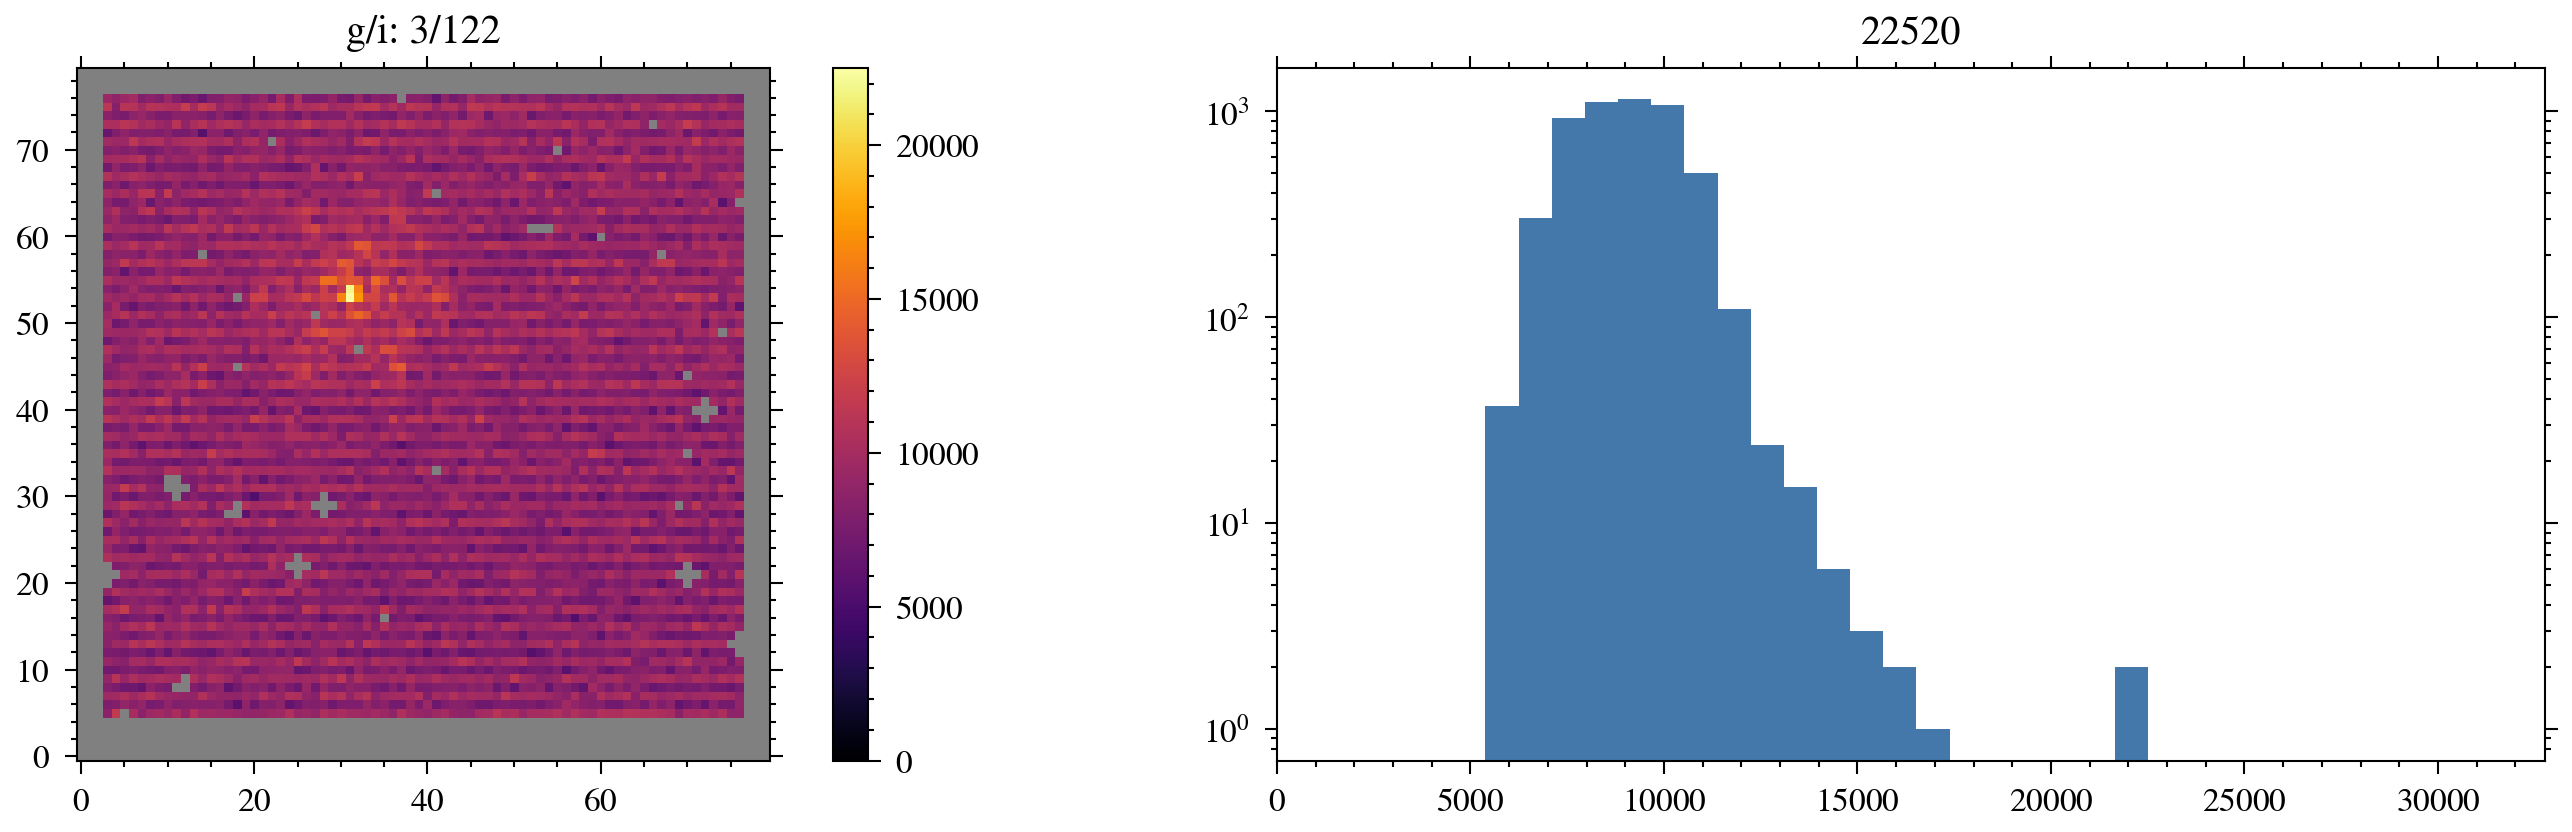




jw01093020001_03102_00012_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  12/25  9/65  05-06-2022  Thatte, Deepashri  True


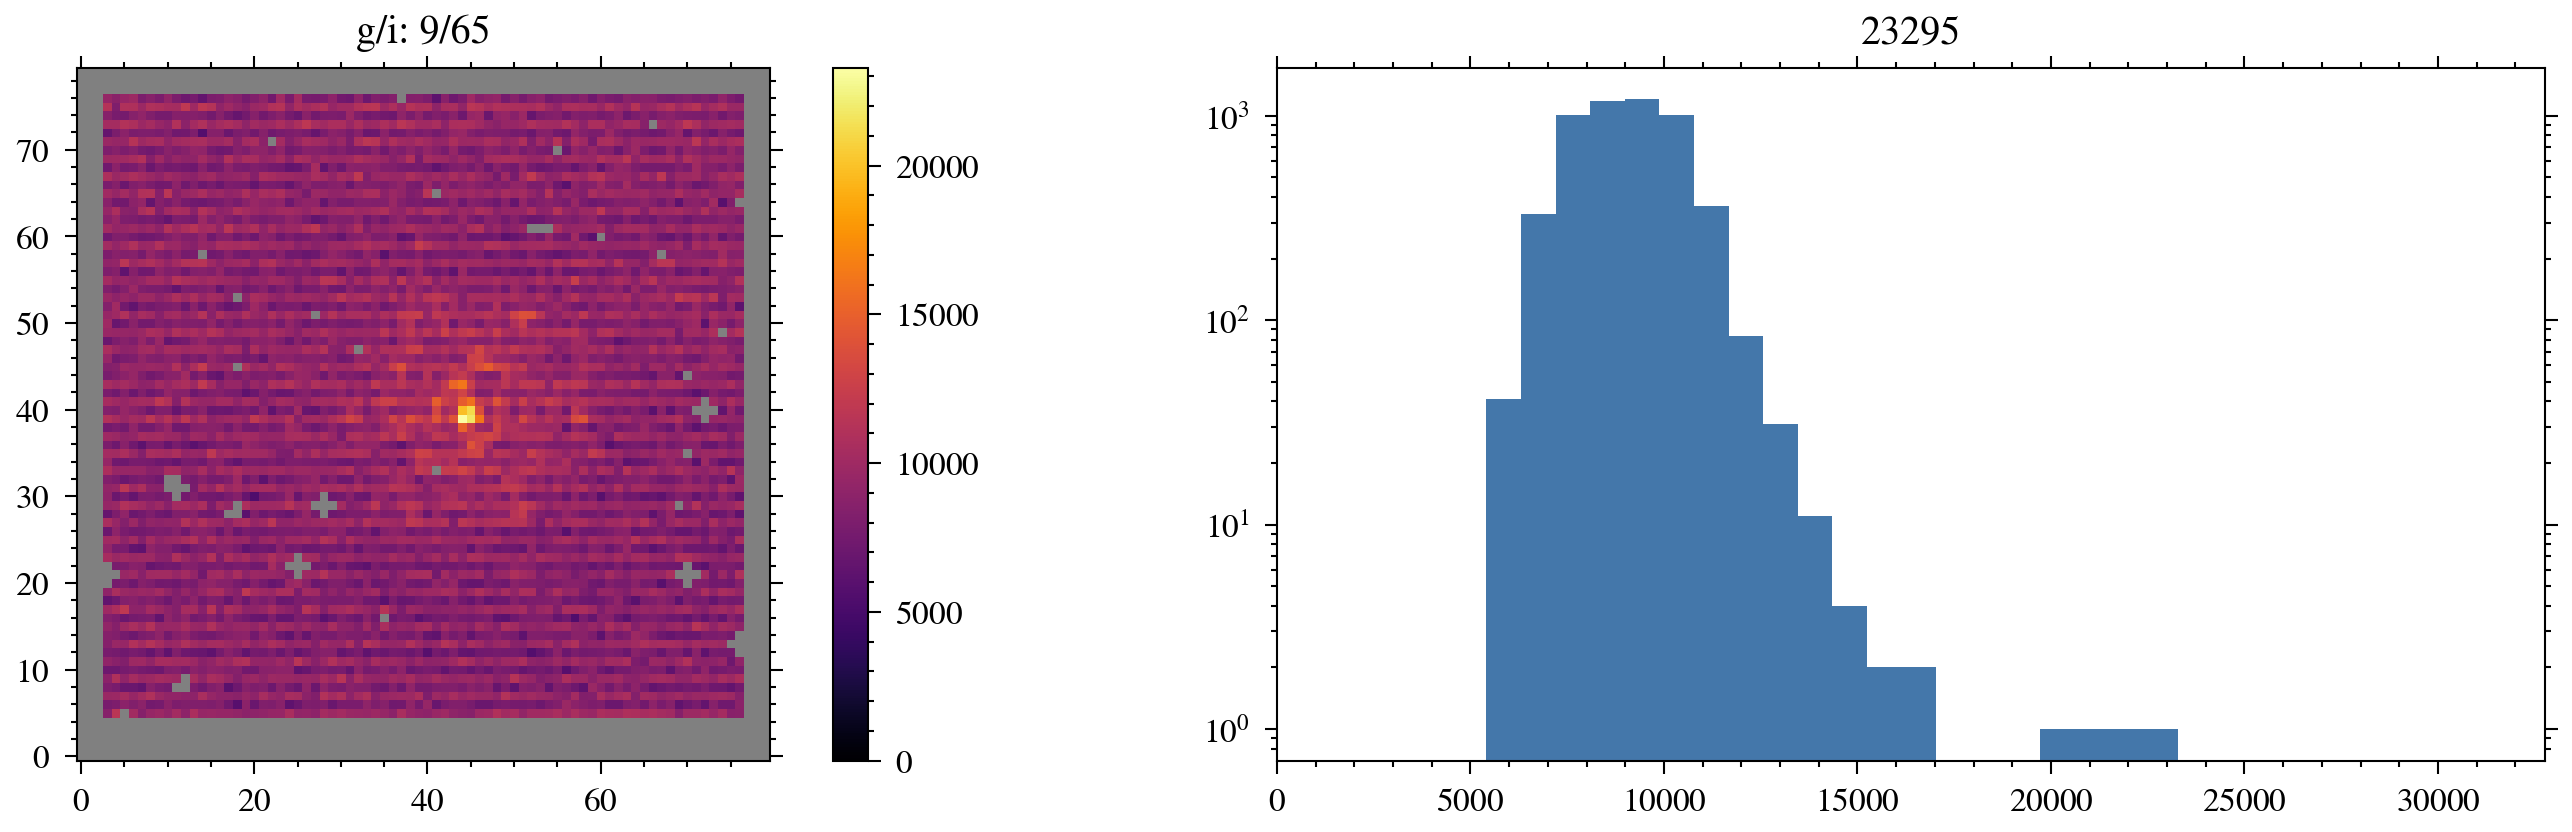




jw01093007001_03102_00023_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  23/25  9/65  23-05-2022  Thatte, Deepashri  True


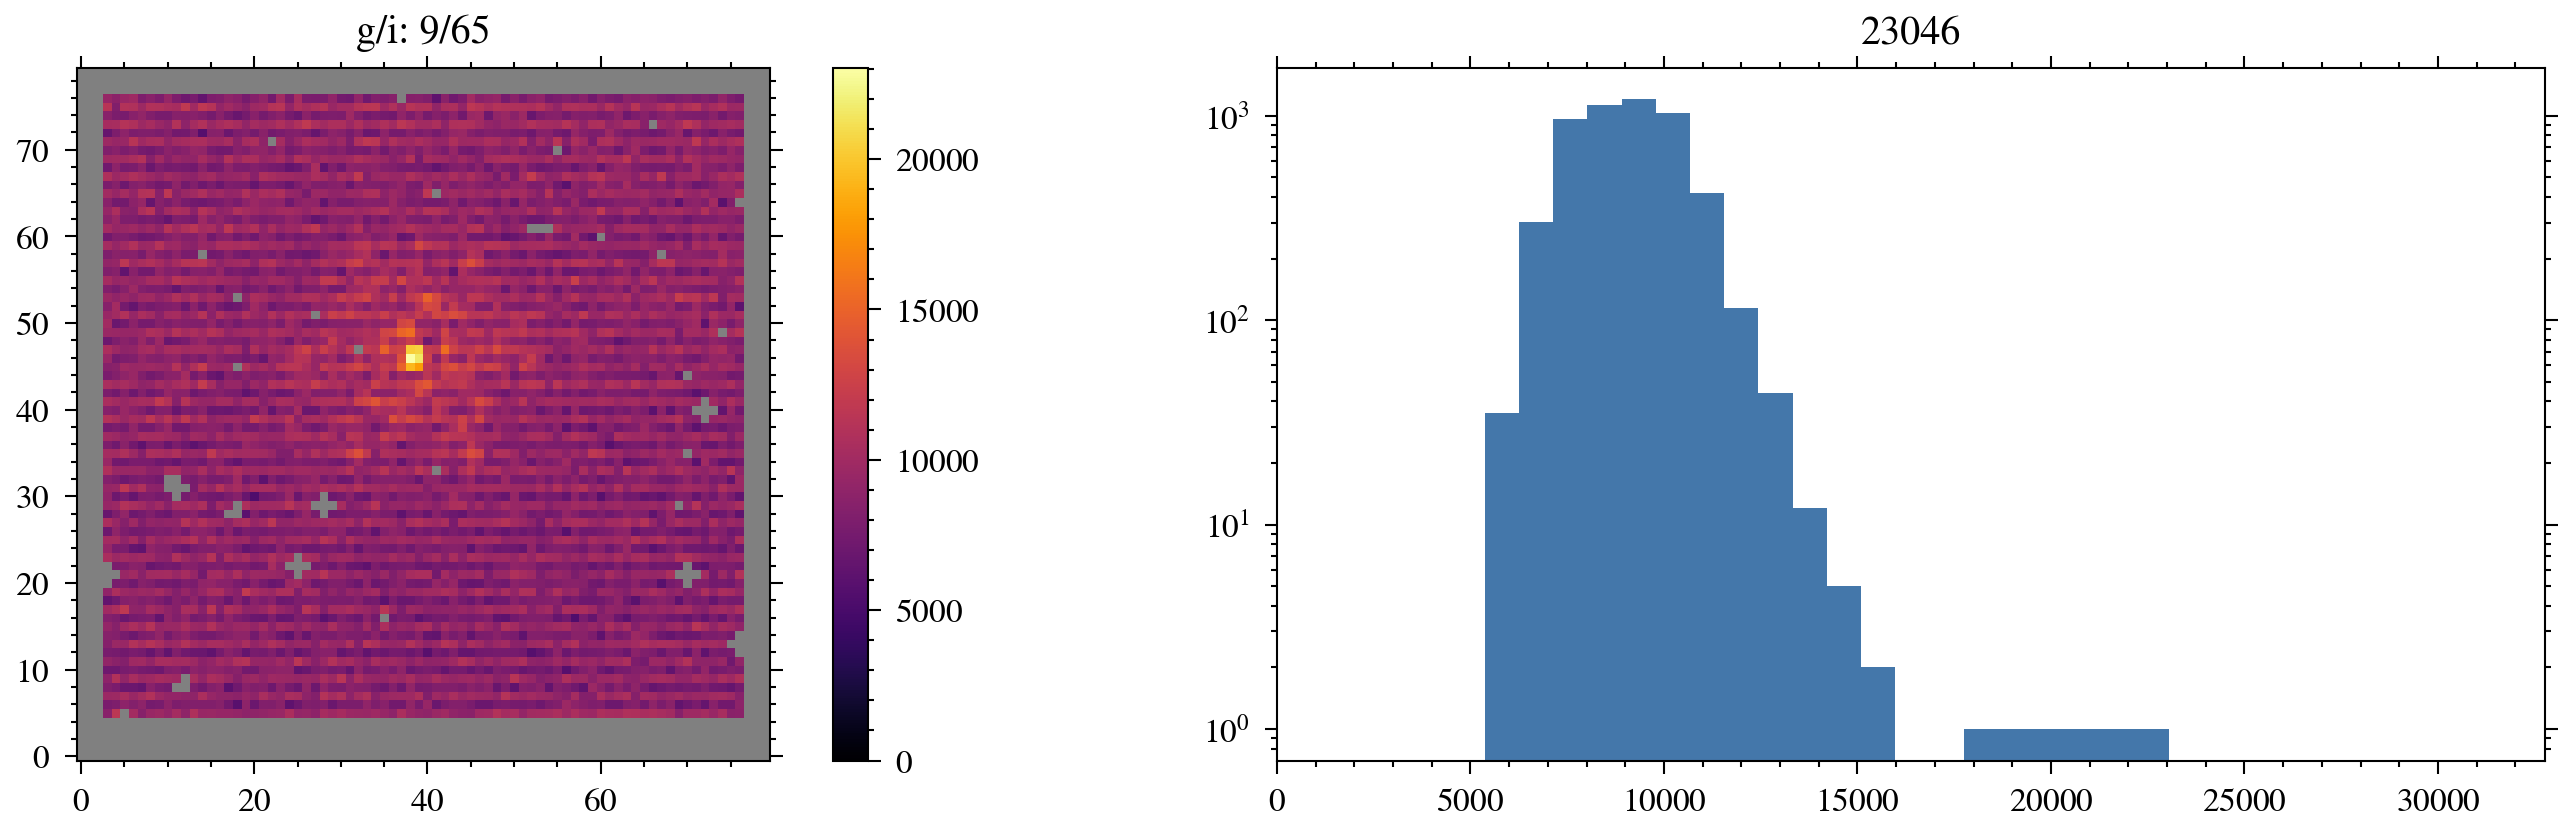




jw01093020001_03102_00019_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  19/25  9/65  05-06-2022  Thatte, Deepashri  True


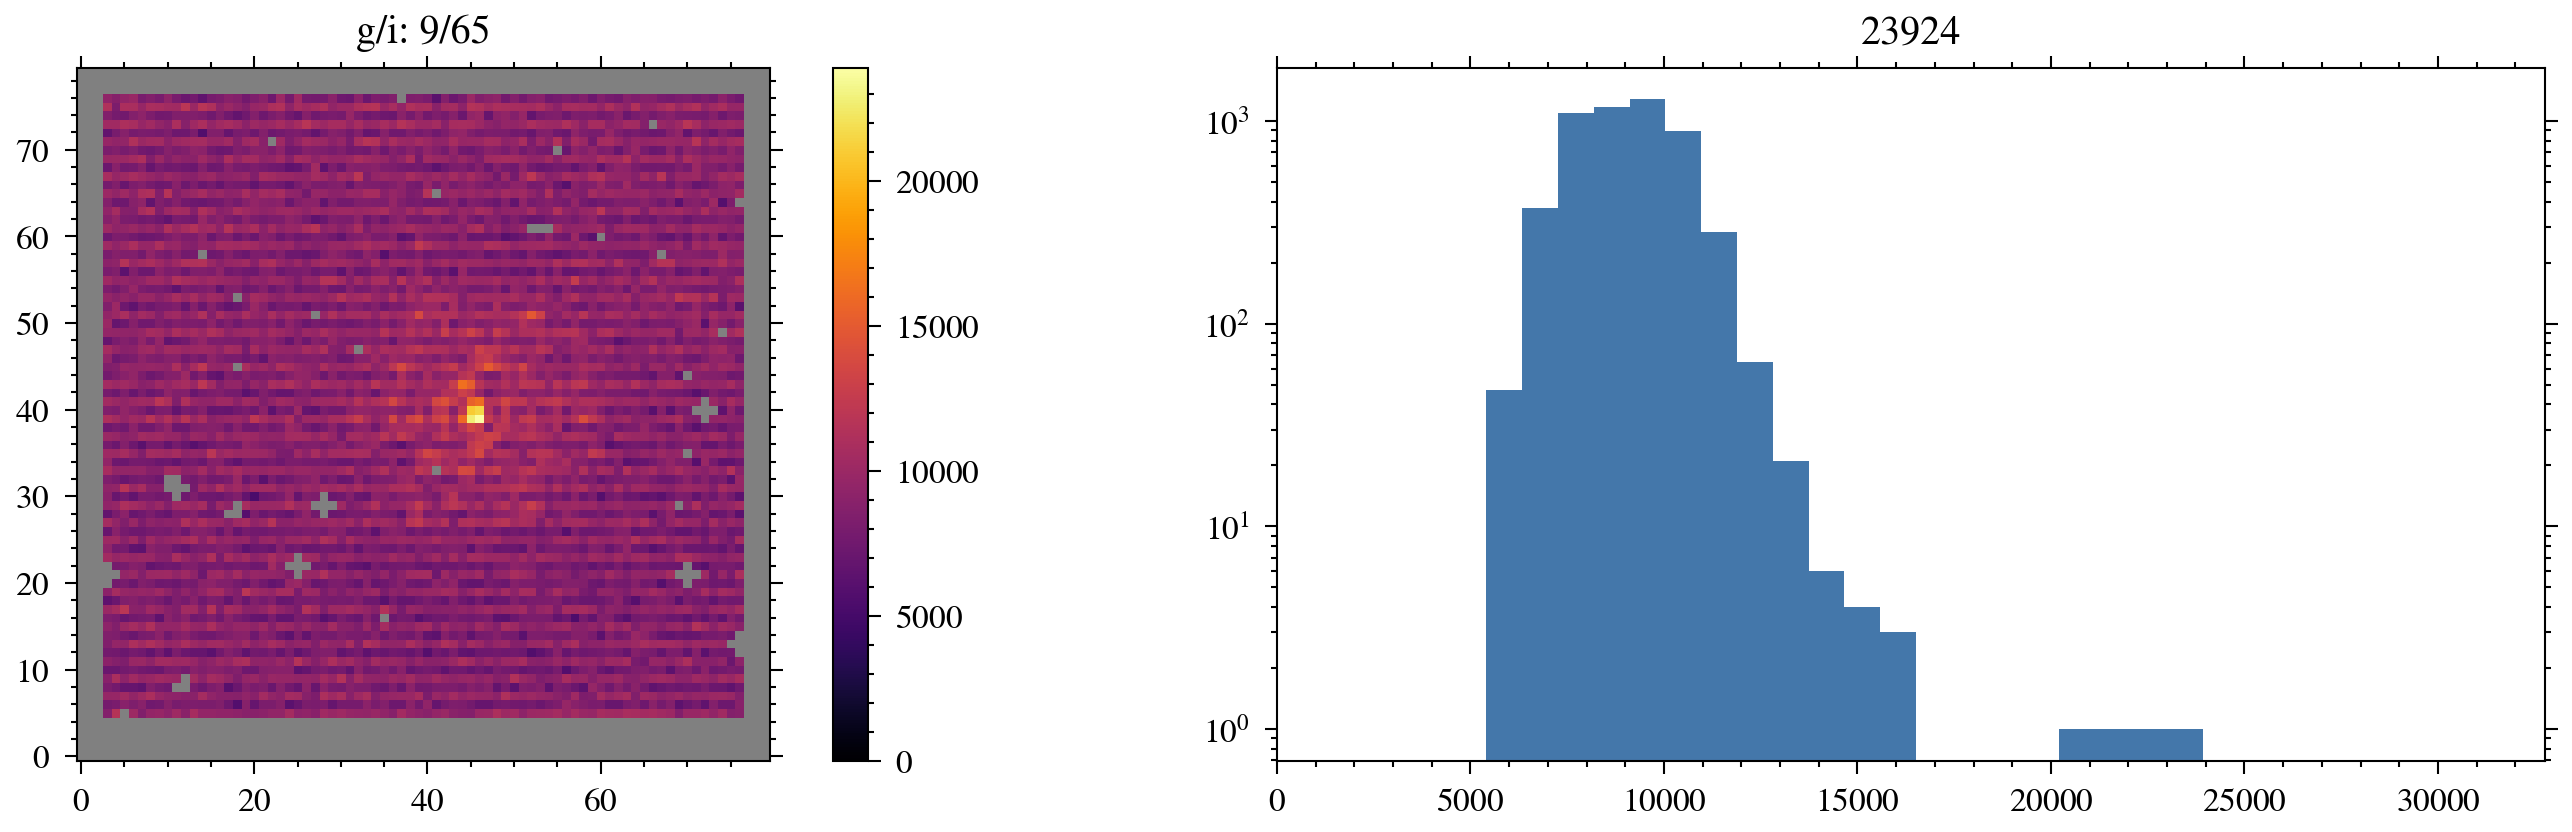




jw01093020001_03102_00018_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  18/25  9/65  05-06-2022  Thatte, Deepashri  True


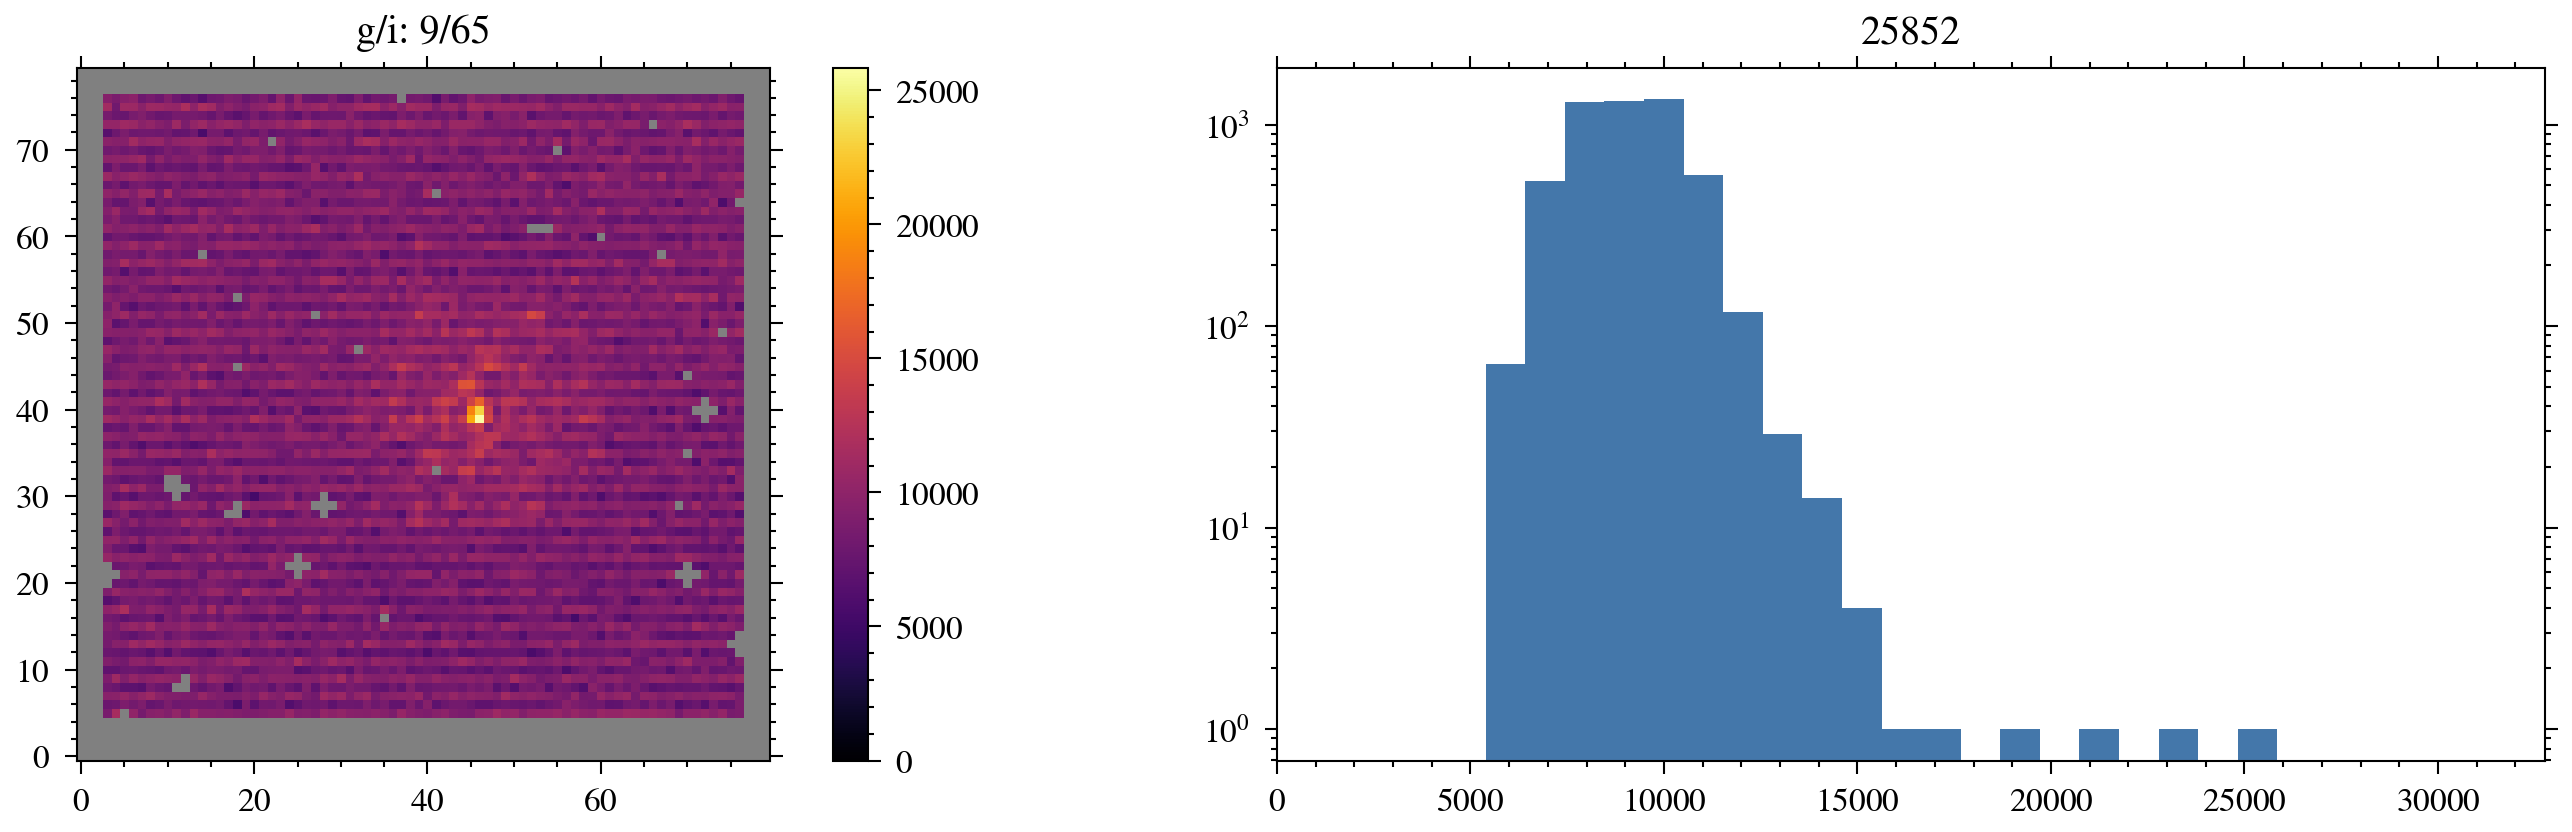




jw01093020001_03102_00016_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  16/25  9/65  05-06-2022  Thatte, Deepashri  True


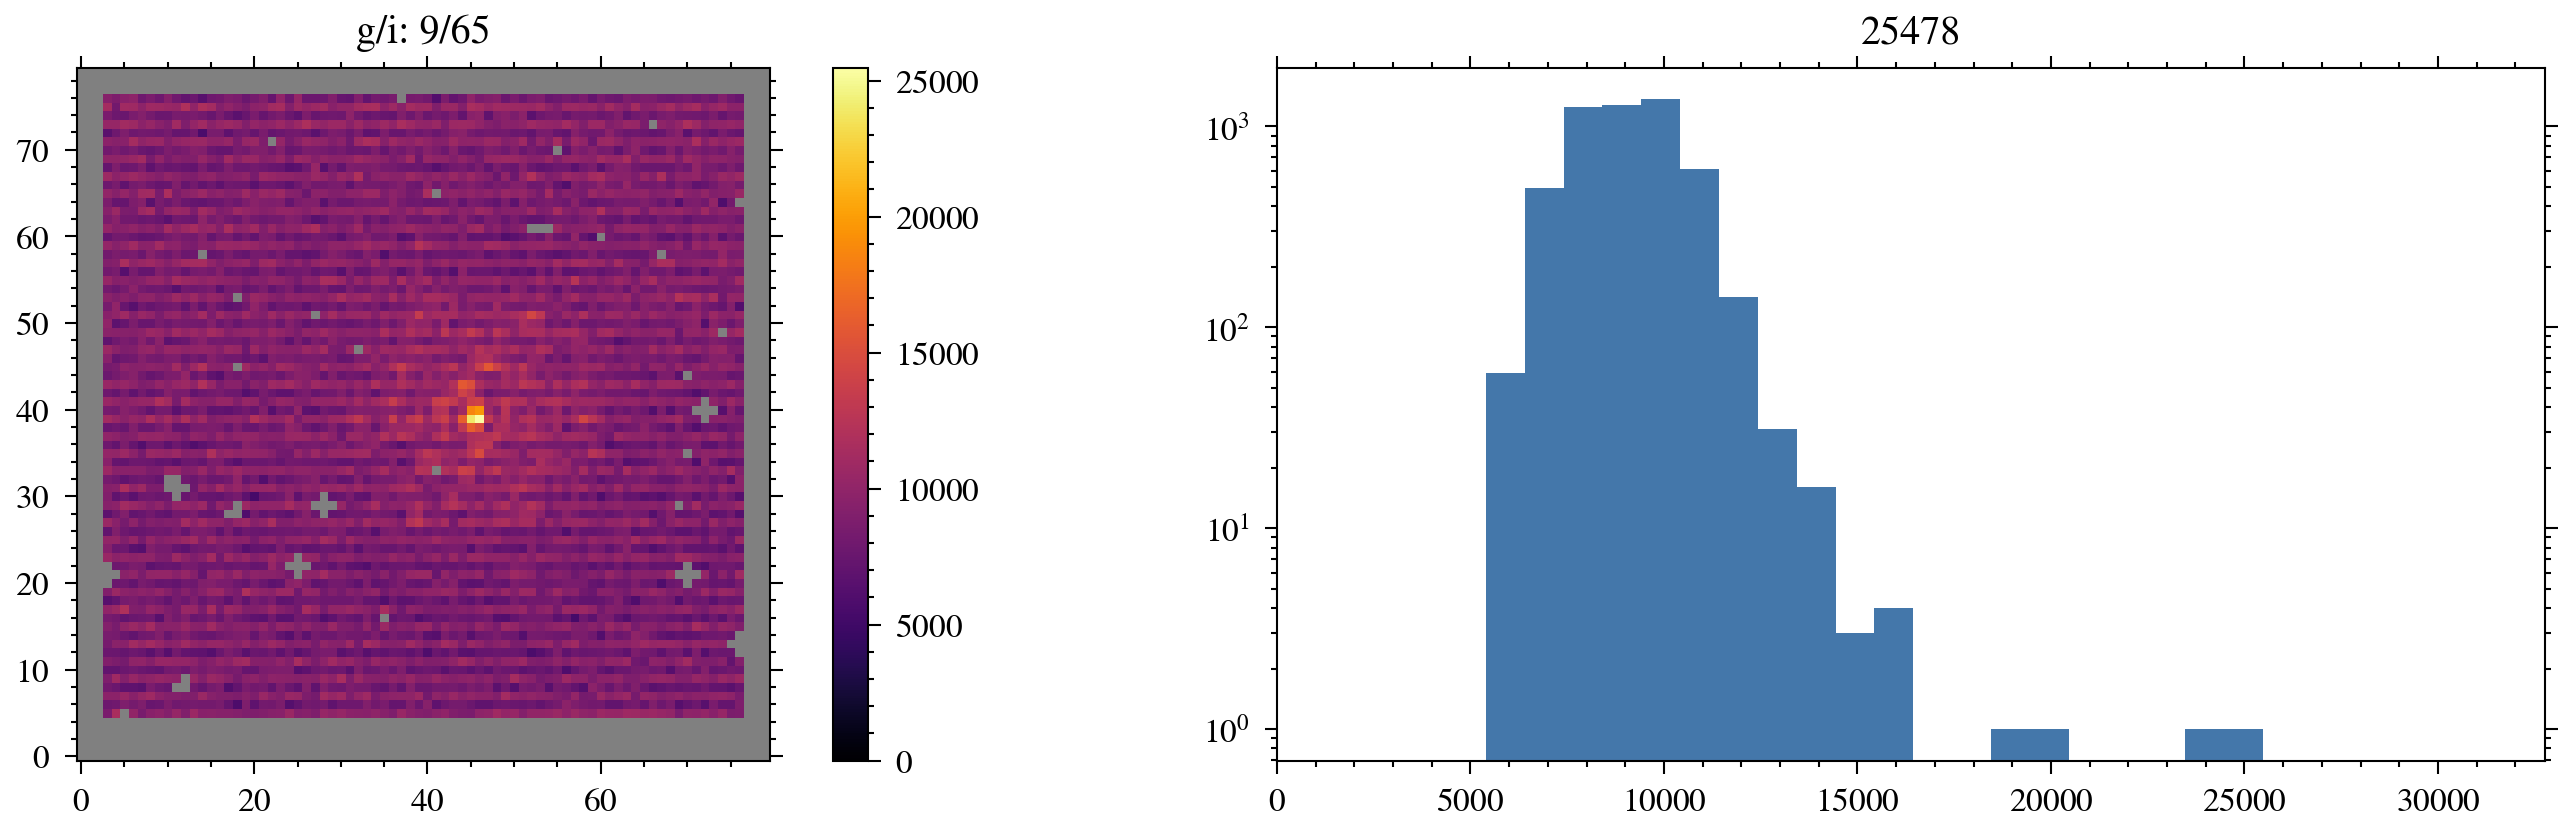




jw01093020001_03102_00024_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  24/25  9/65  05-06-2022  Thatte, Deepashri  True


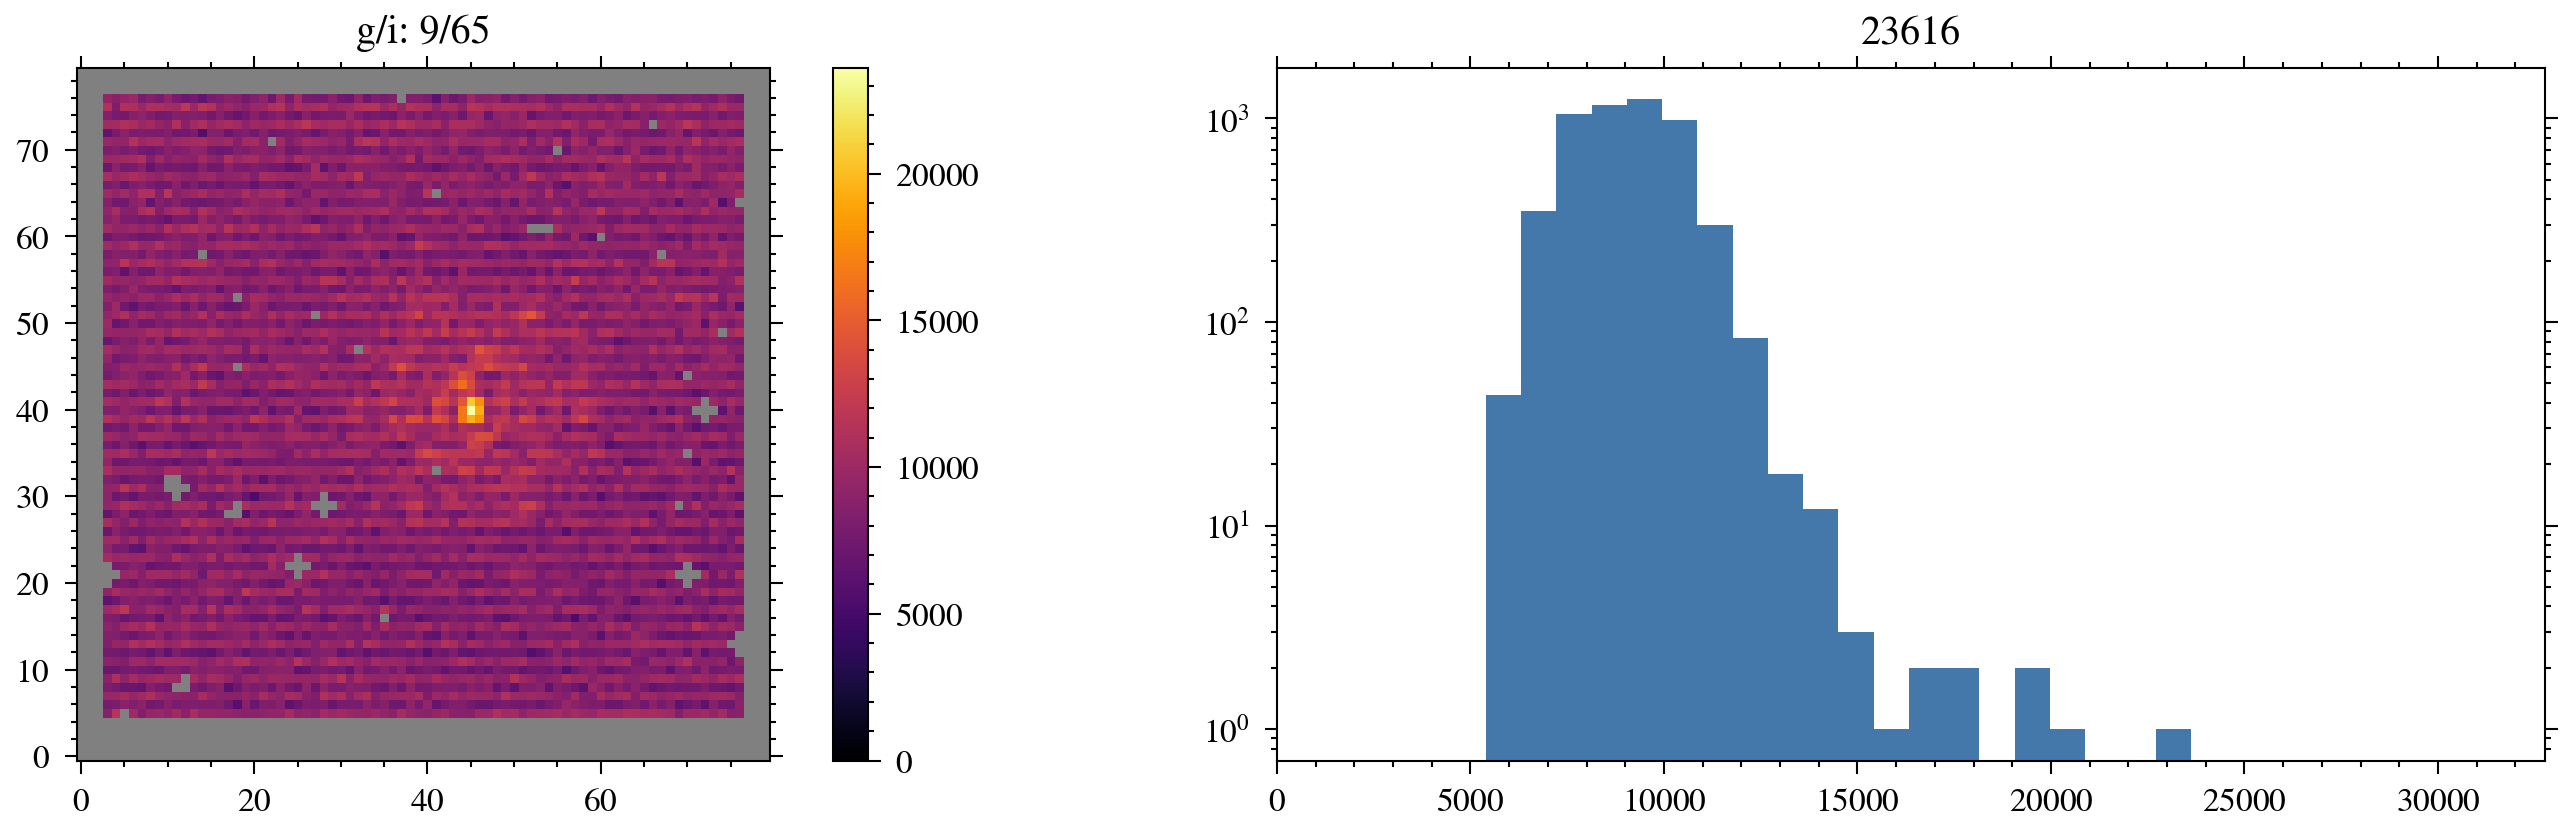




jw01093007001_03102_00013_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  13/25  9/65  23-05-2022  Thatte, Deepashri  True


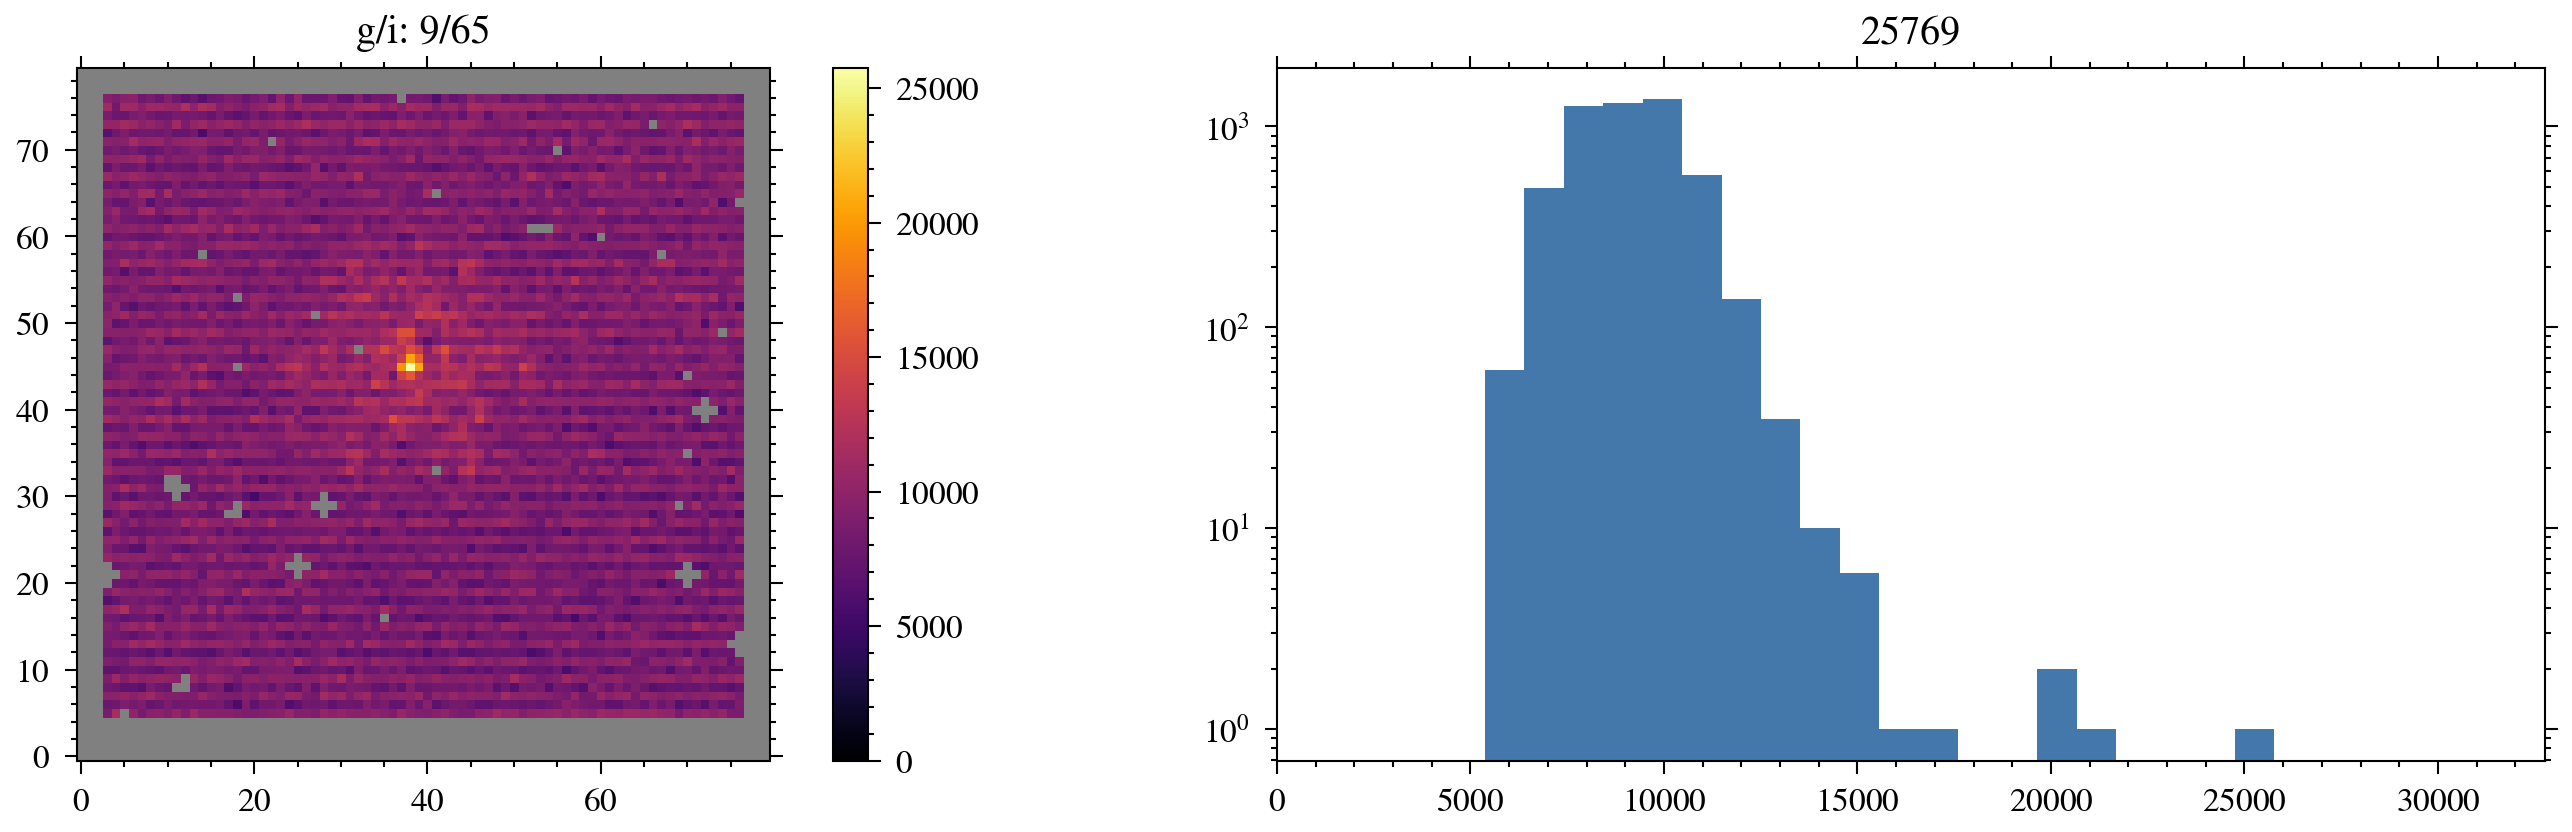




jw01093020001_03102_00017_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  17/25  9/65  05-06-2022  Thatte, Deepashri  True


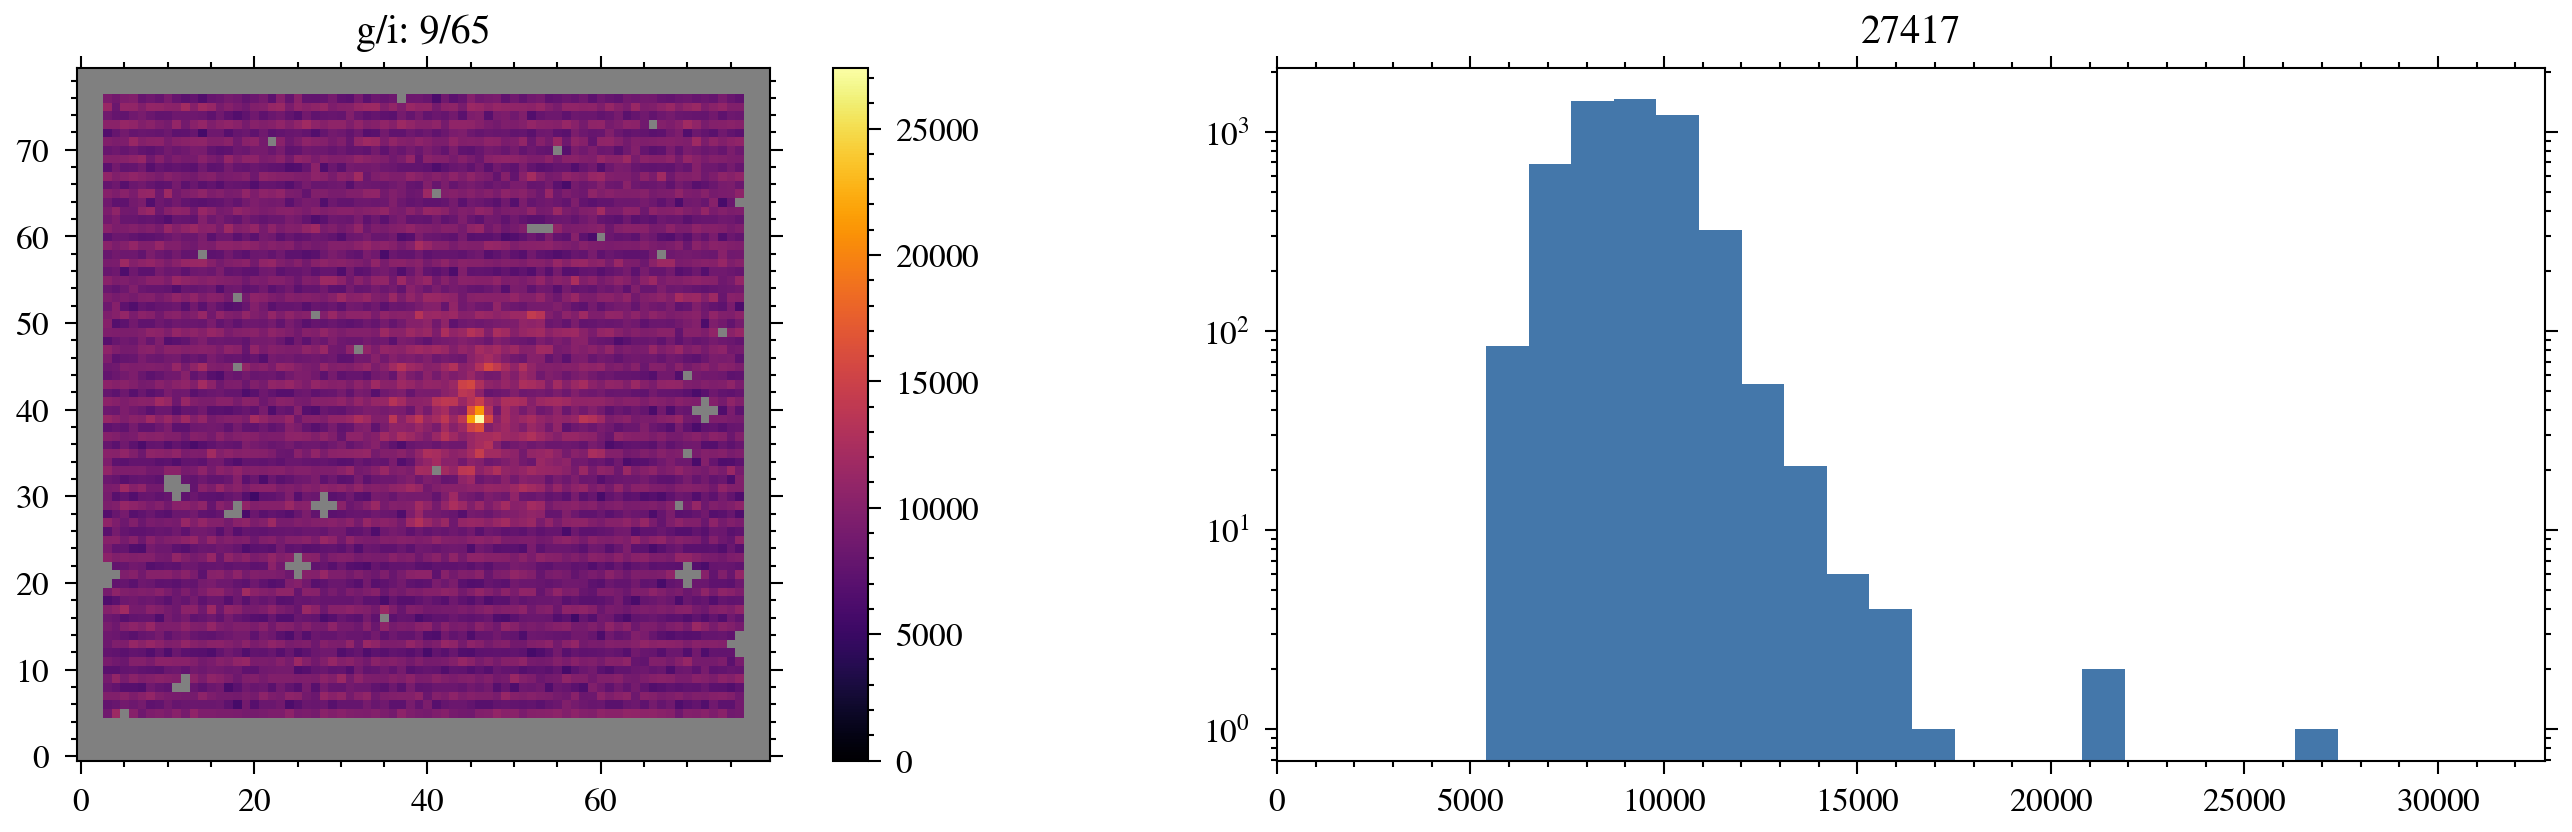




jw01093020001_03102_00025_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  25/25  9/65  05-06-2022  Thatte, Deepashri  True


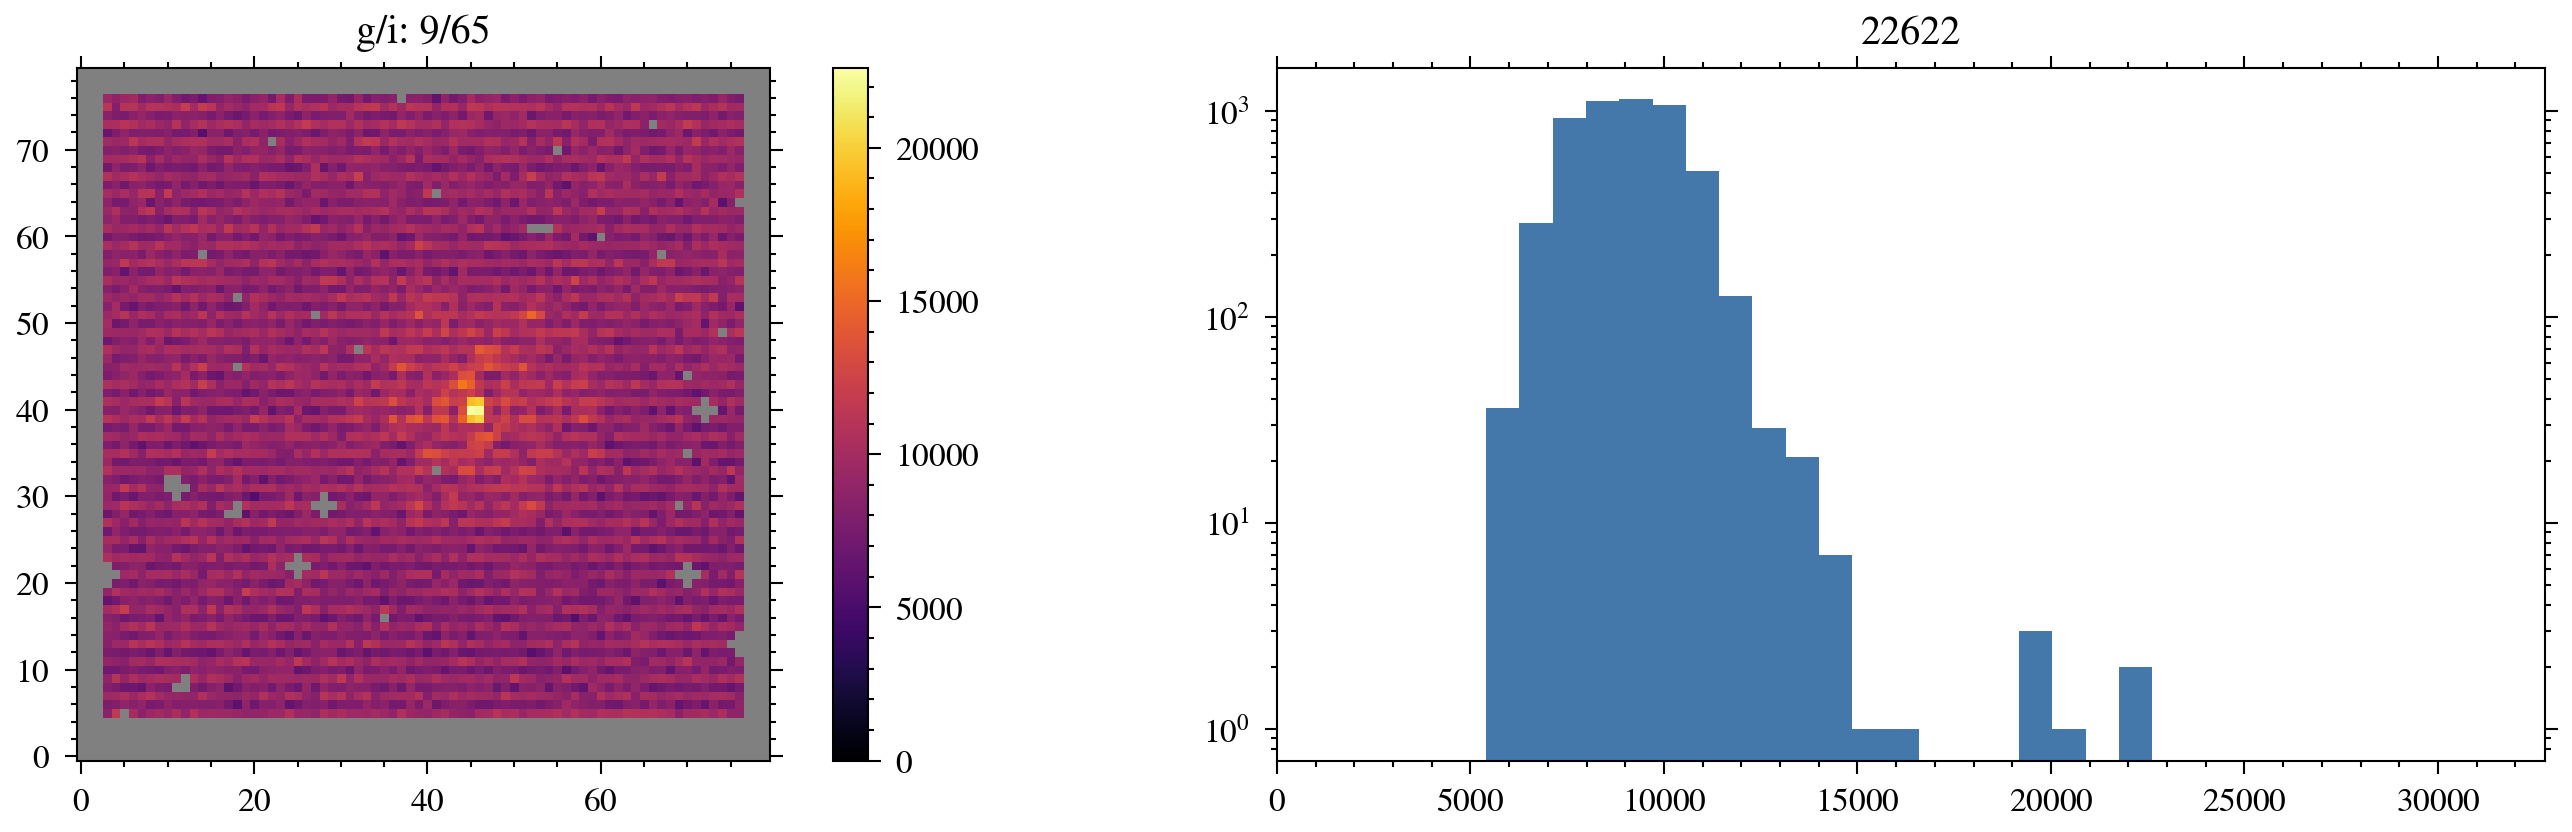




jw01093006001_03106_00001_nis
  program    target filter dither    g/i        date                 PI   CAL
0    1093  HD-36805  F380M    1/2  3/122  23-05-2022  Thatte, Deepashri  True


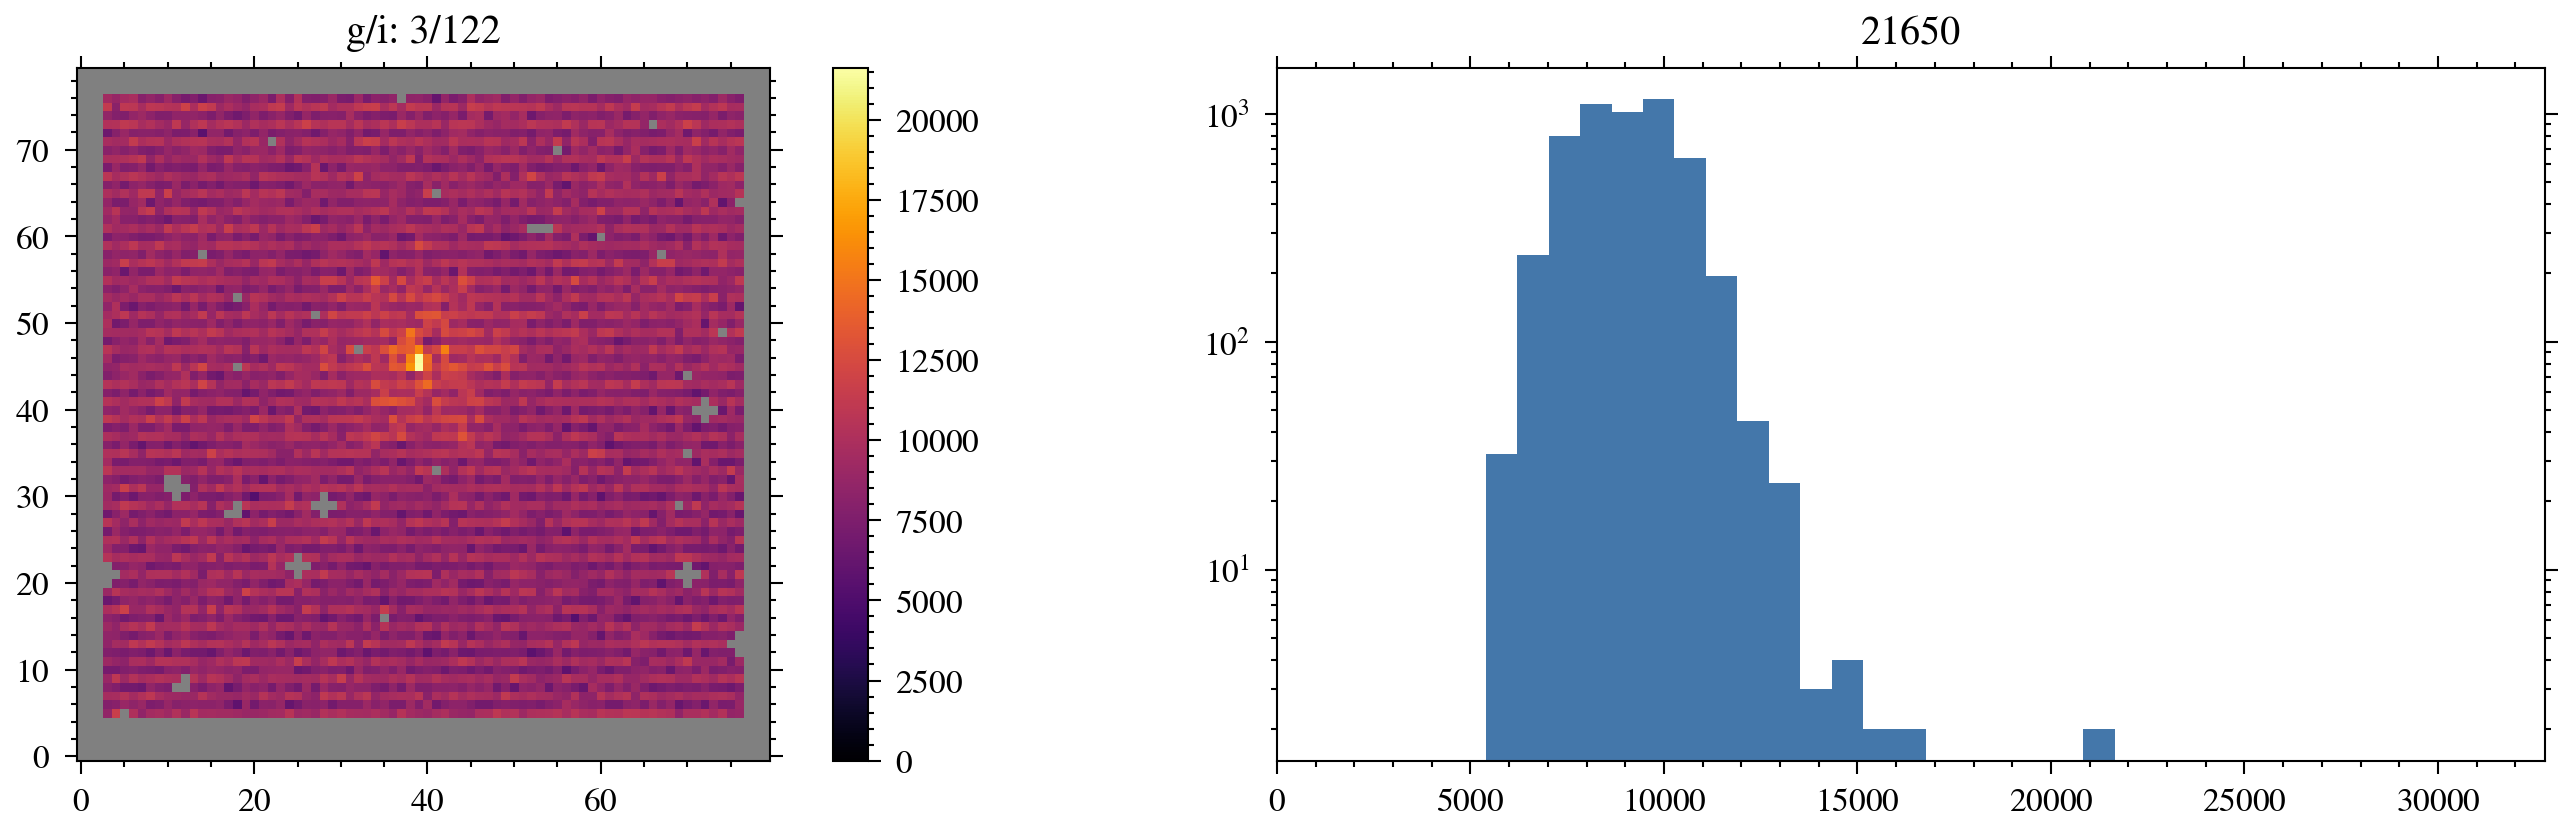




jw01093020001_03102_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   1/25  9/65  05-06-2022  Thatte, Deepashri  True


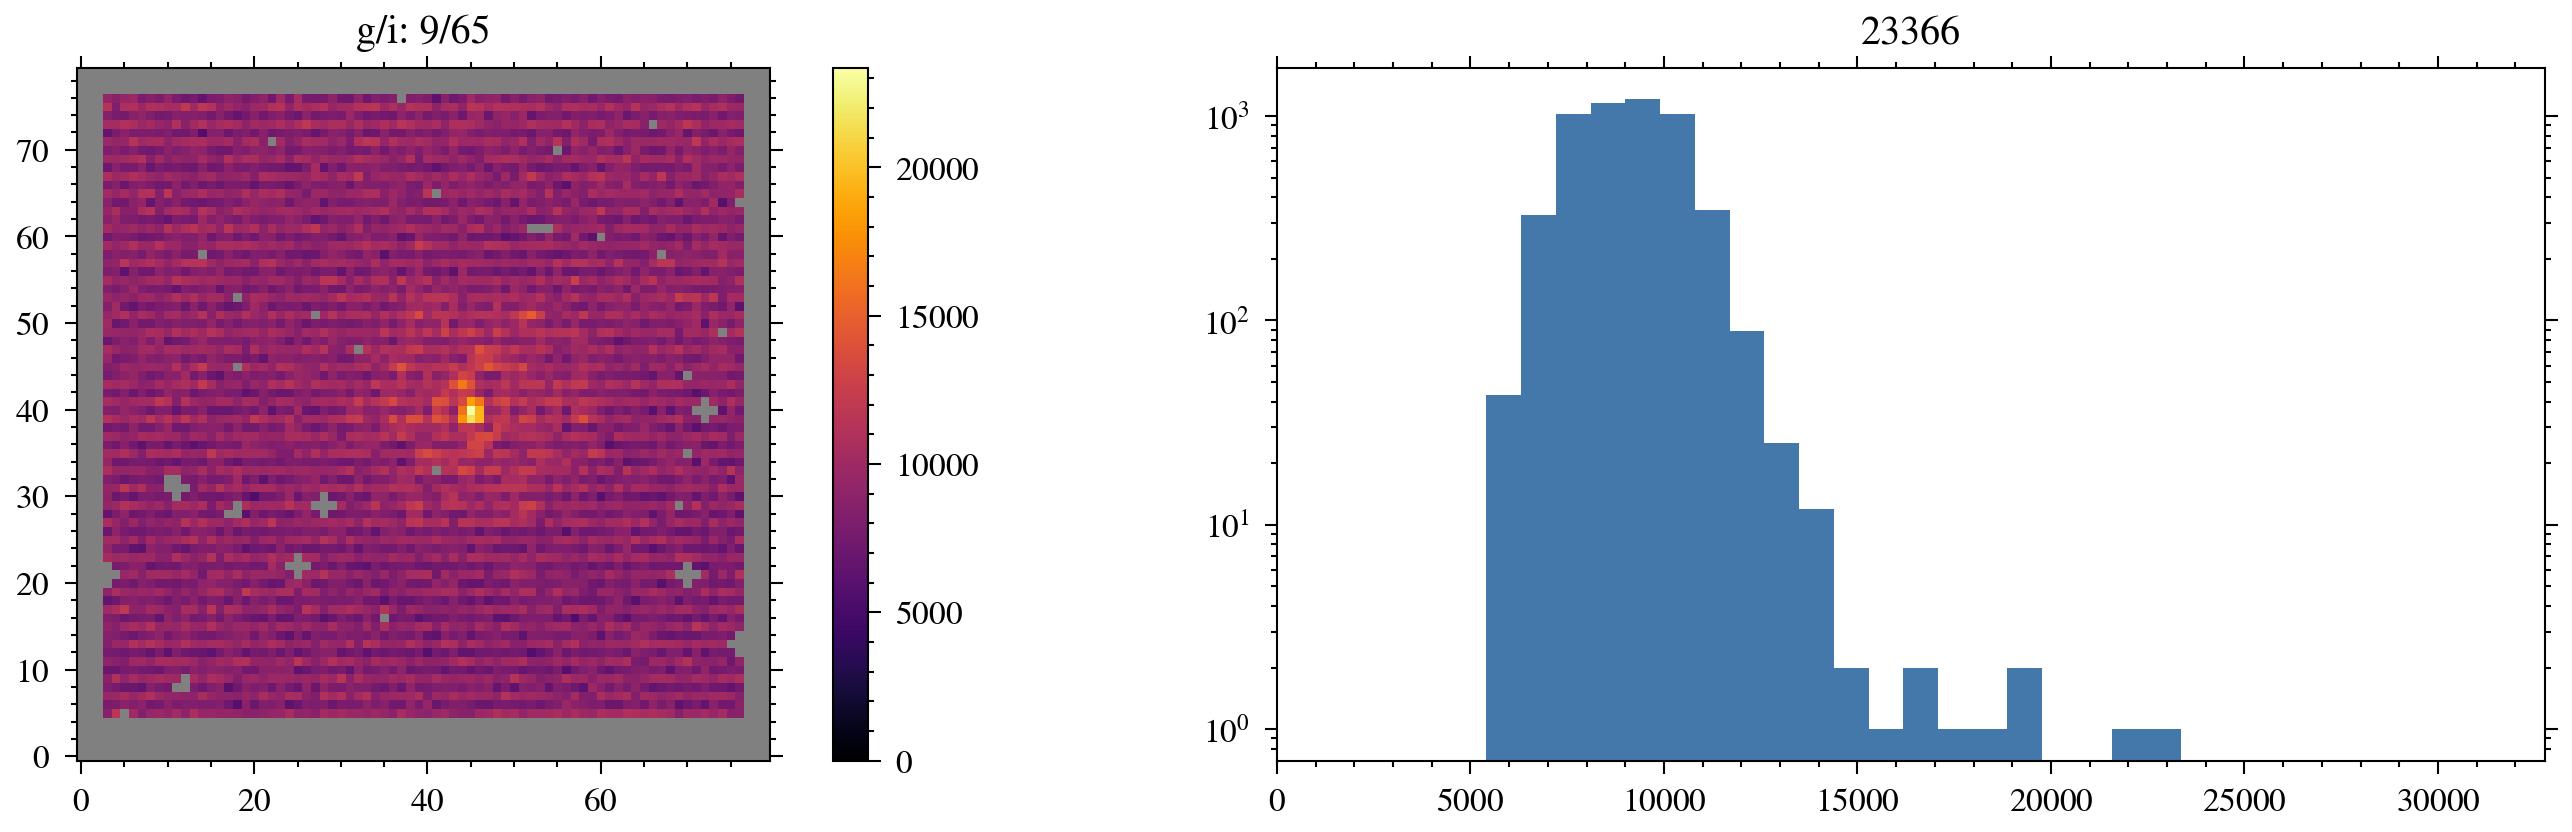




jw01093007001_03102_00024_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  24/25  9/65  23-05-2022  Thatte, Deepashri  True


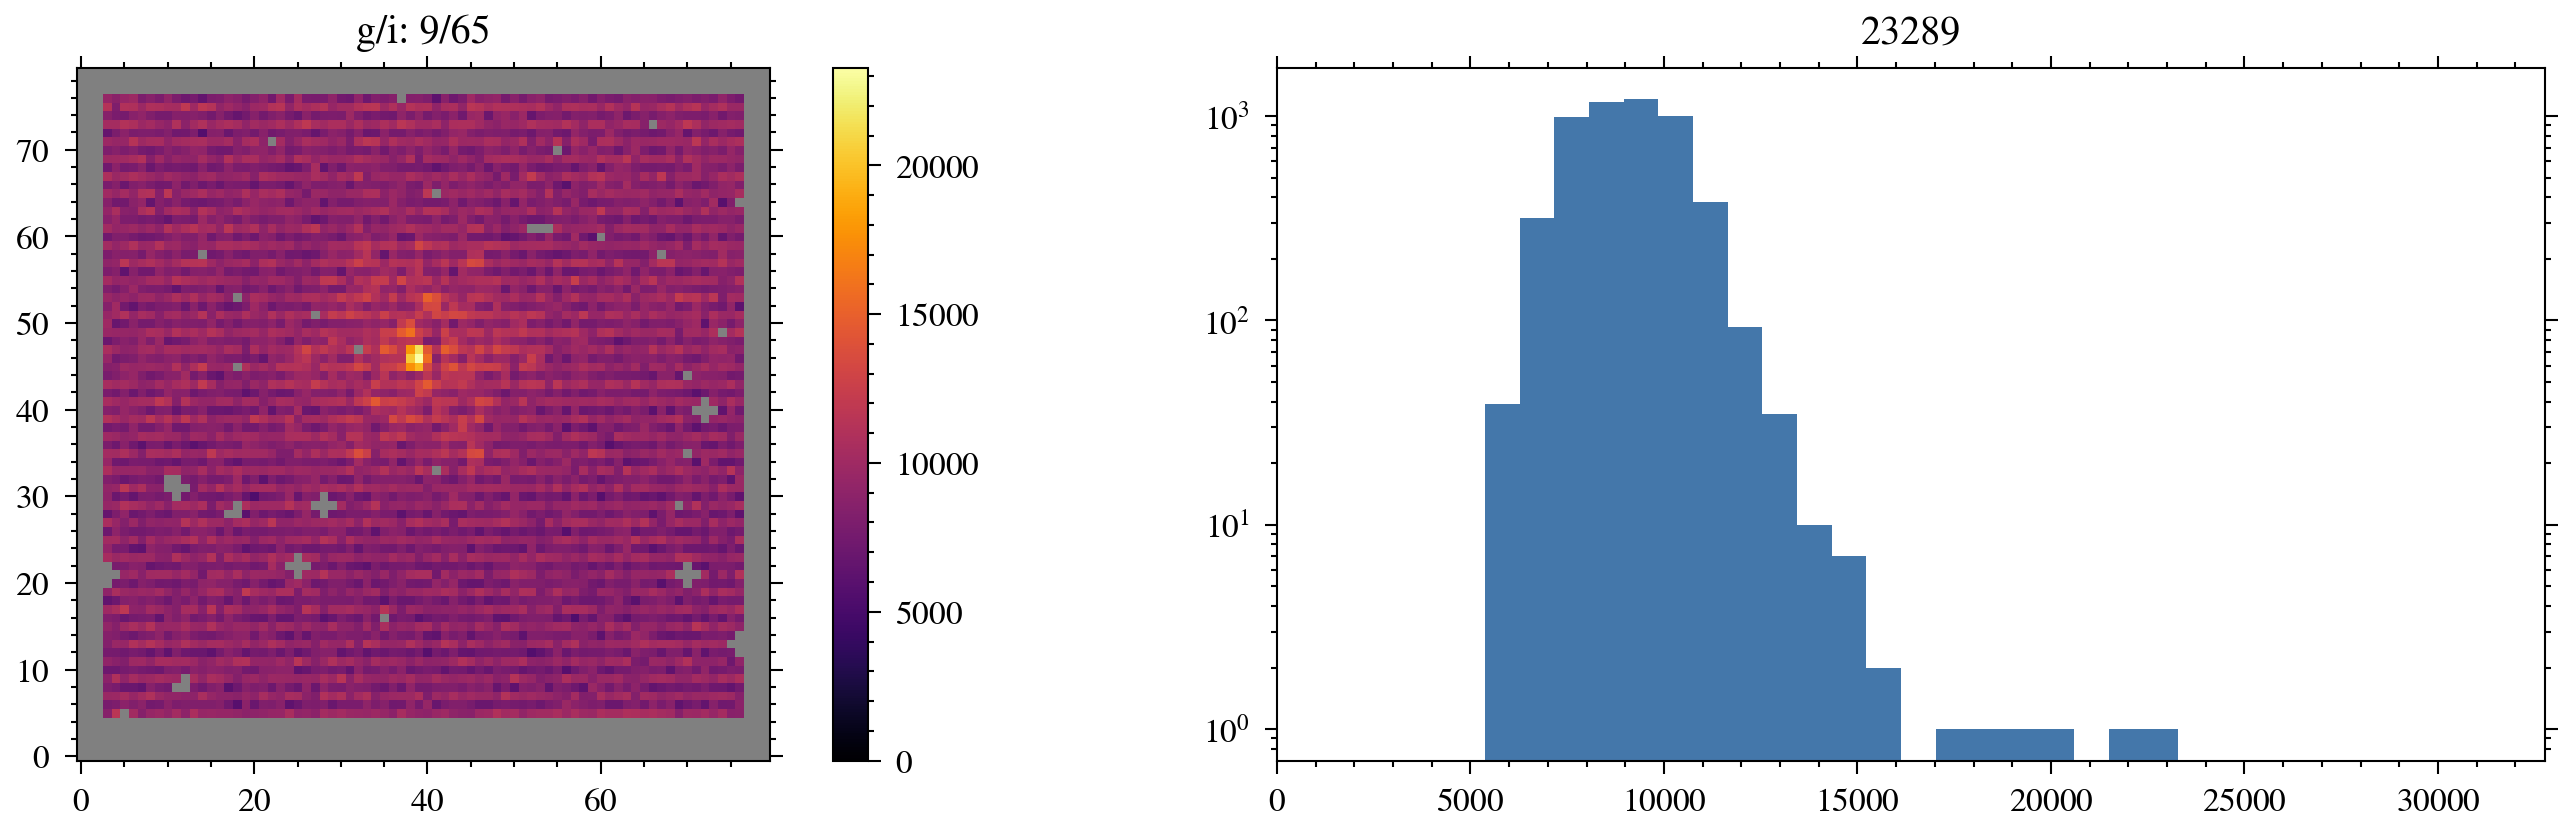




jw01093007001_03102_00003_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   3/25  9/65  23-05-2022  Thatte, Deepashri  True


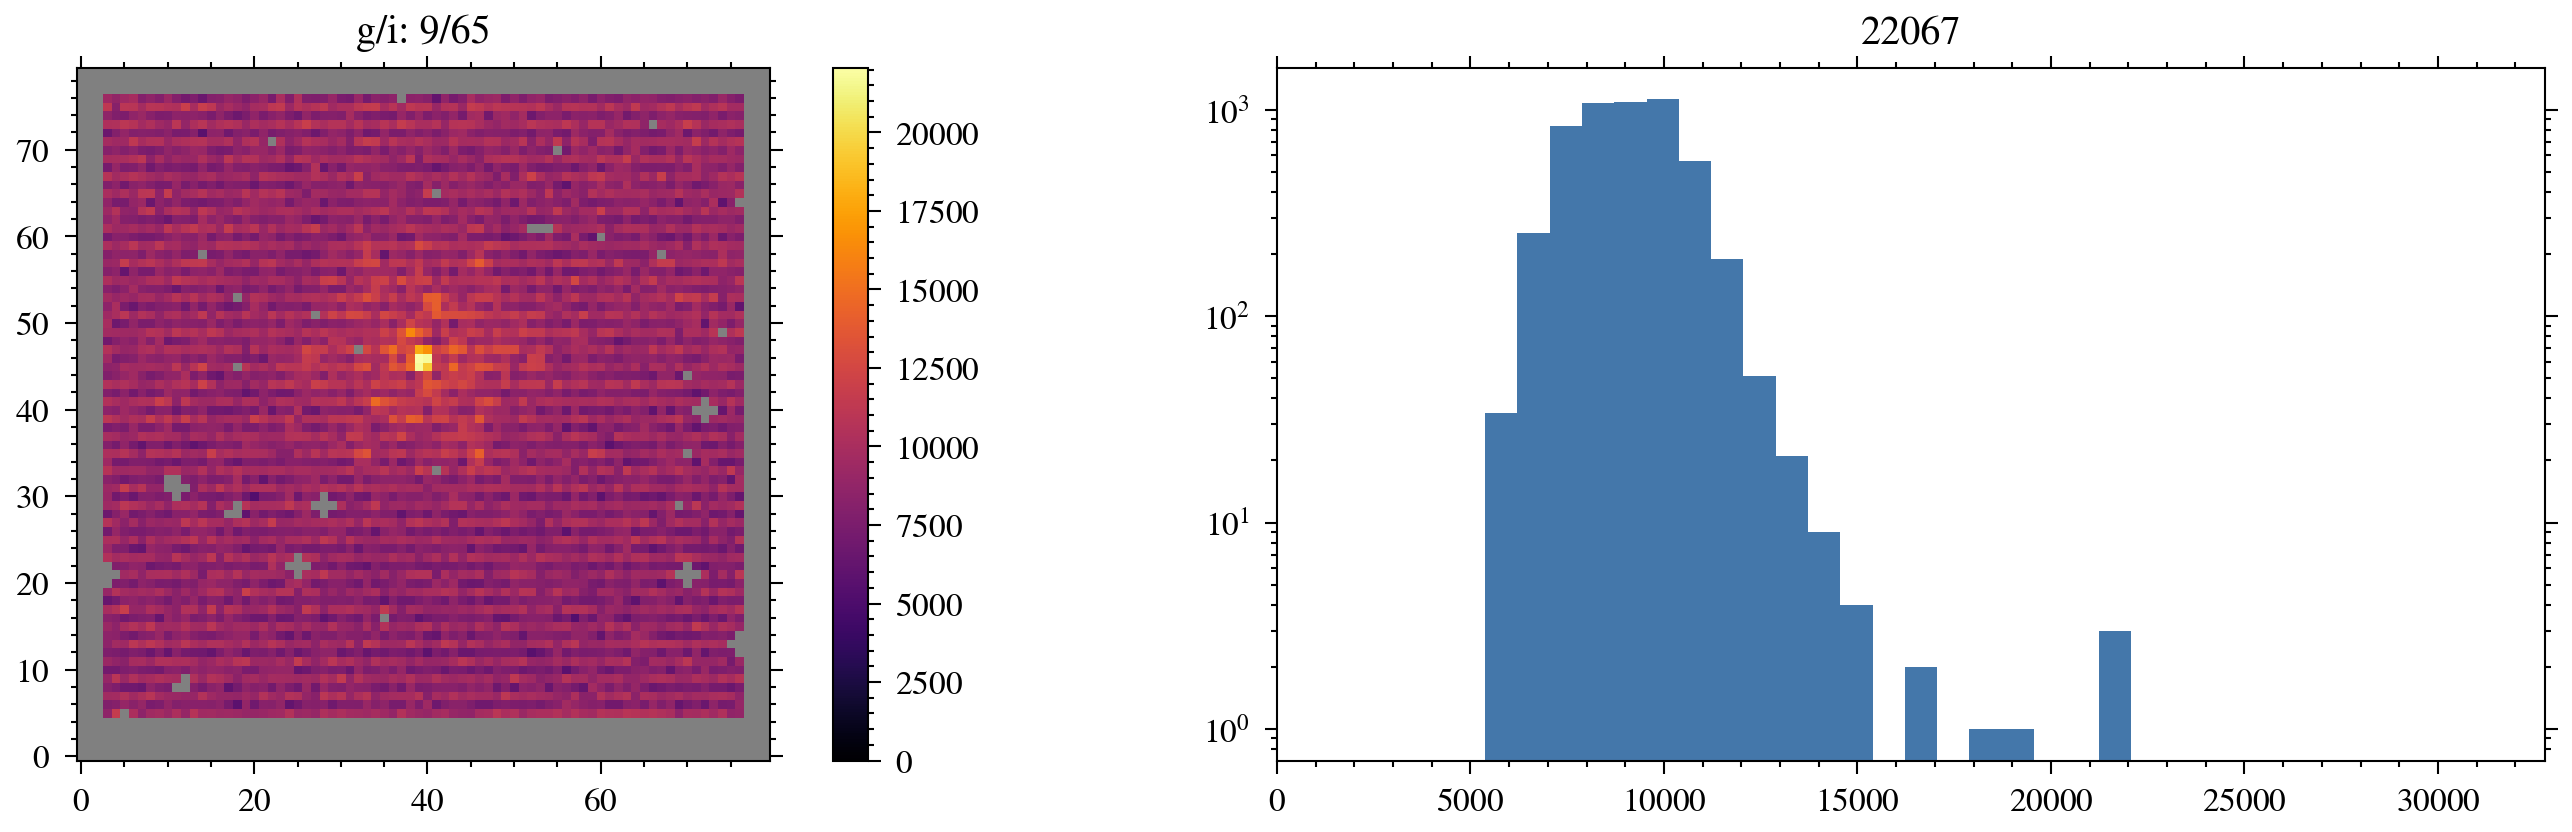




jw01093020001_03102_00010_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  10/25  9/65  05-06-2022  Thatte, Deepashri  True


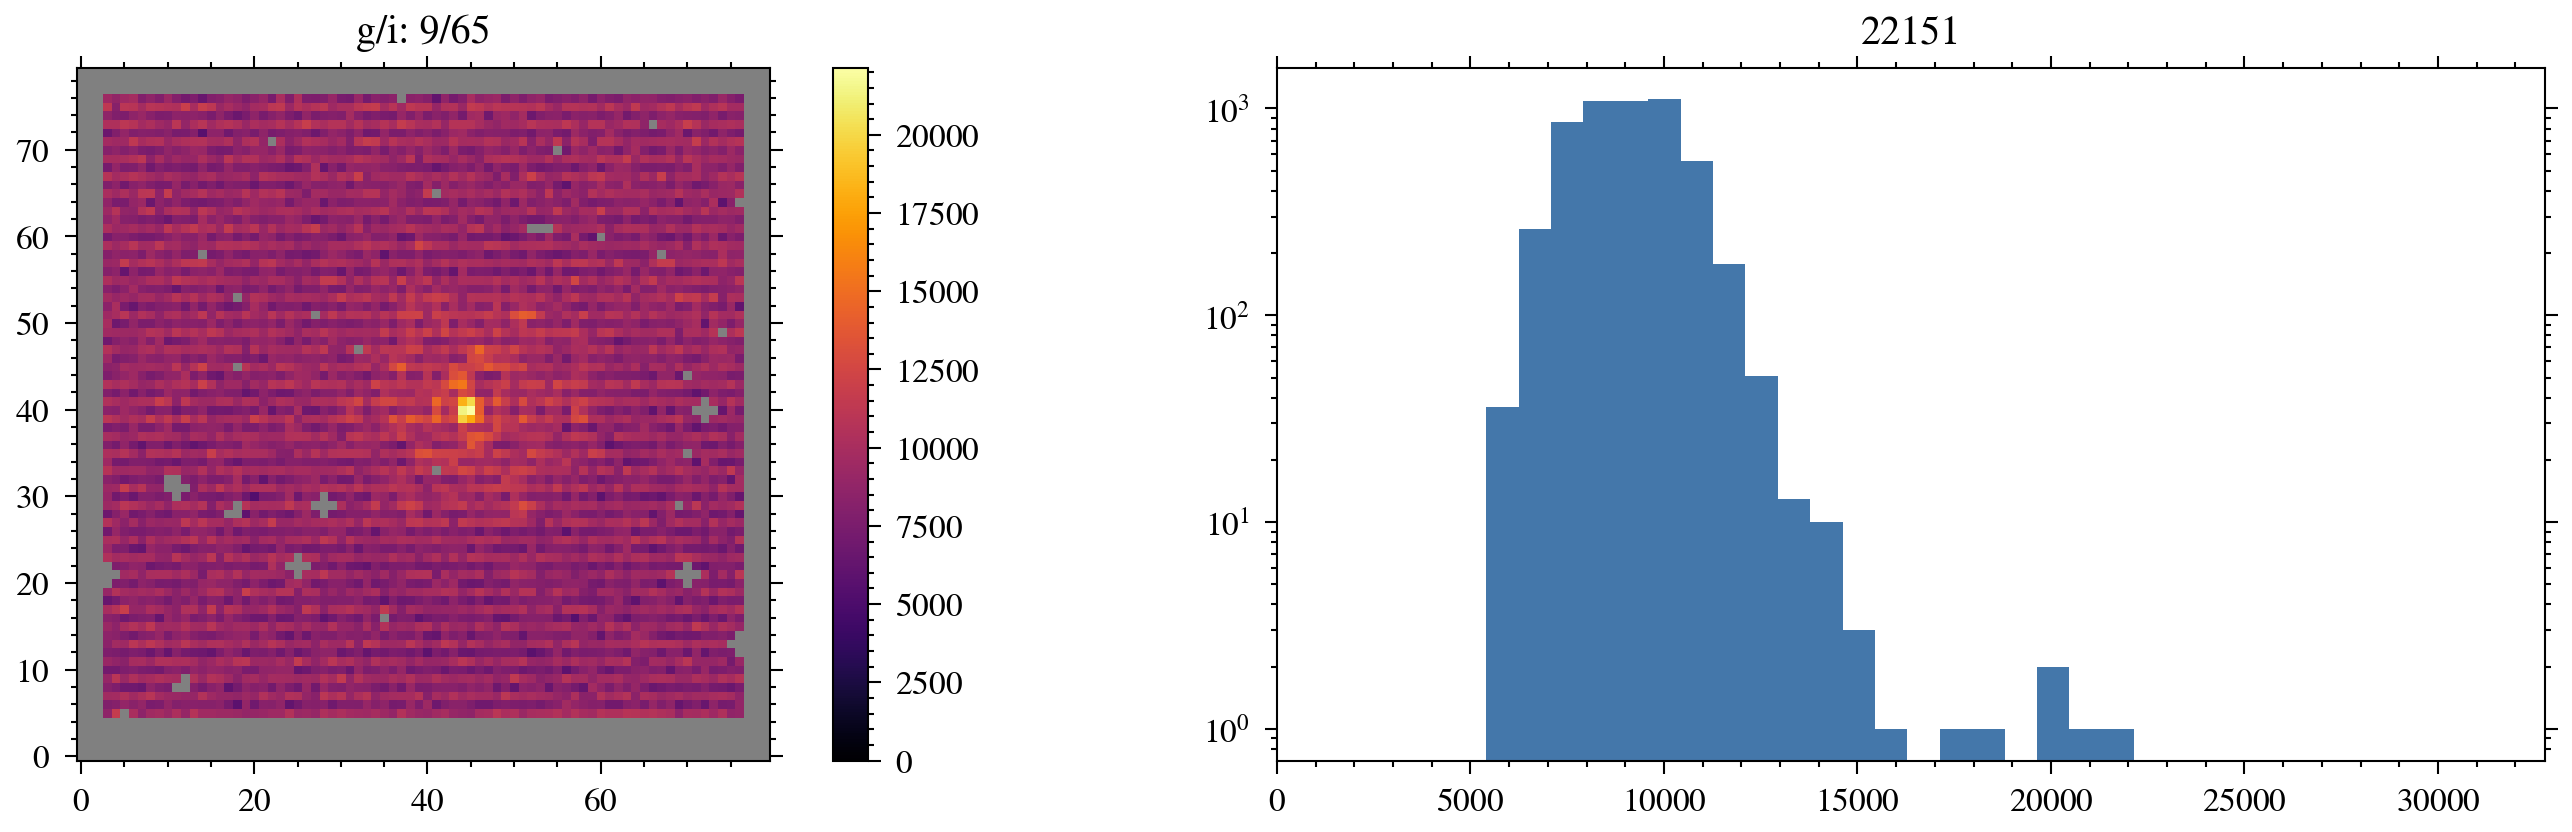




jw01093007001_03102_00005_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   5/25  9/65  23-05-2022  Thatte, Deepashri  True


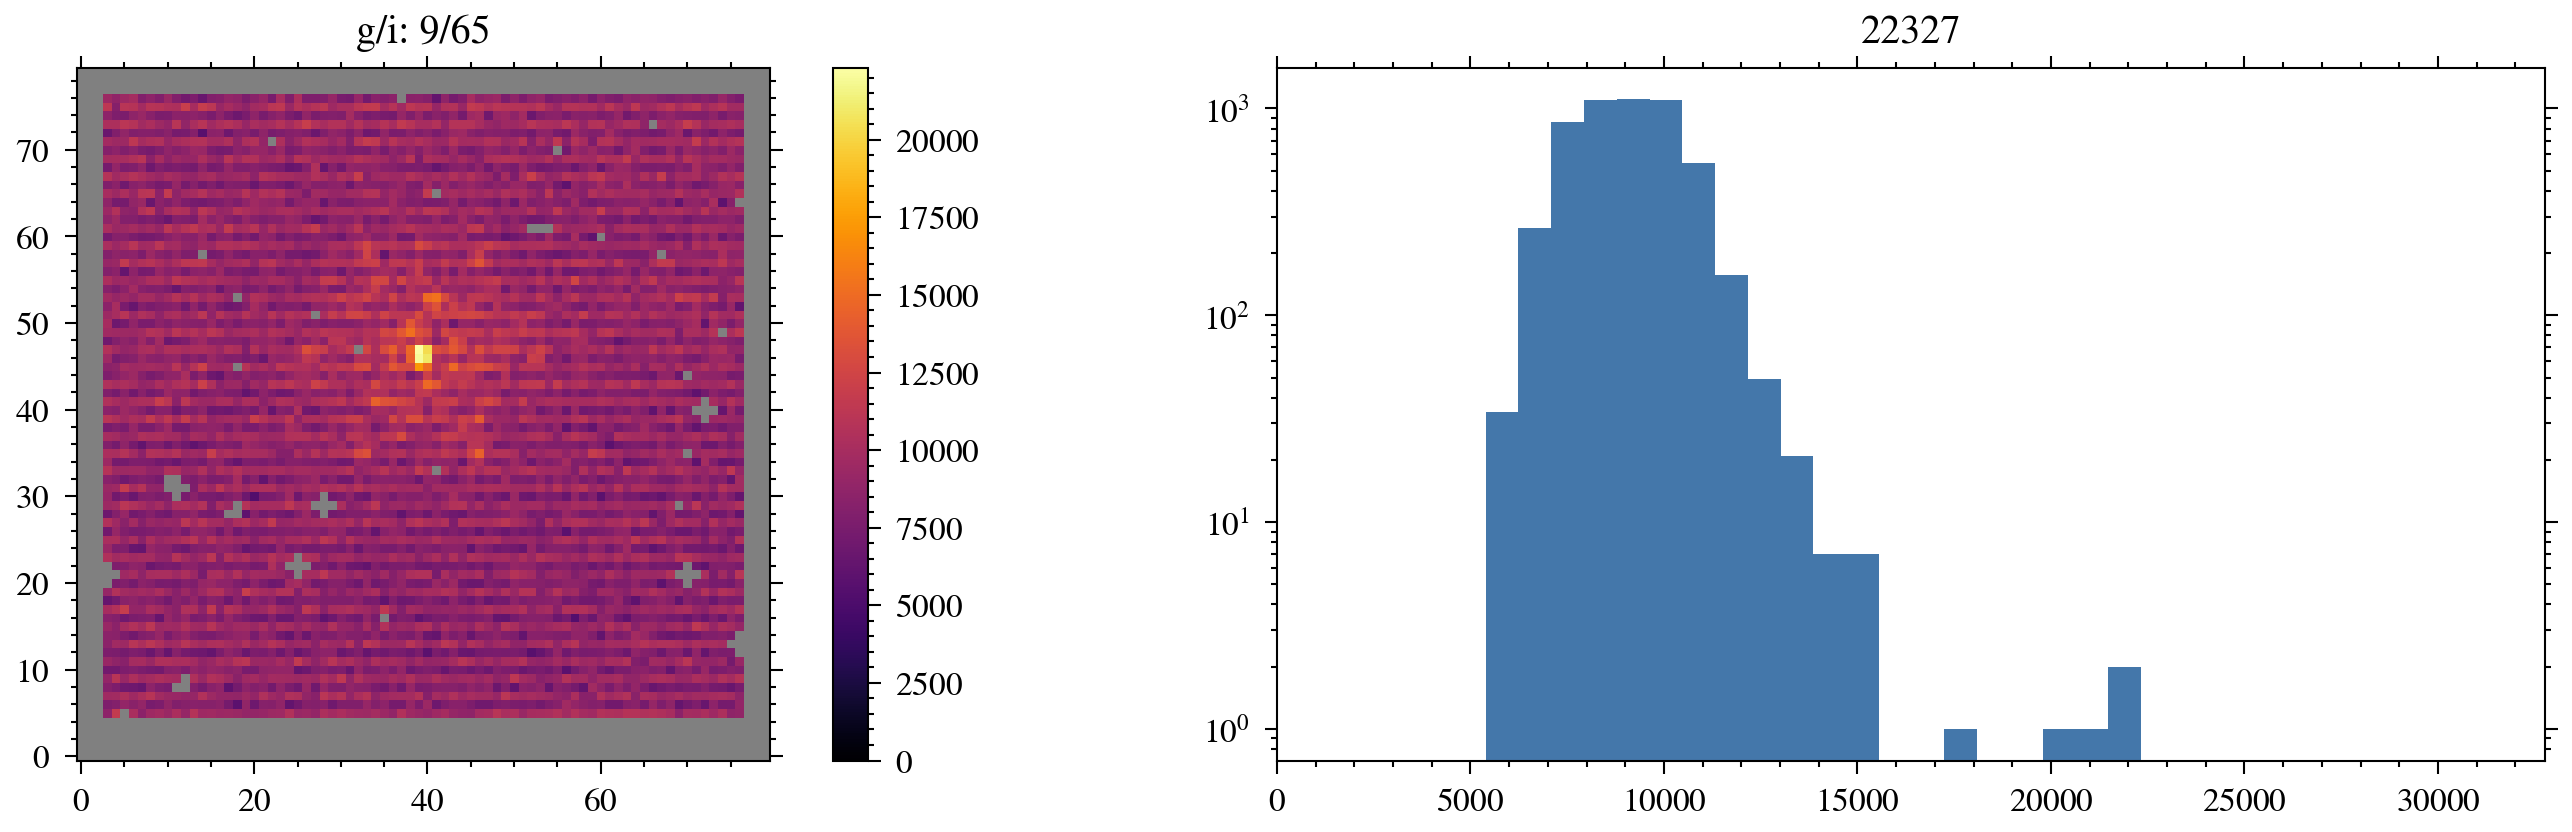




jw01093020001_03102_00015_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  15/25  9/65  05-06-2022  Thatte, Deepashri  True


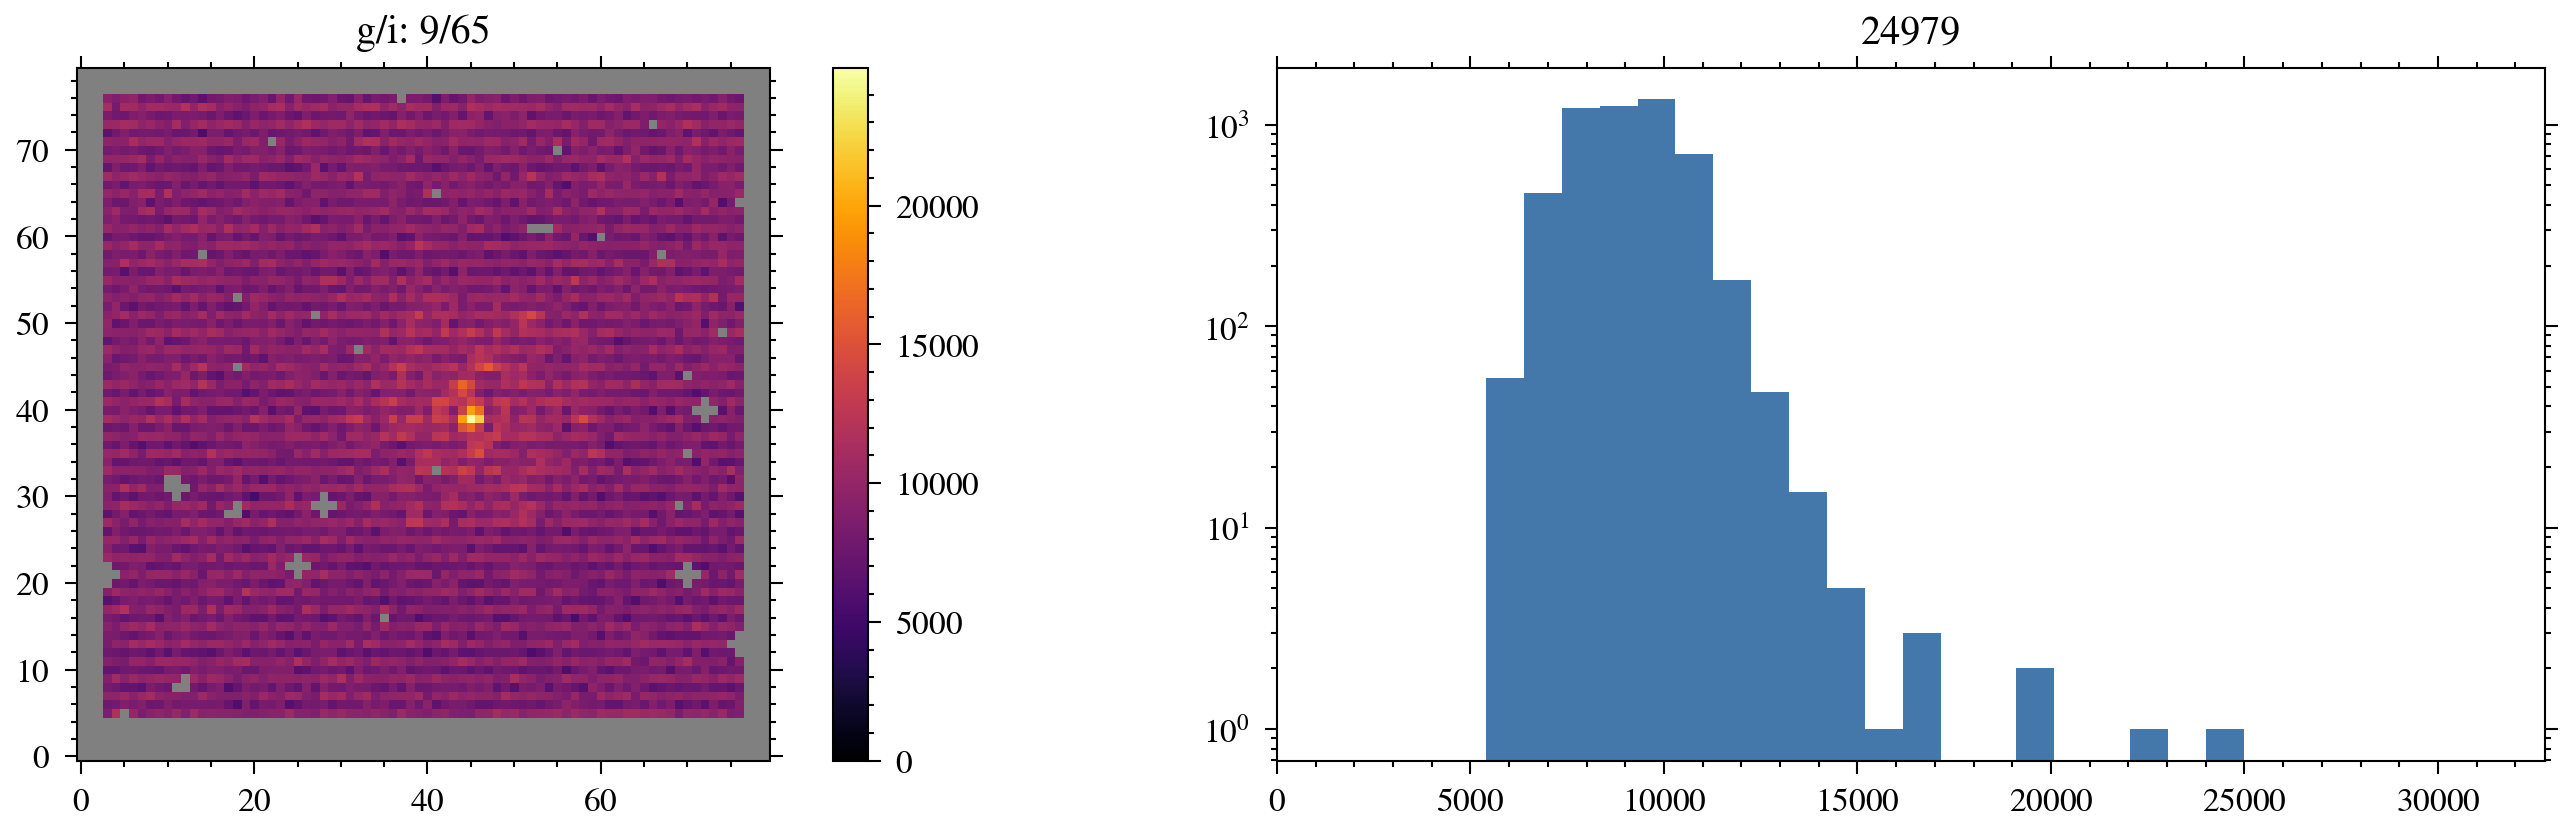




jw01093020001_03102_00014_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  14/25  9/65  05-06-2022  Thatte, Deepashri  True


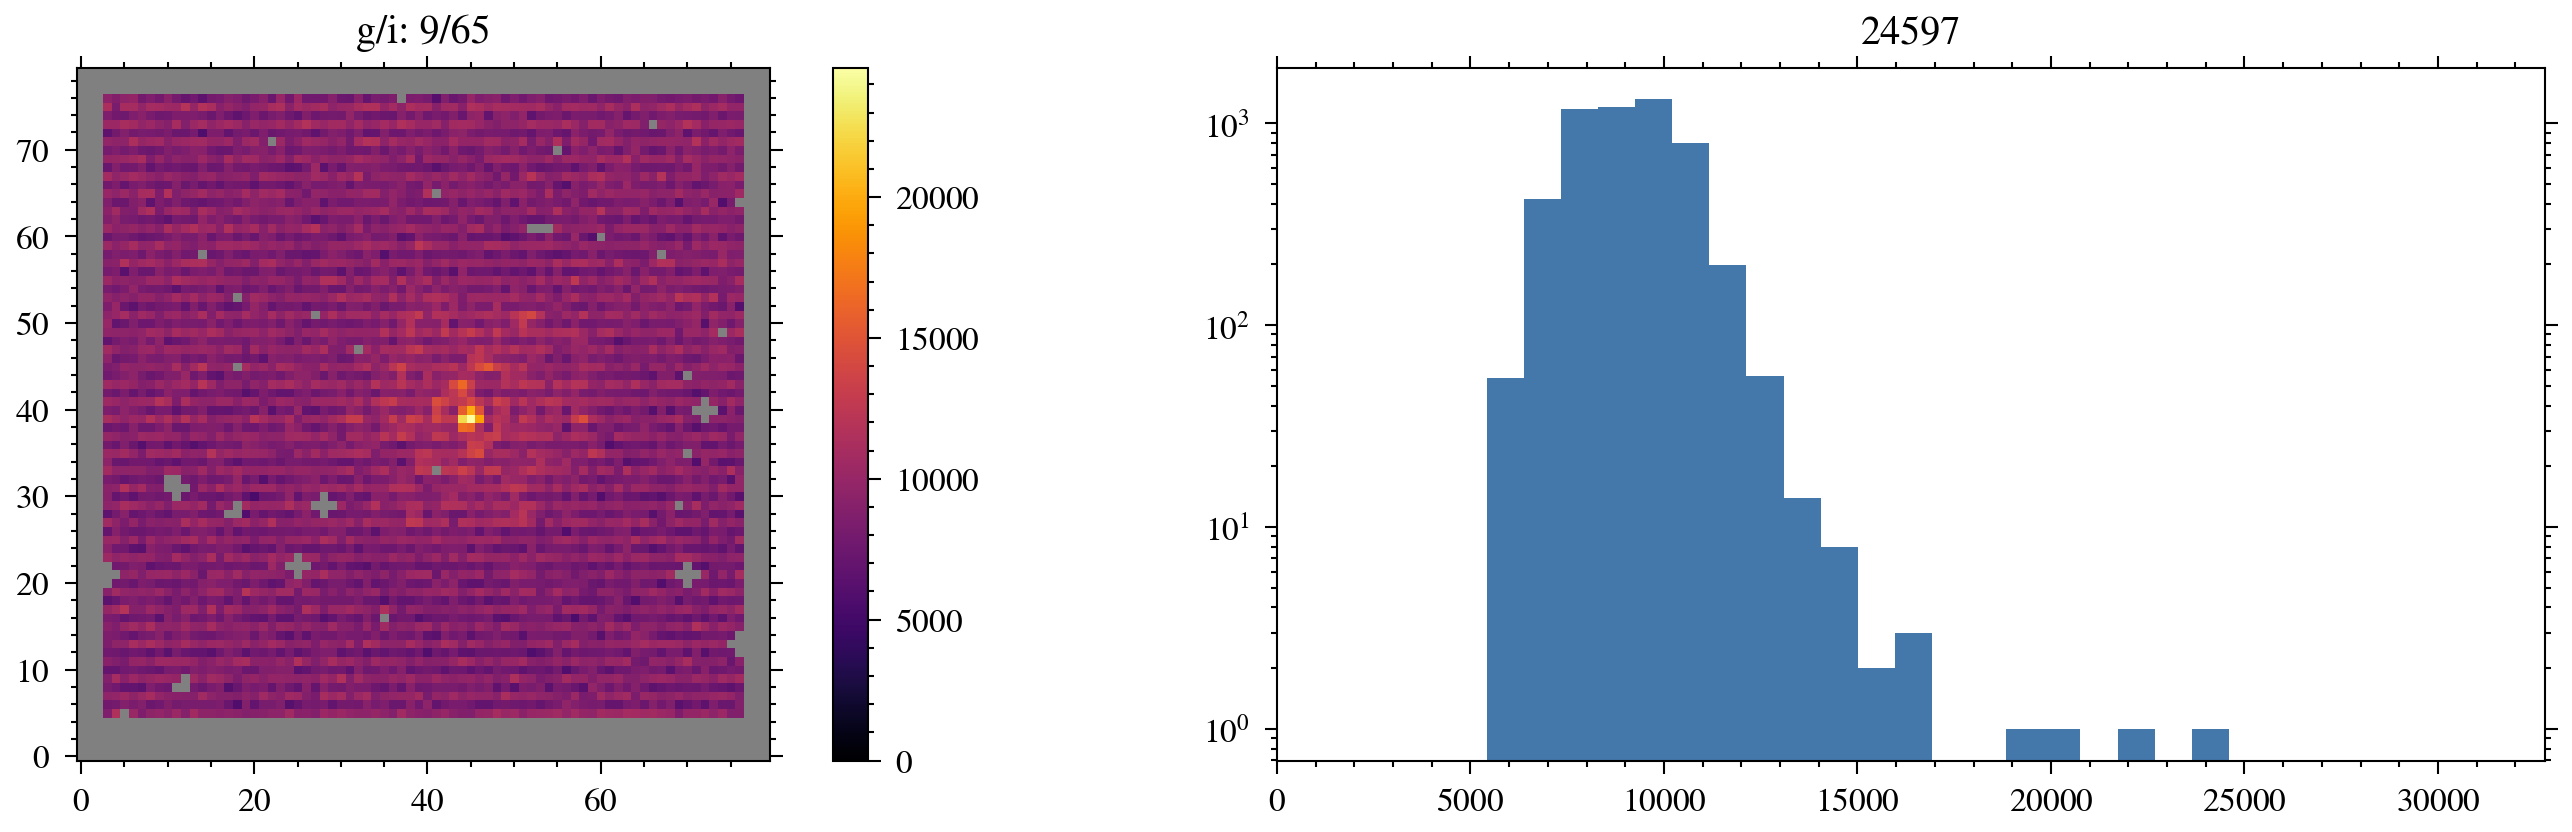




jw01093007001_03102_00009_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   9/25  9/65  23-05-2022  Thatte, Deepashri  True


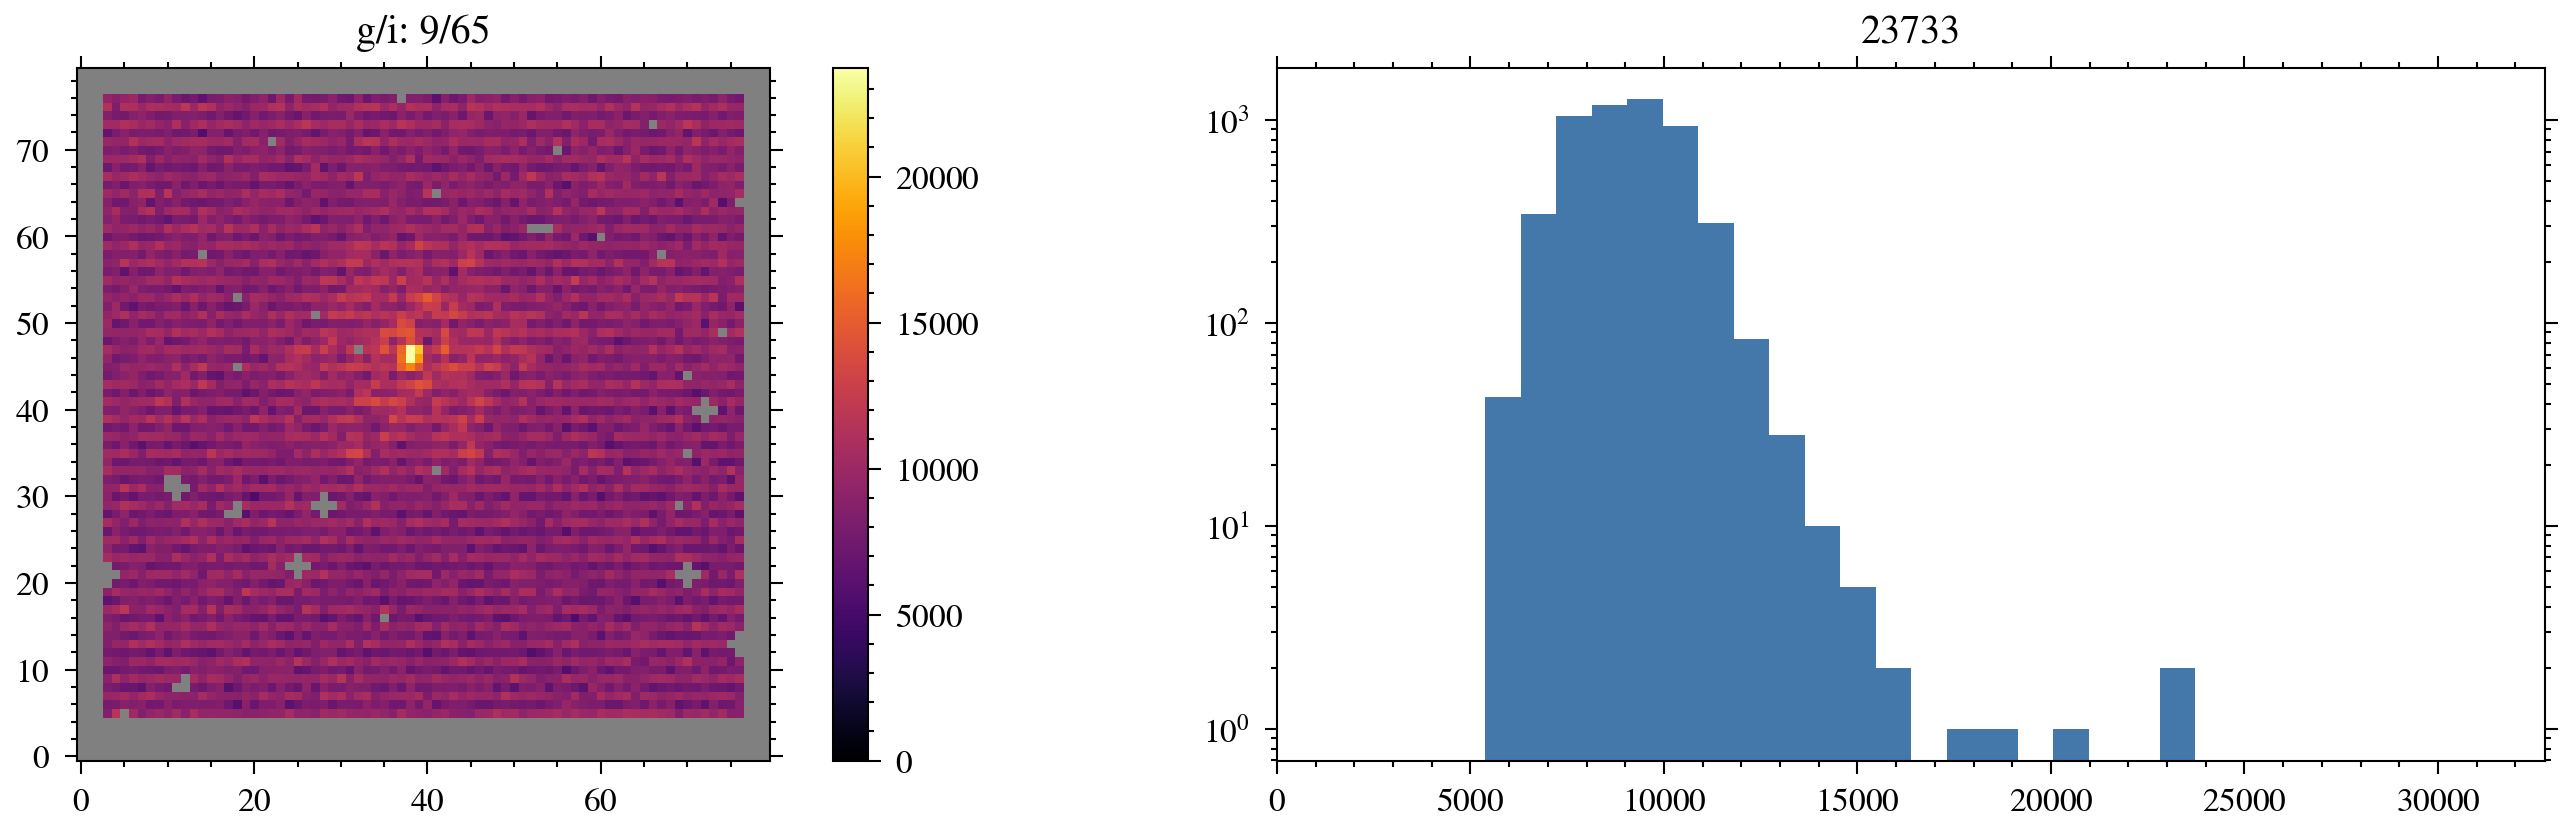




jw01093020001_03102_00008_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   8/25  9/65  05-06-2022  Thatte, Deepashri  True


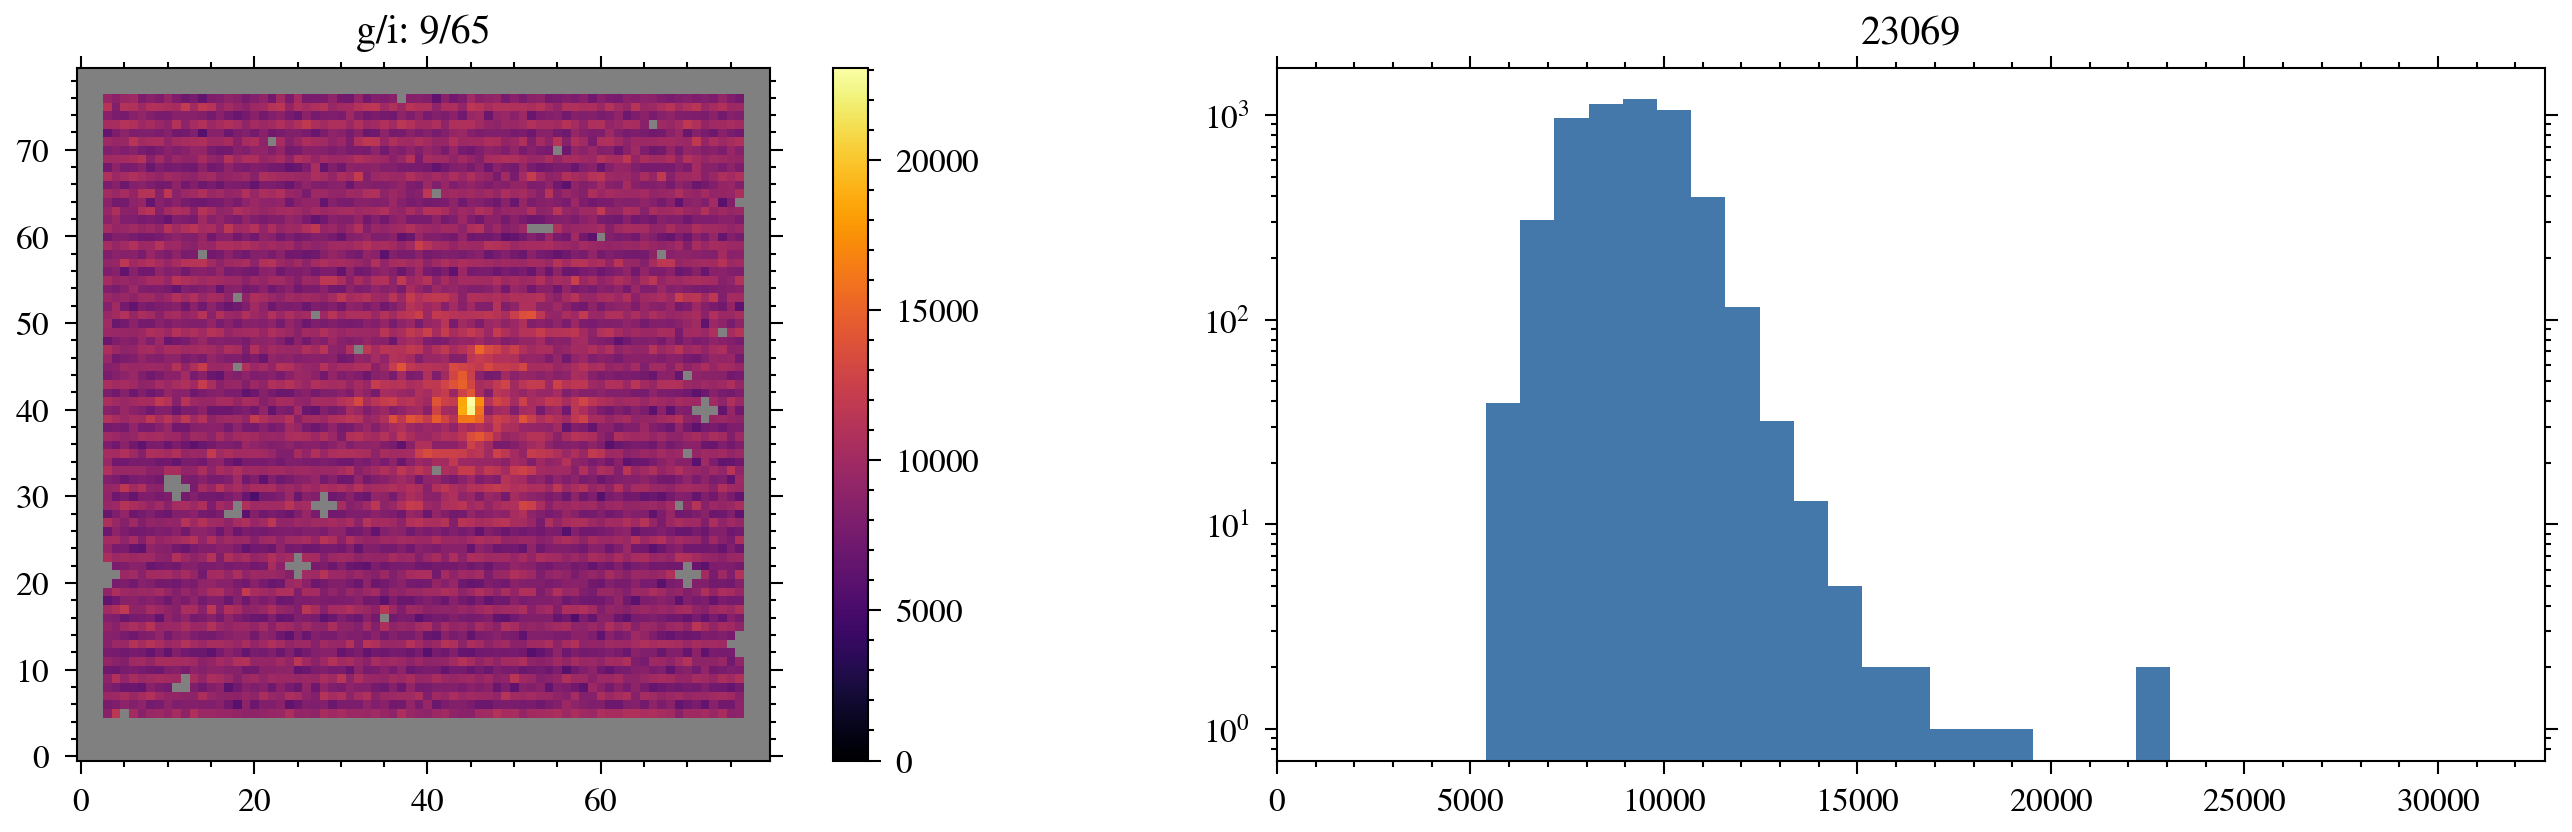




jw01093020001_03102_00022_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  22/25  9/65  05-06-2022  Thatte, Deepashri  True


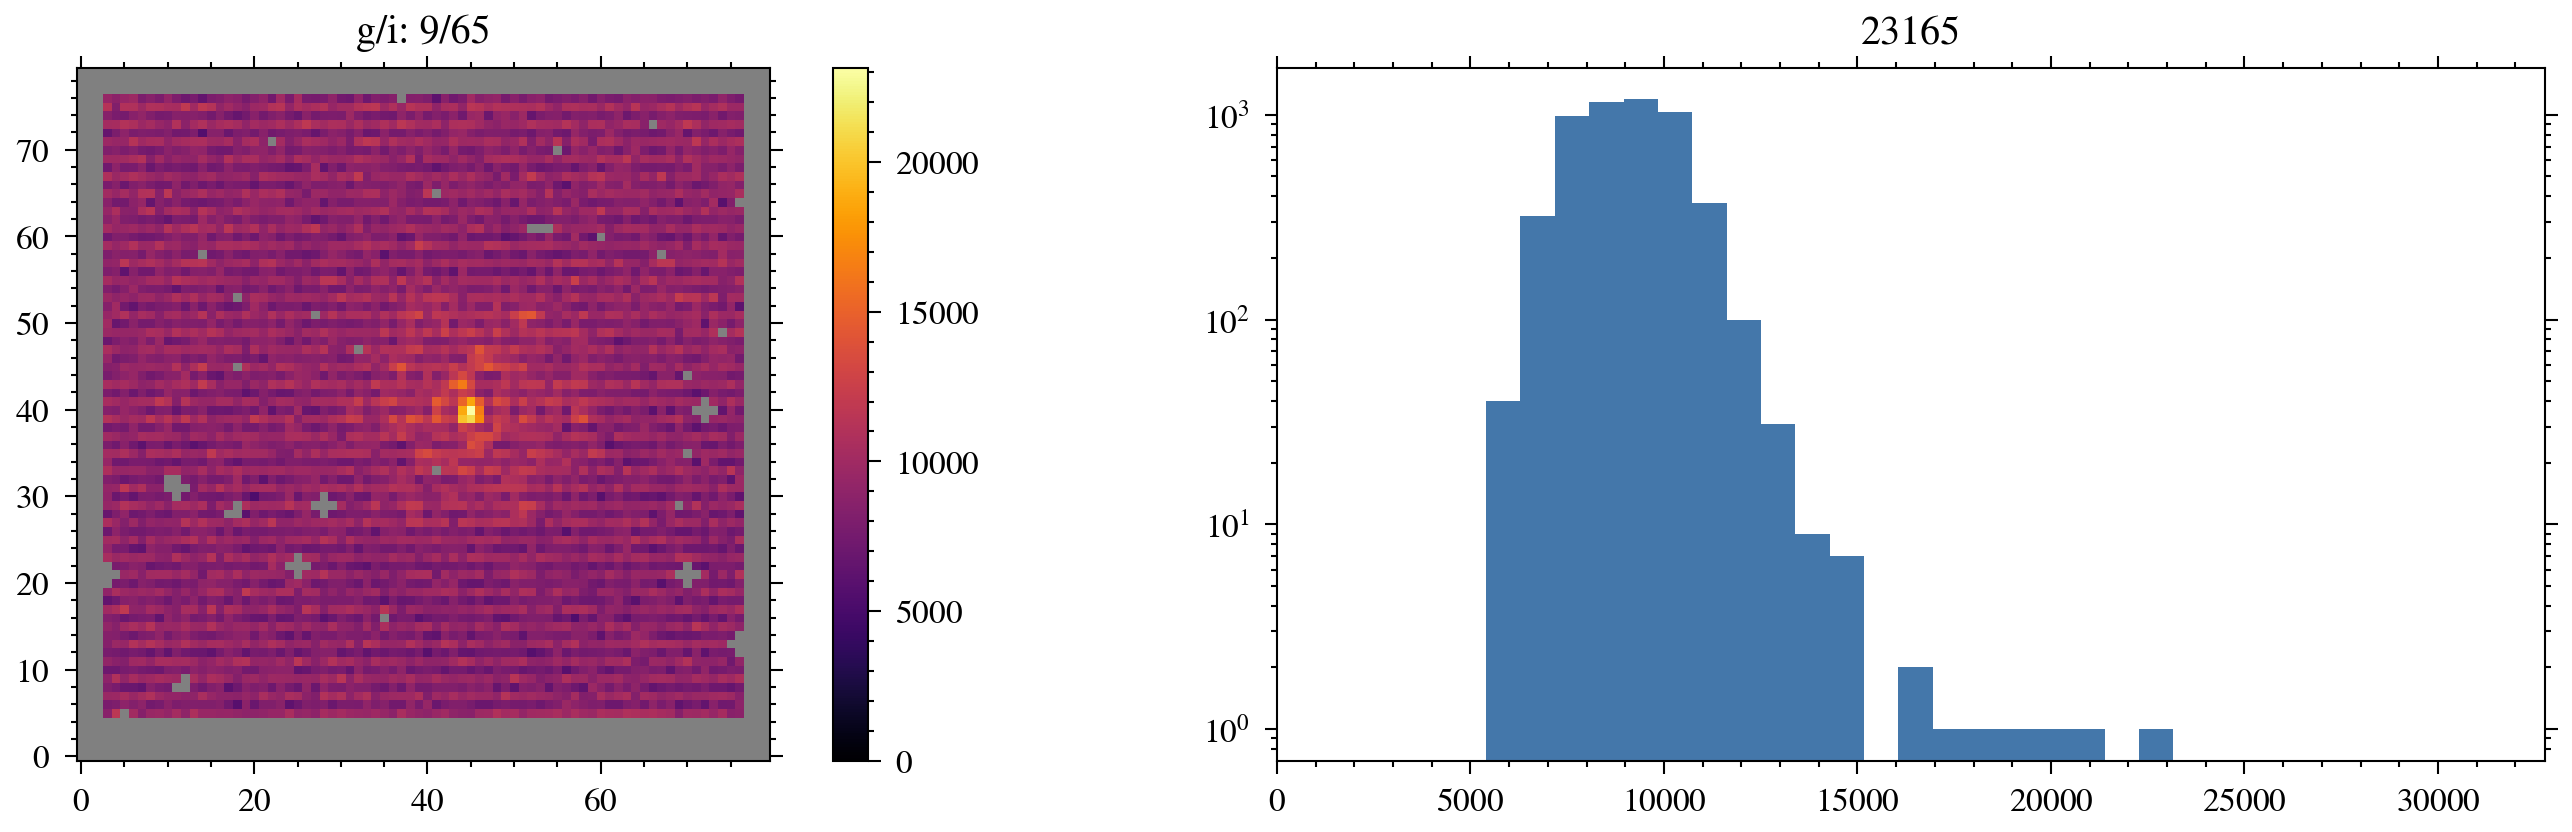




jw01093007001_03102_00017_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  17/25  9/65  23-05-2022  Thatte, Deepashri  True


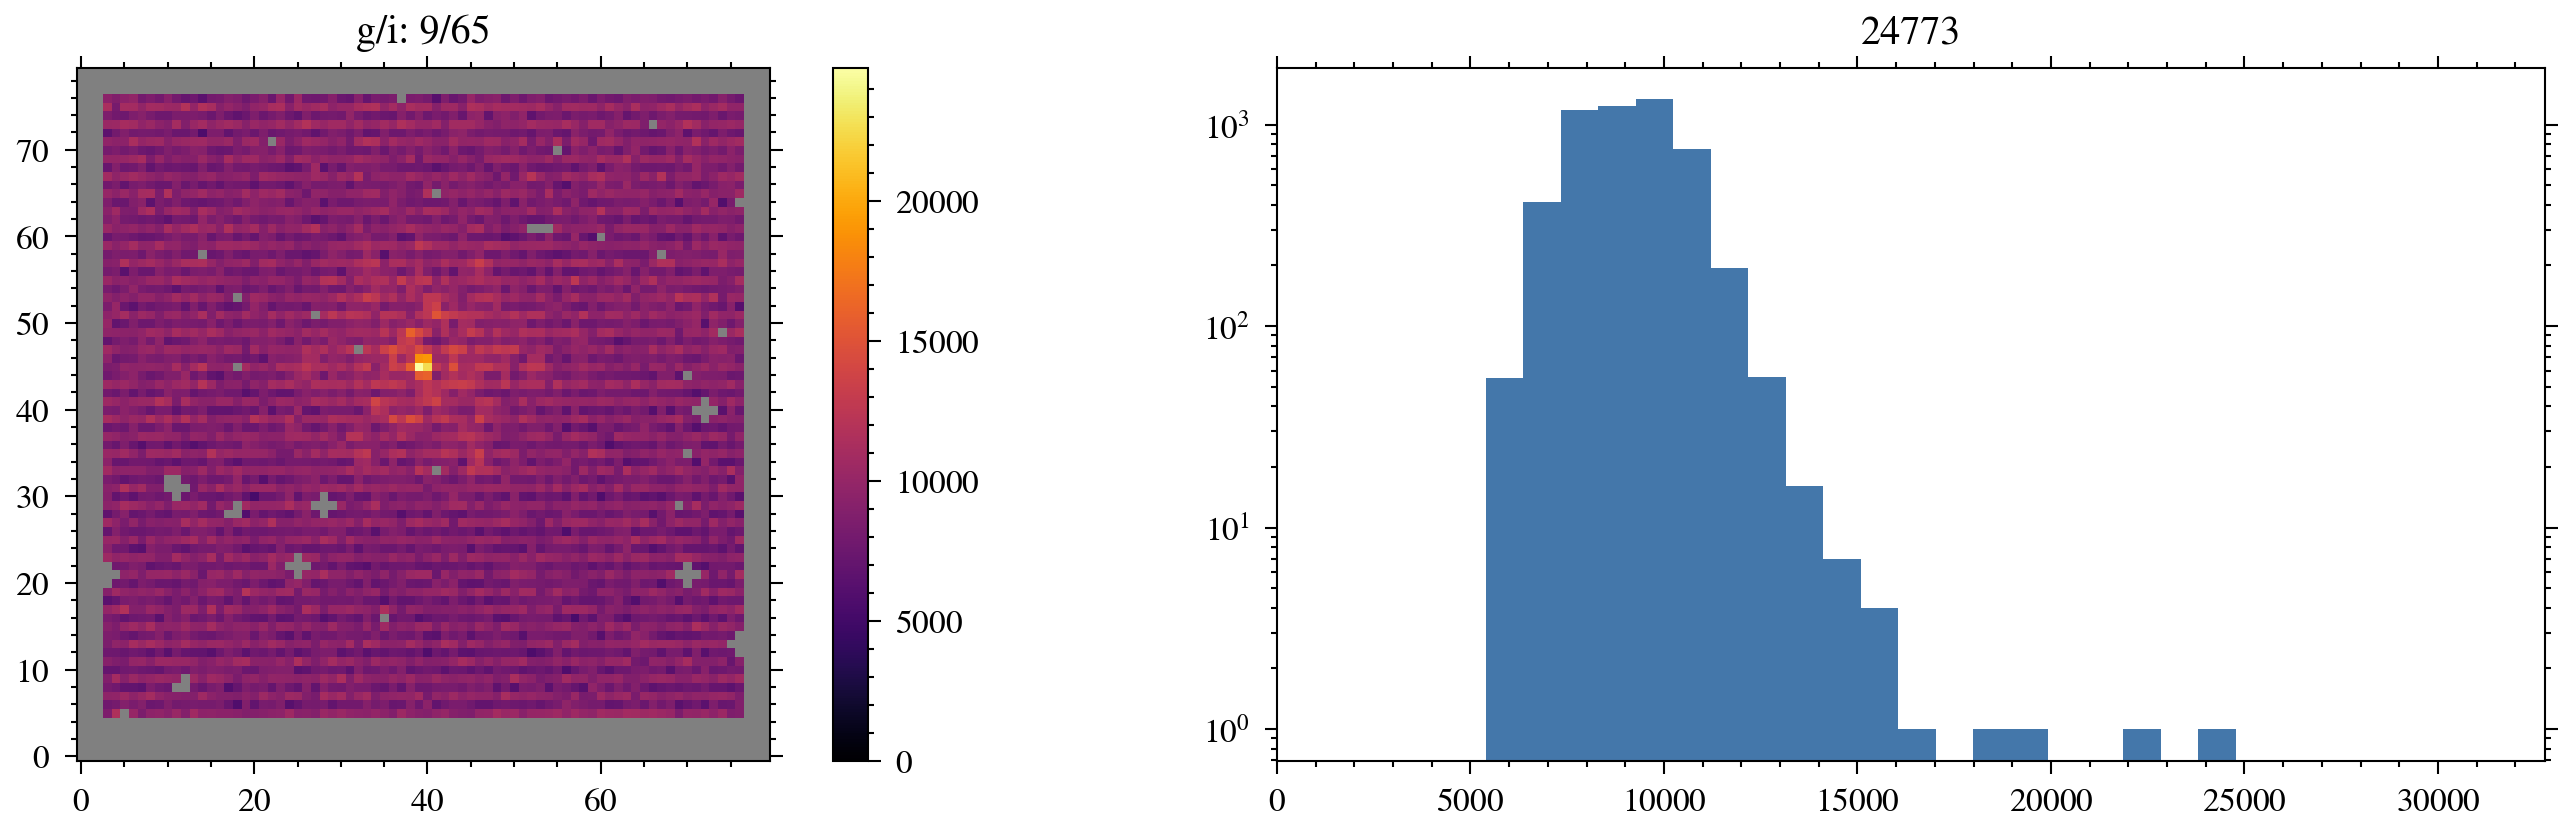




jw01093019001_03103_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F430M    1/1  6/82  05-06-2022  Thatte, Deepashri  True


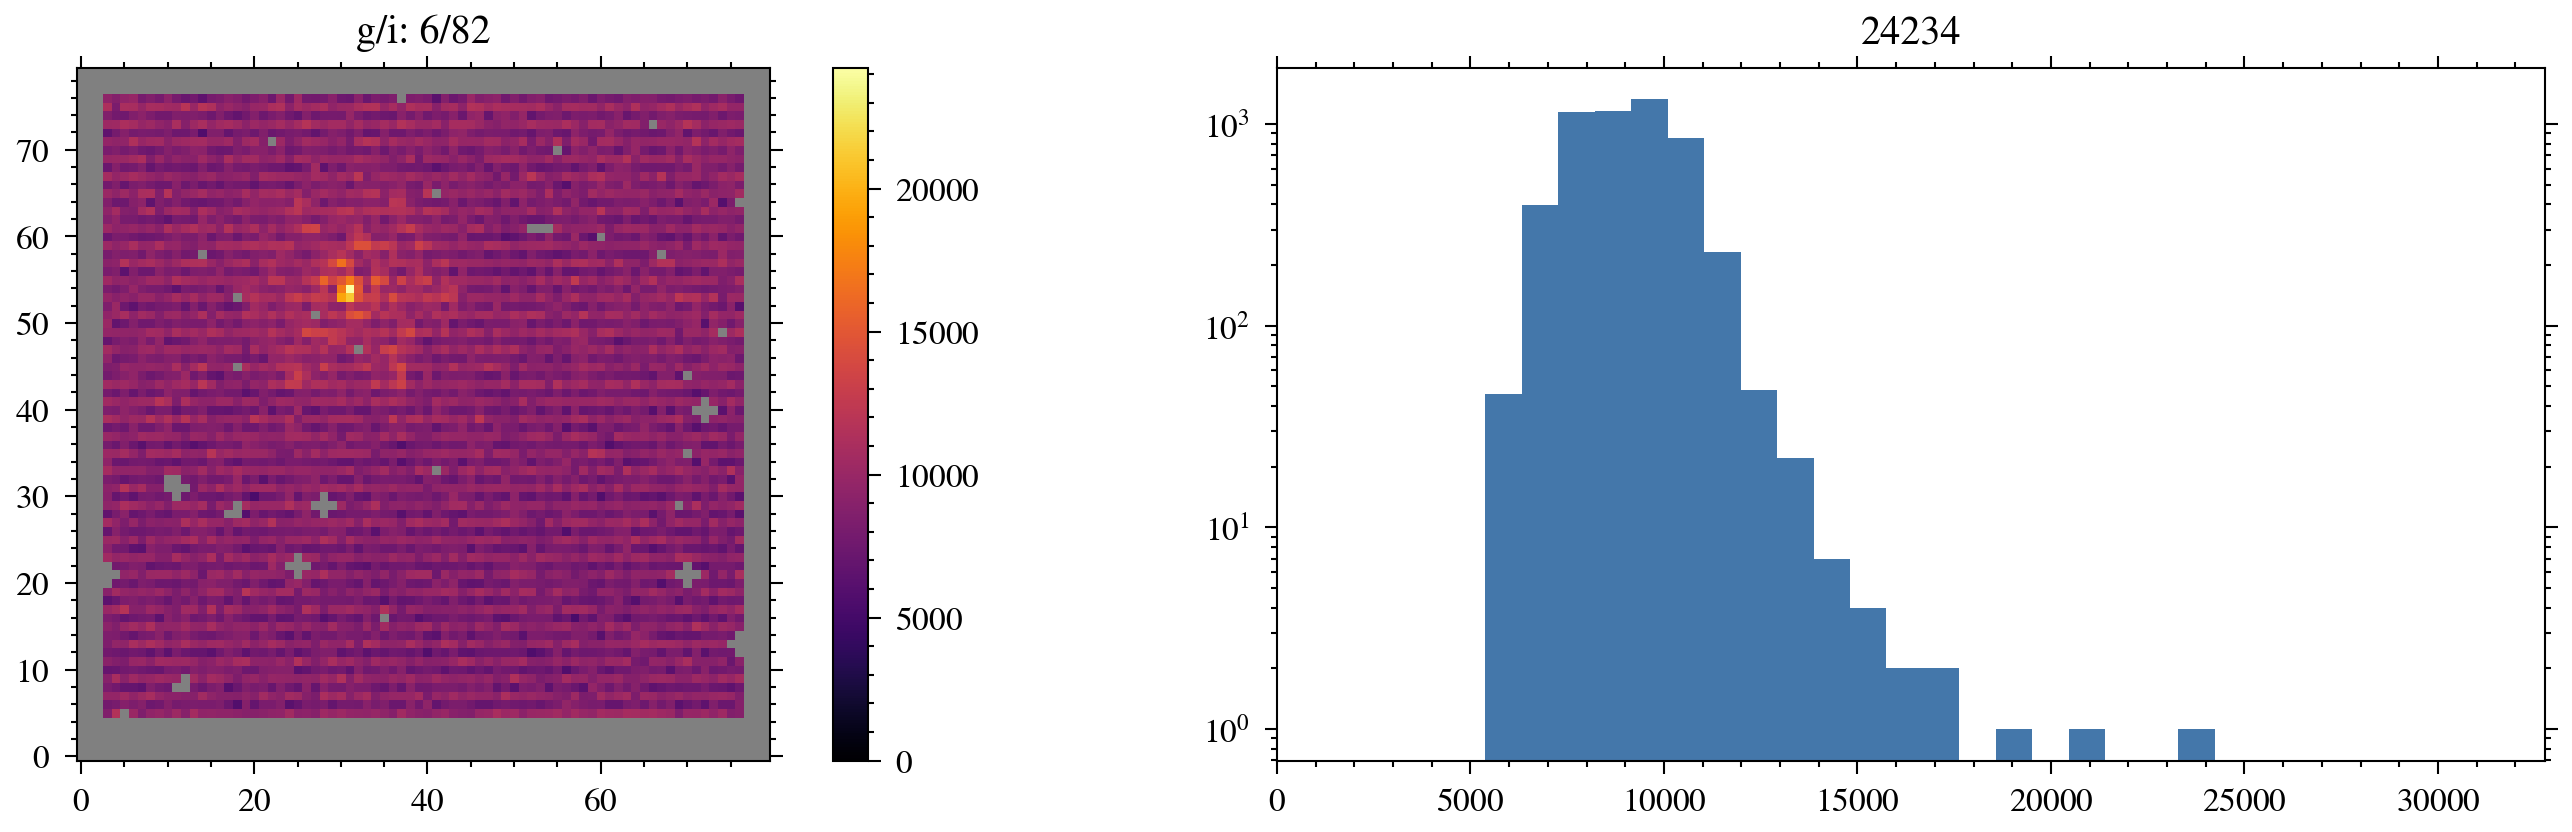




jw01093007001_03102_00002_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   2/25  9/65  23-05-2022  Thatte, Deepashri  True


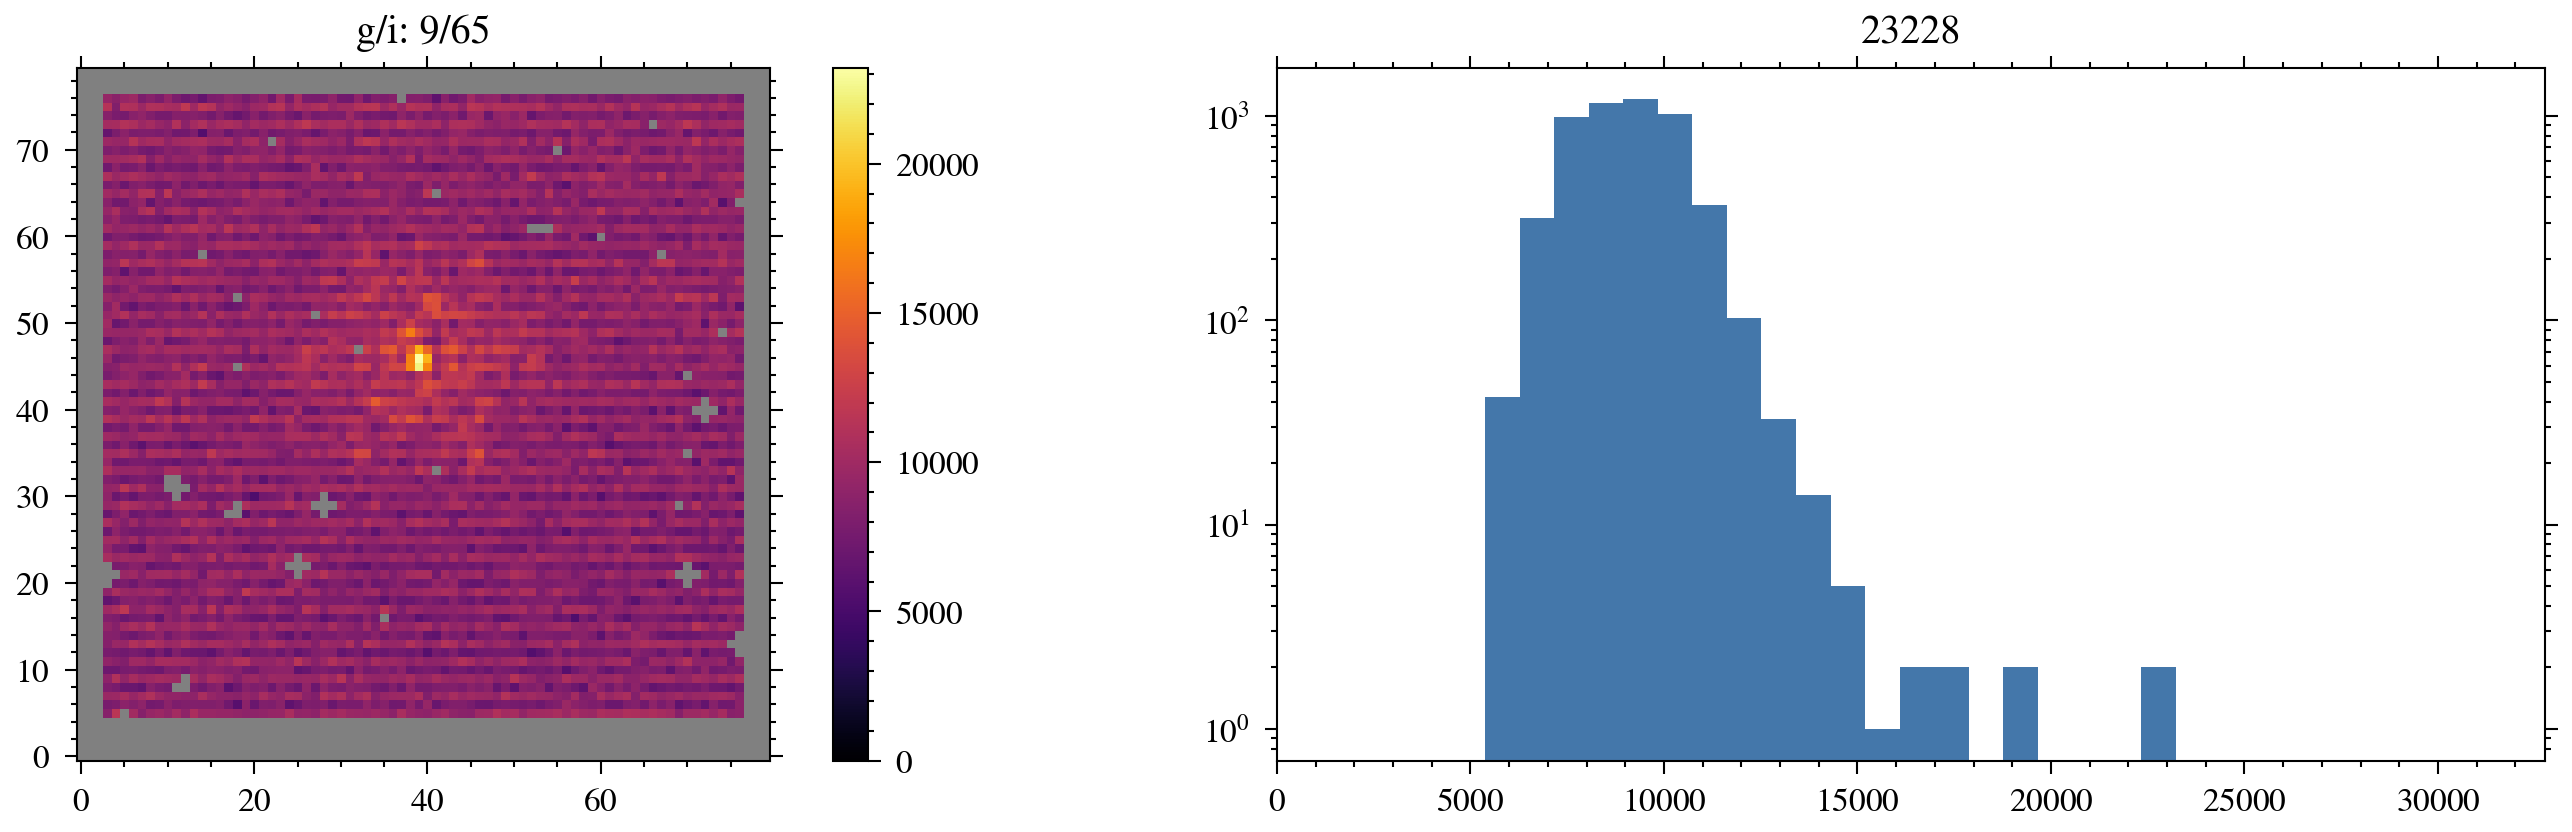




jw01093020001_03102_00002_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   2/25  9/65  05-06-2022  Thatte, Deepashri  True


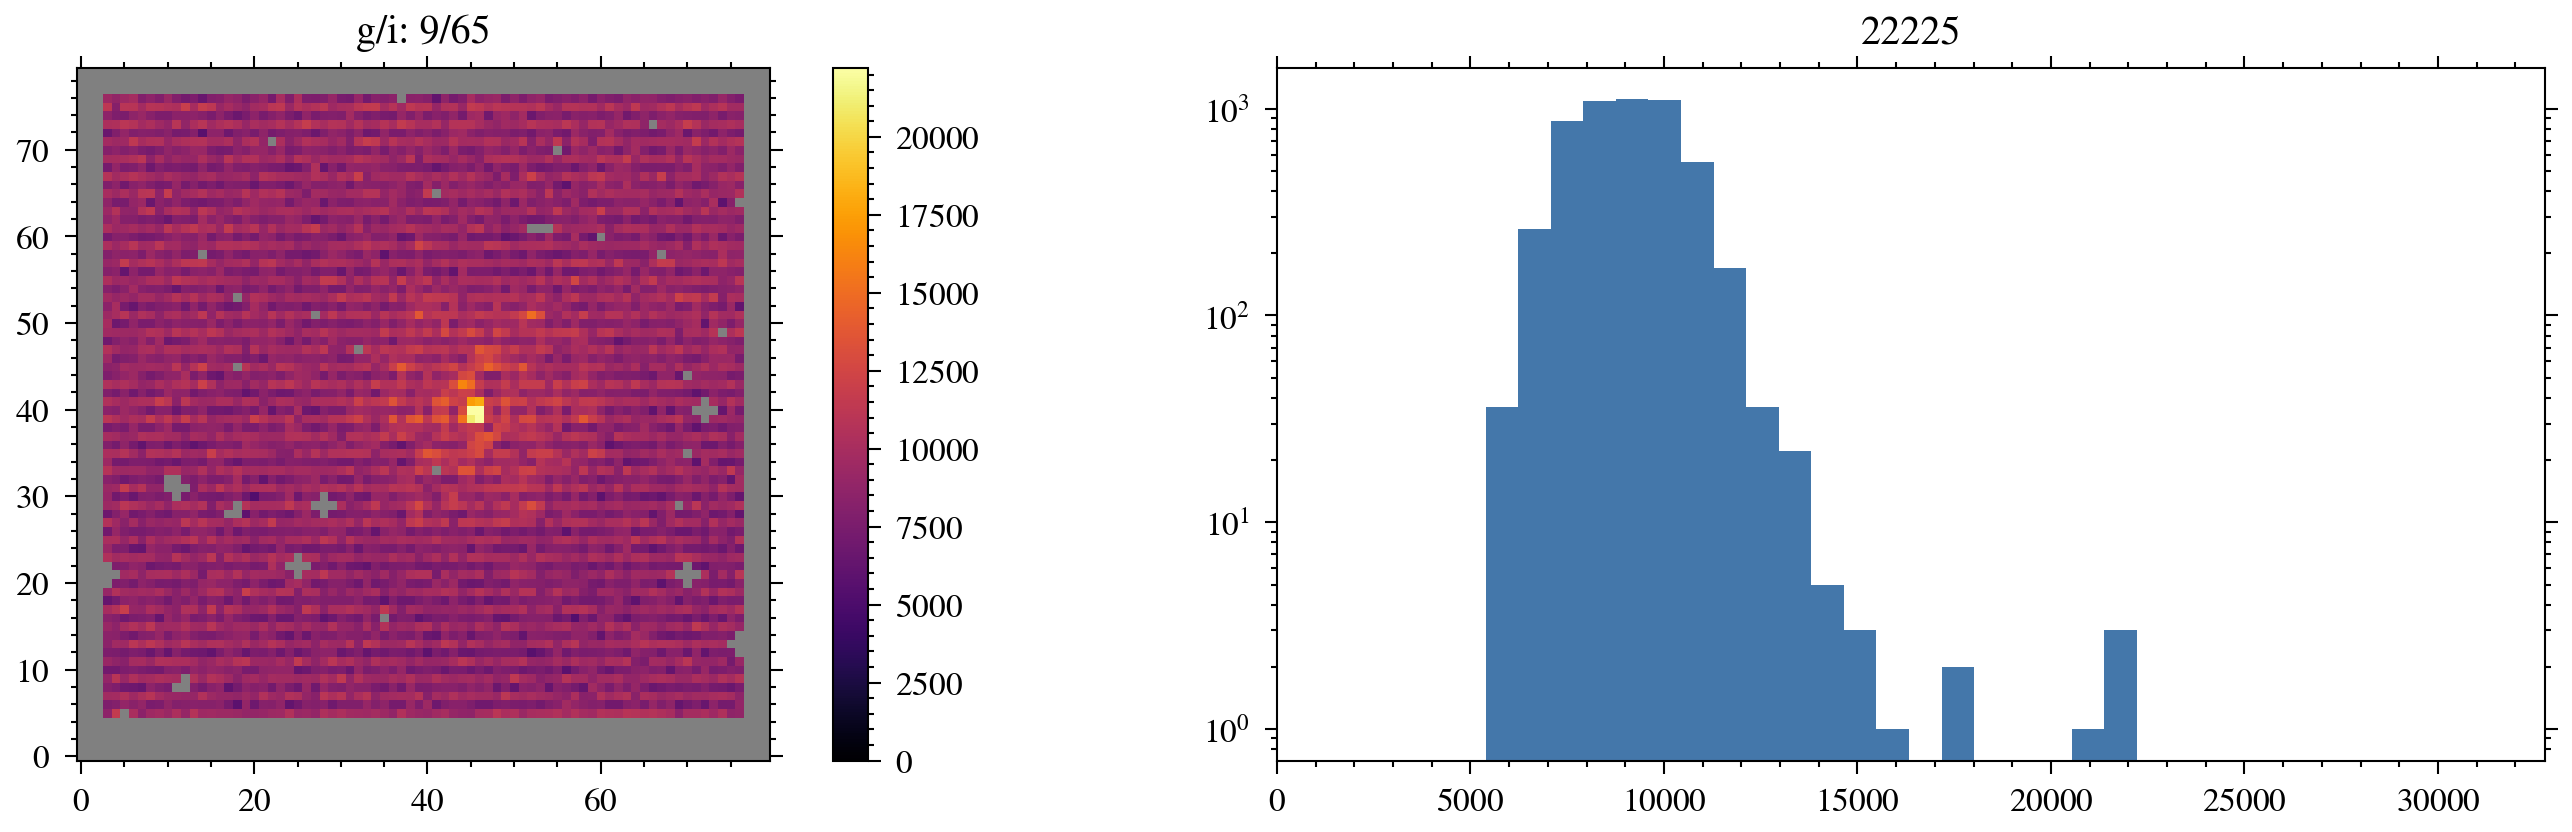




jw01093007001_03102_00025_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  25/25  9/65  23-05-2022  Thatte, Deepashri  True


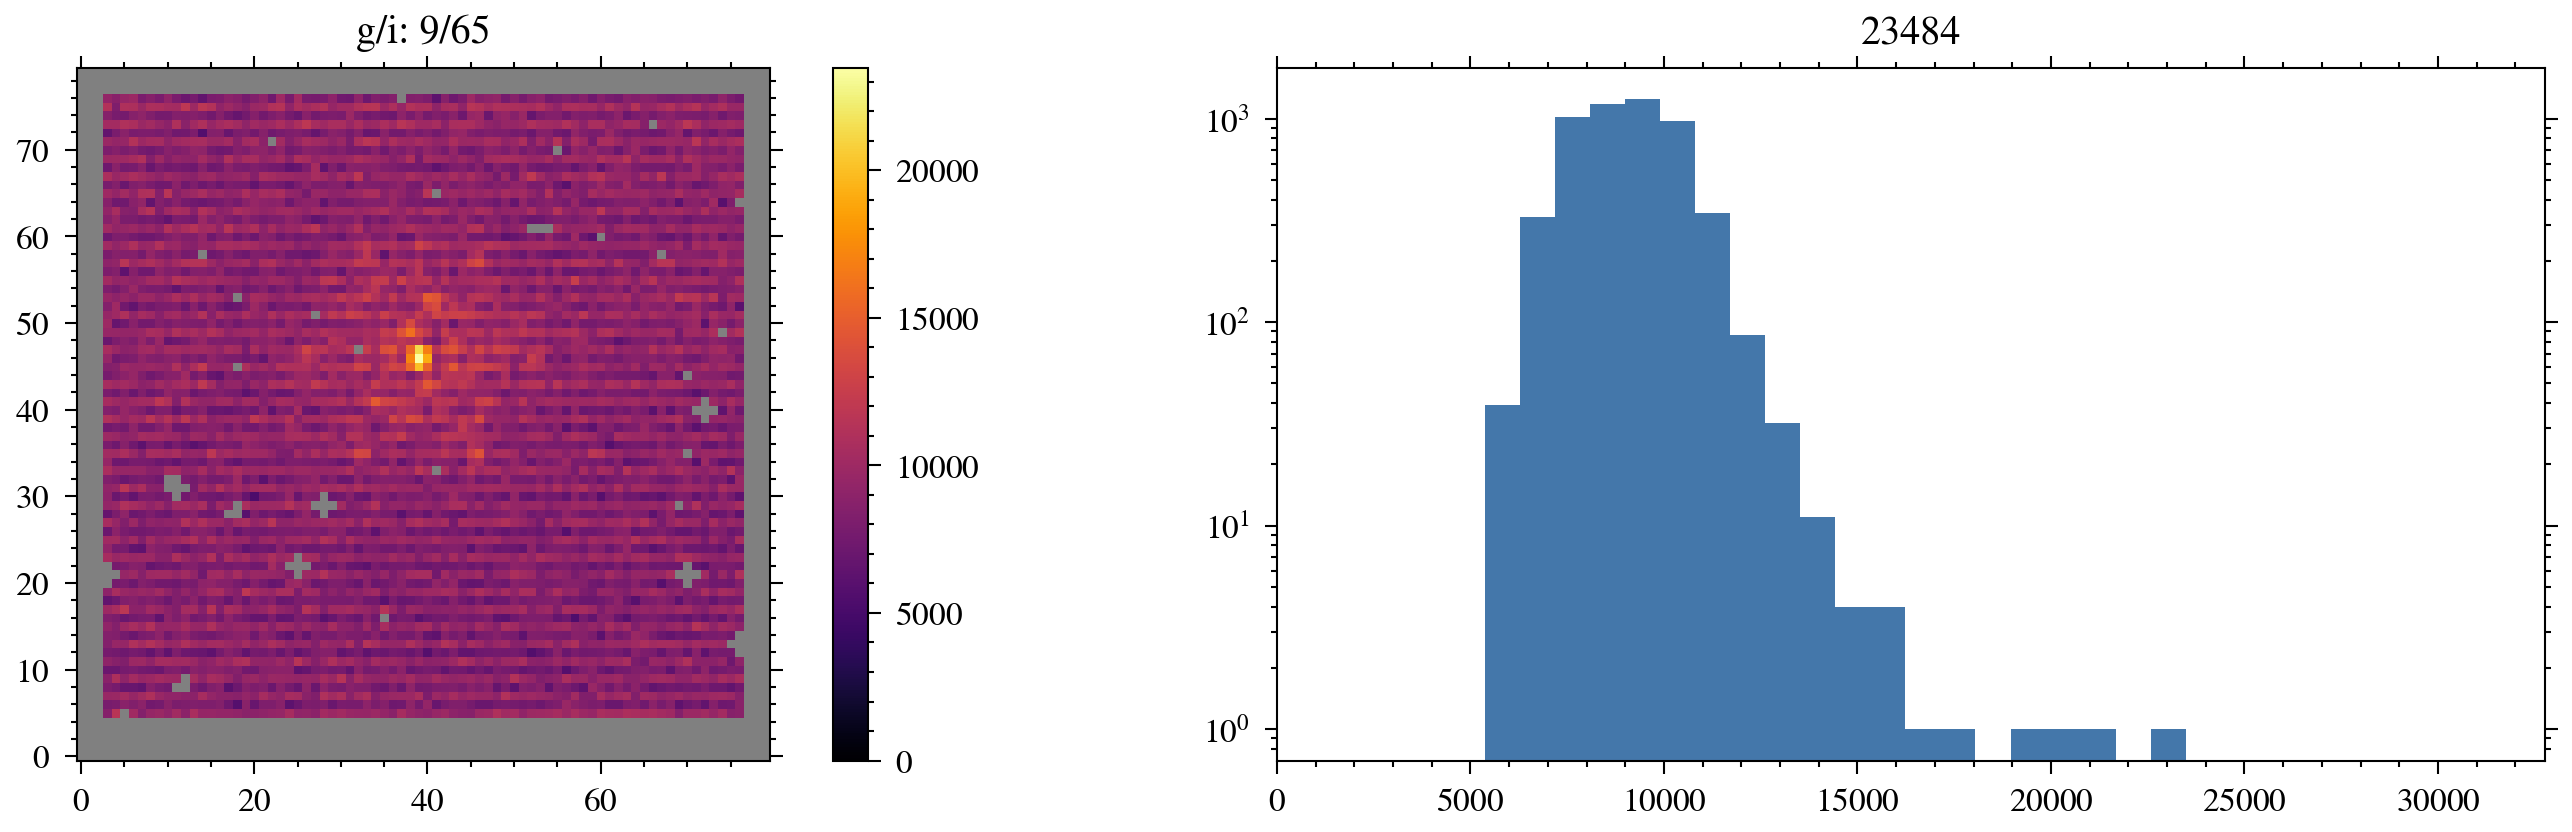




jw01093007001_03102_00012_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M  12/25  9/65  23-05-2022  Thatte, Deepashri  True


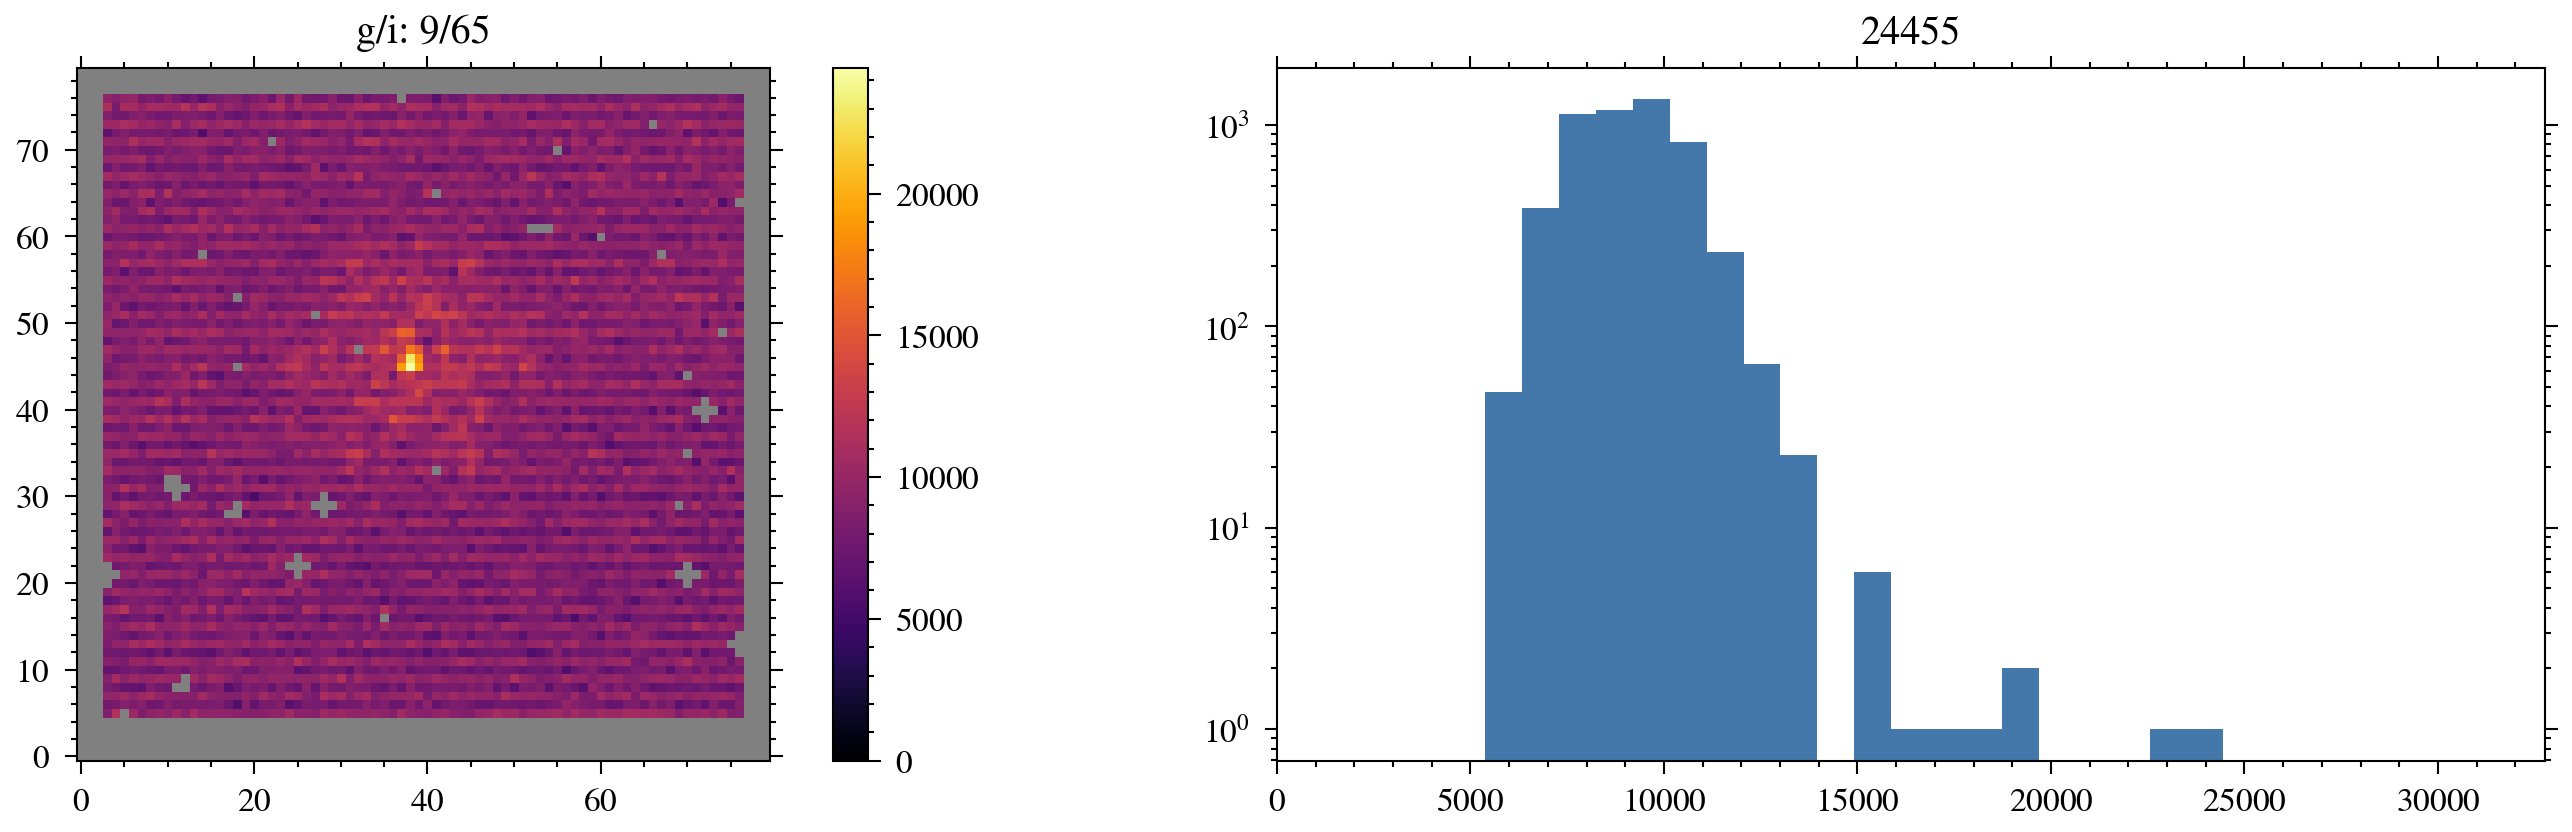




jw01093020001_03102_00004_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   4/25  9/65  05-06-2022  Thatte, Deepashri  True


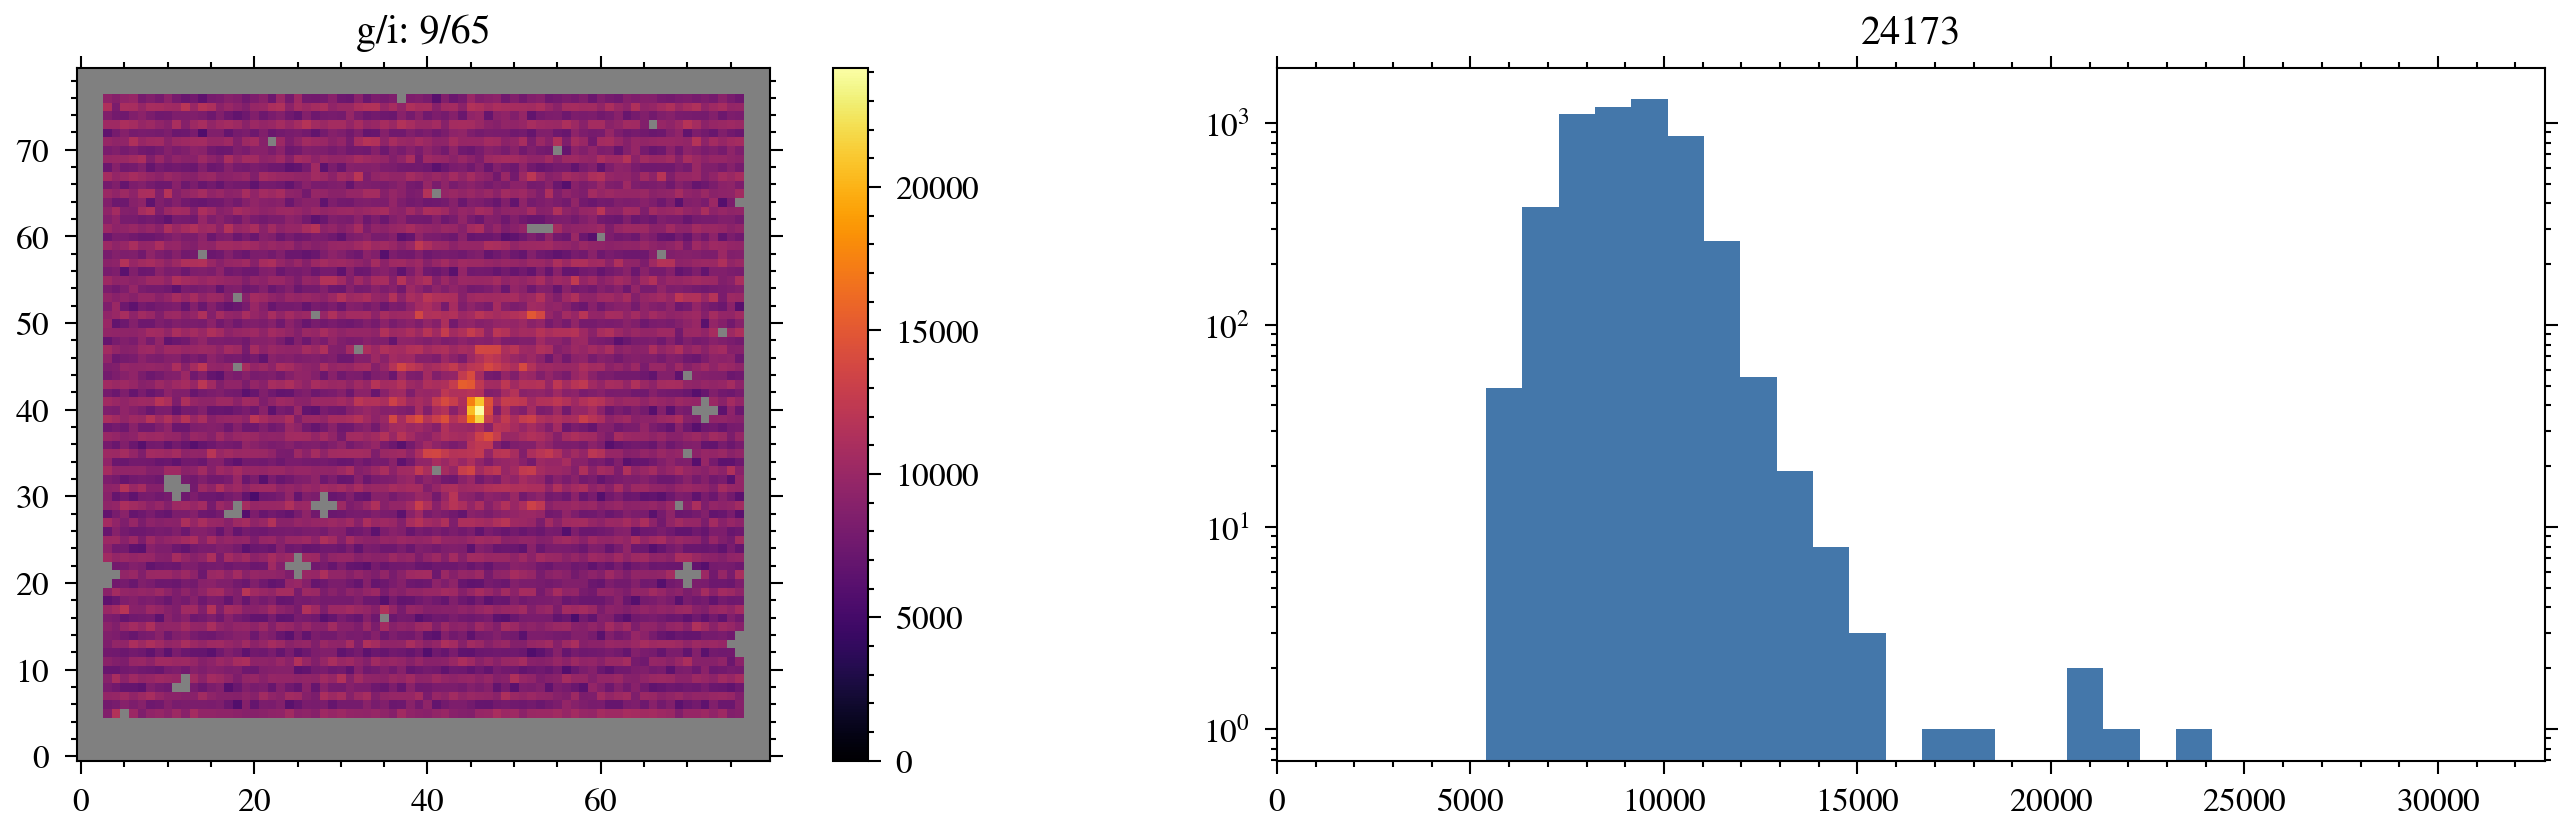




jw01093007001_03102_00007_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M   7/25  9/65  23-05-2022  Thatte, Deepashri  True


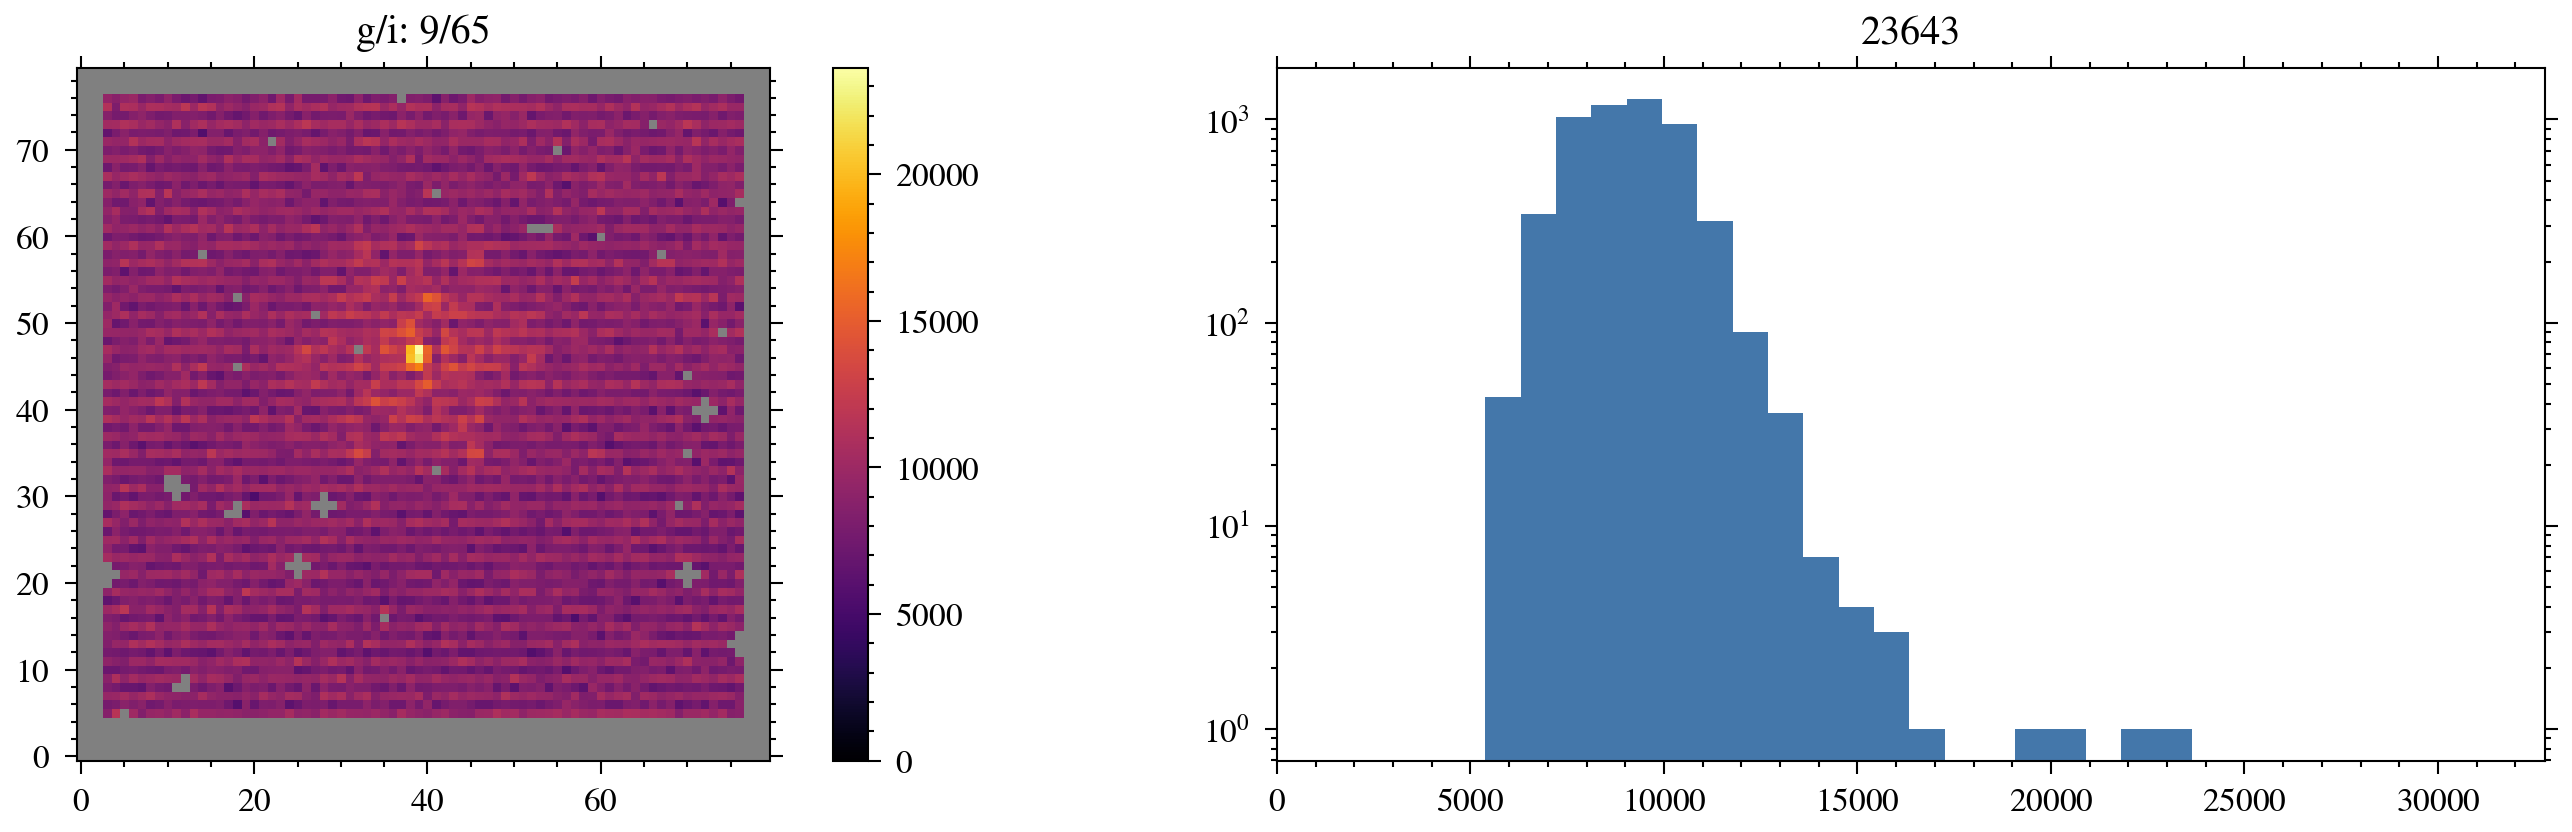




jw01093019001_03102_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F480M    1/1  9/65  05-06-2022  Thatte, Deepashri  True


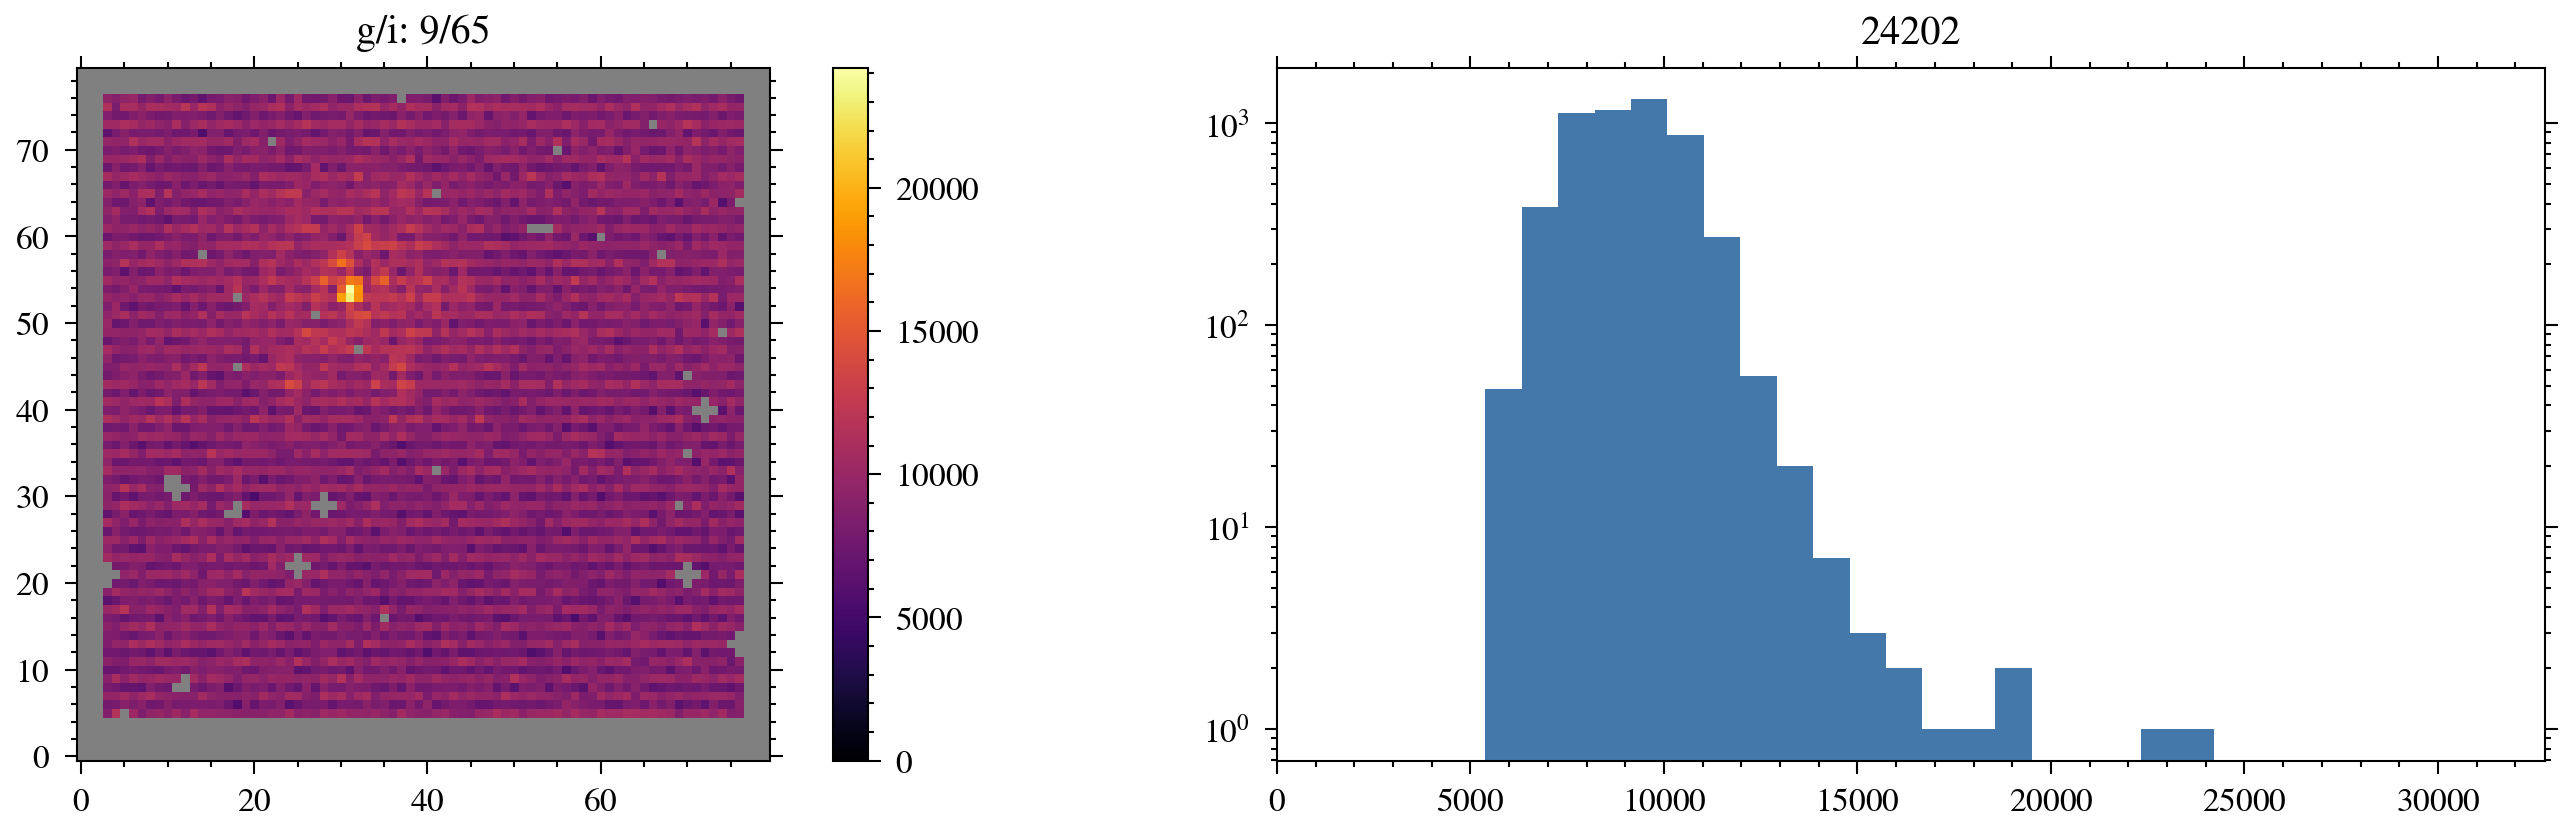




jw01093018001_03103_00001_nis
  program    target filter dither   g/i        date                 PI   CAL
0    1093  HD-36805  F430M    1/1  6/82  05-06-2022  Thatte, Deepashri  True


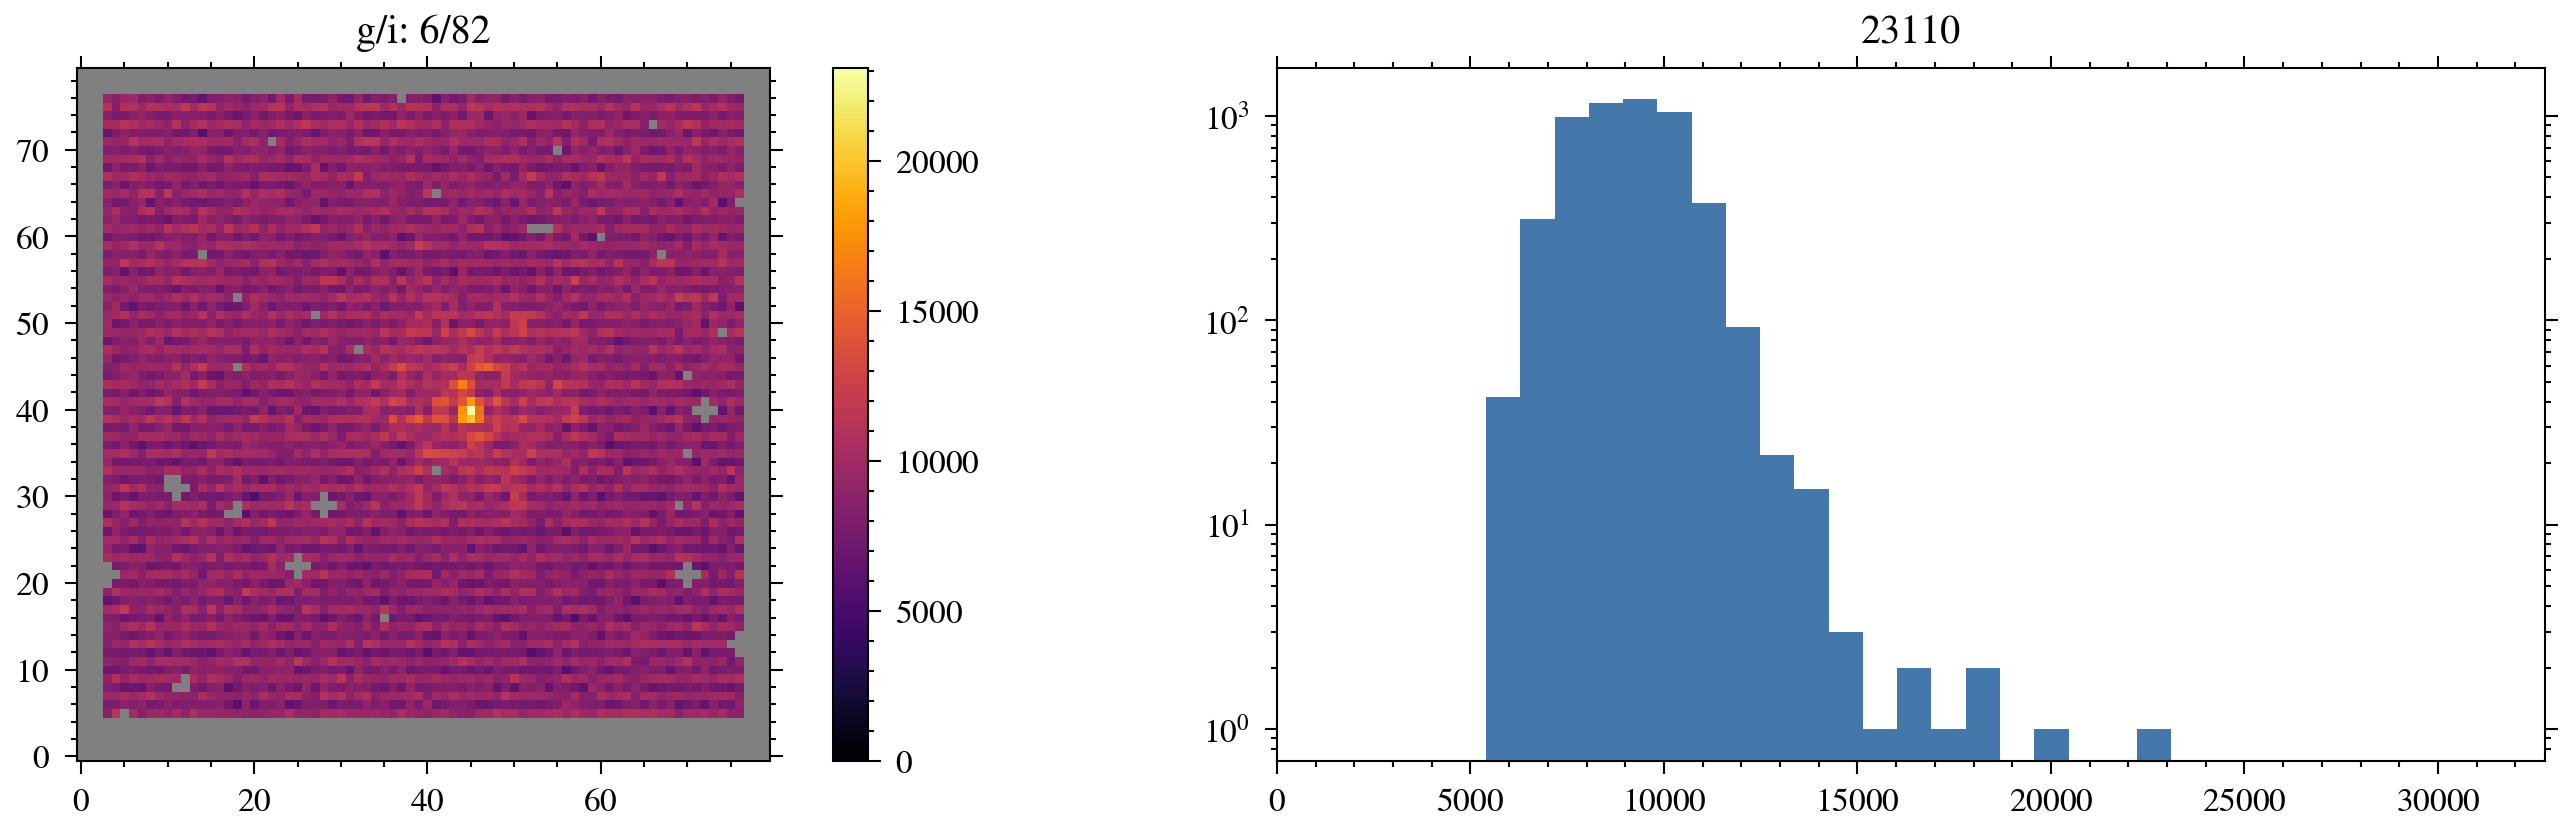




jw01843002001_05101_00001_nis
  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F380M    1/1  3/7800  26-10-2022  Kammerer, Jens  True


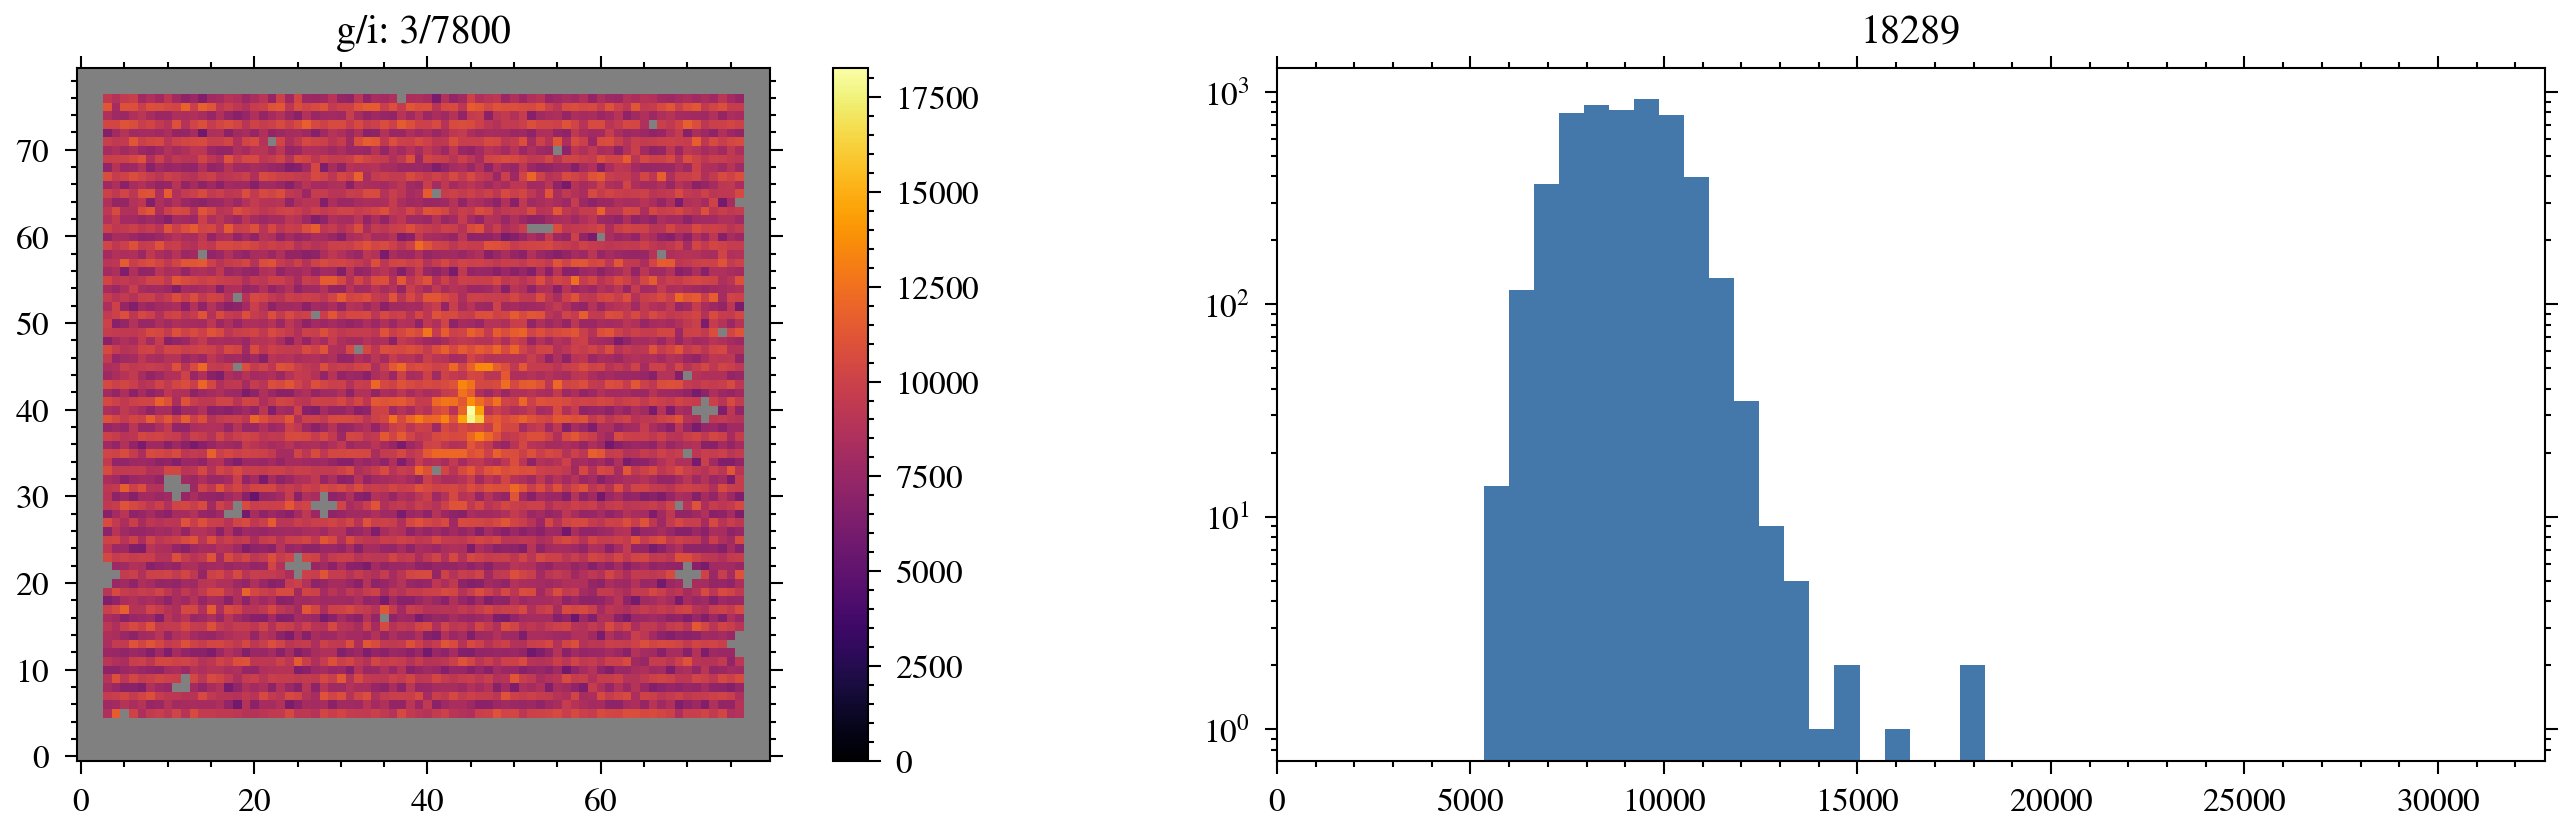




jw01843002001_06101_00001_nis
  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F430M    1/1  7/1885  26-10-2022  Kammerer, Jens  True


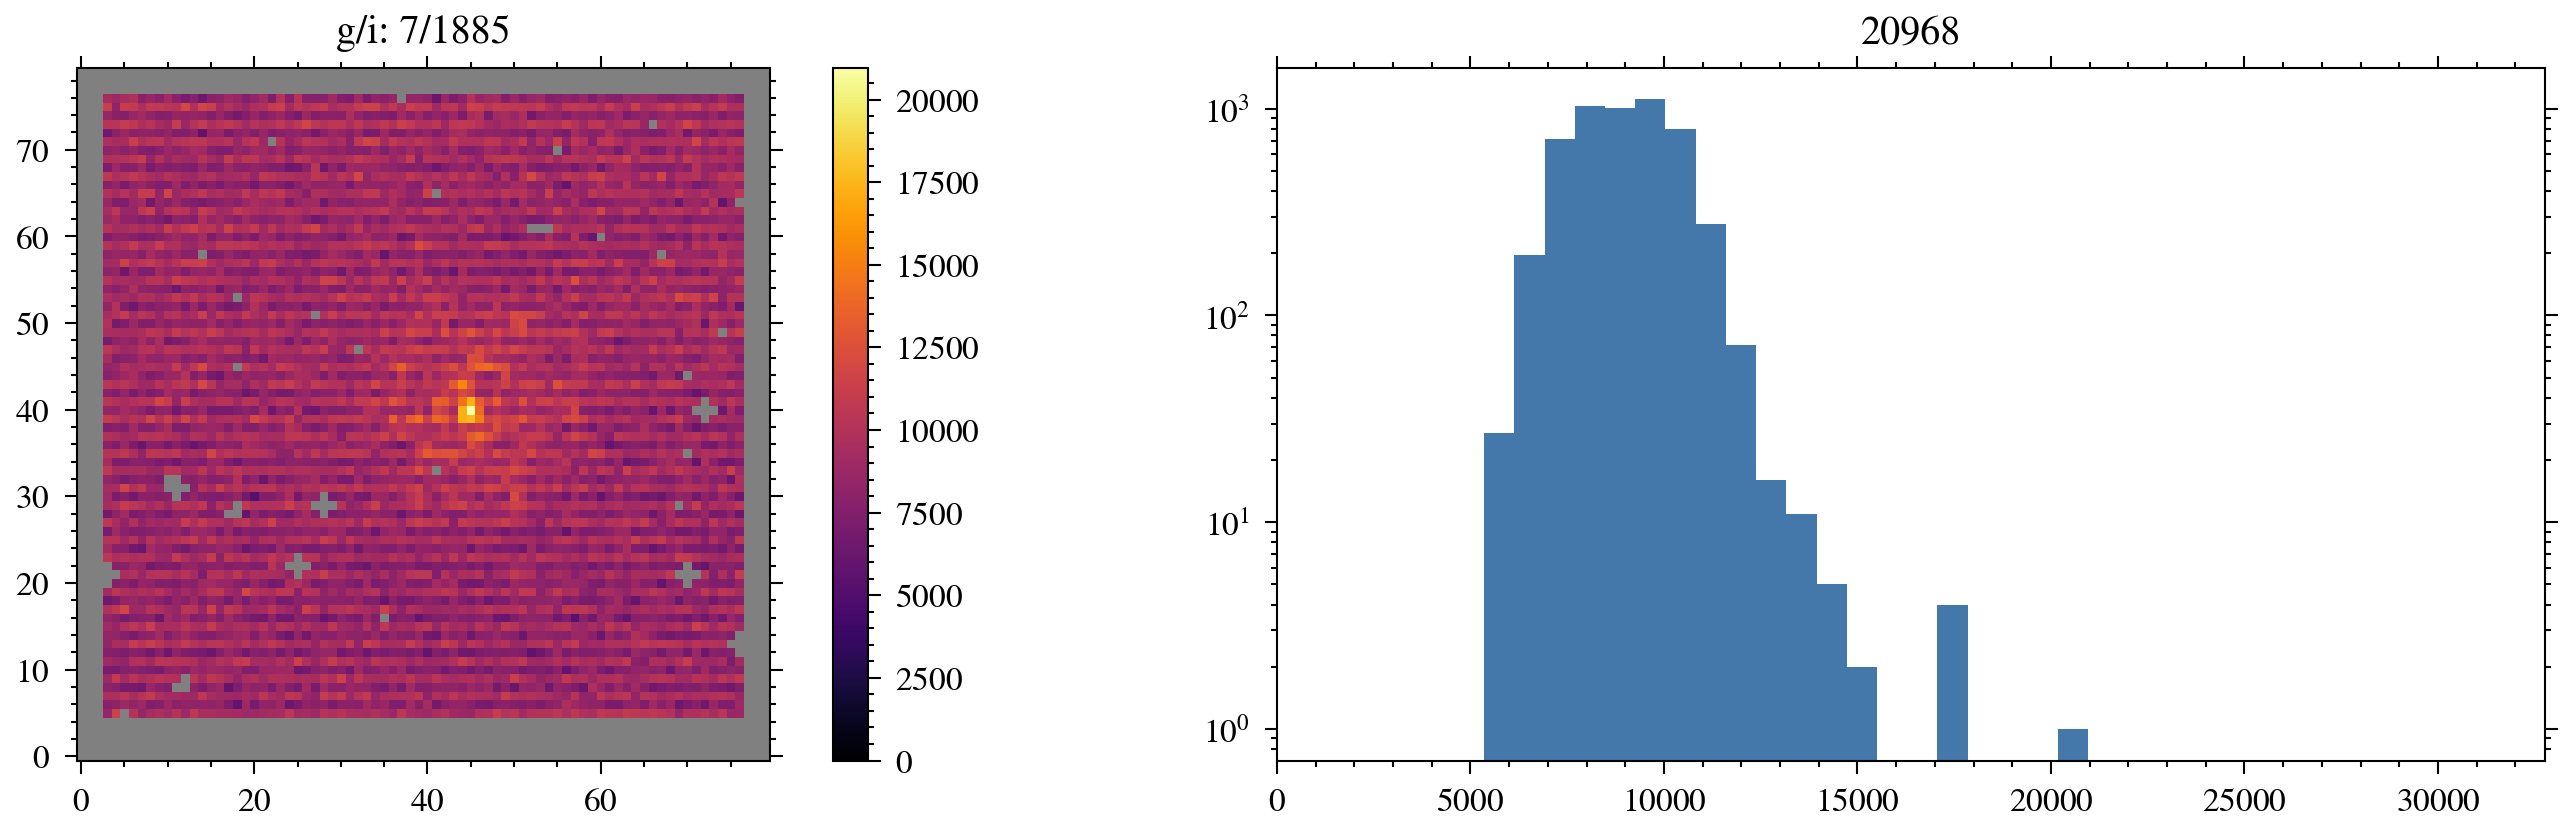




jw01843002001_04101_00001_nis
  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F480M    1/1  10/641  26-10-2022  Kammerer, Jens  True


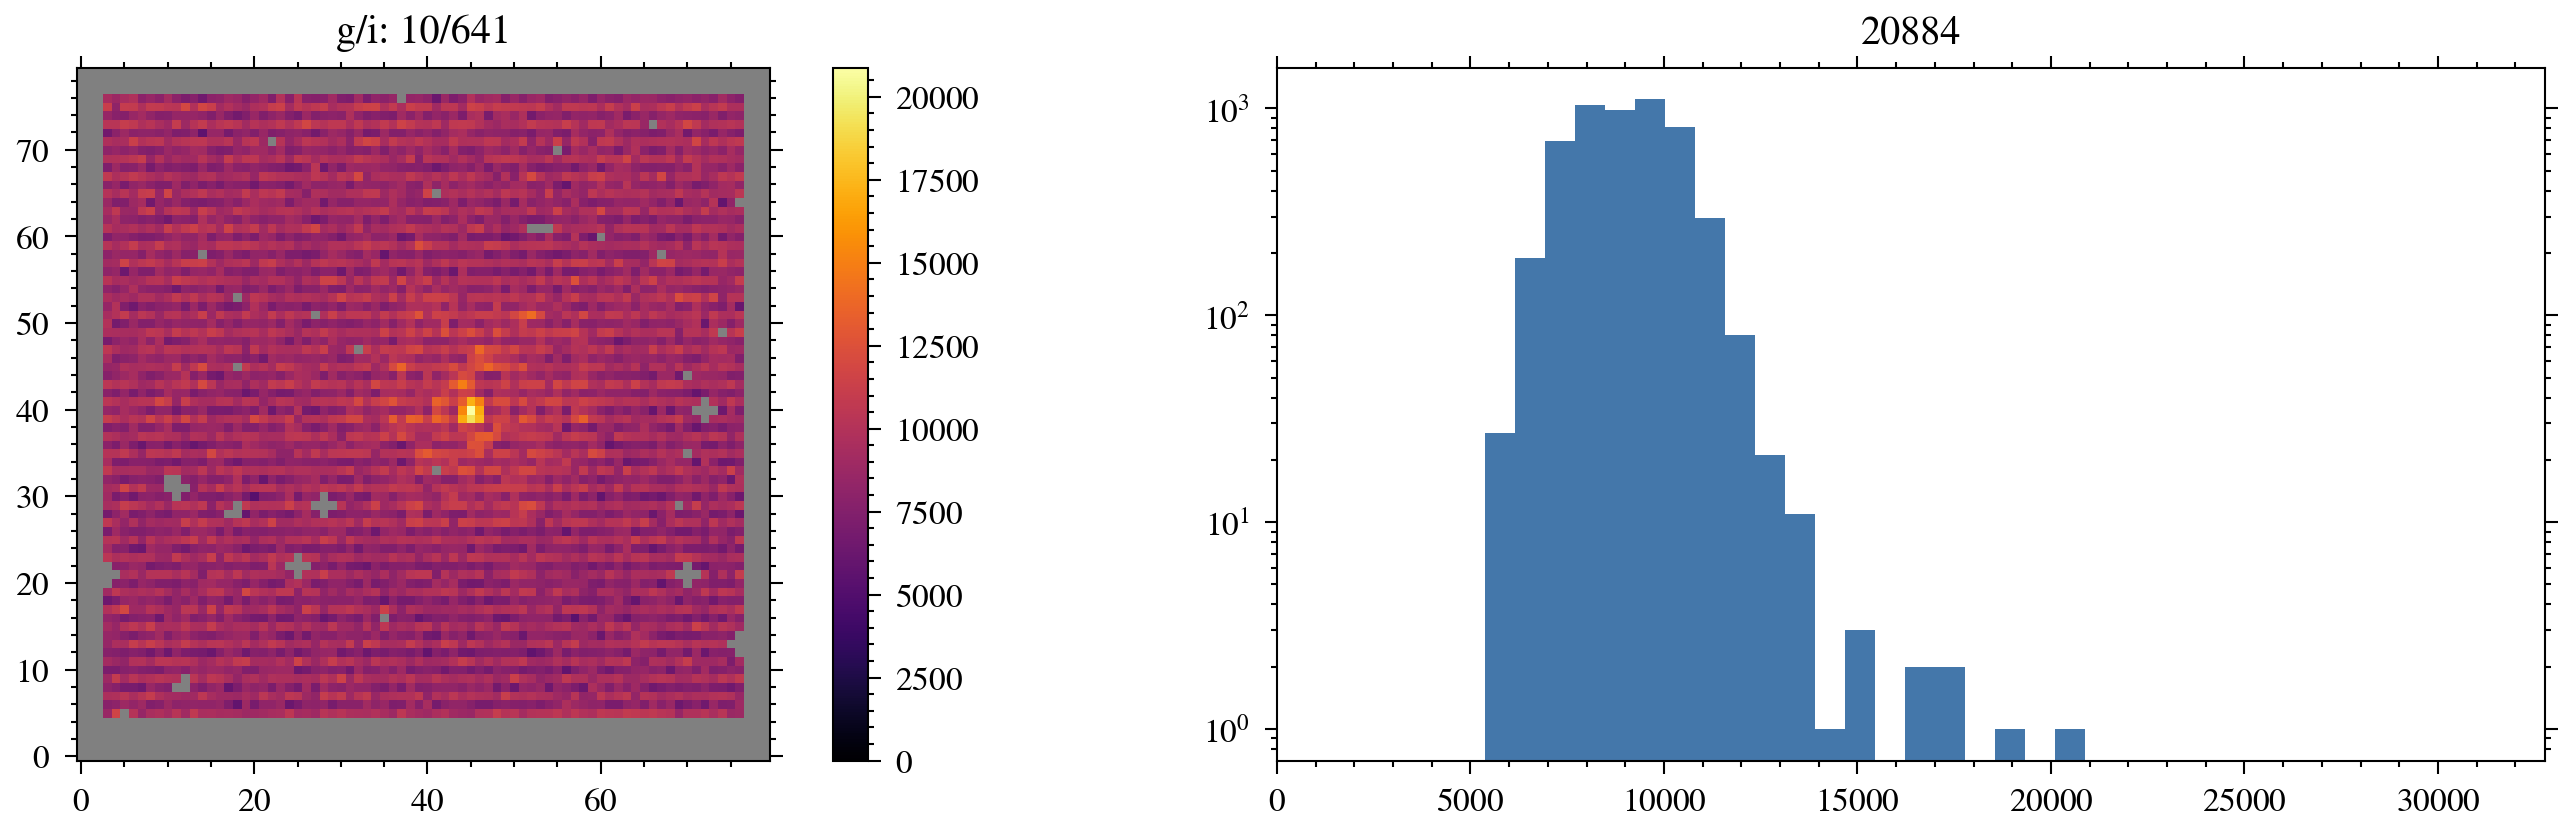




jw01242010001_03104_00001_nis
  program    target filter dither     g/i        date               PI   CAL
0    1242  HD-18638  F430M    1/1  5/6256  31-10-2023  Johnstone, Doug  True


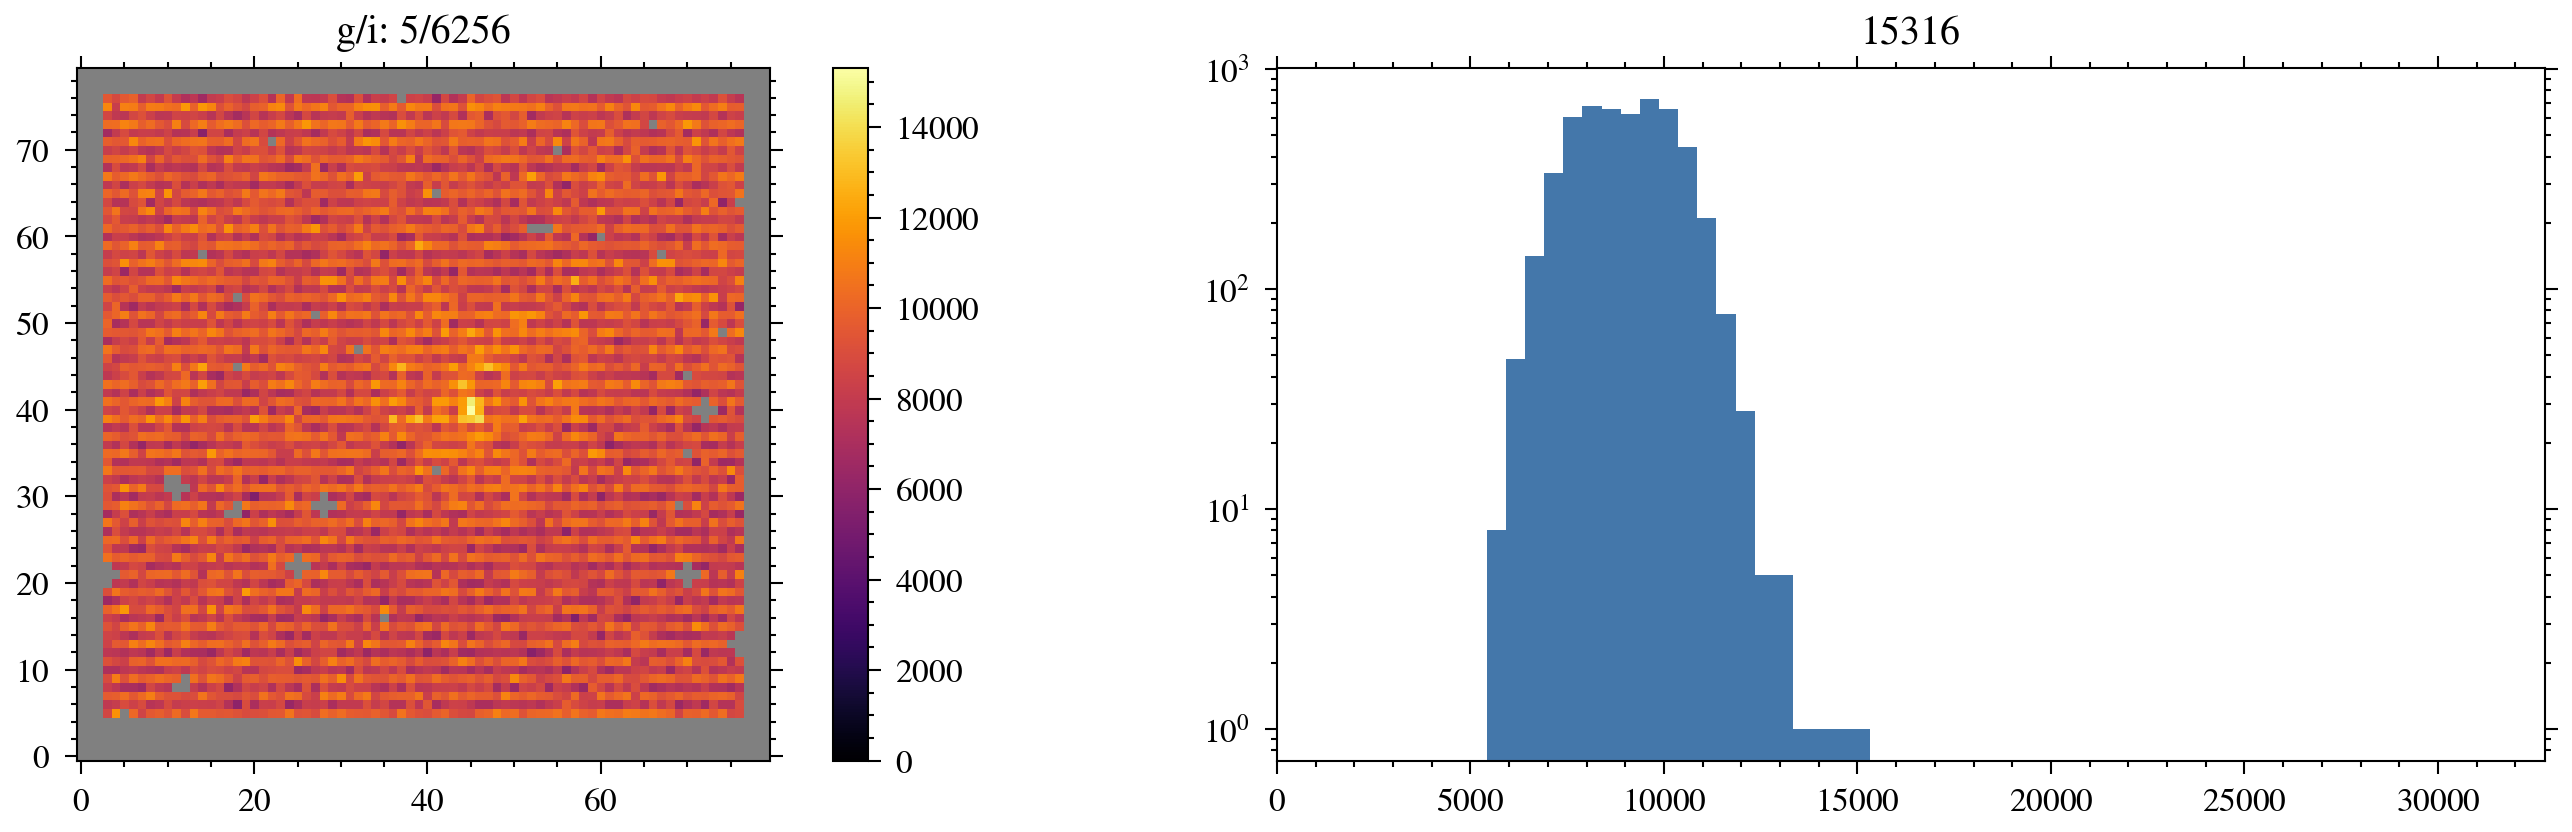




jw01242004001_03104_00001_nis
  program            target filter dither     g/i        date               PI   CAL
0    1242  TD-CAL-HD-123991  F380M    1/1  10/612  24-02-2023  Johnstone, Doug  True


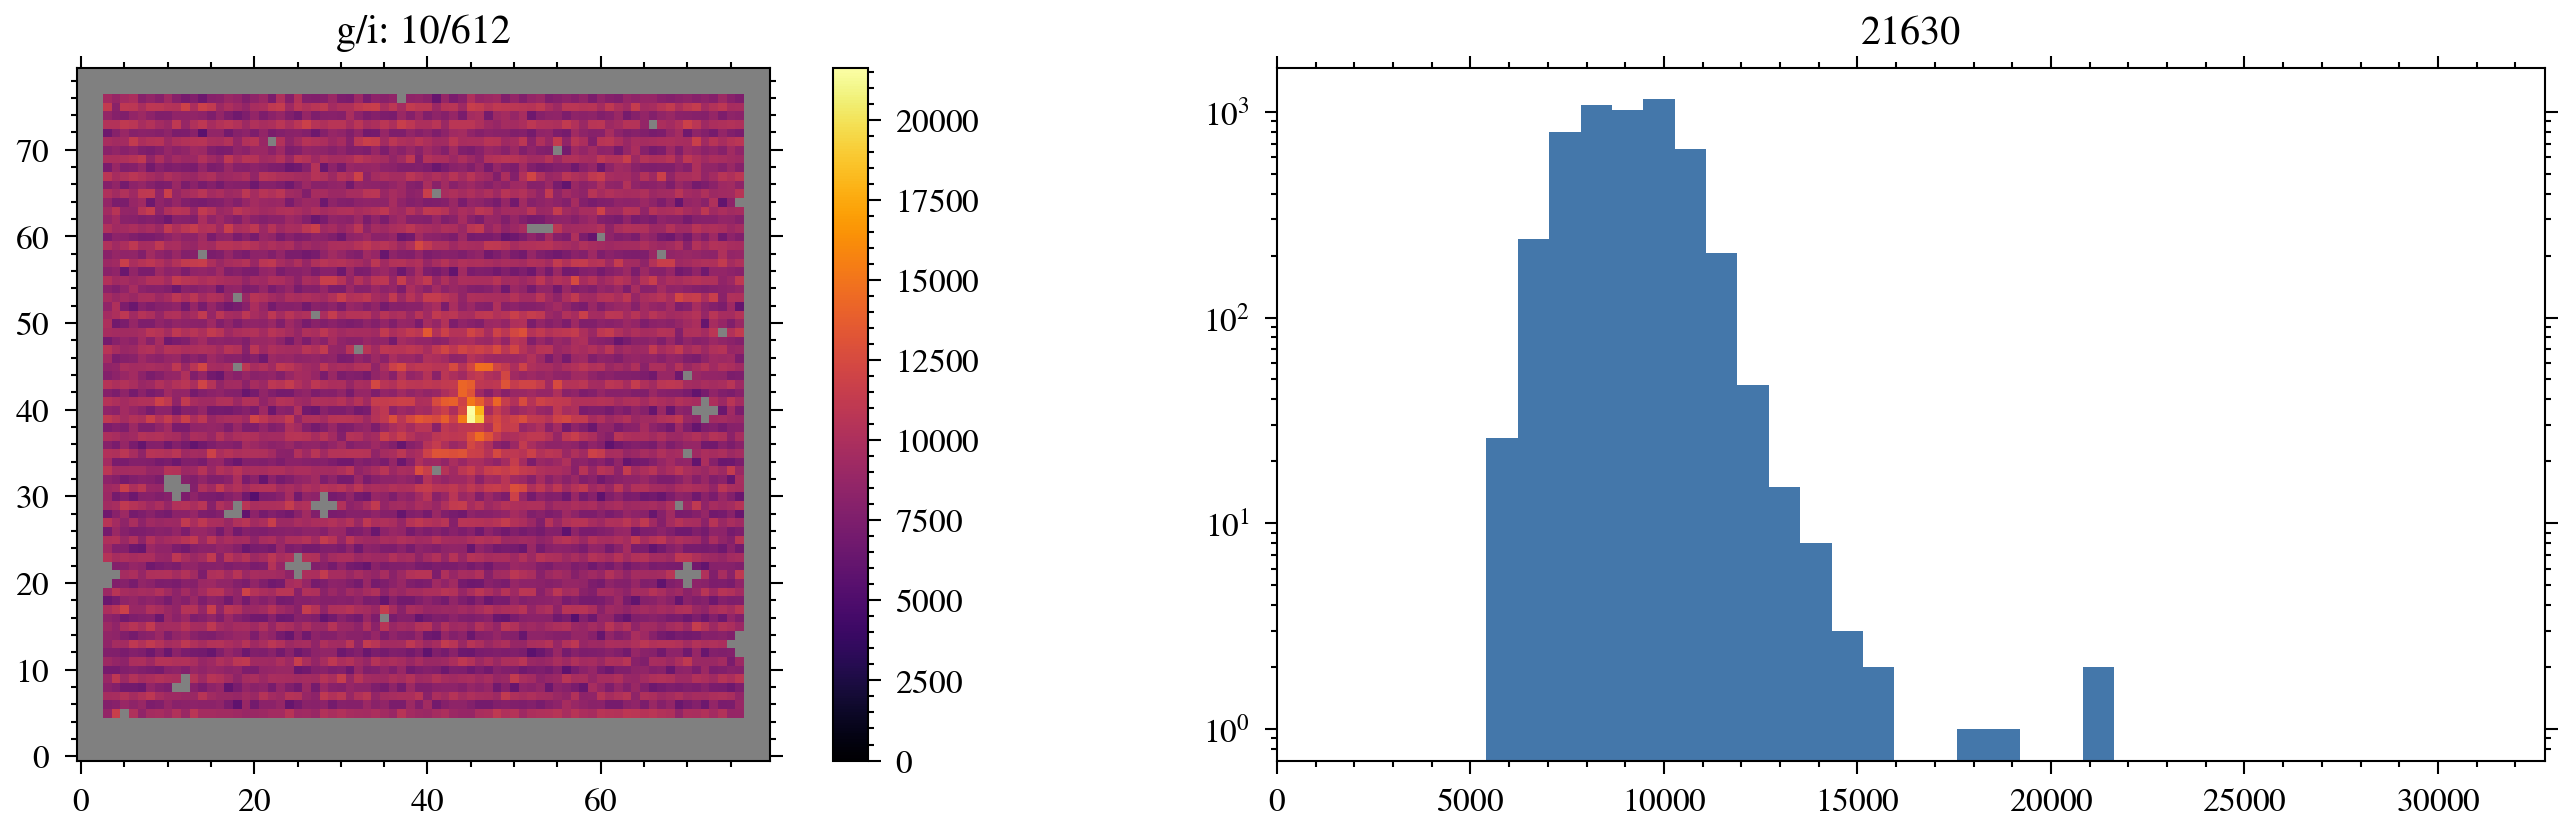




jw01242004001_03102_00001_nis
  program            target filter dither     g/i        date               PI   CAL
0    1242  TD-CAL-HD-123991  F480M    1/1  29/418  24-02-2023  Johnstone, Doug  True


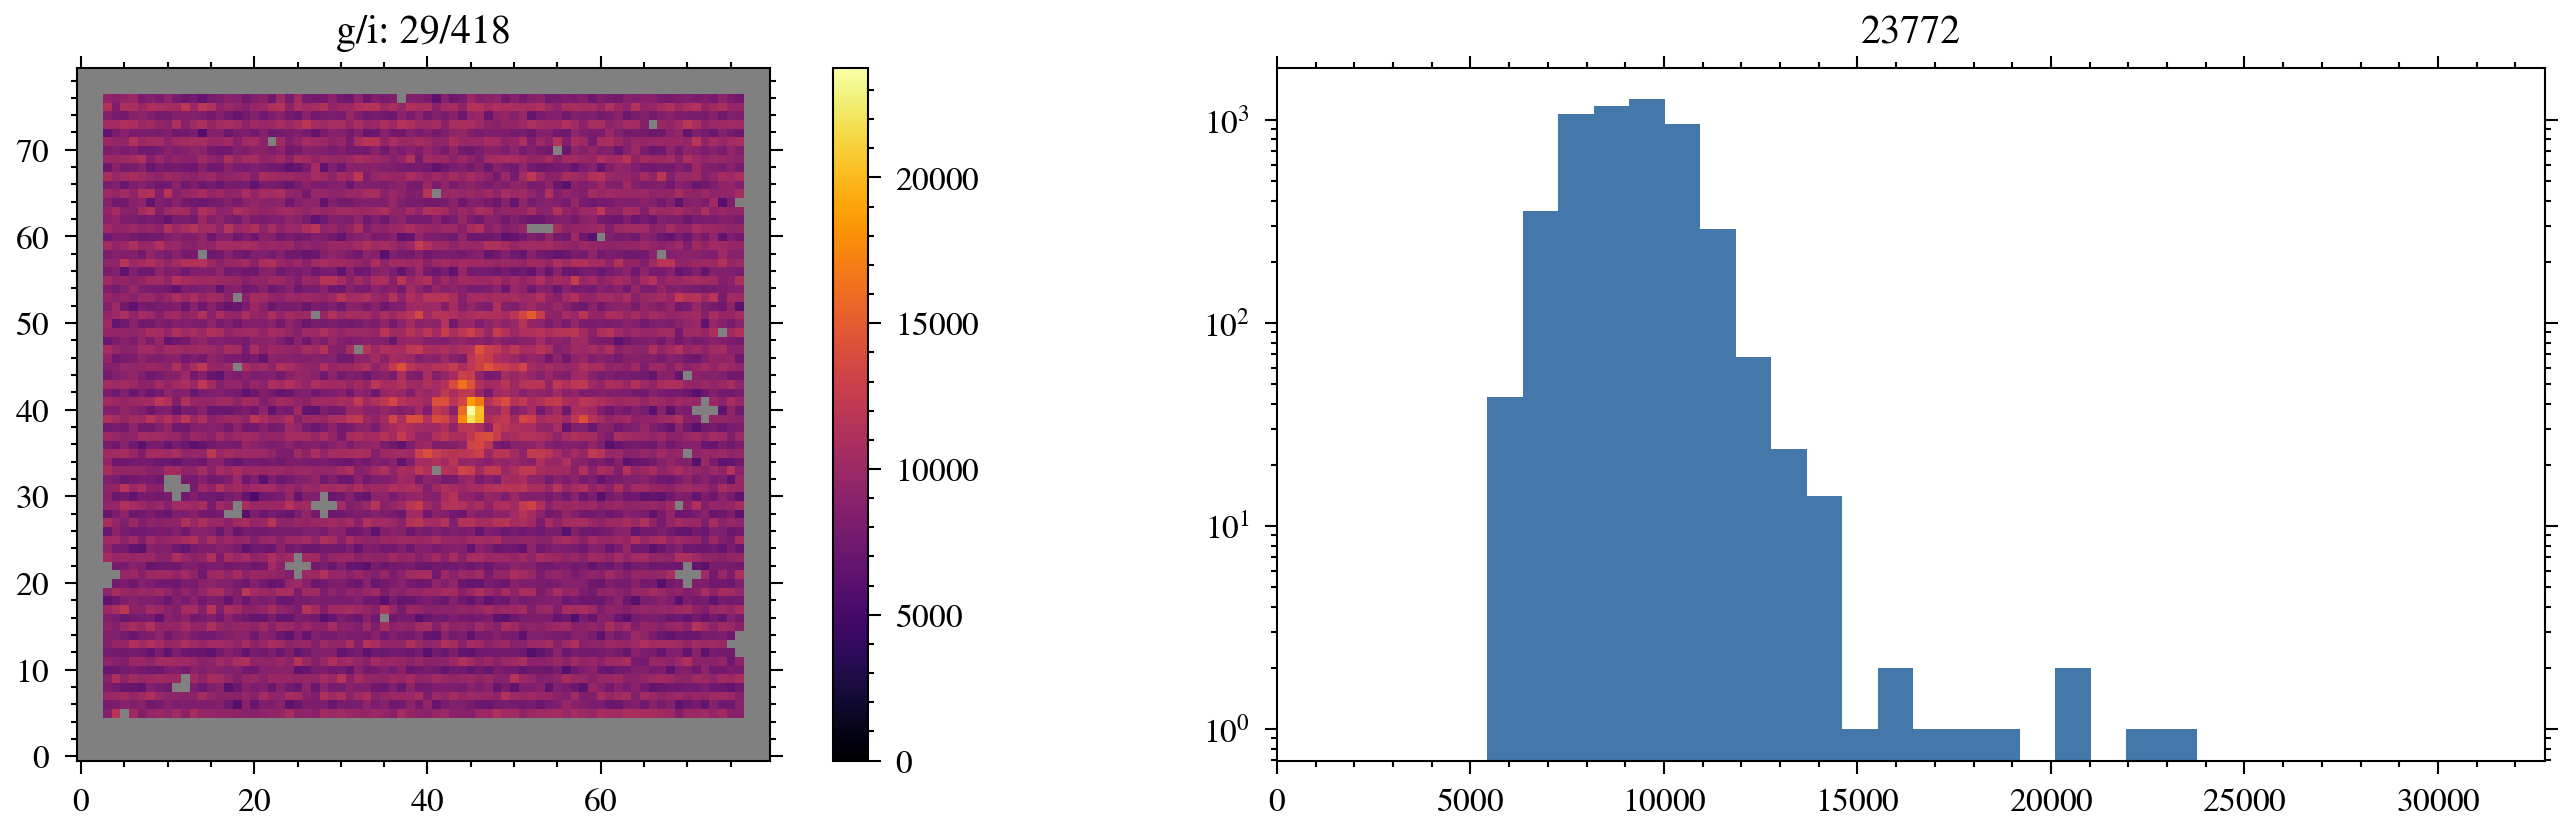




jw01242004001_03103_00001_nis
  program            target filter dither     g/i        date               PI   CAL
0    1242  TD-CAL-HD-123991  F430M    1/1  20/507  24-02-2023  Johnstone, Doug  True


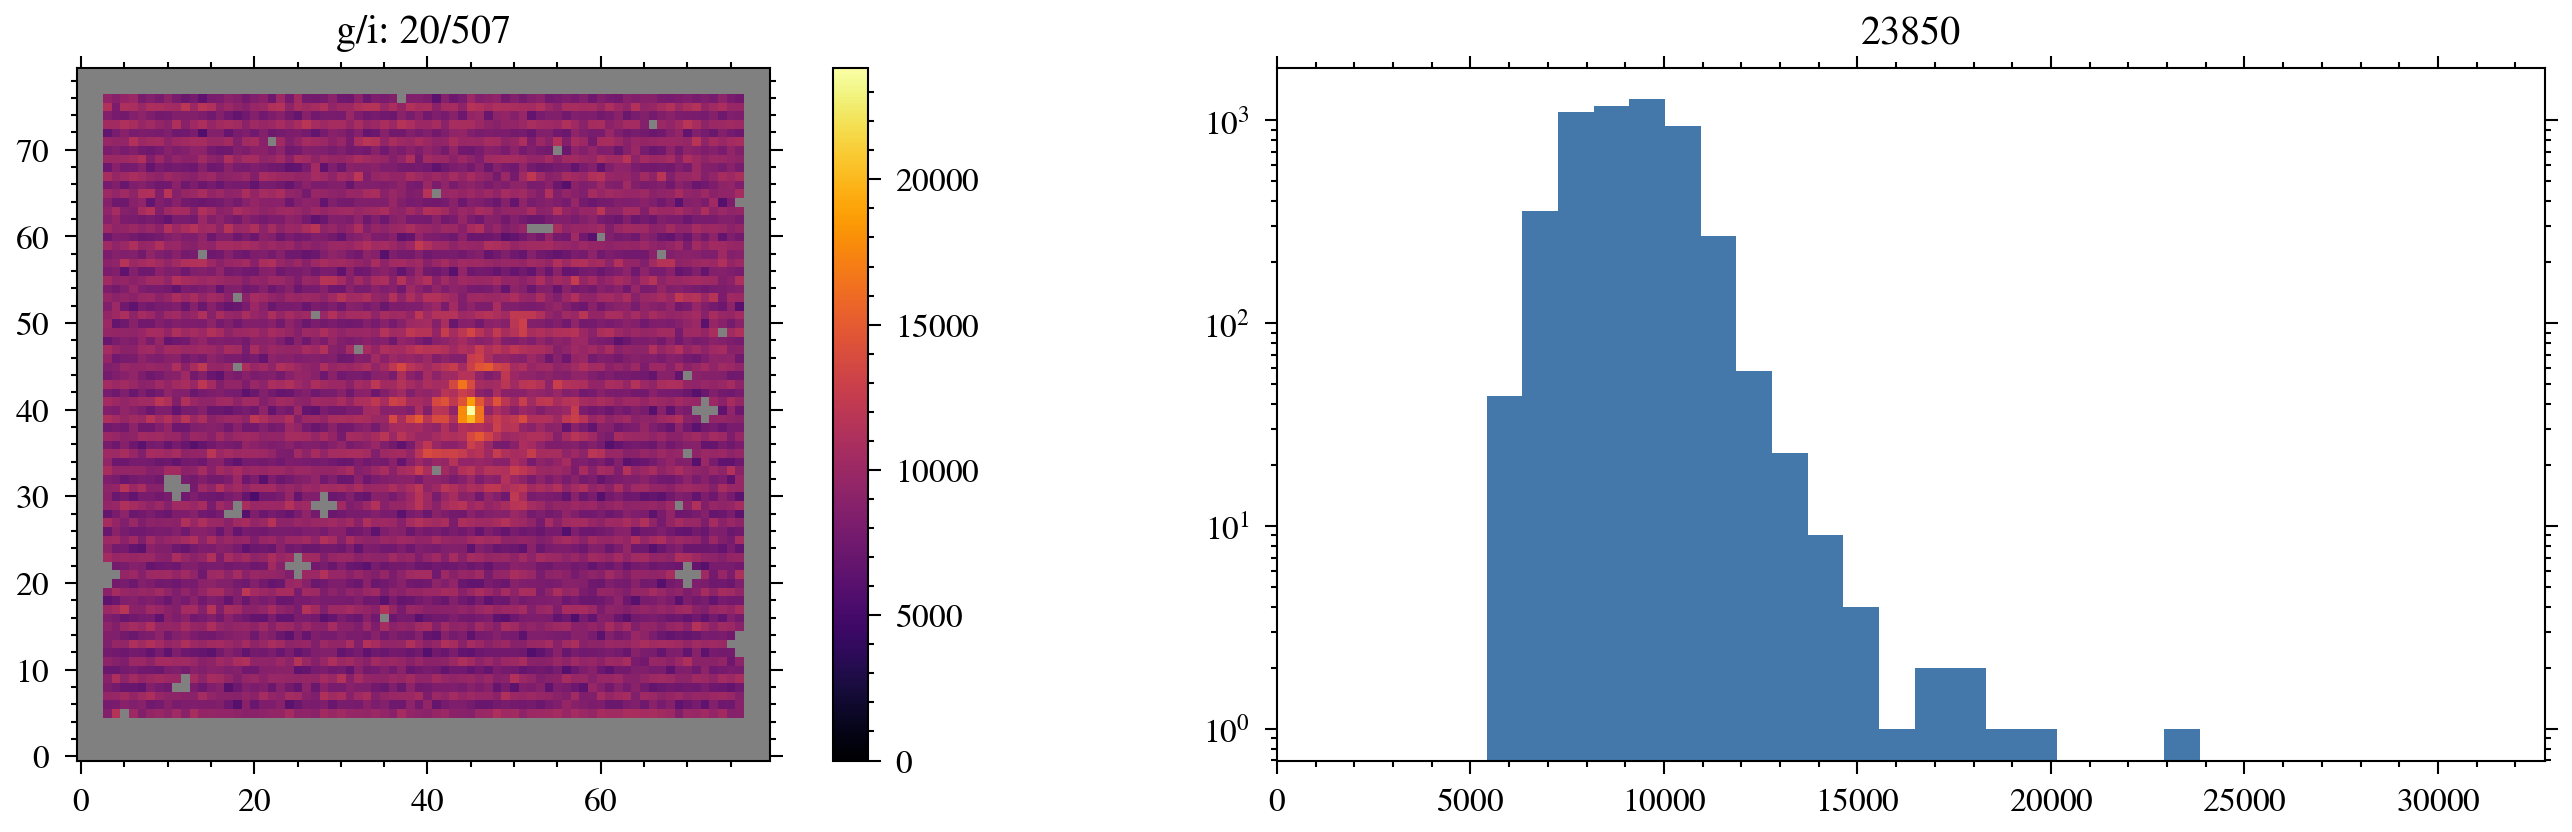




jw01242010001_03102_00001_nis
  program    target filter dither     g/i        date               PI   CAL
0    1242  HD-18638  F480M    1/1  8/4869  31-10-2023  Johnstone, Doug  True


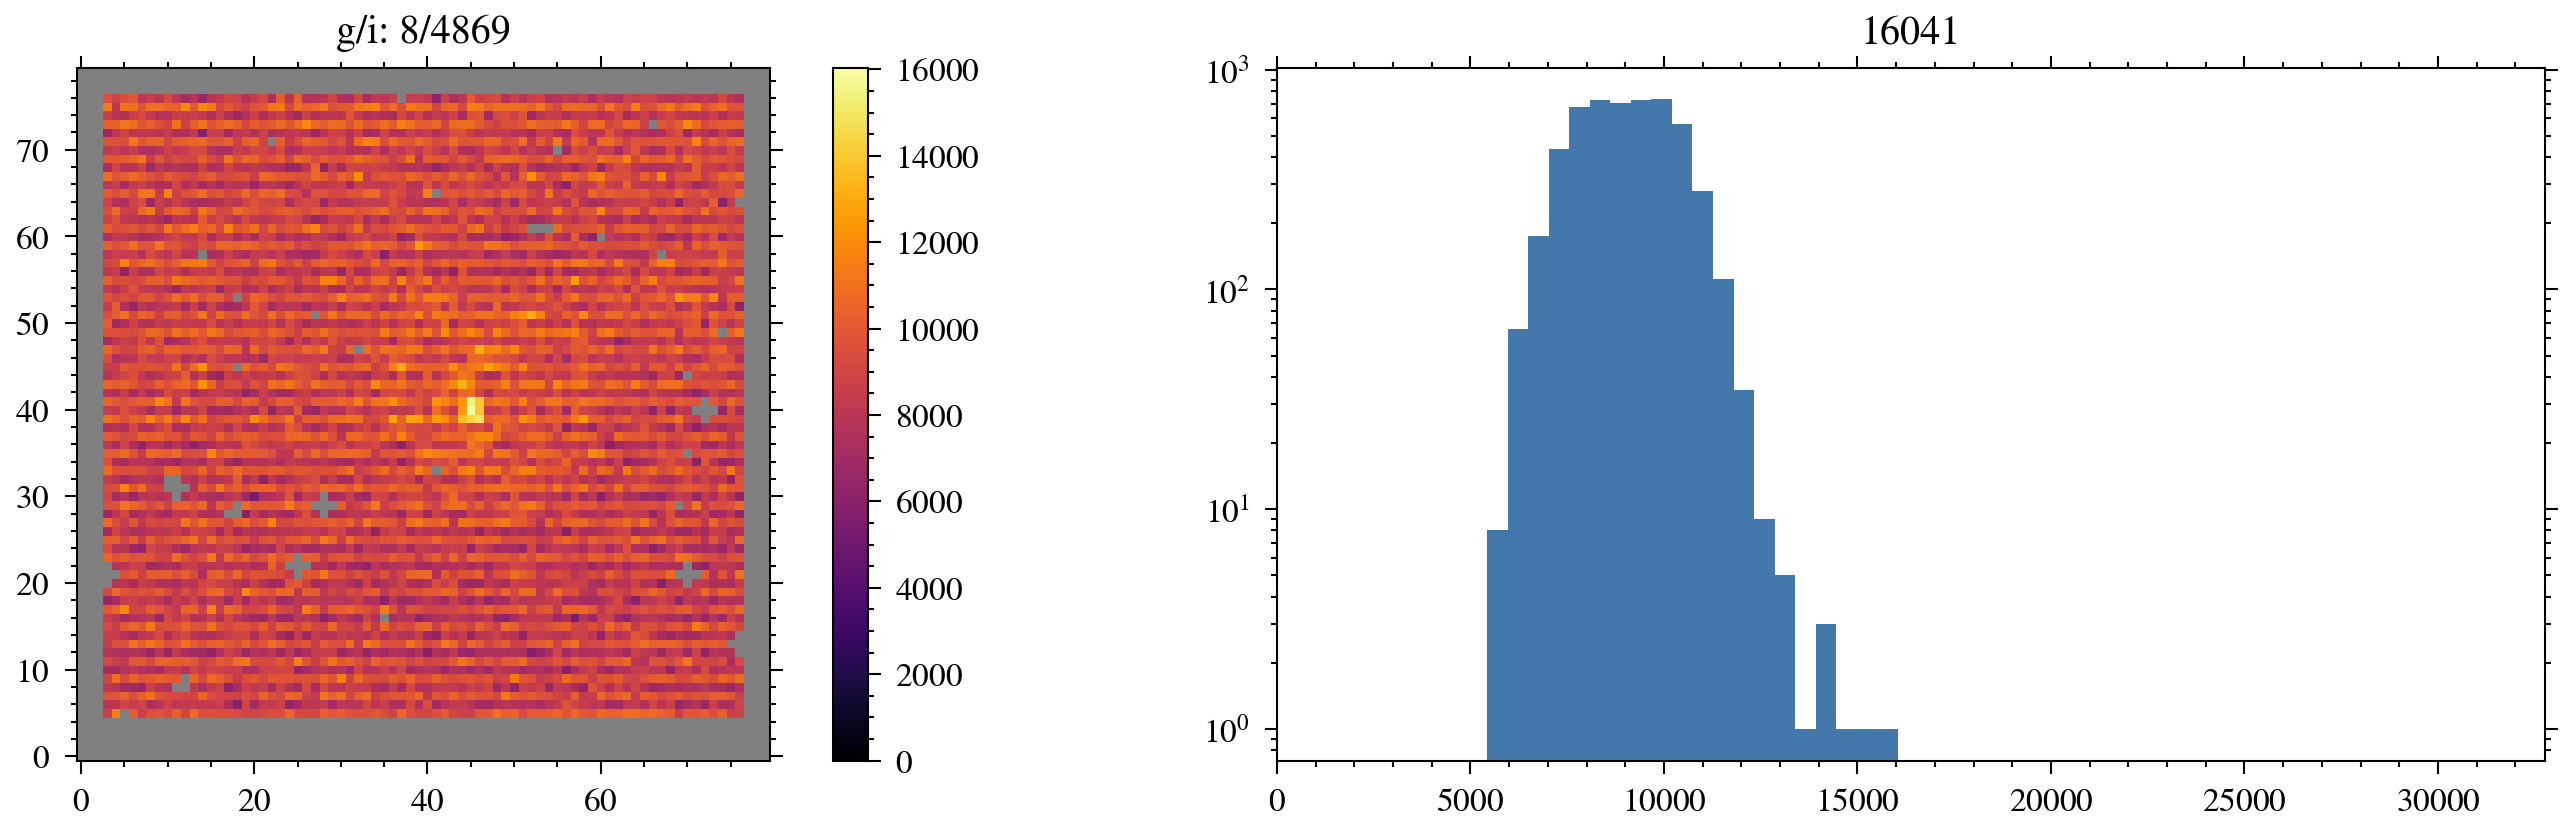

In [6]:
for exp, file in zip(val_exposures, val_files):

    print(2*"\n")
    print(exp.filename)
    summarise_files([file])
    

    badpix = exp.badpix
    ramp = exp.ramp.at[:, badpix].set(np.nan)
    slopes = exp.slopes.at[:, badpix].set(np.nan)

    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    im = ax[0].imshow(ramp[-1], cmap=inferno, norm=mpl.colors.PowerNorm(1., vmin=0))
    ax[0].set(
        title=f"g/i: {exp.ngroups}/{exp.nints}",
    )
    fig.colorbar(im, ax=ax[0])

    ax[1].hist(ramp[-1].ravel(), bins=20, log=True)
    ax[1].set(
        xlim=(0, 2**15),
        title=f"{np.nanmax(ramp[-1]):.0f}"
    )

    plt.show()
